# Statistical Rigor Experiments for Federated ICD Coding

This notebook adds repeated-seed statistical analysis for the paper.

Main goals:
- Run centralized, federated, and KD models across multiple random seeds.
- Save raw run-level results for every method and seed.
- Compute mean performance and 95% confidence intervals.
- Run paired statistical comparisons between methods.
- Add statistical analysis for attention/rationale agreement.
- Add reliability analysis relating attention agreement to false-positive behavior.

The notebook is organized so that reused code from older notebooks comes first,
followed by experiment runners, followed by the new statistical analysis.

## 1. Imports

This section will contain all required imports for:
- PyTorch training
- Data loading
- Federated learning
- Knowledge distillation
- Evaluation metrics
- Attention/rationale analysis
- Statistical testing
- Plotting and table export

In [4]:
# Core Python imports
import os
import csv
import json
import math
import time
import copy
import random
import itertools
from collections import Counter, defaultdict
from typing import Optional, Dict, List, Tuple, Any

# Scientific/data imports
import numpy as np
import pandas as pd
from tqdm import tqdm

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset

# Embedding/model utilities
from gensim.models import Word2Vec

# Plotting imports
import matplotlib.pyplot as plt

# Statistical analysis imports
from scipy import stats
try:
    from statsmodels.stats.multitest import multipletests
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("[Warning] statsmodels is not installed. Holm correction will be skipped unless installed.")

# Existing project evaluation code
from evaluation import all_metrics

## 2. Global Configuration, Device, and Seeds

This section defines the shared experiment configuration.

It will include:
- Device setup
- Random seed list
- Base model hyperparameters
- Training defaults
- Federated learning defaults
- KD defaults
- Reproducibility helper

The goal is to make every experiment use the same basic configuration unless
a method-specific setting is explicitly needed.

In [5]:
# Device setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"

print("Device:", device)
print("Pin memory:", PIN_MEMORY)

Device: cpu
Pin memory: False


In [6]:
# Random seeds for repeated-seed statistical analysis
#
# Using 10 seeds gives one matched result per method/seed pair.
# These seed values can be changed later, but keep the same list across methods.

SEEDS = [11, 22, 33, 44, 55, 66, 77, 88, 99, 110]
N_SEEDS = len(SEEDS)

print("Number of seeds:", N_SEEDS)
print("Seeds:", SEEDS)

Number of seeds: 10
Seeds: [11, 22, 33, 44, 55, 66, 77, 88, 99, 110]


In [7]:
# Reproducibility helper

def set_all_seeds(seed: int, deterministic: bool = True) -> None:
    """
    Set random seeds for Python, NumPy, and PyTorch.

    Args:
        seed: Integer random seed.
        deterministic: If True, asks cuDNN to use deterministic operations where possible.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


# Set an initial seed for notebook setup.
set_all_seeds(SEEDS[0])

print("Initial seed set to:", SEEDS[0])

Initial seed set to: 11


In [8]:
# Base model/training configuration
#
# These match the model settings used in the existing paper experiments:
# - 50-label top-code task
# - 21 convolution filters
# - window size 6
# - batch size 32

BASE_CONFIG = {
    "batch_size": 32,
    "label_space": 50,

    "n_filters": 21,
    "window_size": 6,
    "dropout": 0.2,

    "lr": 0.002,
    "use_focal": False,
    "gamma": 2.5,

    "central_epochs": 300,

    "fl_rounds": 100,
    "local_epochs": 3,
    "mu": 0.001,
    "momentum": 0.0,

    "threshold_min": 0.05,
    "threshold_max": 0.95,
    "threshold_step": 0.05,

    "attention_top_k": 15,
    "phrase_nms_iou": 0.30,
}

BASE_CONFIG

{'batch_size': 32,
 'label_space': 50,
 'n_filters': 21,
 'window_size': 6,
 'dropout': 0.2,
 'lr': 0.002,
 'use_focal': False,
 'gamma': 2.5,
 'central_epochs': 300,
 'fl_rounds': 100,
 'local_epochs': 3,
 'mu': 0.001,
 'momentum': 0.0,
 'threshold_min': 0.05,
 'threshold_max': 0.95,
 'threshold_step': 0.05,
 'attention_top_k': 15,
 'phrase_nms_iou': 0.3}

## 3. Saving Paths and I/O Helpers

This section defines where all outputs from the statistical experiments are saved.

It will include:
- Main statistical analysis directory
- Raw predictive-results CSV path
- Raw attention-results CSV path
- Raw reliability-results CSV path
- Checkpoint directory
- Table directory
- Figure directory
- CSV saving helpers
- JSON saving helpers
- Resume/completed-run helpers

Important principle:
Every experiment should save raw results immediately after it finishes so the
notebook can be resumed if interrupted.

In [9]:
# Project paths

DATA_DIR = os.path.join("..", "Data")
MODEL_DIR = os.path.join("..", "Model")
HISTORY_DIR = os.path.join("..", "History")

MODEL_PARAM_PATH = os.path.join(MODEL_DIR, "processed_full.w2v")

print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("HISTORY_DIR:", HISTORY_DIR)
print("MODEL_PARAM_PATH:", MODEL_PARAM_PATH)

DATA_DIR: ../Data
MODEL_DIR: ../Model
HISTORY_DIR: ../History
MODEL_PARAM_PATH: ../Model/processed_full.w2v


In [10]:
# Statistical-rigor output directories

STAT_DIR = os.path.join(HISTORY_DIR, "statistical_rigor")

RUNS_DIR = os.path.join(STAT_DIR, "runs")
CHECKPOINT_DIR = os.path.join(STAT_DIR, "checkpoints")
THRESHOLD_DIR = os.path.join(STAT_DIR, "thresholds")
CONFIG_DIR = os.path.join(STAT_DIR, "configs")
TABLES_DIR = os.path.join(STAT_DIR, "tables")
FIGURES_DIR = os.path.join(STAT_DIR, "figures")
LOGS_DIR = os.path.join(STAT_DIR, "logs")
CACHE_DIR = os.path.join(STAT_DIR, "cache")

ALL_OUTPUT_DIRS = [
    STAT_DIR,
    RUNS_DIR,
    CHECKPOINT_DIR,
    THRESHOLD_DIR,
    CONFIG_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    LOGS_DIR,
    CACHE_DIR,
]

for d in ALL_OUTPUT_DIRS:
    os.makedirs(d, exist_ok=True)

print("Statistical-rigor output directory:", STAT_DIR)

Statistical-rigor output directory: ../History/statistical_rigor


In [11]:
# Raw result CSV paths

PREDICTIVE_RAW_CSV = os.path.join(RUNS_DIR, "predictive_raw_runs.csv")
ATTENTION_RAW_CSV = os.path.join(RUNS_DIR, "attention_raw_runs.csv")
RELIABILITY_RAW_CSV = os.path.join(RUNS_DIR, "reliability_raw_runs.csv")
RELIABILITY_BINS_RAW_CSV = os.path.join(RUNS_DIR, "reliability_bins_raw_runs.csv")

# Summary/statistical output paths

SUMMARY_MEAN_CI_CSV = os.path.join(TABLES_DIR, "summary_mean_ci.csv")
PAIRWISE_TESTS_CSV = os.path.join(TABLES_DIR, "pairwise_tests.csv")
ATTENTION_SUMMARY_CSV = os.path.join(TABLES_DIR, "attention_summary_mean_ci.csv")
RELIABILITY_CORR_CSV = os.path.join(TABLES_DIR, "reliability_correlations.csv")

# Optional log path

FAILED_RUNS_CSV = os.path.join(LOGS_DIR, "failed_runs.csv")

PATHS = {
    "PREDICTIVE_RAW_CSV": PREDICTIVE_RAW_CSV,
    "ATTENTION_RAW_CSV": ATTENTION_RAW_CSV,
    "RELIABILITY_RAW_CSV": RELIABILITY_RAW_CSV,
    "RELIABILITY_BINS_RAW_CSV": RELIABILITY_BINS_RAW_CSV,
    "SUMMARY_MEAN_CI_CSV": SUMMARY_MEAN_CI_CSV,
    "PAIRWISE_TESTS_CSV": PAIRWISE_TESTS_CSV,
    "ATTENTION_SUMMARY_CSV": ATTENTION_SUMMARY_CSV,
    "RELIABILITY_CORR_CSV": RELIABILITY_CORR_CSV,
    "FAILED_RUNS_CSV": FAILED_RUNS_CSV,
}

for name, path in PATHS.items():
    print(f"{name}: {path}")

PREDICTIVE_RAW_CSV: ../History/statistical_rigor/runs/predictive_raw_runs.csv
ATTENTION_RAW_CSV: ../History/statistical_rigor/runs/attention_raw_runs.csv
RELIABILITY_RAW_CSV: ../History/statistical_rigor/runs/reliability_raw_runs.csv
RELIABILITY_BINS_RAW_CSV: ../History/statistical_rigor/runs/reliability_bins_raw_runs.csv
SUMMARY_MEAN_CI_CSV: ../History/statistical_rigor/tables/summary_mean_ci.csv
PAIRWISE_TESTS_CSV: ../History/statistical_rigor/tables/pairwise_tests.csv
ATTENTION_SUMMARY_CSV: ../History/statistical_rigor/tables/attention_summary_mean_ci.csv
RELIABILITY_CORR_CSV: ../History/statistical_rigor/tables/reliability_correlations.csv
FAILED_RUNS_CSV: ../History/statistical_rigor/logs/failed_runs.csv


### 3.1 General directory and serialization helpers

In [12]:
def ensure_dir(path: str) -> str:
    """
    Create a directory if it does not already exist.

    Args:
        path: Directory path.

    Returns:
        The same path, for convenience.
    """
    os.makedirs(path, exist_ok=True)
    return path

In [13]:
def to_serializable(obj: Any) -> Any:
    """
    Recursively convert NumPy/PyTorch objects into JSON-serializable Python types.
    """
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]

    if isinstance(obj, tuple):
        return [to_serializable(v) for v in obj]

    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, torch.Tensor):
        if obj.numel() == 1:
            return obj.detach().cpu().item()
        return obj.detach().cpu().tolist()

    return obj


def to_serializable_row(row: dict) -> dict:
    """
    Convert one row dictionary into JSON/CSV-safe Python scalars/lists.
    """
    return {k: to_serializable(v) for k, v in row.items()}

In [14]:
def save_json(data: Any, filepath: str) -> None:
    """
    Save data to JSON after converting unsupported object types.
    """
    ensure_dir(os.path.dirname(filepath))

    with open(filepath, mode="w") as f:
        json.dump(to_serializable(data), fp=f, indent=2)

    print(f"Saved JSON: {filepath}")


def load_json(filepath: str) -> Any:
    """
    Load JSON data from a file.
    """
    with open(filepath, mode="r") as f:
        return json.load(f)

### 3.2 CSV helpers

`save_dict_rows_to_csv` is useful for final exports.

`append_row_to_csv` is useful inside long experiment loops because it saves
one completed run immediately.

In [15]:
def save_dict_rows_to_csv(rows: List[dict], filepath: str) -> None:
    """
    Save a list of dictionaries to a CSV file.

    This handles rows with non-identical keys by building the union of keys in
    the order they are first seen.
    """
    ensure_dir(os.path.dirname(filepath))

    if not rows:
        print(f"[save_dict_rows_to_csv] No rows to save for {filepath}")
        return

    rows = [to_serializable_row(row) for row in rows]

    fieldnames = []
    seen = set()

    for row in rows:
        for key in row.keys():
            if key not in seen:
                seen.add(key)
                fieldnames.append(key)

    with open(filepath, mode="w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"Saved CSV: {filepath}")

In [16]:
def append_row_to_csv(row: dict, filepath: str) -> None:
    """
    Append one row to a CSV file.

    If the CSV already exists and the new row contains new columns, this function
    rewrites the CSV with the expanded union of columns. This makes long-running
    experiments more robust to small row-format changes.
    """
    ensure_dir(os.path.dirname(filepath))

    row = to_serializable_row(row)

    if not os.path.exists(filepath):
        pd.DataFrame([row]).to_csv(filepath, index=False)
        return

    existing = pd.read_csv(filepath)

    new_cols = [c for c in row.keys() if c not in existing.columns]

    if new_cols:
        for c in new_cols:
            existing[c] = np.nan

        new_row = pd.DataFrame([row])
        combined = pd.concat([existing, new_row], ignore_index=True, sort=False)
        combined.to_csv(filepath, index=False)
    else:
        pd.DataFrame([row], columns=existing.columns).to_csv(
            filepath,
            mode="a",
            header=False,
            index=False,
        )

In [17]:
def read_csv_if_exists(filepath: str) -> pd.DataFrame:
    """
    Read a CSV if it exists; otherwise return an empty DataFrame.
    """
    if os.path.exists(filepath):
        return pd.read_csv(filepath)

    return pd.DataFrame()

### 3.3 Run naming helpers

These helpers will be used later by the experiment runners to create stable,
readable filenames for checkpoints, thresholds, and config files.

In [18]:
def safe_name(value: Any) -> str:
    """
    Convert a value into a filesystem-friendly string.
    """
    text = str(value)
    replacements = {
        " ": "_",
        "/": "_",
        "\\": "_",
        ":": "_",
        ";": "_",
        ",": "_",
        "(": "",
        ")": "",
        "[": "",
        "]": "",
        "{": "",
        "}": "",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text


def make_run_id(method: str, seed: int, extra: Optional[str] = None) -> str:
    """
    Create a stable run ID for a method/seed pair.
    """
    parts = [safe_name(method), f"seed{seed}"]

    if extra is not None:
        parts.append(safe_name(extra))

    return "__".join(parts)


def get_checkpoint_path(method: str, seed: int, extra: Optional[str] = None) -> str:
    """
    Build checkpoint path for one run.
    """
    run_id = make_run_id(method, seed, extra)
    return os.path.join(CHECKPOINT_DIR, f"{run_id}.pt")


def get_threshold_path(method: str, seed: int, extra: Optional[str] = None) -> str:
    """
    Build threshold-vector path for one run.
    """
    run_id = make_run_id(method, seed, extra)
    return os.path.join(THRESHOLD_DIR, f"{run_id}_thresholds.pt")


def get_config_path(method: str, seed: int, extra: Optional[str] = None) -> str:
    """
    Build config JSON path for one run.
    """
    run_id = make_run_id(method, seed, extra)
    return os.path.join(CONFIG_DIR, f"{run_id}_config.json")

## 4. Data Loading and Metadata

This section loads the fixed train, validation, and test splits.

It will include:
- Train dataset
- Validation dataset/loader
- Test dataset/loader
- ICD code metadata
- Label index to ICD code mapping
- ICD code to description mapping
- Token decoder setup for attention analysis

All methods should use the same train/validation/test split.
The validation set is used for per-label threshold tuning.
The test set is used only for final reporting.

### 4.1 Tensor loading helpers

In [19]:
def load_split_tensors(split: str) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Load preprocessed tensors for one split.

    Expected files:
    - ../Data/X_{split}.pt
    - ../Data/Y_{split}.pt

    Args:
        split: One of {"train", "val", "test"}.

    Returns:
        X, Y tensors on CPU.
    """
    x_path = os.path.join(DATA_DIR, f"X_{split}.pt")
    y_path = os.path.join(DATA_DIR, f"Y_{split}.pt")

    X = torch.load(x_path, map_location="cpu")
    Y = torch.load(y_path, map_location="cpu")

    return X, Y


def make_tensor_dataset(split: str) -> TensorDataset:
    """
    Load one split and wrap it in a TensorDataset.
    """
    X, Y = load_split_tensors(split)
    return TensorDataset(X, Y)


def make_loader(
    dataset: TensorDataset,
    batch_size: int = BASE_CONFIG["batch_size"],
    shuffle: bool = False,
    seed: Optional[int] = None,
) -> DataLoader:
    """
    Create a DataLoader.

    If seed is provided and shuffle=True, the DataLoader receives a seeded
    generator for reproducible shuffling.
    """
    generator = None

    if seed is not None:
        generator = torch.Generator()
        generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        pin_memory=PIN_MEMORY,
    )


def load_data(
    split: str,
    batch_size: int = BASE_CONFIG["batch_size"],
    shuffle: bool = False,
    seed: Optional[int] = None,
) -> DataLoader:
    """
    Convenience wrapper matching the older notebook style:
    load tensors, create TensorDataset, and return DataLoader.
    """
    dataset = make_tensor_dataset(split)
    return make_loader(dataset, batch_size=batch_size, shuffle=shuffle, seed=seed)

### 4.2 Load fixed train/validation/test splits

In [20]:
# Load datasets once and keep them fixed.

train_dataset = make_tensor_dataset("train")
val_dataset = make_tensor_dataset("val")
test_dataset = make_tensor_dataset("test")

# Base evaluation loaders.
# Training runners can create separate shuffled train loaders later.

train_loader = make_loader(train_dataset, batch_size=BASE_CONFIG["batch_size"], shuffle=False)
val_loader = make_loader(val_dataset, batch_size=BASE_CONFIG["batch_size"], shuffle=False)
test_loader = make_loader(test_dataset, batch_size=BASE_CONFIG["batch_size"], shuffle=False)

print("Loaded datasets:")
print("  train:", len(train_dataset))
print("  val:  ", len(val_dataset))
print("  test: ", len(test_dataset))

Loaded datasets:
  train: 6453
  val:   1613
  test:  1729


In [21]:
# Keep direct tensor references for attention/rationale analysis and diagnostics.

X_train, Y_train = train_dataset.tensors
X_val, Y_val = val_dataset.tensors
X_test, Y_test = test_dataset.tensors

print("Tensor shapes:")
print("  X_train:", tuple(X_train.shape), "| Y_train:", tuple(Y_train.shape))
print("  X_val:  ", tuple(X_val.shape), "| Y_val:  ", tuple(Y_val.shape))
print("  X_test: ", tuple(X_test.shape), "| Y_test: ", tuple(Y_test.shape))

N_LABELS = Y_train.shape[1]
assert N_LABELS == BASE_CONFIG["label_space"], (
    f"Expected {BASE_CONFIG['label_space']} labels, got {N_LABELS}"
)

print("Number of labels:", N_LABELS)

Tensor shapes:
  X_train: (6453, 2500) | Y_train: (6453, 50)
  X_val:   (1613, 2500) | Y_val:   (1613, 50)
  X_test:  (1729, 2500) | Y_test:  (1729, 50)
Number of labels: 50


### 4.3 ICD label metadata

This loads:
- label index → ICD code
- ICD code → long description

The top-50 code order is important because it defines the label index order.

In [22]:
DESC_PATH = os.path.join(DATA_DIR, "ICD9_descriptions")
CODE_50_PATH = os.path.join(DATA_DIR, "TOP_50_CODES.csv")

print("DESC_PATH:", DESC_PATH)
print("CODE_50_PATH:", CODE_50_PATH)

DESC_PATH: ../Data/ICD9_descriptions
CODE_50_PATH: ../Data/TOP_50_CODES.csv


In [23]:
def load_icd_metadata(desc_path: str, code_50_path: str) -> Tuple[Dict[int, str], Dict[str, str]]:
    """
    Load ICD metadata.

    Args:
        desc_path: Path to ICD9_descriptions.
        code_50_path: Path to TOP_50_CODES.csv.

    Returns:
        idx_to_code:
            Dictionary mapping label index to ICD code.
        code_to_desc:
            Dictionary mapping ICD code to long description.
    """
    desc_df = pd.read_csv(
        desc_path,
        sep="\t",
        header=None,
        names=["CODE", "LONG_TITLE"],
        dtype=str,
    )

    desc_df["CODE"] = desc_df["CODE"].astype(str).str.strip()
    desc_df["LONG_TITLE"] = desc_df["LONG_TITLE"].astype(str).str.strip()

    code_to_desc = dict(zip(desc_df["CODE"], desc_df["LONG_TITLE"]))

    top50_df = pd.read_csv(
        code_50_path,
        header=None,
        names=["CODE"],
        dtype=str,
    )

    top50_df["CODE"] = top50_df["CODE"].astype(str).str.strip()

    idx_to_code = dict(enumerate(top50_df["CODE"].tolist()))

    return idx_to_code, code_to_desc


IDX_TO_CODE, CODE_TO_DESC = load_icd_metadata(DESC_PATH, CODE_50_PATH)

print("Loaded top-50 ICD metadata.")
print("First 10 label mappings:")
for i in range(min(10, len(IDX_TO_CODE))):
    code = IDX_TO_CODE[i]
    desc = CODE_TO_DESC.get(code, "Unknown ICD code")
    print(f"  {i:02d}: {code} | {desc}")

Loaded top-50 ICD metadata.
First 10 label mappings:
  00: 401.9 | Unspecified essential hypertension
  01: 38.93 | Venous catheterization, not elsewhere classified
  02: 428.0 | Congestive heart failure, unspecified
  03: 427.31 | Atrial fibrillation
  04: 414.01 | Coronary atherosclerosis of native coronary artery
  05: 96.04 | Insertion of endotracheal tube
  06: 96.6 | Enteral infusion of concentrated nutritional substances
  07: 584.9 | Acute renal failure, unspecified
  08: 250.00 | type II diabetes mellitus [non-insulin dependent type] [NIDDM type] [adult-onset type] or unspecified type, not stated as uncontrolled, without mention of complication
  09: 96.71 | Continuous mechanical ventilation for less than 96 consecutive hours


In [24]:
def label_info(label_idx: int) -> str:
    """
    Return a readable string for one label index.

    Example:
        "401.9 - Unspecified essential hypertension"
    """
    code = IDX_TO_CODE.get(label_idx, "UNK")
    desc = CODE_TO_DESC.get(code, "Unknown ICD code")
    return f"{code} - {desc}"


def labels_to_codes(label_indices: List[int]) -> List[str]:
    """
    Convert a list of label indices to ICD codes.
    """
    return [IDX_TO_CODE.get(int(idx), "UNK") for idx in label_indices]

### 4.4 Label-frequency diagnostics

These are simple dataset-level diagnostics that will be useful later for
sanity checks and for attention/frequency analyses.

In [25]:
def compute_label_counts(Y: torch.Tensor) -> pd.DataFrame:
    """
    Compute positive count and prevalence for each label.
    """
    Y_np = Y.detach().cpu().numpy()
    counts = Y_np.sum(axis=0)
    prevalence = counts / Y_np.shape[0]

    rows = []
    for label_idx in range(Y_np.shape[1]):
        code = IDX_TO_CODE.get(label_idx, "UNK")
        desc = CODE_TO_DESC.get(code, "Unknown ICD code")

        rows.append({
            "label_idx": label_idx,
            "code": code,
            "description": desc,
            "positive_count": int(counts[label_idx]),
            "prevalence": float(prevalence[label_idx]),
        })

    return pd.DataFrame(rows)


train_label_counts_df = compute_label_counts(Y_train)
val_label_counts_df = compute_label_counts(Y_val)
test_label_counts_df = compute_label_counts(Y_test)

train_label_counts_df.head()

,label_idx,code,description,positive_count,prevalence
0,0,401.9,Unspecified essential hypertension,462,0.071595
1,1,38.93,"Venous catheterization, not elsewhere classified",620,0.096079
2,2,428.0,"Congestive heart failure, unspecified",1153,0.178677
3,3,427.31,Atrial fibrillation,760,0.117775
4,4,414.01,Coronary atherosclerosis of native coronary ar...,991,0.153572


In [26]:
print("Train label count summary:")
display(train_label_counts_df["positive_count"].describe())

print("\nMost frequent training labels:")
display(
    train_label_counts_df
    .sort_values("positive_count", ascending=False)
    .head(10)
)

Train label count summary:


,positive_count
count,50.000000
mean,734.280000
std,469.499562
min,316.000000
25%,401.250000
50%,577.000000
75%,928.500000
max,2589.000000



Most frequent training labels:


,label_idx,code,description,positive_count,prevalence
20,20,244.9,Unspecified hypothyroidism,2589,0.401209
17,17,272.0,Pure hypercholesterolemia,1712,0.265303
27,27,99.15,Parenteral infusion of concentrated nutritiona...,1706,0.264373
26,26,496,"Chronic airway obstruction, not elsewhere clas...",1596,0.247327
24,24,36.15,Single internal mammary-coronary artery bypass,1526,0.236479
40,40,39.95,Hemodialysis,1271,0.196963
41,41,287.5,"Thrombocytopenia, unspecified",1224,0.189679
35,35,311,"Depressive disorder, not elsewhere classified",1154,0.178832
2,2,428.0,"Congestive heart failure, unspecified",1153,0.178677
42,42,410.71,"Acute myocardial infarction, subendocardial in...",1125,0.174338


### 4.5 Token decoder setup

This loads the Word2Vec vocabulary so that token IDs can be converted back
into readable tokens during attention/rationale analysis.

The padding index convention is:
`PAD_INDEX = vocab_size`.

In [27]:
# Load Word2Vec model for token decoding.
#
# The model architecture will also use this same file later for embedding
# initialization.

W2V_MODEL = Word2Vec.load(MODEL_PARAM_PATH)

IDX_TO_TOKEN = W2V_MODEL.wv.index_to_key
TOKEN_TO_IDX = {tok: idx for idx, tok in enumerate(IDX_TO_TOKEN)}

PAD_INDEX = len(IDX_TO_TOKEN)

print("Vocabulary size:", len(IDX_TO_TOKEN))
print("PAD_INDEX:", PAD_INDEX)

Vocabulary size: 150853
PAD_INDEX: 150853


In [28]:
def decode_sequence(token_ids_1d: torch.Tensor, stop_at_pad: bool = False) -> List[str]:
    """
    Convert a 1D tensor of token IDs into tokens.

    Args:
        token_ids_1d: Tensor of token IDs.
        stop_at_pad: If True, stop decoding at the first PAD token.

    Returns:
        List of decoded token strings.
    """
    tokens = []

    for idx in token_ids_1d.detach().cpu().tolist():
        idx = int(idx)

        if idx == PAD_INDEX:
            if stop_at_pad:
                break
            tokens.append("<PAD>")
        else:
            tokens.append(IDX_TO_TOKEN[idx])

    return tokens


def nonpad_length(token_ids_1d: torch.Tensor) -> int:
    """
    Return the number of non-PAD tokens in a tokenized note.
    """
    x = token_ids_1d.detach().cpu()
    pad_positions = (x == PAD_INDEX).nonzero(as_tuple=False)

    if len(pad_positions) == 0:
        return int(x.numel())

    return int(pad_positions[0].item())

In [29]:
# Quick decoder sanity check on the first test example.

example_tokens = decode_sequence(X_test[0], stop_at_pad=True)
print("First test note non-PAD length:", nonpad_length(X_test[0]))
print("First 30 decoded tokens:")
print(example_tokens[:30])

First test note non-PAD length: 235
First 30 decoded tokens:
['admission', 'date', 'discharge', 'date', 'date', 'of', 'birth', 'sex', 'm', 'service', 'surgery', 'allergies', 'no', 'drug', 'allergy', 'information', 'on', 'file', 'attending', 'first', 'name3', 'lf', 'chief', 'complaint', 'fall', 'from', 'bike', 'major', 'surgical', 'or']


### 4.6 Save setup metadata

This saves basic setup information so later result folders are easier to audit.

In [30]:
setup_metadata = {
    "seeds": SEEDS,
    "base_config": BASE_CONFIG,
    "paths": {
        "data_dir": DATA_DIR,
        "model_dir": MODEL_DIR,
        "history_dir": HISTORY_DIR,
        "stat_dir": STAT_DIR,
        "model_param_path": MODEL_PARAM_PATH,
    },
    "dataset_sizes": {
        "train": len(train_dataset),
        "val": len(val_dataset),
        "test": len(test_dataset),
    },
    "tensor_shapes": {
        "X_train": tuple(X_train.shape),
        "Y_train": tuple(Y_train.shape),
        "X_val": tuple(X_val.shape),
        "Y_val": tuple(Y_val.shape),
        "X_test": tuple(X_test.shape),
        "Y_test": tuple(Y_test.shape),
    },
    "label_space": int(N_LABELS),
    "vocab_size": int(len(IDX_TO_TOKEN)),
    "pad_index": int(PAD_INDEX),
}

SETUP_METADATA_JSON = os.path.join(CONFIG_DIR, "setup_metadata.json")
save_json(setup_metadata, SETUP_METADATA_JSON)

Saved JSON: ../History/statistical_rigor/configs/setup_metadata.json


## 5. Model Architecture and Model Factories

This section contains the model definitions copied from the existing notebooks.

It will include:
- ConvAttnPool model
- Standard model factory
- Optional teacher/student model factories for heterogeneous KD

The standard model should match the architecture used in the paper:
Word2Vec embeddings, dropout, 1D convolution, label-wise attention, and
multi-label output logits.

### 5.1 ConvAttnPool model

In [31]:
class ConvAttnPool(nn.Module):
    """
    Convolution + label-wise attention pooling model using a pretrained Word2Vec
    embedding table.

    This is the main architecture used for centralized, federated, and shared
    student models.

    Args:
        table_path:
            Path to the pretrained Word2Vec model.
        label_space:
            Number of ICD labels.
        num_of_filters:
            Number of convolutional filters.
        kernel_size:
            Conv1d kernel size.
        drop_out:
            Dropout probability after embeddings.

    Returns:
        logits:
            Tensor of shape (batch_size, label_space).
        alpha:
            Label-wise attention tensor of shape (batch_size, label_space, seq_len_after_conv).
    """

    def __init__(
        self,
        table_path: str,
        label_space: int = 50,
        num_of_filters: int = 10,
        kernel_size: int = 3,
        drop_out: float = 0.2,
    ):
        super().__init__()

        w2v = Word2Vec.load(table_path)
        vocab_size, embed_d = w2v.wv.vectors.shape

        embed_table = torch.from_numpy(w2v.wv.vectors).float()
        embed_table = torch.cat(
            [embed_table, torch.zeros((1, embed_d))],
            dim=0,
        )

        self.embed = nn.Embedding.from_pretrained(
            embeddings=embed_table,
            padding_idx=vocab_size,
        )
        self.embed_drop = nn.Dropout(p=drop_out)

        self.conv = nn.Conv1d(
            in_channels=embed_d,
            out_channels=num_of_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
        )

        self.U = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)

        self.embedding_size = embed_d
        self.label_space = label_space
        self.num_of_filters = num_of_filters
        self.kernel_size = kernel_size
        self.drop_out = drop_out
        self.padding_idx = vocab_size

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.embed(x)                              # (B, L, E)
        x = self.embed_drop(x)
        x = x.transpose(1, 2)                          # (B, E, L)
        x = torch.tanh(self.conv(x).transpose(1, 2))   # (B, L', F)

        alpha = F.softmax(
            self.U.weight.matmul(x.transpose(1, 2)),
            dim=2,
        )                                             # (B, C, L')

        m = alpha.matmul(x)                            # (B, C, F)

        logits = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)

        return logits, alpha

### 5.2 Standard model factory

This factory creates the default architecture used by the main paper models.

It accepts both `num_of_filters` and `n_filters` so it works with naming from
multiple older notebooks.

In [32]:
def GenerateModel(
    table_path: str,
    num_of_filters: Optional[int] = None,
    kernel_size: Optional[int] = None,
    label_space: Optional[int] = None,
    drop_out: Optional[float] = None,
    n_filters: Optional[int] = None,
    window_size: Optional[int] = None,
) -> ConvAttnPool:
    """
    Factory for the standard ConvAttnPool model.

    Args:
        table_path:
            Word2Vec path.
        num_of_filters / n_filters:
            Number of convolutional filters.
        kernel_size / window_size:
            Conv1d kernel size.
        label_space:
            Number of output labels.
        drop_out:
            Dropout probability.

    Returns:
        ConvAttnPool model.
    """
    if num_of_filters is None:
        num_of_filters = n_filters

    if kernel_size is None:
        kernel_size = window_size

    if num_of_filters is None:
        num_of_filters = BASE_CONFIG["n_filters"]

    if kernel_size is None:
        kernel_size = BASE_CONFIG["window_size"]

    if label_space is None:
        label_space = BASE_CONFIG["label_space"]

    if drop_out is None:
        drop_out = BASE_CONFIG["dropout"]

    return ConvAttnPool(
        table_path=table_path,
        label_space=label_space,
        num_of_filters=num_of_filters,
        kernel_size=kernel_size,
        drop_out=drop_out,
    )

### 5.3 Model loading and checkpoint helpers

These helpers are used later by the runners and attention-analysis sections.

In [33]:
def build_standard_model(device: torch.device = device) -> nn.Module:
    """
    Build the default paper model using BASE_CONFIG.
    """
    model = GenerateModel(
        table_path=MODEL_PARAM_PATH,
        num_of_filters=BASE_CONFIG["n_filters"],
        kernel_size=BASE_CONFIG["window_size"],
        label_space=BASE_CONFIG["label_space"],
        drop_out=BASE_CONFIG["dropout"],
    )
    return model.to(device)


def clone_state_dict(state_dict: dict) -> dict:
    """
    Safely clone a state_dict onto CPU.
    """
    return {
        k: v.detach().cpu().clone()
        for k, v in state_dict.items()
    }


def load_model_from_checkpoint(
    checkpoint_path: str,
    device: torch.device = device,
    model_config: Optional[dict] = None,
) -> nn.Module:
    """
    Load a ConvAttnPool checkpoint using either BASE_CONFIG or a provided config.
    """
    if model_config is None:
        model_config = BASE_CONFIG

    model = GenerateModel(
        table_path=MODEL_PARAM_PATH,
        num_of_filters=model_config.get("n_filters", BASE_CONFIG["n_filters"]),
        kernel_size=model_config.get("window_size", BASE_CONFIG["window_size"]),
        label_space=model_config.get("label_space", BASE_CONFIG["label_space"]),
        drop_out=model_config.get("dropout", BASE_CONFIG["dropout"]),
    ).to(device)

    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state)
    model.eval()

    return model


def save_model_checkpoint(model: nn.Module, checkpoint_path: str) -> None:
    """
    Save a model state_dict to disk.
    """
    ensure_dir(os.path.dirname(checkpoint_path))
    torch.save(clone_state_dict(model.state_dict()), checkpoint_path)

### 5.4 Heterogeneous teacher model factories for KD

These define possible local teacher architectures for heterogeneous KD.
The shared student can remain the standard paper model, while teachers may
vary in width and kernel size.

In [34]:
DEFAULT_TEACHER_POOL = [
    {
        "name": "t1_light",
        "num_of_filters": 28,
        "kernel_size": 4,
        "drop_out": 0.2,
    },
    {
        "name": "t2_medium",
        "num_of_filters": 36,
        "kernel_size": 6,
        "drop_out": 0.2,
    },
    {
        "name": "t3_caml_ref",
        "num_of_filters": 50,
        "kernel_size": 10,
        "drop_out": 0.2,
    },
    {
        "name": "t4_large",
        "num_of_filters": 64,
        "kernel_size": 10,
        "drop_out": 0.2,
    },
    {
        "name": "t5_xlarge",
        "num_of_filters": 80,
        "kernel_size": 12,
        "drop_out": 0.2,
    },
]


def build_teacher_from_profile(
    table_path: str,
    profile: dict,
    label_space: int = BASE_CONFIG["label_space"],
) -> nn.Module:
    """
    Build a local teacher model from a teacher-profile dictionary.
    """
    return ConvAttnPool(
        table_path=table_path,
        label_space=label_space,
        num_of_filters=profile.get("num_of_filters", BASE_CONFIG["n_filters"]),
        kernel_size=profile.get("kernel_size", BASE_CONFIG["window_size"]),
        drop_out=profile.get("drop_out", BASE_CONFIG["dropout"]),
    )


def assign_teacher_models(
    num_clients: int,
    teacher_pool: List[dict],
    table_path: str,
    device: torch.device = device,
    assignment: str = "round_robin",
    seed: int = 42,
) -> Tuple[List[nn.Module], List[dict]]:
    """
    Assign heterogeneous local teacher models to clients.

    Args:
        num_clients:
            Number of clients.
        teacher_pool:
            List of teacher-profile dictionaries.
        table_path:
            Word2Vec path.
        device:
            Target device.
        assignment:
            "round_robin" or "random".
        seed:
            Random seed used for random assignment.

    Returns:
        teachers:
            List of teacher models.
        teacher_profiles:
            List of assigned profile dictionaries.
    """
    if len(teacher_pool) == 0:
        raise ValueError("teacher_pool must contain at least one teacher profile.")

    rng = np.random.default_rng(seed)

    if assignment == "round_robin":
        teacher_profiles = [
            copy.deepcopy(teacher_pool[i % len(teacher_pool)])
            for i in range(num_clients)
        ]
    elif assignment == "random":
        teacher_profiles = [
            copy.deepcopy(teacher_pool[int(rng.integers(0, len(teacher_pool)))])
            for _ in range(num_clients)
        ]
    else:
        raise ValueError("assignment must be 'round_robin' or 'random'.")

    teachers = [
        build_teacher_from_profile(
            table_path=table_path,
            profile=profile,
        ).to(device)
        for profile in teacher_profiles
    ]

    return teachers, teacher_profiles


def count_parameters(model: nn.Module) -> int:
    """
    Count trainable and frozen parameters together.
    """
    return sum(p.numel() for p in model.parameters())

### 5.5 Model sanity check

This checks that the standard model can run a forward pass on one batch.
It does not train anything.

In [35]:
model_sanity = build_standard_model(device=device)
model_sanity.eval()

with torch.no_grad():
    Xb_sanity, yb_sanity = next(iter(test_loader))
    Xb_sanity = Xb_sanity.to(device)
    logits_sanity, alpha_sanity = model_sanity(Xb_sanity)

print("Sanity model output:")
print("  logits:", tuple(logits_sanity.shape))
print("  alpha: ", tuple(alpha_sanity.shape))
print("  params:", count_parameters(model_sanity))

del model_sanity, Xb_sanity, yb_sanity, logits_sanity, alpha_sanity
torch.cuda.empty_cache()

Sanity model output:
  logits: (32, 50)
  alpha:  (32, 50, 2501)
  params: 15100221


## 6. Training Primitives

This section contains low-level training functions shared by the runners.

It will include:
- Positive class weight computation
- Weighted BCE loss setup
- Optional focal loss setup
- Centralized training step/helper
- Client local update
- FedAvg aggregation
- FedProx proximal update support
- SCAFFOLD control-variate support
- KD loss helpers
- Server-side KD helpers, if used

This section should only define reusable components.
It should not run the full experiments yet.

### 6.1 Positive-class weighting and supervised losses

In [36]:
def compute_pos_weight(train_loader: DataLoader, n_labels: int) -> torch.Tensor:
    """
    Compute positive-class weights for BCEWithLogitsLoss.

    pos_weight[c] = negative_count[c] / positive_count[c]

    The calculation is based only on the data in the provided loader, which
    allows client-specific class weighting in FL.
    """
    pos = torch.zeros(n_labels)
    total = 0

    for _, y_batch in train_loader:
        pos += y_batch.sum(dim=0).cpu()
        total += y_batch.shape[0]

    neg = total - pos
    return (neg / pos.clamp_min(1.0)).float()

In [37]:
class FocalLoss(nn.Module):
    """
    Multi-label focal loss over logits.

    This is kept for the BCE-vs-focal ablation and compatibility with the old
    notebooks, even though weighted BCE is the main loss used in the final paper.
    """

    def __init__(
        self,
        alpha: Optional[torch.Tensor] = None,
        gamma: float = 2.0,
        reduction: str = "mean",
    ):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
        )

        probs = torch.sigmoid(logits)
        pt = probs * targets + (1.0 - probs) * (1.0 - targets)
        focal_term = (1.0 - pt).pow(self.gamma)

        if self.alpha is not None:
            alpha = self.alpha.to(logits.device)
            alpha_term = alpha * targets + (1.0 - alpha) * (1.0 - targets)
            focal_term = alpha_term * focal_term

        loss = focal_term * bce_loss

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss

In [38]:
def build_supervised_loss(
    train_loader: DataLoader,
    n_labels: int,
    use_focal: bool = False,
    gamma: float = BASE_CONFIG["gamma"],
    device: torch.device = device,
) -> nn.Module:
    """
    Build the supervised loss for a given local or centralized loader.
    """
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

    if use_focal:
        denom = pos_weight.max().clamp_min(1e-9)
        alpha = torch.clamp(pos_weight / denom, min=0.1, max=0.9).to(device)
        return FocalLoss(alpha=alpha, gamma=gamma)

    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [39]:
def initialize_final_bias_from_loader(
    model: nn.Module,
    train_loader: DataLoader,
    device: torch.device = device,
    clamp_min: float = -10.0,
    clamp_max: float = 10.0,
) -> None:
    """
    Optional prior-bias initialization for the final classifier.

    This follows the old notebook idea of initializing the final bias from class
    prevalence implied by the positive weights.
    """
    n_labels = train_loader.dataset[0][1].shape[0]
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

    with torch.no_grad():
        p = pos_weight / (pos_weight + 1.0)
        prior_logit = torch.log(p / (1.0 - p + 1e-9))
        model.final.bias.copy_(prior_logit.clamp(clamp_min, clamp_max))

### 6.2 Centralized training primitive

This is one epoch of standard centralized training. The full centralized
runner will be built later in Section 11.

In [40]:
def train_one_epoch(
    model: nn.Module,
    train_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    device: torch.device = device,
) -> float:
    """
    Train one model for one epoch.

    Returns:
        Average training loss.
    """
    model.train()
    model.to(device)

    total_loss = 0.0
    n_batches = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits, _ = model(X_batch)
        loss = loss_fn(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        n_batches += 1

    return total_loss / max(n_batches, 1)

### 6.3 Federated aggregation primitives

In [41]:
def FedAvg(global_model_dict: dict, client_state_dicts: List[dict]) -> dict:
    """
    Unweighted FedAvg over client state_dicts.

    Returns a new averaged state_dict on CPU.
    """
    if len(client_state_dicts) == 0:
        raise ValueError("client_state_dicts must contain at least one client state_dict.")

    new_global = {}

    for key in global_model_dict.keys():
        stacked = torch.stack(
            [
                client_dict[key].detach().cpu().float()
                for client_dict in client_state_dicts
            ],
            dim=0,
        )
        new_global[key] = torch.mean(stacked, dim=0)

    return new_global


def FedAvg_weighted(client_state_dicts: List[dict], client_sizes: List[int]) -> dict:
    """
    Sample-size-weighted FedAvg.

    This is useful for non-IID/imbalanced clients and KD variants where uploaded
    students should be weighted by local client size.
    """
    if len(client_state_dicts) == 0:
        raise ValueError("client_state_dicts must contain at least one client state_dict.")

    if len(client_state_dicts) != len(client_sizes):
        raise ValueError("client_state_dicts and client_sizes must have the same length.")

    total = float(sum(client_sizes))
    if total <= 0:
        raise ValueError("Sum of client_sizes must be positive.")

    out = {}

    for key in client_state_dicts[0].keys():
        acc = None

        for state_dict, n_client in zip(client_state_dicts, client_sizes):
            term = state_dict[key].detach().cpu().float() * (float(n_client) / total)
            acc = term if acc is None else acc + term

        out[key] = acc

    return out


def FedProx(global_model_dict: dict, client_state_dicts: List[dict], mu: float = 0.01) -> dict:
    """
    FedProx aggregation.

    The server aggregation is the same as FedAvg. The proximal term is applied
    during local client training.
    """
    return FedAvg(global_model_dict, client_state_dicts)

In [42]:
def init_control_variate_like(model: nn.Module) -> dict:
    """
    Initialize a SCAFFOLD control variate dictionary with zeros for parameters.

    Only named parameters are included, not non-trainable buffers.
    """
    return {
        name: torch.zeros_like(param.detach().cpu())
        for name, param in model.named_parameters()
    }


def Scaffold(
    global_model_dict: dict,
    client_state_dicts: List[dict],
    c_global: dict,
    c_clients_old: List[dict],
    c_clients_new: List[dict],
) -> Tuple[dict, dict]:
    """
    SCAFFOLD server update.

    Model update:
        FedAvg over corrected local client models.

    Global control variate update:
        c_global <- c_global + average(c_client_new - c_client_old)
    """
    new_global = FedAvg(global_model_dict, client_state_dicts)

    new_c_global = {}
    num_clients = len(c_clients_new)

    for name in c_global.keys():
        delta_c = torch.stack(
            [
                c_clients_new[cid][name] - c_clients_old[cid][name]
                for cid in range(num_clients)
            ],
            dim=0,
        ).mean(dim=0)

        new_c_global[name] = c_global[name] + delta_c

    return new_global, new_c_global

### 6.4 Proximal regularization helper

In [43]:
def proximal_term(
    model: nn.Module,
    global_params: dict,
    device: torch.device = device,
) -> torch.Tensor:
    """
    Compute the FedProx proximal penalty relative to global parameters.
    """
    prox = torch.tensor(0.0, device=device)

    for name, param in model.named_parameters():
        prox = prox + torch.norm(param - global_params[name].to(device), p=2) ** 2

    return prox

### 6.5 Client local update

This supports FedAvg, FedProx, and SCAFFOLD.

It returns detached CPU-cloned weights so aggregation is safe.

In [44]:
def client_update(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = BASE_CONFIG["lr"],
    device: torch.device = device,
    use_focal: bool = False,
    gamma: float = BASE_CONFIG["gamma"],
    mu: float = BASE_CONFIG["mu"],
    global_params: Optional[dict] = None,
    c_global: Optional[dict] = None,
    c_local: Optional[dict] = None,
    algorithm: str = "FedAvg",
    momentum: float = BASE_CONFIG["momentum"],
) -> Tuple[float, dict, Optional[dict]]:
    """
    Perform local client training.

    Args:
        model:
            Local model initialized from global weights.
        train_loader:
            Client DataLoader.
        epochs:
            Number of local epochs.
        lr:
            Local learning rate.
        device:
            Device.
        use_focal:
            Whether to use focal loss instead of weighted BCE.
        gamma:
            Focal-loss gamma.
        mu:
            FedProx proximal coefficient.
        global_params:
            Global parameter dictionary for FedProx/SCAFFOLD.
        c_global:
            SCAFFOLD global control variate.
        c_local:
            SCAFFOLD client control variate.
        algorithm:
            One of {"FedAvg", "FedProx", "SCAFFOLD"}.
        momentum:
            SGD momentum for SCAFFOLD.

    Returns:
        last_loss:
            Final local-batch loss.
        new_weights:
            Detached CPU-cloned local state_dict.
        new_c_local:
            Updated local SCAFFOLD control variate, or unchanged/None.
    """
    model.to(device)
    model.train()

    n_labels = train_loader.dataset[0][1].shape[0]

    loss_fn = build_supervised_loss(
        train_loader=train_loader,
        n_labels=n_labels,
        use_focal=use_focal,
        gamma=gamma,
        device=device,
    )

    if algorithm == "SCAFFOLD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
        )
    else:
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            betas=(0.9, 0.99),
        )

    last_loss = 0.0
    step_count = 0

    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits, _ = model(X_batch)
            loss = loss_fn(logits, y_batch)

            if algorithm == "FedProx" and global_params is not None:
                loss = loss + (mu / 2.0) * proximal_term(
                    model=model,
                    global_params=global_params,
                    device=device,
                )

            optimizer.zero_grad()
            loss.backward()

            if algorithm == "SCAFFOLD" and c_global is not None and c_local is not None:
                with torch.no_grad():
                    for name, param in model.named_parameters():
                        if param.grad is not None:
                            param.grad += c_global[name].to(device) - c_local[name].to(device)

            optimizer.step()

            last_loss = float(loss.item())
            step_count += 1

    new_weights = clone_state_dict(model.state_dict())

    new_c_local = c_local

    if algorithm == "SCAFFOLD" and c_global is not None and c_local is not None:
        if global_params is None:
            raise ValueError("global_params must be provided for SCAFFOLD.")

        if step_count == 0:
            raise ValueError("SCAFFOLD step_count is zero. Client loader appears empty.")

        new_c_local = {}

        with torch.no_grad():
            for name in c_global.keys():
                w_global = global_params[name].to(device)
                w_local = new_weights[name].to(device)
                c_g = c_global[name].to(device)
                c_l = c_local[name].to(device)

                updated_c = c_l - c_g + (w_global - w_local) / (step_count * lr)
                new_c_local[name] = updated_c.detach().cpu().clone()

    return last_loss, new_weights, new_c_local

### 6.6 Multi-label KD loss utilities

For ICD coding, this is a multi-label task, so KD uses temperature-scaled
sigmoid outputs label-wise rather than softmax over mutually exclusive classes.

In [45]:
def multilabel_kd_loss(
    student_logits: torch.Tensor,
    teacher_logits: torch.Tensor,
    temperature: float = 2.0,
) -> torch.Tensor:
    """
    Multi-label KD loss using temperature-scaled sigmoid probabilities.
    """
    T = temperature

    teacher_probs = torch.sigmoid(teacher_logits / T)
    student_probs = torch.sigmoid(student_logits / T)

    kd = F.binary_cross_entropy(
        student_probs,
        teacher_probs,
        reduction="mean",
    )

    return kd * (T * T)

In [46]:
def build_student_model_from_state(
    state_dict: dict,
    table_path: str = MODEL_PARAM_PATH,
    config: dict = BASE_CONFIG,
    device: torch.device = device,
) -> nn.Module:
    """
    Rebuild a shared-student-compatible model from a state_dict.

    Used when uploaded client student models are used as frozen teachers during
    optional server-side distillation.
    """
    model = GenerateModel(
        table_path=table_path,
        num_of_filters=config.get("n_filters", BASE_CONFIG["n_filters"]),
        kernel_size=config.get("window_size", BASE_CONFIG["window_size"]),
        label_space=config.get("label_space", BASE_CONFIG["label_space"]),
        drop_out=config.get("dropout", BASE_CONFIG["dropout"]),
    ).to(device)

    model.load_state_dict(state_dict)
    model.eval()

    for p in model.parameters():
        p.requires_grad = False

    return model

### 6.7 KD client update: Option 1

Option 1:
- frozen global model acts as local teacher
- trainable local copy acts as student
- uploaded model is the student

In [47]:
def client_update_option1(
    global_model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = BASE_CONFIG["lr"],
    device: torch.device = device,
    use_focal: bool = False,
    gamma: float = BASE_CONFIG["gamma"],
    kd_alpha: float = 0.5,
    kd_temperature: float = 2.0,
    use_fedprox: bool = False,
    mu: float = BASE_CONFIG["mu"],
) -> Tuple[float, dict]:
    """
    Local KD / drift-control update.

    Returns:
        last_loss:
            Final local-batch loss.
        uploaded_student:
            Detached CPU-cloned student state_dict.
    """
    teacher = copy.deepcopy(global_model).to(device)
    teacher.eval()

    for p in teacher.parameters():
        p.requires_grad = False

    student = copy.deepcopy(global_model).to(device)
    student.train()

    global_params = {
        k: v.detach().clone()
        for k, v in global_model.state_dict().items()
    }

    n_labels = train_loader.dataset[0][1].shape[0]
    sup_loss_fn = build_supervised_loss(
        train_loader=train_loader,
        n_labels=n_labels,
        use_focal=use_focal,
        gamma=gamma,
        device=device,
    )

    optimizer = torch.optim.Adam(
        student.parameters(),
        lr=lr,
        betas=(0.9, 0.99),
    )

    last_loss = 0.0

    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            student_logits, _ = student(X_batch)

            with torch.no_grad():
                teacher_logits, _ = teacher(X_batch)

            hard_loss = sup_loss_fn(student_logits, y_batch)
            soft_loss = multilabel_kd_loss(
                student_logits=student_logits,
                teacher_logits=teacher_logits,
                temperature=kd_temperature,
            )

            loss = kd_alpha * hard_loss + (1.0 - kd_alpha) * soft_loss

            if use_fedprox:
                loss = loss + (mu / 2.0) * proximal_term(
                    model=student,
                    global_params=global_params,
                    device=device,
                )

            loss.backward()
            optimizer.step()

            last_loss = float(loss.item())

    uploaded_student = clone_state_dict(student.state_dict())

    return last_loss, uploaded_student

### 6.8 KD client update: Option 3

Option 3:
- each client keeps a persistent local teacher
- the teacher may have a different architecture from the shared student
- the uploaded model is still the shared student architecture

In [48]:
def client_update_option3(
    global_student: nn.Module,
    local_teacher: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = BASE_CONFIG["lr"],
    device: torch.device = device,
    use_focal: bool = False,
    gamma: float = BASE_CONFIG["gamma"],
    kd_alpha: float = 0.5,
    kd_temperature: float = 2.0,
    use_fedprox: bool = False,
    mu: float = BASE_CONFIG["mu"],
    teacher_steps_per_batch: int = 1,
) -> Tuple[float, dict, nn.Module]:
    """
    Heterogeneous local teacher -> shared global student update.

    Returns:
        last_loss:
            Final local-batch student loss.
        uploaded_student:
            Detached CPU-cloned shared-student state_dict.
        teacher:
            Updated persistent local teacher model.
    """
    student = copy.deepcopy(global_student).to(device)
    teacher = local_teacher.to(device)

    student.train()
    teacher.train()

    global_params = {
        k: v.detach().clone()
        for k, v in global_student.state_dict().items()
    }

    n_labels = train_loader.dataset[0][1].shape[0]

    sup_loss_fn = build_supervised_loss(
        train_loader=train_loader,
        n_labels=n_labels,
        use_focal=use_focal,
        gamma=gamma,
        device=device,
    )

    student_opt = torch.optim.Adam(
        student.parameters(),
        lr=lr,
        betas=(0.9, 0.99),
    )

    teacher_opt = torch.optim.Adam(
        teacher.parameters(),
        lr=lr,
        betas=(0.9, 0.99),
    )

    last_loss = 0.0

    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            for _teacher_step in range(teacher_steps_per_batch):
                teacher_opt.zero_grad()
                teacher_logits, _ = teacher(X_batch)
                teacher_loss = sup_loss_fn(teacher_logits, y_batch)
                teacher_loss.backward()
                teacher_opt.step()

            student_opt.zero_grad()

            student_logits, _ = student(X_batch)

            with torch.no_grad():
                teacher_logits_detached, _ = teacher(X_batch)

            hard_loss = sup_loss_fn(student_logits, y_batch)
            soft_loss = multilabel_kd_loss(
                student_logits=student_logits,
                teacher_logits=teacher_logits_detached,
                temperature=kd_temperature,
            )

            loss = kd_alpha * hard_loss + (1.0 - kd_alpha) * soft_loss

            if use_fedprox:
                loss = loss + (mu / 2.0) * proximal_term(
                    model=student,
                    global_params=global_params,
                    device=device,
                )

            loss.backward()
            student_opt.step()

            last_loss = float(loss.item())

    uploaded_student = clone_state_dict(student.state_dict())

    return last_loss, uploaded_student, teacher

### 6.9 Optional server-side distillation helper

This is used only by KD variants that refine the global student after
aggregation.

In [49]:
def execute_server_distillation(
    global_model: nn.Module,
    client_teacher_models: List[nn.Module],
    client_loaders: List[DataLoader],
    client_sizes: List[int],
    kd_temperature: float = 2.0,
    distill_steps: int = 10,
    distill_lr: float = BASE_CONFIG["lr"],
    device: torch.device = device,
) -> nn.Module:
    """
    Optional post-aggregation server distillation.

    The global model is optimized to match frozen client teacher/student models
    on batches drawn from client loaders.

    Note:
        This is a research convenience helper. A production privacy-clean version
        should use a public/proxy distillation set instead of private client data.
    """
    global_model.to(device)
    global_model.train()

    optimizer = torch.optim.Adam(
        global_model.parameters(),
        lr=distill_lr,
        betas=(0.9, 0.99),
    )

    total_size = float(sum(client_sizes))
    if total_size <= 0:
        raise ValueError("Sum of client_sizes must be positive.")

    client_weights = [
        float(size) / total_size
        for size in client_sizes
    ]

    client_iters = [iter(loader) for loader in client_loaders]

    for teacher in client_teacher_models:
        teacher.to(device)
        teacher.eval()

    for _ in range(distill_steps):
        optimizer.zero_grad()

        for cid, teacher in enumerate(client_teacher_models):
            try:
                X_batch, _ = next(client_iters[cid])
            except StopIteration:
                client_iters[cid] = iter(client_loaders[cid])
                X_batch, _ = next(client_iters[cid])

            X_batch = X_batch.to(device)

            with torch.no_grad():
                teacher_logits, _ = teacher(X_batch)

            student_logits, _ = global_model(X_batch)

            kd = multilabel_kd_loss(
                student_logits=student_logits,
                teacher_logits=teacher_logits,
                temperature=kd_temperature,
            )

            weighted_loss = client_weights[cid] * kd
            weighted_loss.backward()

        optimizer.step()

    global_model.eval()
    return global_model

## 7. Client Partitioning and Split Diagnostics

This section defines how the training data is split across simulated clients.

It will include:
- IID client split
- Non-IID multilabel client split
- Client-size imbalance controls
- Label-skew controls
- Split diagnostic helpers

This section is important because repeated-seed experiments should use
comparable client partitions across methods for paired statistical testing.

### 7.1 IID split

In [50]:
def split_dataset_iid(
    dataset,
    num_clients: int,
    seed: int = 42,
) -> List[Subset]:
    """
    IID split: shuffle indices and split into nearly equal client chunks.
    """
    if num_clients <= 0:
        raise ValueError("num_clients must be positive.")

    rng = np.random.default_rng(seed)
    indices = np.arange(len(dataset))
    rng.shuffle(indices)

    base = len(dataset) // num_clients
    rem = len(dataset) % num_clients

    sizes = [
        base + (1 if i < rem else 0)
        for i in range(num_clients)
    ]

    subsets = []
    start = 0

    for size in sizes:
        client_indices = indices[start:start + size].tolist()
        subsets.append(Subset(dataset, client_indices))
        start += size

    return subsets

### 7.2 Non-IID multilabel split

In [51]:
def split_dataset_noniid_multilabel(
    dataset,
    num_clients: int,
    seed: int = 42,
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85,
    min_size_per_client: int = 100,
) -> List[Subset]:
    """
    Split a multi-label TensorDataset into non-IID client subsets.

    Simulates:
    - size imbalance through Dirichlet-sampled target sizes
    - client specialization through preferred labels
    - label skew through biased sampling toward preferred-label examples
    """
    if num_clients <= 0:
        raise ValueError("num_clients must be positive.")

    rng = np.random.default_rng(seed)

    if hasattr(dataset, "tensors"):
        Y = dataset.tensors[1].cpu()
    else:
        Y = torch.stack([dataset[i][1] for i in range(len(dataset))]).cpu()

    n_samples = len(dataset)
    n_labels = Y.shape[1]

    if min_size_per_client * num_clients > n_samples:
        raise ValueError(
            f"min_size_per_client * num_clients = {min_size_per_client * num_clients} "
            f"exceeds dataset size {n_samples}."
        )

    remaining_n = n_samples - (min_size_per_client * num_clients)

    props = rng.dirichlet(alpha=np.ones(num_clients) * size_alpha)
    extra_sizes = (props * remaining_n).astype(int)

    diff = remaining_n - extra_sizes.sum()

    for i in range(abs(diff)):
        extra_sizes[i % num_clients] += 1 if diff > 0 else -1

    sizes = (extra_sizes + min_size_per_client).tolist()

    label_to_indices = defaultdict(list)

    for idx in range(n_samples):
        labs = torch.nonzero(Y[idx]).flatten().tolist()
        for lab in labs:
            label_to_indices[int(lab)].append(idx)

    all_labels = np.arange(n_labels)

    preferred_labels = []

    for _ in range(num_clients):
        preferred_labels.append(
            rng.choice(
                all_labels,
                size=min(labels_per_client, n_labels),
                replace=False,
            ).tolist()
        )

    unassigned = set(range(n_samples))
    client_indices = [[] for _ in range(num_clients)]

    def pick_preferred(client_id: int) -> Optional[int]:
        labs = preferred_labels[client_id]
        candidates = []

        for lab in labs:
            candidates.extend(label_to_indices.get(int(lab), []))

        if not candidates:
            return None

        rng.shuffle(candidates)

        for idx in candidates:
            if idx in unassigned:
                return int(idx)

        return None

    for cid in range(num_clients):
        target = sizes[cid]

        while len(client_indices[cid]) < target and unassigned:
            use_preferred = rng.random() < bias_strength
            idx = pick_preferred(cid) if use_preferred else None

            if idx is None:
                idx = int(rng.choice(list(unassigned)))

            client_indices[cid].append(idx)
            unassigned.remove(idx)

    if unassigned:
        leftovers = list(unassigned)
        rng.shuffle(leftovers)

        for i, idx in enumerate(leftovers):
            client_indices[i % num_clients].append(int(idx))

    subsets = [
        Subset(dataset, indices)
        for indices in client_indices
    ]

    return subsets

### 7.3 Client DataLoader helper

In [52]:
def make_client_loaders(
    client_datasets: List[Subset],
    batch_size: int = BASE_CONFIG["batch_size"],
    shuffle: bool = True,
    seed: Optional[int] = None,
) -> List[DataLoader]:
    """
    Create one DataLoader per client subset.

    If a seed is provided, each client receives a deterministic but distinct
    generator seed.
    """
    loaders = []

    for cid, client_dataset in enumerate(client_datasets):
        generator = None

        if seed is not None:
            generator = torch.Generator()
            generator.manual_seed(seed + cid)

        loader = DataLoader(
            client_dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            generator=generator,
            pin_memory=PIN_MEMORY,
        )

        loaders.append(loader)

    return loaders

### 7.4 Split diagnostics

In [53]:
def get_labels_from_dataset_subset(client_dataset, full_dataset=None) -> torch.Tensor:
    """
    Extract the Y matrix for a TensorDataset or Subset.
    """
    if (
        hasattr(client_dataset, "indices")
        and full_dataset is not None
        and hasattr(full_dataset, "tensors")
    ):
        indices = client_dataset.indices
        return full_dataset.tensors[1][indices].cpu()

    return torch.stack(
        [client_dataset[i][1] for i in range(len(client_dataset))]
    ).cpu()


def summarize_client_label_distribution(
    client_dataset,
    n_total_labels: int,
    full_dataset=None,
) -> dict:
    """
    Summarize label-distribution statistics for one client subset.
    """
    Y_client = get_labels_from_dataset_subset(
        client_dataset=client_dataset,
        full_dataset=full_dataset,
    )

    n_samples = int(len(Y_client))

    if n_samples == 0:
        return {
            "n_samples": 0,
            "n_active_labels": 0,
            "active_label_fraction": 0.0,
            "avg_labels_per_sample": np.nan,
            "top10_labels": [],
            "top10_counts": [],
            "label_prevalence_mean": 0.0,
            "label_prevalence_std": 0.0,
        }

    label_counts = Y_client.sum(dim=0).numpy()
    active_labels = np.where(label_counts > 0)[0]

    avg_labels_per_sample = Y_client.sum(dim=1).float().mean().item()
    label_prevalence = label_counts / max(n_samples, 1)

    top_label_ids = np.argsort(-label_counts)[:10]
    top_label_counts = label_counts[top_label_ids]

    return {
        "n_samples": n_samples,
        "n_active_labels": int(len(active_labels)),
        "active_label_fraction": float(len(active_labels) / n_total_labels),
        "avg_labels_per_sample": float(avg_labels_per_sample),
        "top10_labels": top_label_ids.tolist(),
        "top10_counts": top_label_counts.tolist(),
        "label_prevalence_mean": float(label_prevalence.mean()),
        "label_prevalence_std": float(label_prevalence.std()),
    }

In [54]:
def diagnose_split(
    split_mode: str,
    dataset,
    num_clients: int,
    seed: int = 42,
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85,
    min_size_per_client: int = 100,
    show_client_details: bool = True,
    split_name: Optional[str] = None,
) -> Tuple[pd.DataFrame, List[Subset]]:
    """
    Build a client split and return diagnostics.

    Returns:
        df:
            One row per client.
        client_datasets:
            List of client Subsets.
    """
    if hasattr(dataset, "tensors"):
        n_total_labels = dataset.tensors[1].shape[1]
    else:
        sample_y = dataset[0][1]
        n_total_labels = sample_y.shape[0]

    if split_mode == "iid":
        client_datasets = split_dataset_iid(
            dataset=dataset,
            num_clients=num_clients,
            seed=seed,
        )

        split_params = {
            "size_alpha": None,
            "labels_per_client": None,
            "bias_strength": None,
            "min_size_per_client": None,
        }

    elif split_mode == "noniid":
        client_datasets = split_dataset_noniid_multilabel(
            dataset=dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=size_alpha,
            labels_per_client=labels_per_client,
            bias_strength=bias_strength,
            min_size_per_client=min_size_per_client,
        )

        split_params = {
            "size_alpha": size_alpha,
            "labels_per_client": labels_per_client,
            "bias_strength": bias_strength,
            "min_size_per_client": min_size_per_client,
        }

    else:
        raise ValueError("split_mode must be 'iid' or 'noniid'.")

    rows = []

    for cid, client_dataset in enumerate(client_datasets):
        stats = summarize_client_label_distribution(
            client_dataset=client_dataset,
            n_total_labels=n_total_labels,
            full_dataset=dataset,
        )

        row = {
            "split_name": split_name if split_name is not None else split_mode,
            "split": split_mode,
            "client": cid,
            **split_params,
            **stats,
        }

        rows.append(row)

    df = pd.DataFrame(rows)

    print("\n" + "=" * 80)
    print(
        f"SPLIT DIAGNOSTICS | split_name={split_name if split_name is not None else split_mode} | "
        f"split={split_mode} | clients={num_clients}"
    )

    if split_mode == "noniid":
        print(
            f"size_alpha={size_alpha} | "
            f"labels_per_client={labels_per_client} | "
            f"bias_strength={bias_strength} | "
            f"min_size_per_client={min_size_per_client}"
        )

    print(f"Client size range: {df['n_samples'].min()} to {df['n_samples'].max()}")
    print(f"Active labels/client range: {df['n_active_labels'].min()} to {df['n_active_labels'].max()}")
    print(f"Avg labels/sample range: {df['avg_labels_per_sample'].min():.2f} to {df['avg_labels_per_sample'].max():.2f}")
    print(f"Label prevalence std range: {df['label_prevalence_std'].min():.4f} to {df['label_prevalence_std'].max():.4f}")

    if show_client_details:
        detail_cols = [
            "split_name",
            "client",
            "n_samples",
            "n_active_labels",
            "active_label_fraction",
            "avg_labels_per_sample",
            "label_prevalence_std",
            "top10_labels",
            "top10_counts",
        ]

        display_cols = [c for c in detail_cols if c in df.columns]
        print(df[display_cols].to_string(index=False))

    return df, client_datasets

### 7.5 Optional split-candidate comparison helper

This is useful for selecting non-IID parameters before running the full seed
sweep.

In [55]:
def compare_split_candidates(
    dataset,
    num_clients: int,
    candidate_noniid_params: List[dict],
    seed: int = 42,
    show_client_details: bool = False,
) -> pd.DataFrame:
    """
    Compare several candidate non-IID split settings.

    Returns:
        One summary row per candidate.
    """
    rows = []

    for i, params in enumerate(candidate_noniid_params):
        split_name = params.get("name", f"candidate_{i}")

        df, _ = diagnose_split(
            split_mode="noniid",
            dataset=dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=params.get("size_alpha", 0.5),
            labels_per_client=params.get("labels_per_client", 10),
            bias_strength=params.get("bias_strength", 0.85),
            min_size_per_client=params.get("min_size_per_client", 100),
            show_client_details=show_client_details,
            split_name=split_name,
        )

        rows.append({
            "split_name": split_name,
            "num_clients": num_clients,
            "seed": seed,
            "size_alpha": params.get("size_alpha", 0.5),
            "labels_per_client": params.get("labels_per_client", 10),
            "bias_strength": params.get("bias_strength", 0.85),
            "min_size_per_client": params.get("min_size_per_client", 100),
            "min_client_size": float(df["n_samples"].min()),
            "max_client_size": float(df["n_samples"].max()),
            "mean_client_size": float(df["n_samples"].mean()),
            "mean_active_labels": float(df["n_active_labels"].mean()),
            "mean_active_label_fraction": float(df["active_label_fraction"].mean()),
            "mean_avg_labels_per_sample": float(df["avg_labels_per_sample"].mean()),
            "mean_label_prevalence_std": float(df["label_prevalence_std"].mean()),
        })

    return pd.DataFrame(rows)

### 7.6 Quick split sanity check

This verifies that the split functions run. It does not train anything.

In [56]:
iid_diag_df, iid_sanity_clients = diagnose_split(
    split_mode="iid",
    dataset=train_dataset,
    num_clients=2,
    seed=SEEDS[0],
    show_client_details=False,
    split_name="iid_sanity",
)

noniid_diag_df, noniid_sanity_clients = diagnose_split(
    split_mode="noniid",
    dataset=train_dataset,
    num_clients=2,
    seed=SEEDS[0],
    size_alpha=0.5,
    labels_per_client=10,
    bias_strength=0.85,
    min_size_per_client=100,
    show_client_details=False,
    split_name="noniid_sanity",
)

print("IID sanity client sizes:", [len(ds) for ds in iid_sanity_clients])
print("Non-IID sanity client sizes:", [len(ds) for ds in noniid_sanity_clients])

del iid_sanity_clients, noniid_sanity_clients


SPLIT DIAGNOSTICS | split_name=iid_sanity | split=iid | clients=2
Client size range: 3226 to 3227
Active labels/client range: 50 to 50
Avg labels/sample range: 5.68 to 5.70
Label prevalence std range: 0.0719 to 0.0723

SPLIT DIAGNOSTICS | split_name=noniid_sanity | split=noniid | clients=2
size_alpha=0.5 | labels_per_client=10 | bias_strength=0.85 | min_size_per_client=100
Client size range: 2791 to 3662
Active labels/client range: 50 to 50
Avg labels/sample range: 4.63 to 7.09
Label prevalence std range: 0.0661 to 0.0890
IID sanity client sizes: [3227, 3226]
Non-IID sanity client sizes: [2791, 3662]


## 8. Evaluation Helpers

This section contains model evaluation logic.

It will include:
- Per-label threshold tuning on the validation set
- Test-set evaluation using tuned thresholds
- Extraction of logits, probabilities, and binary predictions
- Formatting of predictive metric rows

Main predictive metrics:
- AUC Macro
- AUC Micro
- F1 Macro
- F1 Micro
- PR-AUC Macro
- PR-AUC Micro

### 8.1 Formatting helper

In [57]:
def _fmt(x, digits: int = 4) -> str:
    """
    Small formatting helper for printed evaluation summaries.
    """
    if x is None:
        return "None"

    try:
        if isinstance(x, str):
            return x

        if np.isnan(float(x)):
            return "nan"

        return f"{float(x):.{digits}f}"

    except Exception:
        return str(x)

### 8.2 Logit, probability, and label collection

In [58]:
@torch.no_grad()
def collect_logits_and_labels(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device = device,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Collect raw logits and labels for a model over a DataLoader.

    Returns:
        logits:
            Tensor on CPU with shape (N, C).
        labels:
            Tensor on CPU with shape (N, C).
    """
    model.eval()
    model.to(device)

    all_logits = []
    all_labels = []

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits, _ = model(X_batch)

        all_logits.append(logits.detach().cpu())
        all_labels.append(y_batch.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0)

    return logits, labels


@torch.no_grad()
def collect_logits_labels_attention(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device = device,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Collect logits, labels, and attention maps.

    This will be useful later for attention/rationale analysis.
    """
    model.eval()
    model.to(device)

    all_logits = []
    all_labels = []
    all_alpha = []

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits, alpha = model(X_batch)

        all_logits.append(logits.detach().cpu())
        all_labels.append(y_batch.detach().cpu())
        all_alpha.append(alpha.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0)
    alpha = torch.cat(all_alpha, dim=0)

    return logits, labels, alpha

### 8.3 Global threshold tuning

This is kept for compatibility. The main paper uses per-label thresholding.

In [59]:
@torch.no_grad()
def find_best_threshold(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device = device,
    threshold_grid: Optional[List[float]] = None,
) -> Tuple[float, float]:
    """
    Sweep global thresholds and return the one with the best micro-F1.
    """
    if threshold_grid is None:
        threshold_grid = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

    logits, labels = collect_logits_and_labels(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    probs = torch.sigmoid(logits)

    best_f1 = -1.0
    best_thr = threshold_grid[0]

    for t in threshold_grid:
        preds_t = (probs >= float(t)).long()

        metrics = all_metrics(
            yhat=preds_t.numpy(),
            y=labels.numpy(),
            yhat_raw=logits.numpy(),
        )

        if metrics["f1_micro"] > best_f1:
            best_f1 = float(metrics["f1_micro"])
            best_thr = float(t)

    return best_f1, best_thr

### 8.4 Per-label threshold tuning

This is the main thresholding method used for final comparisons.

In [60]:
@torch.no_grad()
def find_best_thresholds_per_label(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device = device,
    threshold_min: float = BASE_CONFIG["threshold_min"],
    threshold_max: float = BASE_CONFIG["threshold_max"],
    threshold_step: float = BASE_CONFIG["threshold_step"],
    verbose: bool = True,
) -> Tuple[float, torch.Tensor]:
    """
    Tune one sigmoid threshold per label to maximize label-wise F1.

    Returns:
        macro_f1:
            Mean of best label-wise F1 values on the tuning set.
        thresholds:
            Tensor of shape (C,) on CPU.
    """
    logits, labels = collect_logits_and_labels(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    probs = torch.sigmoid(logits)

    n_labels = labels.shape[1]

    best_thresholds = torch.zeros(n_labels)
    best_f1s = torch.zeros(n_labels)

    threshold_values = torch.arange(
        threshold_min,
        threshold_max,
        threshold_step,
    )

    for label_idx in range(n_labels):
        best_f1 = -1.0
        best_t = 0.30

        y_i = labels[:, label_idx].long()
        p_i = probs[:, label_idx]

        for t in threshold_values:
            pred_i = (p_i >= float(t.item())).long()

            tp = (pred_i * y_i).sum().item()
            fp = (pred_i * (1 - y_i)).sum().item()
            fn = ((1 - pred_i) * y_i).sum().item()

            precision = tp / (tp + fp + 1e-9)
            recall = tp / (tp + fn + 1e-9)
            f1 = 2.0 * precision * recall / (precision + recall + 1e-9)

            if f1 > best_f1:
                best_f1 = float(f1)
                best_t = float(t.item())

        best_thresholds[label_idx] = best_t
        best_f1s[label_idx] = best_f1

    macro_f1 = float(best_f1s.mean().item())

    if verbose:
        print(f"[Per-label thresholds] Macro F1 on tuning set = {macro_f1:.4f}")

    return macro_f1, best_thresholds.cpu()

### 8.5 Applying thresholds

In [61]:
def apply_thresholds(
    logits: torch.Tensor,
    fixed_thr: Optional[float] = None,
    per_label_thr: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    """
    Convert logits to binary predictions using either a fixed threshold or
    per-label thresholds.
    """
    probs = torch.sigmoid(logits)

    if per_label_thr is not None:
        thresholds = per_label_thr.detach().cpu().view(1, -1)
        return (probs >= thresholds).long()

    if fixed_thr is None:
        fixed_thr = 0.30

    return (probs >= float(fixed_thr)).long()

### 8.6 Model evaluation

In [62]:
@torch.no_grad()
def eval_model(
    model: nn.Module,
    device: torch.device,
    data_loader: DataLoader,
    tune_threshold: bool = False,
    fixed_thr: float = 0.30,
    per_label_thr: Optional[torch.Tensor] = None,
    use_focal: bool = False,
    alpha: Optional[torch.Tensor] = None,
    gamma: float = BASE_CONFIG["gamma"],
    print_summary: bool = True,
) -> Tuple[float, dict]:
    """
    Evaluate a model on a DataLoader.

    Supports:
    - fixed global threshold
    - tuned global threshold
    - per-label threshold vector

    Returns:
        avg_loss:
            Average loss over batches.
        metrics:
            Dictionary returned by all_metrics plus extra threshold/loss fields.
    """
    model.eval()
    model.to(device)

    if use_focal:
        loss_fn = FocalLoss(alpha=alpha, gamma=gamma)
    else:
        loss_fn = nn.BCEWithLogitsLoss()

    all_logits = []
    all_labels = []

    total_loss = 0.0
    n_batches = 0

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits, _ = model(X_batch)
        loss = loss_fn(logits, y_batch)

        total_loss += float(loss.item())
        n_batches += 1

        all_logits.append(logits.detach().cpu())
        all_labels.append(y_batch.detach().cpu())

    avg_loss = total_loss / max(n_batches, 1)

    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0)

    if per_label_thr is not None:
        pred_labels = apply_thresholds(
            logits=logits,
            per_label_thr=per_label_thr,
        )
        best_f1 = None
        best_thr = "per-label"

    else:
        best_f1 = None
        best_thr = fixed_thr

        if tune_threshold:
            best_f1, best_thr = find_best_threshold(
                model=model,
                data_loader=data_loader,
                device=device,
            )
            fixed_thr = best_thr

        pred_labels = apply_thresholds(
            logits=logits,
            fixed_thr=fixed_thr,
        )

    metrics = all_metrics(
        yhat=pred_labels.numpy(),
        y=labels.numpy(),
        yhat_raw=logits.numpy(),
    )

    avg_pred_labels = pred_labels.sum(dim=1).float().mean().item()

    metrics["avg_loss"] = avg_loss
    metrics["avg_pred_labels_per_sample"] = avg_pred_labels
    metrics["best_f1_micro"] = best_f1 if best_f1 is not None else metrics.get("f1_micro")
    metrics["best_thr"] = best_thr

    if print_summary:
        print(
            f"[Eval] Avg loss={_fmt(avg_loss)} | "
            f"F1_micro={_fmt(metrics.get('f1_micro'))} | "
            f"F1_macro={_fmt(metrics.get('f1_macro'))} | "
            f"AUC_macro={_fmt(metrics.get('auc_macro'))} | "
            f"AUC_micro={_fmt(metrics.get('auc_micro'))} | "
            f"PR-AUC_macro={_fmt(metrics.get('pr_auc_macro'))} | "
            f"PR-AUC_micro={_fmt(metrics.get('pr_auc_micro'))} | "
            f"Best_F1={_fmt(metrics.get('best_f1_micro'))} @ thr={best_thr} | "
            f"Avg labels/sample={avg_pred_labels:.2f}"
        )

    return avg_loss, metrics

### 8.7 Prediction extraction for downstream analysis

In [63]:
@torch.no_grad()
def get_model_outputs(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device = device,
    per_label_thr: Optional[torch.Tensor] = None,
    fixed_thr: float = 0.30,
    include_attention: bool = False,
) -> dict:
    """
    Get logits, probabilities, predictions, labels, and optionally attention maps.

    This is useful for saving intermediate outputs and for later attention analysis.
    """
    model.eval()
    model.to(device)

    all_logits = []
    all_labels = []
    all_attention = []

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits, alpha = model(X_batch)

        all_logits.append(logits.detach().cpu())
        all_labels.append(y_batch.detach().cpu())

        if include_attention:
            all_attention.append(alpha.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0)
    probs = torch.sigmoid(logits)

    preds = apply_thresholds(
        logits=logits,
        fixed_thr=fixed_thr,
        per_label_thr=per_label_thr,
    )

    output = {
        "logits": logits,
        "probs": probs,
        "preds": preds,
        "labels": labels,
    }

    if include_attention:
        output["attention"] = torch.cat(all_attention, dim=0)

    return output

### 8.8 Metric row formatting

These helpers standardize the rows that later runners will append to the raw
predictive-results CSV.

In [64]:
PREDICTIVE_METRIC_KEYS = [
    "auc_macro",
    "auc_micro",
    "f1_macro",
    "f1_micro",
    "pr_auc_macro",
    "pr_auc_micro",
]


def extract_main_metrics(metrics: dict) -> dict:
    """
    Extract the main paper metrics from a full metric dictionary.
    """
    return {
        key: metrics.get(key, np.nan)
        for key in PREDICTIVE_METRIC_KEYS
    }


def make_predictive_result_row(
    experiment_id: str,
    experiment_group: str,
    method: str,
    seed: int,
    split: str,
    clients: int,
    rounds: Optional[int],
    local_epochs: Optional[int],
    metrics: dict,
    checkpoint_path: Optional[str] = None,
    threshold_path: Optional[str] = None,
    elapsed_sec: Optional[float] = None,
    status: str = "ok",
    extra: Optional[dict] = None,
) -> dict:
    """
    Build one standardized raw predictive-results row.
    """
    row = {
        "experiment_id": experiment_id,
        "experiment_group": experiment_group,
        "method": method,
        "seed": seed,
        "split": split,
        "clients": clients,
        "rounds": rounds,
        "local_epochs": local_epochs,
        "status": status,
        "elapsed_sec": elapsed_sec,
        "checkpoint_path": checkpoint_path,
        "threshold_path": threshold_path,
    }

    row.update(extract_main_metrics(metrics))

    row["avg_loss"] = metrics.get("avg_loss", np.nan)
    row["avg_pred_labels_per_sample"] = metrics.get("avg_pred_labels_per_sample", np.nan)
    row["best_f1_micro"] = metrics.get("best_f1_micro", np.nan)
    row["best_thr"] = metrics.get("best_thr", np.nan)

    if extra is not None:
        row.update(extra)

    return to_serializable_row(row)


def make_failed_result_row(
    experiment_id: str,
    experiment_group: str,
    method: str,
    seed: int,
    error: Exception,
    split: Optional[str] = None,
    clients: Optional[int] = None,
    rounds: Optional[int] = None,
    local_epochs: Optional[int] = None,
    extra: Optional[dict] = None,
) -> dict:
    """
    Build a standardized failed-run row.
    """
    row = {
        "experiment_id": experiment_id,
        "experiment_group": experiment_group,
        "method": method,
        "seed": seed,
        "split": split,
        "clients": clients,
        "rounds": rounds,
        "local_epochs": local_epochs,
        "status": "failed",
        "error": repr(error),
    }

    if extra is not None:
        row.update(extra)

    return to_serializable_row(row)

### 8.9 Threshold saving/loading helpers

In [65]:
def save_thresholds(thresholds: torch.Tensor, threshold_path: str) -> None:
    """
    Save per-label thresholds to disk.
    """
    ensure_dir(os.path.dirname(threshold_path))
    torch.save(thresholds.detach().cpu(), threshold_path)


def load_thresholds(threshold_path: str) -> torch.Tensor:
    """
    Load per-label thresholds from disk.
    """
    return torch.load(threshold_path, map_location="cpu")

### 8.10 Evaluation sanity check

This verifies that threshold tuning and evaluation run on an untrained model.
The numbers are not meaningful.

In [66]:
eval_sanity_model = build_standard_model(device=device)

_, sanity_thresholds = find_best_thresholds_per_label(
    model=eval_sanity_model,
    data_loader=val_loader,
    device=device,
    verbose=True,
)

sanity_loss, sanity_metrics = eval_model(
    model=eval_sanity_model,
    device=device,
    data_loader=test_loader,
    per_label_thr=sanity_thresholds,
    print_summary=True,
)

print("Sanity metrics keys:")
print(sorted([k for k in sanity_metrics.keys() if k in PREDICTIVE_METRIC_KEYS]))

del eval_sanity_model, sanity_thresholds, sanity_metrics
torch.cuda.empty_cache()

[Per-label thresholds] Macro F1 on tuning set = 0.2005
[Eval] Avg loss=0.6957 | F1_micro=0.2191 | F1_macro=0.2200 | AUC_macro=0.4920 | AUC_micro=0.4598 | PR-AUC_macro=0.1290 | PR-AUC_micro=0.1129 | Best_F1=0.2191 @ thr=per-label | Avg labels/sample=47.99
Sanity metrics keys:
['auc_macro', 'auc_micro', 'f1_macro', 'f1_micro', 'pr_auc_macro', 'pr_auc_micro']


## 9. Attention and Rationale Helpers

This section contains helper functions for explainability analysis.

It will include:
- Loading trained models for attention analysis
- Precomputing logits, probabilities, predictions, and attention maps
- Valid-token masking
- Token-level cosine similarity
- Top-k Jaccard overlap
- Agree-positive filtering
- Phrase extraction
- Phrase-level IoU metrics
- False-positive rate calculation for reliability analysis

These helpers will be used after the seed-specific model checkpoints are trained.

### 9.1 Attention-analysis model bundle helpers

These helpers load trained model checkpoints and per-label threshold vectors
for a particular seed.

Later, the predictive seed sweep will save one checkpoint and one threshold file
per method/seed. These helpers make it easy to load those files for attention
analysis without retraining.

In [67]:
def load_attention_model_bundle(
    run_rows: pd.DataFrame,
    seed: int,
    methods: List[str],
    device: torch.device = device,
    model_config: Optional[dict] = None,
) -> Tuple[Dict[str, nn.Module], Dict[str, torch.Tensor]]:
    """
    Load trained models and per-label thresholds for attention analysis.

    Args:
        run_rows:
            Predictive raw-results DataFrame containing checkpoint_path and threshold_path.
        seed:
            Seed to load.
        methods:
            Method names to load, e.g. ["Centralized", "FedAvg", "FedProx"].
        device:
            Device for loaded models.
        model_config:
            Optional config for model reconstruction.

    Returns:
        models_by_name:
            Dict mapping method name -> loaded model.
        thresholds_by_name:
            Dict mapping method name -> threshold tensor on CPU.
    """
    models_by_name = {}
    thresholds_by_name = {}

    ok_rows = run_rows[
        (run_rows["seed"] == seed)
        & (run_rows["status"] == "ok")
    ]

    for method in methods:
        method_rows = ok_rows[ok_rows["method"] == method]

        if len(method_rows) == 0:
            raise ValueError(f"No successful run found for method={method}, seed={seed}")

        if len(method_rows) > 1:
            print(f"[Warning] Multiple rows found for method={method}, seed={seed}; using the first.")

        row = method_rows.iloc[0]

        ckpt_path = row["checkpoint_path"]
        thr_path = row["threshold_path"]

        if not isinstance(ckpt_path, str) or not os.path.exists(ckpt_path):
            raise FileNotFoundError(f"Checkpoint not found for {method}, seed={seed}: {ckpt_path}")

        if not isinstance(thr_path, str) or not os.path.exists(thr_path):
            raise FileNotFoundError(f"Thresholds not found for {method}, seed={seed}: {thr_path}")

        models_by_name[method] = load_model_from_checkpoint(
            checkpoint_path=ckpt_path,
            device=device,
            model_config=model_config,
        )

        thresholds_by_name[method] = load_thresholds(thr_path).detach().cpu()

    return models_by_name, thresholds_by_name

In [68]:
def get_model_pairs(
    model_names: List[str],
    include_self: bool = False,
) -> List[Tuple[str, str]]:
    """
    Build all model pairs from a list of model names.

    Args:
        model_names:
            List of model names.
        include_self:
            If True, include (model, model) pairs.

    Returns:
        List of pair tuples.
    """
    pairs = []

    for i, a in enumerate(model_names):
        start = i if include_self else i + 1

        for b in model_names[start:]:
            pairs.append((a, b))

    return pairs

### 9.2 Precompute logits, probabilities, predictions, and attention maps

This follows the cached-output design from the attention notebook.

For each model, we cache:
- logits
- attention maps
- sigmoid probabilities
- binary predictions using that model's own per-label thresholds
- labels

Later attention functions should use this cache instead of repeatedly running
model forward passes inside large sample × label × pair loops.

In [69]:
@torch.no_grad()
def precompute_attention_cache(
    models: Dict[str, nn.Module],
    data_loader: DataLoader,
    thresholds_by_model: Dict[str, torch.Tensor],
    device: torch.device = device,
    show_progress: bool = True,
) -> Dict[str, dict]:
    """
    Precompute full-dataset outputs for each model.

    Args:
        models:
            Dict mapping model name -> trained model.
        data_loader:
            Usually the test loader.
        thresholds_by_model:
            Dict mapping model name -> per-label thresholds.
        device:
            Device.
        show_progress:
            Whether to show tqdm progress bars.

    Returns:
        cache:
            cache[model_name] = {
                "logits": (N, C) CPU tensor,
                "attention": (N, C, L_attn) CPU tensor,
                "probs": (N, C) CPU tensor,
                "preds": (N, C) CPU bool tensor,
                "labels": (N, C) CPU tensor,
            }
    """
    cache = {}

    labels_ref = None

    for model_name, model in models.items():
        model.eval()
        model.to(device)

        all_logits = []
        all_attention = []
        all_labels = []

        iterator = data_loader
        if show_progress:
            iterator = tqdm(data_loader, desc=f"Precompute attention cache: {model_name}")

        for X_batch, y_batch in iterator:
            X_batch = X_batch.to(device)

            logits, attention = model(X_batch)

            all_logits.append(logits.detach().cpu())
            all_attention.append(attention.detach().cpu())
            all_labels.append(y_batch.detach().cpu())

        logits_all = torch.cat(all_logits, dim=0)
        attention_all = torch.cat(all_attention, dim=0)
        labels_all = torch.cat(all_labels, dim=0)

        probs_all = torch.sigmoid(logits_all)

        thresholds = thresholds_by_model[model_name].detach().cpu().view(1, -1)
        preds_all = probs_all >= thresholds

        cache[model_name] = {
            "logits": logits_all,
            "attention": attention_all,
            "probs": probs_all,
            "preds": preds_all,
            "labels": labels_all,
            "thresholds": thresholds.squeeze(0),
        }

        if labels_ref is None:
            labels_ref = labels_all
        else:
            assert torch.equal(labels_ref, labels_all), "Label tensors differ across model cache entries."

        print(
            f"{model_name:20s} | "
            f"logits={tuple(logits_all.shape)} | "
            f"attention={tuple(attention_all.shape)} | "
            f"preds={tuple(preds_all.shape)}"
        )

    return cache

In [70]:
def unpack_attention_cache(cache: Dict[str, dict]) -> Tuple[dict, dict, dict, dict]:
    """
    Convenience helper mirroring the old attention notebook aliases.

    Returns:
        logits_all, attention_all, probs_all, preds_all
    """
    logits_all = {m: cache[m]["logits"] for m in cache}
    attention_all = {m: cache[m]["attention"] for m in cache}
    probs_all = {m: cache[m]["probs"] for m in cache}
    preds_all = {m: cache[m]["preds"] for m in cache}

    return logits_all, attention_all, probs_all, preds_all

### 9.3 Cached prediction and attention lookup helpers

In [71]:
def get_cached_logits_and_attention(
    cache: Dict[str, dict],
    model_name: str,
    sample_idx: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Get cached logits and attention for one sample.

    Returns:
        logits:
            Tensor of shape (C,).
        attention:
            Tensor of shape (C, L_attn).
    """
    logits = cache[model_name]["logits"][sample_idx]
    attention = cache[model_name]["attention"][sample_idx]

    return logits, attention

In [72]:
def get_cached_label_outputs(
    cache: Dict[str, dict],
    model_name: str,
    sample_idx: int,
    label_idx: int,
) -> dict:
    """
    Get cached scalar/vector outputs for one model/sample/label.

    Returns:
        Dictionary with logit, prob, pred, threshold, and attention vector.
    """
    return {
        "logit": cache[model_name]["logits"][sample_idx, label_idx],
        "prob": cache[model_name]["probs"][sample_idx, label_idx],
        "pred": cache[model_name]["preds"][sample_idx, label_idx],
        "threshold": cache[model_name]["thresholds"][label_idx],
        "attention": cache[model_name]["attention"][sample_idx, label_idx],
        "label": cache[model_name]["labels"][sample_idx, label_idx],
    }

In [73]:
def get_attn_vector_cached(
    cache: Dict[str, dict],
    model_name: str,
    sample_idx: int,
    label_idx: int,
) -> torch.Tensor:
    """
    Return cached attention vector for one model/sample/label.
    """
    return cache[model_name]["attention"][sample_idx, label_idx]

### 9.4 Valid-token masking

Attention vectors are compared only over valid positions:
- non-PAD tokens
- optionally trimmed convolution-edge positions

This matches the original attention notebook's PAD + convolution-edge trimming logic.

In [74]:
def get_nonpad_len(x_1d: torch.Tensor, pad_index: int = PAD_INDEX) -> int:
    """
    Return the length before the first PAD token.
    """
    x = x_1d.detach().cpu()
    pad_pos = (x == pad_index).nonzero(as_tuple=False)

    if len(pad_pos) > 0:
        return int(pad_pos[0].item())

    return int(x.numel())

In [75]:
def get_valid_positions(
    x_1d: torch.Tensor,
    pad_index: int = PAD_INDEX,
    window_size: Optional[int] = None,
    attention_len: Optional[int] = None,
) -> np.ndarray:
    """
    Return valid token positions for attention comparison.

    Args:
        x_1d:
            One tokenized note.
        pad_index:
            PAD token ID.
        window_size:
            If provided, trims convolution-edge positions by window_size // 2.
        attention_len:
            Optional attention vector length. If provided, positions are capped
            so indexing into attention is safe.

    Returns:
        NumPy array of valid integer positions.
    """
    L = get_nonpad_len(x_1d, pad_index=pad_index)

    if attention_len is not None:
        L = min(L, int(attention_len))

    if L <= 0:
        return np.array([], dtype=int)

    left, right = 0, L

    if window_size is not None and window_size > 1:
        half = window_size // 2
        left = min(left + half, L)
        right = max(right - half, left)

    return np.arange(left, right, dtype=int)

In [76]:
def get_valid_positions_for_attention(
    x_1d: torch.Tensor,
    attn_1d: torch.Tensor,
    trim_context: bool = True,
    window_size: int = BASE_CONFIG["window_size"],
    pad_index: int = PAD_INDEX,
) -> np.ndarray:
    """
    Convenience wrapper using an actual attention vector length.
    """
    use_window = window_size if trim_context else None

    return get_valid_positions(
        x_1d=x_1d,
        pad_index=pad_index,
        window_size=use_window,
        attention_len=attn_1d.shape[0],
    )

### 9.5 Token-level similarity metrics

Token-level rationale alignment uses:
- cosine similarity over valid attention positions
- Jaccard overlap between top-k attended positions

In [77]:
def cosine_sim_on_valid(
    att_a_1d: torch.Tensor,
    att_b_1d: torch.Tensor,
    valid_pos: np.ndarray,
) -> float:
    """
    Cosine similarity between two attention vectors over valid positions.
    """
    if valid_pos.size == 0:
        return float("nan")

    a = att_a_1d.detach().cpu()[valid_pos].float()
    b = att_b_1d.detach().cpu()[valid_pos].float()

    if a.numel() == 0 or b.numel() == 0:
        return float("nan")

    return float(F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item())

In [78]:
def topk_positions(
    att_1d: torch.Tensor,
    valid_pos: np.ndarray,
    k: int = BASE_CONFIG["attention_top_k"],
) -> set:
    """
    Return top-k attention positions restricted to valid positions.
    """
    if valid_pos.size == 0:
        return set()

    att = att_1d.detach().cpu().numpy()
    att_valid = att[valid_pos]

    if att_valid.size == 0:
        return set()

    k_eff = min(int(k), att_valid.size)

    idx_part = np.argpartition(att_valid, -k_eff)[-k_eff:]
    idx_sorted = idx_part[np.argsort(att_valid[idx_part])[::-1]]

    return set(valid_pos[idx_sorted].tolist())

In [79]:
def jaccard(a: set, b: set) -> float:
    """
    Jaccard similarity between two sets.
    """
    if not a and not b:
        return 1.0

    if not a or not b:
        return 0.0

    return len(a & b) / len(a | b)

In [80]:
def token_attention_similarity_for_sample(
    cache: Dict[str, dict],
    X_tensor: torch.Tensor,
    sample_idx: int,
    label_idx: int,
    model_a: str,
    model_b: str,
    top_k: int = BASE_CONFIG["attention_top_k"],
    trim_context: bool = True,
    window_size: int = BASE_CONFIG["window_size"],
) -> dict:
    """
    Compute token-level attention similarity for one sample/label/model pair.
    """
    att_a = get_attn_vector_cached(cache, model_a, sample_idx, label_idx)
    att_b = get_attn_vector_cached(cache, model_b, sample_idx, label_idx)

    # Use the shorter attention length for safety.
    attention_len = min(att_a.shape[0], att_b.shape[0])

    valid_pos = get_valid_positions(
        x_1d=X_tensor[sample_idx],
        pad_index=PAD_INDEX,
        window_size=window_size if trim_context else None,
        attention_len=attention_len,
    )

    cos = cosine_sim_on_valid(att_a, att_b, valid_pos)

    top_a = topk_positions(att_a, valid_pos, k=top_k)
    top_b = topk_positions(att_b, valid_pos, k=top_k)
    jac = jaccard(top_a, top_b)

    return {
        "sample_idx": int(sample_idx),
        "label_idx": int(label_idx),
        "model_a": model_a,
        "model_b": model_b,
        "cosine": cos,
        "jaccard": jac,
        "n_valid_positions": int(valid_pos.size),
        "top_k": int(top_k),
    }

### 9.6 Agree-positive and agree-prediction filtering

The main rationale analysis uses agree-positive cases:
both models predict the same label as positive using their own thresholds.

This isolates rationale differences from label-decision differences.

In [81]:
def agree_positive_mask_cached(
    cache: Dict[str, dict],
    model_a: str,
    model_b: str,
    label_idx: int,
) -> torch.Tensor:
    """
    Boolean mask over samples where both models predict label positive.
    """
    return (
        cache[model_a]["preds"][:, label_idx]
        & cache[model_b]["preds"][:, label_idx]
    )

In [82]:
def agree_prediction_mask_cached(
    cache: Dict[str, dict],
    model_a: str,
    model_b: str,
    label_idx: int,
) -> torch.Tensor:
    """
    Boolean mask over samples where both models have the same binary prediction.
    """
    return (
        cache[model_a]["preds"][:, label_idx]
        == cache[model_b]["preds"][:, label_idx]
    )

In [83]:
def build_pairwise_agreement_masks(
    cache: Dict[str, dict],
    model_pairs: Optional[List[Tuple[str, str]]] = None,
) -> Tuple[dict, dict]:
    """
    Precompute pairwise agree-positive and agree-prediction masks.

    Returns:
        agree_pos_masks[(model_a, model_b)][label_idx] = bool tensor (N,)
        agree_pred_masks[(model_a, model_b)][label_idx] = bool tensor (N,)
    """
    model_names = list(cache.keys())

    if model_pairs is None:
        model_pairs = get_model_pairs(model_names)

    n_labels = next(iter(cache.values()))["preds"].shape[1]

    agree_pos_masks = {}
    agree_pred_masks = {}

    for model_a, model_b in model_pairs:
        agree_pos_masks[(model_a, model_b)] = {}
        agree_pred_masks[(model_a, model_b)] = {}

        for label_idx in range(n_labels):
            agree_pos_masks[(model_a, model_b)][label_idx] = agree_positive_mask_cached(
                cache=cache,
                model_a=model_a,
                model_b=model_b,
                label_idx=label_idx,
            )

            agree_pred_masks[(model_a, model_b)][label_idx] = agree_prediction_mask_cached(
                cache=cache,
                model_a=model_a,
                model_b=model_b,
                label_idx=label_idx,
            )

    return agree_pos_masks, agree_pred_masks

In [84]:
def get_agree_indices(
    cache: Dict[str, dict],
    model_a: str,
    model_b: str,
    label_idx: int,
    mode: str = "agree_positive",
) -> List[int]:
    """
    Return sample indices for a model-pair agreement condition.

    Args:
        mode:
            "agree_positive" or "agree_prediction".
    """
    if mode == "agree_positive":
        mask = agree_positive_mask_cached(
            cache=cache,
            model_a=model_a,
            model_b=model_b,
            label_idx=label_idx,
        )

    elif mode == "agree_prediction":
        mask = agree_prediction_mask_cached(
            cache=cache,
            model_a=model_a,
            model_b=model_b,
            label_idx=label_idx,
        )

    else:
        raise ValueError("mode must be 'agree_positive' or 'agree_prediction'.")

    return torch.nonzero(mask, as_tuple=False).squeeze(1).tolist()

### 9.7 Token-level agreement rows

These helpers create raw rows for later seed-level statistical analysis.

The output is intentionally row-based so Section 13 can append results to CSV.

In [85]:
def compute_token_alignment_rows_for_pair_label(
    cache: Dict[str, dict],
    X_tensor: torch.Tensor,
    Y_tensor: torch.Tensor,
    model_a: str,
    model_b: str,
    label_idx: int,
    mode: str = "agree_positive",
    top_k: int = BASE_CONFIG["attention_top_k"],
    trim_context: bool = True,
    window_size: int = BASE_CONFIG["window_size"],
    max_samples: Optional[int] = None,
) -> List[dict]:
    """
    Compute token-level attention rows for one model pair and label.

    Returns:
        One row per retained sample.
    """
    sample_indices = get_agree_indices(
        cache=cache,
        model_a=model_a,
        model_b=model_b,
        label_idx=label_idx,
        mode=mode,
    )

    if max_samples is not None:
        sample_indices = sample_indices[:max_samples]

    rows = []

    for sample_idx in sample_indices:
        sim = token_attention_similarity_for_sample(
            cache=cache,
            X_tensor=X_tensor,
            sample_idx=sample_idx,
            label_idx=label_idx,
            model_a=model_a,
            model_b=model_b,
            top_k=top_k,
            trim_context=trim_context,
            window_size=window_size,
        )

        gt = int(Y_tensor[sample_idx, label_idx].item())

        prob_a = float(cache[model_a]["probs"][sample_idx, label_idx].item())
        prob_b = float(cache[model_b]["probs"][sample_idx, label_idx].item())

        pred_a = bool(cache[model_a]["preds"][sample_idx, label_idx].item())
        pred_b = bool(cache[model_b]["preds"][sample_idx, label_idx].item())

        row = {
            **sim,
            "pair": f"{model_a}_vs_{model_b}",
            "mode": mode,
            "gt": gt,
            "pred_a": pred_a,
            "pred_b": pred_b,
            "prob_a": prob_a,
            "prob_b": prob_b,
            "is_false_positive": int(pred_a and pred_b and gt == 0),
        }

        rows.append(to_serializable_row(row))

    return rows

In [86]:
def summarize_token_alignment_rows(rows: List[dict]) -> dict:
    """
    Summarize sample-level token-alignment rows into one aggregate row.
    """
    if not rows:
        return {
            "n_kept": 0,
            "cosine_mean": np.nan,
            "cosine_median": np.nan,
            "jaccard_mean": np.nan,
            "jaccard_median": np.nan,
            "fp_rate": np.nan,
        }

    df = pd.DataFrame(rows)

    return {
        "n_kept": int(len(df)),
        "cosine_mean": float(df["cosine"].mean()),
        "cosine_median": float(df["cosine"].median()),
        "jaccard_mean": float(df["jaccard"].mean()),
        "jaccard_median": float(df["jaccard"].median()),
        "fp_rate": float(df["is_false_positive"].mean()),
    }

In [87]:
def compute_token_alignment_summary_for_pair_label(
    cache: Dict[str, dict],
    X_tensor: torch.Tensor,
    Y_tensor: torch.Tensor,
    model_a: str,
    model_b: str,
    label_idx: int,
    mode: str = "agree_positive",
    top_k: int = BASE_CONFIG["attention_top_k"],
    trim_context: bool = True,
    window_size: int = BASE_CONFIG["window_size"],
    max_samples: Optional[int] = None,
) -> dict:
    """
    Compute one aggregate token-alignment summary row for one pair/label.
    """
    rows = compute_token_alignment_rows_for_pair_label(
        cache=cache,
        X_tensor=X_tensor,
        Y_tensor=Y_tensor,
        model_a=model_a,
        model_b=model_b,
        label_idx=label_idx,
        mode=mode,
        top_k=top_k,
        trim_context=trim_context,
        window_size=window_size,
        max_samples=max_samples,
    )

    summary = summarize_token_alignment_rows(rows)

    return to_serializable_row({
        "pair": f"{model_a}_vs_{model_b}",
        "model_a": model_a,
        "model_b": model_b,
        "label_idx": int(label_idx),
        "label_code": IDX_TO_CODE.get(int(label_idx), "UNK"),
        "label_description": CODE_TO_DESC.get(IDX_TO_CODE.get(int(label_idx), "UNK"), "Unknown ICD code"),
        "mode": mode,
        "top_k": int(top_k),
        **summary,
    })

### 9.8 Phrase extraction with span-level NMS

Phrase-level rationales are extracted as fixed-length windows centered on
high-attention tokens, then deduplicated with non-maximum suppression.

In [88]:
def span_iou(a: Tuple[int, int], b: Tuple[int, int]) -> float:
    """
    IoU for half-open token spans a=(start, end), b=(start, end).
    """
    s1, e1 = a
    s2, e2 = b

    inter = max(0, min(e1, e2) - max(s1, s2))

    if inter <= 0:
        return 0.0

    union = (e1 - s1) + (e2 - s2) - inter

    if union <= 0:
        return 0.0

    return float(inter) / float(union)

In [89]:
def nms_spans(
    spans: List[tuple],
    top_k: int = 5,
    iou_thresh: float = BASE_CONFIG["phrase_nms_iou"],
) -> List[tuple]:
    """
    Non-maximum suppression over spans.

    Each span tuple must start with:
        (start, end, score, ...)

    Highest-score spans are kept first. Any candidate with IoU >= iou_thresh
    against an already-kept span is suppressed.
    """
    if not spans:
        return []

    spans_sorted = sorted(spans, key=lambda x: -x[2])
    kept = []

    for item in spans_sorted:
        s, e = int(item[0]), int(item[1])

        too_close = any(
            span_iou((s, e), (int(ks), int(ke))) >= iou_thresh
            for (ks, ke, *_rest) in kept
        )

        if too_close:
            continue

        kept.append(item)

        if len(kept) >= top_k:
            break

    return kept

In [90]:
def top_attention_phrases_nms(
    tokens: List[str],
    attn_1d: torch.Tensor,
    valid_pos: Optional[np.ndarray] = None,
    top_k: int = 5,
    phrase_window: int = 12,
    centered: bool = True,
    skip_pad: bool = True,
    return_attn: bool = True,
    use_nms: bool = True,
    nms_iou_thresh: float = BASE_CONFIG["phrase_nms_iou"],
    nms_grab_multiplier: int = 6,
) -> List[tuple]:
    """
    Extract high-attention fixed-length phrase windows.

    Returns:
        If return_attn=True:
            List of (start, end, score, text, attn_vals, span_tokens)
        Else:
            List of (start, end, score, text)
    """
    att = attn_1d.detach().cpu().numpy()

    L = min(len(tokens), len(att))
    tokens = tokens[:L]
    att = att[:L]

    if valid_pos is None:
        cand_pos = np.arange(L, dtype=int)
    else:
        cand_pos = np.array(valid_pos, dtype=int)
        cand_pos = cand_pos[(cand_pos >= 0) & (cand_pos < L)]

    if skip_pad:
        cand_pos = np.array(
            [p for p in cand_pos if tokens[int(p)] != "<PAD>"],
            dtype=int,
        )

    if cand_pos.size == 0:
        return []

    att_candidates = att[cand_pos]

    grab = min(
        len(cand_pos),
        max(top_k * int(nms_grab_multiplier), top_k),
    )

    top_idx = np.argsort(att_candidates)[::-1][:grab]
    top_positions = cand_pos[top_idx]

    spans = []
    half = phrase_window // 2

    for pos in top_positions:
        pos = int(pos)

        if centered:
            start = max(pos - half, 0)
            end = min(start + phrase_window, L)
            start = max(end - phrase_window, 0)
        else:
            start = pos
            end = min(start + phrase_window, L)

        span_tokens_raw = tokens[start:end]
        span_att_raw = att[start:end]
        score = float(np.sum(span_att_raw))

        if skip_pad:
            kept_tok_att = [
                (tok, a)
                for tok, a in zip(span_tokens_raw, span_att_raw)
                if tok != "<PAD>"
            ]

            if not kept_tok_att:
                continue

            span_tokens_disp = [tok for tok, _ in kept_tok_att]
            span_att_disp = [float(a) for _, a in kept_tok_att]

        else:
            span_tokens_disp = list(span_tokens_raw)
            span_att_disp = [float(a) for a in span_att_raw]

        span_text = " ".join(span_tokens_disp).strip()

        if not span_text:
            continue

        if return_attn:
            spans.append(
                (int(start), int(end), score, span_text, span_att_disp, span_tokens_disp)
            )
        else:
            spans.append(
                (int(start), int(end), score, span_text)
            )

    if not spans:
        return []

    # Remove exact duplicate phrase text, keeping the highest-score span.
    best_by_text = {}

    for item in spans:
        text = item[3]
        score = item[2]

        if text not in best_by_text or score > best_by_text[text][2]:
            best_by_text[text] = item

    spans = list(best_by_text.values())

    if use_nms:
        spans = nms_spans(
            spans=spans,
            top_k=top_k,
            iou_thresh=float(nms_iou_thresh),
        )
    else:
        spans = sorted(spans, key=lambda x: -x[2])[:top_k]

    return spans

In [91]:
def extract_phrases_for_model_cached(
    cache: Dict[str, dict],
    X_tensor: torch.Tensor,
    sample_idx: int,
    label_idx: int,
    model_name: str,
    top_k: int = 5,
    phrase_window: int = 12,
    trim_context: bool = True,
    use_nms: bool = True,
    nms_thresh: float = BASE_CONFIG["phrase_nms_iou"],
    nms_grab_multiplier: int = 6,
) -> List[tuple]:
    """
    Extract top attention phrases for one model/sample/label from the cache.
    """
    x = X_tensor[sample_idx]
    tokens = decode_sequence(x, stop_at_pad=False)

    attn_vec = cache[model_name]["attention"][sample_idx, label_idx]

    valid_pos = get_valid_positions_for_attention(
        x_1d=x,
        attn_1d=attn_vec,
        trim_context=trim_context,
        window_size=BASE_CONFIG["window_size"],
        pad_index=PAD_INDEX,
    )

    phrases = top_attention_phrases_nms(
        tokens=tokens,
        attn_1d=attn_vec,
        valid_pos=valid_pos,
        top_k=top_k,
        phrase_window=phrase_window,
        centered=True,
        skip_pad=True,
        return_attn=True,
        use_nms=use_nms,
        nms_iou_thresh=float(nms_thresh),
        nms_grab_multiplier=int(nms_grab_multiplier),
    )

    return phrases

### 9.9 Phrase-level IoU metrics

These mirror the phrase-level metrics used in the original attention notebook:
- Top-1 IoU
- Top-5 Max IoU
- Weighted best-match IoU
- Unweighted best-match IoU
- Rank-aware best-match IoU

In [92]:
def span_iou_pair(a: tuple, b: tuple) -> float:
    """
    Span IoU for phrase tuples that begin with (start, end, score, ...).
    """
    return span_iou((int(a[0]), int(a[1])), (int(b[0]), int(b[1])))

def top1_iou(A: List[tuple], B: List[tuple]) -> float:
    """
    IoU between the highest-ranked phrase from each model.
    """
    if not A or not B:
        return float("nan")

    return span_iou_pair(A[0], B[0])

def topk_max_iou(A: List[tuple], B: List[tuple]) -> float:
    """
    Maximum IoU over all phrase pairs in A × B.
    """
    if not A or not B:
        return float("nan")

    best = 0.0

    for a in A:
        for b in B:
            best = max(best, span_iou_pair(a, b))

    return float(best)

def weighted_best_match_iou(
    A: List[tuple],
    B: List[tuple],
    eps: float = 1e-12,
) -> float:
    """
    Symmetric weighted best-match IoU.

    Each phrase is matched to the best-overlapping phrase in the other set.
    Phrase scores are used as weights.
    """
    def one_way(src, tgt):
        if not src or not tgt:
            return float("nan")

        scores = np.array(
            [
                max(span_iou_pair(s, t) for t in tgt)
                for s in src
            ],
            dtype=float,
        )

        weights = np.array(
            [max(float(s[2]), 0.0) for s in src],
            dtype=float,
        )

        if weights.sum() <= eps:
            return float(np.mean(scores))

        return float((scores * weights).sum() / (weights.sum() + eps))

    ab = one_way(A, B)
    ba = one_way(B, A)

    if np.isnan(ab) and np.isnan(ba):
        return float("nan")

    if np.isnan(ab):
        return ba

    if np.isnan(ba):
        return ab

    return 0.5 * (ab + ba)

def unweighted_best_match_iou(A: List[tuple], B: List[tuple]) -> float:
    """
    Symmetric unweighted best-match IoU.
    """
    def one_way(src, tgt):
        if not src or not tgt:
            return float("nan")

        scores = np.array(
            [
                max(span_iou_pair(s, t) for t in tgt)
                for s in src
            ],
            dtype=float,
        )

        if scores.size == 0:
            return float("nan")

        return float(np.mean(scores))

    ab = one_way(A, B)
    ba = one_way(B, A)

    if np.isnan(ab) and np.isnan(ba):
        return float("nan")

    if np.isnan(ab):
        return ba

    if np.isnan(ba):
        return ab

    return 0.5 * (ab + ba)

def rank_weight(
    i: int,
    j: int,
    mode: str = "inv",
    alpha: float = 0.7,
) -> float:
    """
    Rank-distance penalty for rank-aware phrase matching.
    """
    d = abs(int(i) - int(j))

    if mode == "exp":
        return float(np.exp(-alpha * d))

    return float(1.0 / (1.0 + d))

def rankaware_best_match_iou(
    A: List[tuple],
    B: List[tuple],
    rank_mode: str = "inv",
    alpha: float = 0.7,
) -> float:
    """
    Symmetric rank-aware best-match IoU.
    """
    def one_way(src, tgt):
        if not src or not tgt:
            return float("nan")

        vals = []

        for i, s in enumerate(src):
            best = 0.0

            for j, t in enumerate(tgt):
                iou = span_iou_pair(s, t)
                w = rank_weight(i, j, mode=rank_mode, alpha=alpha)
                best = max(best, iou * w)

            vals.append(best)

        vals = np.array(vals, dtype=float)

        if vals.size == 0:
            return float("nan")

        return float(np.mean(vals))

    ab = one_way(A, B)
    ba = one_way(B, A)

    if np.isnan(ab) and np.isnan(ba):
        return float("nan")

    if np.isnan(ab):
        return ba

    if np.isnan(ba):
        return ab

    return 0.5 * (ab + ba)

In [93]:
def phrase_similarity_metrics(
    phrases_a: List[tuple],
    phrases_b: List[tuple],
) -> dict:
    """
    Compute all phrase-level similarity metrics for two phrase lists.
    """
    return {
        "phrase_top1_iou": top1_iou(phrases_a, phrases_b),
        "phrase_top5_max_iou": topk_max_iou(phrases_a, phrases_b),
        "phrase_weighted_iou": weighted_best_match_iou(phrases_a, phrases_b),
        "phrase_unweighted_iou": unweighted_best_match_iou(phrases_a, phrases_b),
        "phrase_rankaware_iou": rankaware_best_match_iou(phrases_a, phrases_b),
        "num_phrases_a": int(len(phrases_a)),
        "num_phrases_b": int(len(phrases_b)),
    }

In [94]:
def compute_phrase_alignment_row_for_sample(
    cache: Dict[str, dict],
    X_tensor: torch.Tensor,
    Y_tensor: torch.Tensor,
    sample_idx: int,
    label_idx: int,
    model_a: str,
    model_b: str,
    top_k_phrases: int = 5,
    phrase_window: int = 12,
    trim_context: bool = True,
    use_nms: bool = True,
    nms_thresh: float = BASE_CONFIG["phrase_nms_iou"],
    nms_grab_multiplier: int = 6,
) -> dict:
    """
    Compute phrase-level alignment for one sample/label/model pair.
    """
    phrases_a = extract_phrases_for_model_cached(
        cache=cache,
        X_tensor=X_tensor,
        sample_idx=sample_idx,
        label_idx=label_idx,
        model_name=model_a,
        top_k=top_k_phrases,
        phrase_window=phrase_window,
        trim_context=trim_context,
        use_nms=use_nms,
        nms_thresh=nms_thresh,
        nms_grab_multiplier=nms_grab_multiplier,
    )

    phrases_b = extract_phrases_for_model_cached(
        cache=cache,
        X_tensor=X_tensor,
        sample_idx=sample_idx,
        label_idx=label_idx,
        model_name=model_b,
        top_k=top_k_phrases,
        phrase_window=phrase_window,
        trim_context=trim_context,
        use_nms=use_nms,
        nms_thresh=nms_thresh,
        nms_grab_multiplier=nms_grab_multiplier,
    )

    metrics = phrase_similarity_metrics(phrases_a, phrases_b)

    gt = int(Y_tensor[sample_idx, label_idx].item())

    return to_serializable_row({
        "sample_idx": int(sample_idx),
        "label_idx": int(label_idx),
        "label_code": IDX_TO_CODE.get(int(label_idx), "UNK"),
        "model_a": model_a,
        "model_b": model_b,
        "pair": f"{model_a}_vs_{model_b}",
        "gt": gt,
        **metrics,
    })

In [95]:
def compute_phrase_alignment_rows_for_pair_label(
    cache: Dict[str, dict],
    X_tensor: torch.Tensor,
    Y_tensor: torch.Tensor,
    model_a: str,
    model_b: str,
    label_idx: int,
    mode: str = "agree_positive",
    top_k_phrases: int = 5,
    phrase_window: int = 12,
    trim_context: bool = True,
    use_nms: bool = True,
    nms_thresh: float = BASE_CONFIG["phrase_nms_iou"],
    nms_grab_multiplier: int = 6,
    max_samples: Optional[int] = None,
) -> List[dict]:
    """
    Compute phrase-level alignment rows for one model pair and label.
    """
    sample_indices = get_agree_indices(
        cache=cache,
        model_a=model_a,
        model_b=model_b,
        label_idx=label_idx,
        mode=mode,
    )

    if max_samples is not None:
        sample_indices = sample_indices[:max_samples]

    rows = []

    for sample_idx in sample_indices:
        row = compute_phrase_alignment_row_for_sample(
            cache=cache,
            X_tensor=X_tensor,
            Y_tensor=Y_tensor,
            sample_idx=sample_idx,
            label_idx=label_idx,
            model_a=model_a,
            model_b=model_b,
            top_k_phrases=top_k_phrases,
            phrase_window=phrase_window,
            trim_context=trim_context,
            use_nms=use_nms,
            nms_thresh=nms_thresh,
            nms_grab_multiplier=nms_grab_multiplier,
        )

        row["mode"] = mode
        rows.append(row)

    return rows

In [96]:
def summarize_phrase_alignment_rows(rows: List[dict]) -> dict:
    """
    Summarize sample-level phrase alignment rows into one aggregate row.
    """
    if not rows:
        return {
            "n_kept": 0,
            "phrase_top1_iou_mean": np.nan,
            "phrase_top5_max_iou_mean": np.nan,
            "phrase_weighted_iou_mean": np.nan,
            "phrase_unweighted_iou_mean": np.nan,
            "phrase_rankaware_iou_mean": np.nan,
        }

    df = pd.DataFrame(rows)

    return {
        "n_kept": int(len(df)),
        "phrase_top1_iou_mean": float(df["phrase_top1_iou"].mean()),
        "phrase_top5_max_iou_mean": float(df["phrase_top5_max_iou"].mean()),
        "phrase_weighted_iou_mean": float(df["phrase_weighted_iou"].mean()),
        "phrase_unweighted_iou_mean": float(df["phrase_unweighted_iou"].mean()),
        "phrase_rankaware_iou_mean": float(df["phrase_rankaware_iou"].mean()),
    }

### 9.10 Reliability and false-positive helpers

These helpers connect rationale agreement to prediction reliability.

For agree-positive cases, a false positive means:
both models predict the label as positive, but the ground-truth label is 0.

In [97]:
def make_reliability_row_for_sample(
    cache: Dict[str, dict],
    X_tensor: torch.Tensor,
    Y_tensor: torch.Tensor,
    sample_idx: int,
    label_idx: int,
    model_a: str,
    model_b: str,
    top_k: int = BASE_CONFIG["attention_top_k"],
    trim_context: bool = True,
    window_size: int = BASE_CONFIG["window_size"],
) -> dict:
    """
    Build one reliability row for an agree-positive sample.
    """
    token_sim = token_attention_similarity_for_sample(
        cache=cache,
        X_tensor=X_tensor,
        sample_idx=sample_idx,
        label_idx=label_idx,
        model_a=model_a,
        model_b=model_b,
        top_k=top_k,
        trim_context=trim_context,
        window_size=window_size,
    )

    gt = int(Y_tensor[sample_idx, label_idx].item())

    pred_a = bool(cache[model_a]["preds"][sample_idx, label_idx].item())
    pred_b = bool(cache[model_b]["preds"][sample_idx, label_idx].item())

    prob_a = float(cache[model_a]["probs"][sample_idx, label_idx].item())
    prob_b = float(cache[model_b]["probs"][sample_idx, label_idx].item())

    cosine = float(token_sim["cosine"])
    jaccard_val = float(token_sim["jaccard"])

    avg_agreement = float(np.nanmean([cosine, jaccard_val]))
    min_agreement = float(np.nanmin([cosine, jaccard_val]))

    is_fp = int(pred_a and pred_b and gt == 0)
    is_tp = int(pred_a and pred_b and gt == 1)

    return to_serializable_row({
        "sample_idx": int(sample_idx),
        "label_idx": int(label_idx),
        "label_code": IDX_TO_CODE.get(int(label_idx), "UNK"),
        "model_a": model_a,
        "model_b": model_b,
        "pair": f"{model_a}_vs_{model_b}",
        "gt": gt,
        "pred_a": pred_a,
        "pred_b": pred_b,
        "prob_a": prob_a,
        "prob_b": prob_b,
        "cosine": cosine,
        "jaccard": jaccard_val,
        "avg_agreement": avg_agreement,
        "min_agreement": min_agreement,
        "is_false_positive": is_fp,
        "is_true_positive": is_tp,
        "n_valid_positions": token_sim["n_valid_positions"],
        "top_k": int(top_k),
    })

In [98]:
def make_reliability_row_for_sample(
    cache: Dict[str, dict],
    X_tensor: torch.Tensor,
    Y_tensor: torch.Tensor,
    sample_idx: int,
    label_idx: int,
    model_a: str,
    model_b: str,
    top_k: int = BASE_CONFIG["attention_top_k"],
    trim_context: bool = True,
    window_size: int = BASE_CONFIG["window_size"],
) -> dict:
    """
    Build one reliability row for an agree-positive sample.
    """
    token_sim = token_attention_similarity_for_sample(
        cache=cache,
        X_tensor=X_tensor,
        sample_idx=sample_idx,
        label_idx=label_idx,
        model_a=model_a,
        model_b=model_b,
        top_k=top_k,
        trim_context=trim_context,
        window_size=window_size,
    )

    gt = int(Y_tensor[sample_idx, label_idx].item())

    pred_a = bool(cache[model_a]["preds"][sample_idx, label_idx].item())
    pred_b = bool(cache[model_b]["preds"][sample_idx, label_idx].item())

    prob_a = float(cache[model_a]["probs"][sample_idx, label_idx].item())
    prob_b = float(cache[model_b]["probs"][sample_idx, label_idx].item())

    cosine = float(token_sim["cosine"])
    jaccard_val = float(token_sim["jaccard"])

    avg_agreement = float(np.nanmean([cosine, jaccard_val]))
    min_agreement = float(np.nanmin([cosine, jaccard_val]))

    is_fp = int(pred_a and pred_b and gt == 0)
    is_tp = int(pred_a and pred_b and gt == 1)

    return to_serializable_row({
        "sample_idx": int(sample_idx),
        "label_idx": int(label_idx),
        "label_code": IDX_TO_CODE.get(int(label_idx), "UNK"),
        "model_a": model_a,
        "model_b": model_b,
        "pair": f"{model_a}_vs_{model_b}",
        "gt": gt,
        "pred_a": pred_a,
        "pred_b": pred_b,
        "prob_a": prob_a,
        "prob_b": prob_b,
        "cosine": cosine,
        "jaccard": jaccard_val,
        "avg_agreement": avg_agreement,
        "min_agreement": min_agreement,
        "is_false_positive": is_fp,
        "is_true_positive": is_tp,
        "n_valid_positions": token_sim["n_valid_positions"],
        "top_k": int(top_k),
    })

In [99]:
def summarize_reliability_rows(rows: List[dict]) -> dict:
    """
    Summarize reliability rows for one seed/pair or one seed/pair/label.
    """
    if not rows:
        return {
            "n_agree_positive": 0,
            "fp_rate": np.nan,
            "tp_rate": np.nan,
            "cosine_mean": np.nan,
            "jaccard_mean": np.nan,
            "avg_agreement_mean": np.nan,
            "min_agreement_mean": np.nan,
        }

    df = pd.DataFrame(rows)

    return {
        "n_agree_positive": int(len(df)),
        "fp_rate": float(df["is_false_positive"].mean()),
        "tp_rate": float(df["is_true_positive"].mean()),
        "cosine_mean": float(df["cosine"].mean()),
        "jaccard_mean": float(df["jaccard"].mean()),
        "avg_agreement_mean": float(df["avg_agreement"].mean()),
        "min_agreement_mean": float(df["min_agreement"].mean()),
    }

### 9.11 False-positive rate by agreement quantile

This helper creates quantile-binned reliability rows.

Later, Section 17 can average these bins across seeds and add confidence intervals.

In [100]:
def fp_rate_by_agreement_quantile(
    rows: List[dict],
    agreement_col: str = "min_agreement",
    n_bins: int = 5,
    min_bin_size: int = 1,
) -> pd.DataFrame:
    """
    Compute false-positive rate by agreement quantile.

    Args:
        rows:
            Sample-level reliability rows.
        agreement_col:
            One of "cosine", "jaccard", "avg_agreement", or "min_agreement".
        n_bins:
            Number of quantile bins.
        min_bin_size:
            Minimum samples required to report a bin.

    Returns:
        DataFrame with one row per quantile bin.
    """
    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows).copy()
    df = df.dropna(subset=[agreement_col, "is_false_positive"])

    if len(df) == 0:
        return pd.DataFrame()

    # If too few unique values, qcut can fail. duplicates="drop" handles this.
    df["agreement_bin"] = pd.qcut(
        df[agreement_col],
        q=n_bins,
        labels=False,
        duplicates="drop",
    )

    out_rows = []

    for bin_id, sub in df.groupby("agreement_bin"):
        if len(sub) < min_bin_size:
            continue

        out_rows.append({
            "agreement_metric": agreement_col,
            "agreement_bin": int(bin_id),
            "n_cases": int(len(sub)),
            "agreement_min": float(sub[agreement_col].min()),
            "agreement_max": float(sub[agreement_col].max()),
            "agreement_mean": float(sub[agreement_col].mean()),
            "fp_rate": float(sub["is_false_positive"].mean()),
            "tp_rate": float(sub["is_true_positive"].mean()),
        })

    return pd.DataFrame(out_rows)

### 9.12 Correlation helpers for reliability analysis

These compute within-seed correlations between attention agreement and
false-positive behavior.

The final paper-level confidence intervals should be computed later across
seed-level correlation values.

In [101]:
def reliability_correlations_from_rows(
    rows: List[dict],
    agreement_cols: Optional[List[str]] = None,
) -> pd.DataFrame:
    """
    Compute Pearson and Spearman correlation between agreement and false positives.

    Args:
        rows:
            Sample-level reliability rows.
        agreement_cols:
            Agreement columns to test.

    Returns:
        One row per agreement metric.
    """
    if agreement_cols is None:
        agreement_cols = [
            "cosine",
            "jaccard",
            "avg_agreement",
            "min_agreement",
        ]

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows).copy()

    out_rows = []

    for col in agreement_cols:
        sub = df.dropna(subset=[col, "is_false_positive"])

        if len(sub) < 3 or sub[col].nunique() < 2 or sub["is_false_positive"].nunique() < 2:
            out_rows.append({
                "agreement_metric": col,
                "n": int(len(sub)),
                "pearson_r": np.nan,
                "pearson_p": np.nan,
                "spearman_rho": np.nan,
                "spearman_p": np.nan,
            })
            continue

        pearson_r, pearson_p = stats.pearsonr(
            sub[col].astype(float),
            sub["is_false_positive"].astype(float),
        )

        spearman_rho, spearman_p = stats.spearmanr(
            sub[col].astype(float),
            sub["is_false_positive"].astype(float),
        )

        out_rows.append({
            "agreement_metric": col,
            "n": int(len(sub)),
            "pearson_r": float(pearson_r),
            "pearson_p": float(pearson_p),
            "spearman_rho": float(spearman_rho),
            "spearman_p": float(spearman_p),
        })

    return pd.DataFrame(out_rows)

### 9.13 Combined seed-level attention summary helper

This helper combines token, phrase, and reliability summaries into one row for
a single seed/model pair.

Section 13 can call this after loading a seed's checkpoint bundle.

In [102]:
def weighted_mean(values: np.ndarray, weights: np.ndarray) -> float:
    """
    Weighted mean that ignores NaNs.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    mask = ~np.isnan(values)
    values = values[mask]
    weights = weights[mask]

    if values.size == 0 or weights.sum() <= 0:
        return float("nan")

    return float((values * weights).sum() / weights.sum())

In [103]:
def summarize_pair_label_summaries(
    label_rows: List[dict],
    weight_col: str = "n_kept",
) -> dict:
    """
    Aggregate label-level rows into one pair-level summary using coverage weights.
    """
    if not label_rows:
        return {
            "labels_covered": 0,
            "total_kept": 0,
        }

    df = pd.DataFrame(label_rows)

    w = df[weight_col].to_numpy(dtype=float)

    summary = {
        "labels_covered": int((df[weight_col] > 0).sum()),
        "total_kept": int(df[weight_col].sum()),
    }

    metric_cols = [
        c for c in df.columns
        if c.endswith("_mean")
        or c in [
            "cosine_mean",
            "jaccard_mean",
            "fp_rate",
            "phrase_weighted_iou_mean",
        ]
    ]

    for col in metric_cols:
        if col in df.columns:
            summary[f"{col}_weighted"] = weighted_mean(
                df[col].to_numpy(dtype=float),
                w,
            )

    return summary

### 9.14 Optional lightweight sanity helpers

These are safe checks that can be called later after a cache is created.
They do not run automatically.

In [104]:
def check_attention_cache_shapes(
    cache: Dict[str, dict],
    expected_n: Optional[int] = None,
    expected_labels: Optional[int] = BASE_CONFIG["label_space"],
) -> None:
    """
    Check basic cache shape consistency.
    """
    for model_name, d in cache.items():
        logits = d["logits"]
        attention = d["attention"]
        probs = d["probs"]
        preds = d["preds"]
        labels = d["labels"]

        assert logits.ndim == 2, f"{model_name}: logits should be 2D."
        assert attention.ndim == 3, f"{model_name}: attention should be 3D."
        assert probs.shape == logits.shape, f"{model_name}: probs/logits shape mismatch."
        assert preds.shape == logits.shape, f"{model_name}: preds/logits shape mismatch."
        assert labels.shape == logits.shape, f"{model_name}: labels/logits shape mismatch."

        if expected_n is not None:
            assert logits.shape[0] == expected_n, f"{model_name}: wrong number of samples."

        if expected_labels is not None:
            assert logits.shape[1] == expected_labels, f"{model_name}: wrong number of labels."

        # Spot check attention sums on a tiny slice.
        att_sum = attention[: min(5, attention.shape[0])].sum(dim=2)
        assert torch.allclose(
            att_sum,
            torch.ones_like(att_sum),
            atol=1e-3,
        ), f"{model_name}: attention should sum to approximately 1 over positions."

    print("Attention cache shape checks passed.")

In [105]:
def find_first_agree_positive_example(
    cache: Dict[str, dict],
    label_idx: int,
    model_a: str,
    model_b: str,
    max_scan: Optional[int] = 5000,
) -> Optional[int]:
    """
    Find the first agree-positive sample index for a label and model pair.
    """
    idxs = get_agree_indices(
        cache=cache,
        model_a=model_a,
        model_b=model_b,
        label_idx=label_idx,
        mode="agree_positive",
    )

    if not idxs:
        return None

    if max_scan is None:
        return idxs[0]

    for idx in idxs:
        if idx < max_scan:
            return idx

    return None

In [106]:
def print_cached_prediction_context(
    cache: Dict[str, dict],
    sample_idx: int,
    label_idx: int,
    model_names: List[str],
    Y_tensor: torch.Tensor,
) -> None:
    """
    Print prediction context for one sample/label across models.
    """
    gt = int(Y_tensor[sample_idx, label_idx].item())
    label_text = label_info(label_idx)

    print(f"sample={sample_idx} | label={label_idx} | {label_text} | gt={gt}")

    for model_name in model_names:
        out = get_cached_label_outputs(
            cache=cache,
            model_name=model_name,
            sample_idx=sample_idx,
            label_idx=label_idx,
        )

        print(
            f"  {model_name:20s} | "
            f"prob={float(out['prob']):.4f} | "
            f"thr={float(out['threshold']):.2f} | "
            f"pred={bool(out['pred'])}"
        )

## 10. Experiment Registry

This section defines the exact experiments to run.

It will include:
- Main paper experiments
- Controlled FL comparison experiments
- KD / heterogeneous KD experiments
- Optional client-sensitivity experiments

The registry should specify, for each experiment:
- Method name
- Runner type
- Number of clients
- Split type
- Number of rounds or epochs
- Local epochs
- Learning rate
- Method-specific parameters

This makes the experiment loop cleaner and avoids hard-coding method settings
throughout the notebook.

### 10.1 Shared experiment defaults

These defaults are copied into each experiment unless explicitly overridden.

In [107]:
DEFAULT_NONIID_PARAMS = {
    "size_alpha": 0.5,
    "labels_per_client": 10,
    "bias_strength": 0.85,
    "min_size_per_client": 100,
}

DEFAULT_SELECTION_CONFIG = {
    # Validation selection happens during training using a fixed threshold.
    # Final reporting still uses per-label thresholds tuned on validation.
    "select_best_by_val": True,
    "selection_metric": "f1_micro",
    "selection_fixed_thr": 0.30,
    "eval_every": 10,
}

DEFAULT_KD_CONFIG = {
    "kd_alpha": 0.5,
    "kd_temperature": 2.0,
    "teacher_assignment": "round_robin",
    "teacher_steps_per_batch": 1,

    "server_distill": False,
    "server_distill_steps": 10,
    "server_distill_lr": BASE_CONFIG["lr"],
}

DEFAULT_EXPERIMENT_FIELDS = {
    "experiment_group": "unspecified",
    "runner": None,
    "method": None,

    "split": "iid",
    "clients": 0,

    "epochs": None,
    "rounds": None,
    "local_epochs": None,

    "lr": BASE_CONFIG["lr"],
    "use_focal": BASE_CONFIG["use_focal"],
    "gamma": BASE_CONFIG["gamma"],

    "n_filters": BASE_CONFIG["n_filters"],
    "window_size": BASE_CONFIG["window_size"],
    "dropout": BASE_CONFIG["dropout"],
    "label_space": BASE_CONFIG["label_space"],

    "algo": None,
    "mu": BASE_CONFIG["mu"],
    "momentum": BASE_CONFIG["momentum"],
}

### 10.2 Teacher pools for heterogeneous KD

These profiles define local teacher architectures for KD Option 3.

The shared uploaded model remains the standard student architecture, but local
teachers can vary in convolution width and kernel size.

In [108]:
TEACHER_POOLS = {
    "homogeneous_standard": [
        {
            "name": "standard_teacher",
            "num_of_filters": BASE_CONFIG["n_filters"],
            "kernel_size": BASE_CONFIG["window_size"],
            "drop_out": BASE_CONFIG["dropout"],
        }
    ],

    "homogeneous_caml": [
        {
            "name": "caml_ref_teacher",
            "num_of_filters": 50,
            "kernel_size": 10,
            "drop_out": 0.2,
        }
    ],

    "mild_heterogeneous": [
        {
            "name": "mild_light",
            "num_of_filters": 28,
            "kernel_size": 4,
            "drop_out": 0.2,
        },
        {
            "name": "mild_standard",
            "num_of_filters": BASE_CONFIG["n_filters"],
            "kernel_size": BASE_CONFIG["window_size"],
            "drop_out": BASE_CONFIG["dropout"],
        },
        {
            "name": "mild_caml",
            "num_of_filters": 50,
            "kernel_size": 10,
            "drop_out": 0.2,
        },
    ],

    "strong_heterogeneous": DEFAULT_TEACHER_POOL,
}


def get_teacher_pool(name: Optional[str]) -> Optional[List[dict]]:
    """
    Return a teacher-pool profile by name.

    Args:
        name:
            Teacher-pool name, or None.

    Returns:
        List of teacher profiles, or None.
    """
    if name is None:
        return None

    if name not in TEACHER_POOLS:
        raise ValueError(f"Unknown teacher_pool_name={name}. Available: {list(TEACHER_POOLS.keys())}")

    return copy.deepcopy(TEACHER_POOLS[name])

### 10.3 Experiment ID and registry helpers

In [109]:
def normalize_experiment(exp: dict) -> dict:
    """
    Fill missing experiment fields with defaults.

    This keeps later runners simple because they can assume standard keys exist.
    """
    out = copy.deepcopy(DEFAULT_EXPERIMENT_FIELDS)
    out.update(copy.deepcopy(DEFAULT_SELECTION_CONFIG))
    out.update(copy.deepcopy(exp))

    if out["method"] is None:
        raise ValueError("Every experiment must define a method name.")

    if out["runner"] is None:
        raise ValueError(f"Experiment {out['method']} must define a runner.")

    # Add non-IID params unless overridden.
    for key, value in DEFAULT_NONIID_PARAMS.items():
        out.setdefault(key, value)

    # Add KD params unless overridden.
    if out["runner"] == "kd":
        for key, value in DEFAULT_KD_CONFIG.items():
            out.setdefault(key, value)

    return out


def make_experiment_id(exp: dict) -> str:
    """
    Build a readable experiment ID from a normalized experiment config.
    """
    parts = [
        exp.get("experiment_group", "group"),
        exp.get("method", "method"),
        f"split_{exp.get('split', 'none')}",
        f"K{exp.get('clients', 0)}",
    ]

    if exp.get("runner") == "centralized":
        parts.append(f"epochs{exp.get('epochs')}")

    if exp.get("runner") in {"fl", "kd"}:
        parts.append(f"rounds{exp.get('rounds')}")
        parts.append(f"local{exp.get('local_epochs')}")

    if exp.get("algo") is not None:
        parts.append(str(exp.get("algo")))

    if exp.get("runner") == "kd":
        parts.append(str(exp.get("kd_method")))
        if exp.get("teacher_pool_name") is not None:
            parts.append(str(exp.get("teacher_pool_name")))
        if exp.get("server_distill", False):
            parts.append("serverdistill")

    return safe_name("__".join(parts))


def attach_experiment_ids(experiments: List[dict]) -> List[dict]:
    """
    Normalize experiments and add experiment_id.
    """
    out = []

    for exp in experiments:
        e = normalize_experiment(exp)
        e["experiment_id"] = make_experiment_id(e)
        out.append(e)

    return out


def registry_to_dataframe(experiments: List[dict]) -> pd.DataFrame:
    """
    Convert experiment registry to a compact DataFrame for inspection.
    """
    display_cols = [
        "experiment_group",
        "experiment_id",
        "method",
        "runner",
        "split",
        "clients",
        "epochs",
        "rounds",
        "local_epochs",
        "lr",
        "algo",
        "mu",
        "momentum",
        "kd_method",
        "teacher_pool_name",
        "server_distill",
    ]

    df = pd.DataFrame(experiments)

    for col in display_cols:
        if col not in df.columns:
            df[col] = None

    return df[display_cols]

### 10.4 Main paper experiments

These reproduce the main paper configurations:
- Centralized baseline
- FedAvg
- FedProx
- SCAFFOLD

These are the configurations intended for the main performance table.

In [110]:
MAIN_PAPER_EXPERIMENTS = [
    {
        "experiment_group": "main_table",
        "method": "Centralized",
        "runner": "centralized",
        "split": "pooled",
        "clients": 0,

        "epochs": BASE_CONFIG["central_epochs"],
        "lr": BASE_CONFIG["lr"],

        "select_best_by_val": True,
        "selection_metric": "f1_micro",
        "selection_fixed_thr": 0.30,
        "eval_every": 10,
    },

    {
        "experiment_group": "main_table",
        "method": "FedAvg",
        "runner": "fl",
        "algo": "FedAvg",
        "split": "iid",
        "clients": 2,

        "rounds": BASE_CONFIG["fl_rounds"],
        "local_epochs": 3,
        "lr": 0.002,
        "mu": 0.0,
        "momentum": 0.0,

        "select_best_by_val": True,
        "selection_metric": "f1_micro",
        "selection_fixed_thr": 0.30,
        "eval_every": 10,
    },

    {
        "experiment_group": "main_table",
        "method": "FedProx",
        "runner": "fl",
        "algo": "FedProx",
        "split": "iid",
        "clients": 3,

        "rounds": BASE_CONFIG["fl_rounds"],
        "local_epochs": 3,
        "lr": 0.002,
        "mu": 0.001,
        "momentum": 0.0,

        "select_best_by_val": True,
        "selection_metric": "f1_micro",
        "selection_fixed_thr": 0.30,
        "eval_every": 10,
    },

    {
        "experiment_group": "main_table",
        "method": "SCAFFOLD",
        "runner": "fl",
        "algo": "SCAFFOLD",
        "split": "iid",
        "clients": 4,

        "rounds": BASE_CONFIG["fl_rounds"],
        "local_epochs": 3,
        "lr": 1.25,
        "mu": 0.0,
        "momentum": 0.0,

        "select_best_by_val": True,
        "selection_metric": "f1_micro",
        "selection_fixed_thr": 0.30,
        "eval_every": 10,
    },
]

### 10.5 Controlled FL comparison experiments

The main paper table uses each method's selected configuration, but those
configurations use different client counts.

This controlled block fixes K, split, rounds, and local epochs so optimizer
differences can be tested more cleanly.

In [111]:
CONTROLLED_FL_EXPERIMENTS = [
    {
        "experiment_group": "controlled_fl",
        "method": "FedAvg_K4_noniid",
        "runner": "fl",
        "algo": "FedAvg",
        "split": "noniid",
        "clients": 4,

        "rounds": BASE_CONFIG["fl_rounds"],
        "local_epochs": 3,
        "lr": 0.002,
        "mu": 0.0,
        "momentum": 0.0,

        **DEFAULT_NONIID_PARAMS,
    },

    {
        "experiment_group": "controlled_fl",
        "method": "FedProx_K4_noniid",
        "runner": "fl",
        "algo": "FedProx",
        "split": "noniid",
        "clients": 4,

        "rounds": BASE_CONFIG["fl_rounds"],
        "local_epochs": 3,
        "lr": 0.002,
        "mu": 0.001,
        "momentum": 0.0,

        **DEFAULT_NONIID_PARAMS,
    },

    {
        "experiment_group": "controlled_fl",
        "method": "SCAFFOLD_K4_noniid",
        "runner": "fl",
        "algo": "SCAFFOLD",
        "split": "noniid",
        "clients": 4,

        "rounds": BASE_CONFIG["fl_rounds"],
        "local_epochs": 3,
        "lr": 1.25,
        "mu": 0.0,
        "momentum": 0.0,

        **DEFAULT_NONIID_PARAMS,
    },
]

### 10.6 KD / heterogeneous-model experiments

These are the main KD experiments for statistical comparison.

The baseline KD row is a FedAvg baseline under the same KD experiment setting.
The heterogeneous KD rows use Option 3, where clients maintain local teachers
and upload shared-student weights.

In [112]:
KD_EXPERIMENTS = [
    {
        "experiment_group": "kd_main",
        "method": "KD_Baseline_FedAvg",
        "runner": "kd",
        "kd_method": "baseline",
        "base_algo": "FedAvg",
        "algo": "FedAvg",

        "split": "noniid",
        "clients": 3,

        "rounds": BASE_CONFIG["fl_rounds"],
        "local_epochs": 3,
        "lr": 0.002,
        "mu": 0.0,
        "momentum": 0.0,

        "teacher_pool_name": None,
        "server_distill": False,

        **DEFAULT_NONIID_PARAMS,
    },

    {
        "experiment_group": "kd_main",
        "method": "KD_StrongHeterogeneous",
        "runner": "kd",
        "kd_method": "option3",
        "base_algo": "FedAvg",
        "algo": "FedAvg",

        "split": "noniid",
        "clients": 3,

        "rounds": BASE_CONFIG["fl_rounds"],
        "local_epochs": 3,
        "lr": 0.002,
        "mu": 0.0,
        "momentum": 0.0,

        "teacher_pool_name": "strong_heterogeneous",
        "teacher_assignment": "round_robin",
        "teacher_steps_per_batch": 1,
        "kd_alpha": 0.5,
        "kd_temperature": 2.0,
        "server_distill": False,

        **DEFAULT_NONIID_PARAMS,
    },

    {
        "experiment_group": "kd_main",
        "method": "KD_StrongHeterogeneous_SD",
        "runner": "kd",
        "kd_method": "option3",
        "base_algo": "FedAvg",
        "algo": "FedAvg",

        "split": "noniid",
        "clients": 3,

        "rounds": BASE_CONFIG["fl_rounds"],
        "local_epochs": 3,
        "lr": 0.002,
        "mu": 0.0,
        "momentum": 0.0,

        "teacher_pool_name": "strong_heterogeneous",
        "teacher_assignment": "round_robin",
        "teacher_steps_per_batch": 1,
        "kd_alpha": 0.5,
        "kd_temperature": 2.0,
        "server_distill": True,
        "server_distill_steps": 10,
        "server_distill_lr": 0.002,

        **DEFAULT_NONIID_PARAMS,
    },
]

### 10.7 Optional sensitivity experiment builder

This creates optional client-sensitivity configs.

These are not required for the first statistical pass. They are useful later
if you want IID/non-IID curves with confidence intervals.

In [113]:
def build_client_sensitivity_experiments(
    client_counts: List[int],
    split_modes: List[str],
    methods: Optional[List[str]] = None,
    rounds: int = BASE_CONFIG["fl_rounds"],
    local_epochs: int = 3,
) -> List[dict]:
    """
    Build optional client-sensitivity experiment configs.

    Args:
        client_counts:
            Client counts to evaluate.
        split_modes:
            ["iid"], ["noniid"], or both.
        methods:
            Methods to include. Default: FedAvg, FedProx, SCAFFOLD.
        rounds:
            Communication rounds.
        local_epochs:
            Local epochs per round.

    Returns:
        List of experiment dictionaries.
    """
    if methods is None:
        methods = ["FedAvg", "FedProx", "SCAFFOLD"]

    method_defaults = {
        "FedAvg": {
            "algo": "FedAvg",
            "lr": 0.002,
            "mu": 0.0,
            "momentum": 0.0,
        },
        "FedProx": {
            "algo": "FedProx",
            "lr": 0.002,
            "mu": 0.001,
            "momentum": 0.0,
        },
        "SCAFFOLD": {
            "algo": "SCAFFOLD",
            "lr": 1.25,
            "mu": 0.0,
            "momentum": 0.0,
        },
    }

    experiments = []

    for split_mode in split_modes:
        for K in client_counts:
            for method in methods:
                params = method_defaults[method]

                exp = {
                    "experiment_group": "client_sensitivity",
                    "method": f"{method}_K{K}_{split_mode}",
                    "runner": "fl",
                    "split": split_mode,
                    "clients": K,

                    "rounds": rounds,
                    "local_epochs": local_epochs,

                    **params,
                }

                if split_mode == "noniid":
                    exp.update(DEFAULT_NONIID_PARAMS)

                experiments.append(exp)

    return experiments

### 10.8 Smoke-test registry

These tiny configs are for checking that the runners work before launching
10-seed experiments.

They are intentionally short and should not be reported in the paper.

In [114]:
SMOKE_TEST_EXPERIMENTS = [
    {
        "experiment_group": "smoke",
        "method": "Centralized_smoke",
        "runner": "centralized",
        "split": "pooled",
        "clients": 0,
        "epochs": 1,
        "lr": BASE_CONFIG["lr"],

        "select_best_by_val": False,
        "eval_every": 1,
    },

    {
        "experiment_group": "smoke",
        "method": "FedAvg_smoke",
        "runner": "fl",
        "algo": "FedAvg",
        "split": "iid",
        "clients": 2,
        "rounds": 2,
        "local_epochs": 1,
        "lr": 0.002,
        "mu": 0.0,

        "select_best_by_val": False,
        "eval_every": 1,
    },

    {
        "experiment_group": "smoke",
        "method": "KD_Option3_smoke",
        "runner": "kd",
        "kd_method": "option3",
        "base_algo": "FedAvg",
        "algo": "FedAvg",
        "split": "noniid",
        "clients": 3,
        "rounds": 2,
        "local_epochs": 1,
        "lr": 0.002,
        "mu": 0.0,

        "teacher_pool_name": "strong_heterogeneous",
        "teacher_assignment": "round_robin",
        "teacher_steps_per_batch": 1,
        "kd_alpha": 0.5,
        "kd_temperature": 2.0,
        "server_distill": False,

        "select_best_by_val": False,
        "eval_every": 1,

        **DEFAULT_NONIID_PARAMS,
    },
]

### 10.9 Final experiment lists

`CORE_EXPERIMENTS` is the first set to run for the paper.

`ALL_EXPERIMENTS` can be expanded later after the core repeated-seed results
are complete.

In [115]:
CORE_EXPERIMENTS = attach_experiment_ids(
    MAIN_PAPER_EXPERIMENTS
    + KD_EXPERIMENTS
)

CONTROLLED_EXPERIMENTS = attach_experiment_ids(
    CONTROLLED_FL_EXPERIMENTS
)

SMOKE_EXPERIMENTS = attach_experiment_ids(
    SMOKE_TEST_EXPERIMENTS
)

# Optional. Leave empty until the core experiments are done.
OPTIONAL_SENSITIVITY_EXPERIMENTS = attach_experiment_ids(
    build_client_sensitivity_experiments(
        client_counts=[2, 4, 8, 10, 20],
        split_modes=["iid", "noniid"],
        methods=["FedAvg", "FedProx", "SCAFFOLD"],
        rounds=BASE_CONFIG["fl_rounds"],
        local_epochs=3,
    )
)

# Main list for Section 12.
# Start with CORE_EXPERIMENTS. Add CONTROLLED_EXPERIMENTS after the core runs
# if time permits.
ALL_EXPERIMENTS = CORE_EXPERIMENTS

print("Core experiments:")
display(registry_to_dataframe(CORE_EXPERIMENTS))

print("\nControlled FL experiments:")
display(registry_to_dataframe(CONTROLLED_EXPERIMENTS))

print("\nSmoke-test experiments:")
display(registry_to_dataframe(SMOKE_EXPERIMENTS))

Core experiments:


,experiment_group,experiment_id,method,runner,split,clients,epochs,rounds,local_epochs,lr,algo,mu,momentum,kd_method,teacher_pool_name,server_distill
0,main_table,main_table__Centralized__split_pooled__K0__epo...,Centralized,centralized,pooled,0,300.0,NaN,NaN,0.002,None,0.001,0.0,NaN,NaN,NaN
1,main_table,main_table__FedAvg__split_iid__K2__rounds100__...,FedAvg,fl,iid,2,NaN,100.0,3.0,0.002,FedAvg,0.000,0.0,NaN,NaN,NaN
2,main_table,main_table__FedProx__split_iid__K3__rounds100_...,FedProx,fl,iid,3,NaN,100.0,3.0,0.002,FedProx,0.001,0.0,NaN,NaN,NaN
3,main_table,main_table__SCAFFOLD__split_iid__K4__rounds100...,SCAFFOLD,fl,iid,4,NaN,100.0,3.0,1.250,SCAFFOLD,0.000,0.0,NaN,NaN,NaN
4,kd_main,kd_main__KD_Baseline_FedAvg__split_noniid__K3_...,KD_Baseline_FedAvg,kd,noniid,3,NaN,100.0,3.0,0.002,FedAvg,0.000,0.0,baseline,None,False
5,kd_main,kd_main__KD_StrongHeterogeneous__split_noniid_...,KD_StrongHeterogeneous,kd,noniid,3,NaN,100.0,3.0,0.002,FedAvg,0.000,0.0,option3,strong_heterogeneous,False
6,kd_main,kd_main__KD_StrongHeterogeneous_SD__split_noni...,KD_StrongHeterogeneous_SD,kd,noniid,3,NaN,100.0,3.0,0.002,FedAvg,0.000,0.0,option3,strong_heterogeneous,True



Controlled FL experiments:


,experiment_group,experiment_id,method,runner,split,clients,epochs,rounds,local_epochs,lr,algo,mu,momentum,kd_method,teacher_pool_name,server_distill
0,controlled_fl,controlled_fl__FedAvg_K4_noniid__split_noniid_...,FedAvg_K4_noniid,fl,noniid,4,None,100,3,0.002,FedAvg,0.000,0.0,None,None,None
1,controlled_fl,controlled_fl__FedProx_K4_noniid__split_noniid...,FedProx_K4_noniid,fl,noniid,4,None,100,3,0.002,FedProx,0.001,0.0,None,None,None
2,controlled_fl,controlled_fl__SCAFFOLD_K4_noniid__split_nonii...,SCAFFOLD_K4_noniid,fl,noniid,4,None,100,3,1.250,SCAFFOLD,0.000,0.0,None,None,None



Smoke-test experiments:


,experiment_group,experiment_id,method,runner,split,clients,epochs,rounds,local_epochs,lr,algo,mu,momentum,kd_method,teacher_pool_name,server_distill
0,smoke,smoke__Centralized_smoke__split_pooled__K0__ep...,Centralized_smoke,centralized,pooled,0,1.0,NaN,NaN,0.002,None,0.001,0.0,NaN,NaN,NaN
1,smoke,smoke__FedAvg_smoke__split_iid__K2__rounds2__l...,FedAvg_smoke,fl,iid,2,NaN,2.0,1.0,0.002,FedAvg,0.000,0.0,NaN,NaN,NaN
2,smoke,smoke__KD_Option3_smoke__split_noniid__K3__rou...,KD_Option3_smoke,kd,noniid,3,NaN,2.0,1.0,0.002,FedAvg,0.000,0.0,option3,strong_heterogeneous,False


### 10.10 Save experiment registry

In [116]:
REGISTRY_JSON = os.path.join(CONFIG_DIR, "experiment_registry_core.json")
REGISTRY_CSV = os.path.join(CONFIG_DIR, "experiment_registry_core.csv")

save_json(CORE_EXPERIMENTS, REGISTRY_JSON)
registry_to_dataframe(CORE_EXPERIMENTS).to_csv(REGISTRY_CSV, index=False)

print("Saved core experiment registry:")
print("  JSON:", REGISTRY_JSON)
print("  CSV: ", REGISTRY_CSV)

Saved JSON: ../History/statistical_rigor/configs/experiment_registry_core.json
Saved core experiment registry:
  JSON: ../History/statistical_rigor/configs/experiment_registry_core.json
  CSV:  ../History/statistical_rigor/configs/experiment_registry_core.csv


## 11. Training Runners

This section defines the functions that actually run one experiment for one seed.

It will include:
- Centralized runner
- FedAvg/FedProx/SCAFFOLD runner
- KD / heterogeneous KD runner
- Unified experiment dispatcher
- Smoke-test runner

Each runner should return:
- Test metrics
- Model checkpoint path
- Per-label threshold path
- Runtime
- Status flag

The runners should save enough information to support later attention analysis
without retraining models.

### 11.1 Runner utility helpers

In [117]:
def experiment_model_config(exp: dict) -> dict:
    """
    Extract model-specific config from an experiment.
    """
    return {
        "n_filters": exp.get("n_filters", BASE_CONFIG["n_filters"]),
        "window_size": exp.get("window_size", BASE_CONFIG["window_size"]),
        "dropout": exp.get("dropout", BASE_CONFIG["dropout"]),
        "label_space": exp.get("label_space", BASE_CONFIG["label_space"]),
    }


def build_model_for_experiment(
    exp: dict,
    device: torch.device = device,
) -> nn.Module:
    """
    Build the standard model for a given experiment config.
    """
    mc = experiment_model_config(exp)

    model = GenerateModel(
        table_path=MODEL_PARAM_PATH,
        num_of_filters=mc["n_filters"],
        kernel_size=mc["window_size"],
        label_space=mc["label_space"],
        drop_out=mc["dropout"],
    ).to(device)

    return model

In [118]:
def make_train_loader_for_seed(
    dataset,
    seed: int,
    batch_size: int = BASE_CONFIG["batch_size"],
    shuffle: bool = True,
) -> DataLoader:
    """
    Build a reproducible centralized training loader.
    """
    return make_loader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=seed,
    )

In [119]:
def build_client_datasets_from_experiment(
    exp: dict,
    seed: int,
    dataset=train_dataset,
) -> List[Subset]:
    """
    Build client datasets for one FL/KD experiment and seed.
    """
    split_mode = exp.get("split", "iid")
    num_clients = int(exp.get("clients", 1))

    if split_mode == "iid":
        return split_dataset_iid(
            dataset=dataset,
            num_clients=num_clients,
            seed=seed,
        )

    if split_mode == "noniid":
        return split_dataset_noniid_multilabel(
            dataset=dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=exp.get("size_alpha", DEFAULT_NONIID_PARAMS["size_alpha"]),
            labels_per_client=exp.get("labels_per_client", DEFAULT_NONIID_PARAMS["labels_per_client"]),
            bias_strength=exp.get("bias_strength", DEFAULT_NONIID_PARAMS["bias_strength"]),
            min_size_per_client=exp.get("min_size_per_client", DEFAULT_NONIID_PARAMS["min_size_per_client"]),
        )

    raise ValueError(f"Unsupported split mode for client experiment: {split_mode}")

In [120]:
def make_artifact_paths(exp: dict, seed: int) -> dict:
    """
    Build checkpoint, threshold, and config paths for one experiment/seed.
    """
    method = exp["method"]
    experiment_id = exp["experiment_id"]

    return {
        "checkpoint_path": get_checkpoint_path(
            method=method,
            seed=seed,
            extra=experiment_id,
        ),
        "threshold_path": get_threshold_path(
            method=method,
            seed=seed,
            extra=experiment_id,
        ),
        "config_path": get_config_path(
            method=method,
            seed=seed,
            extra=experiment_id,
        ),
    }

In [121]:
def evaluate_selection_metric(
    model: nn.Module,
    val_loader: DataLoader,
    exp: dict,
    device: torch.device = device,
) -> Tuple[float, dict]:
    """
    Evaluate a model on validation using fixed-threshold metrics for model selection.

    Final paper metrics are still computed later using per-label thresholds.
    """
    _, metrics = eval_model(
        model=model,
        device=device,
        data_loader=val_loader,
        tune_threshold=False,
        fixed_thr=exp.get("selection_fixed_thr", 0.30),
        per_label_thr=None,
        use_focal=exp.get("use_focal", False),
        gamma=exp.get("gamma", BASE_CONFIG["gamma"]),
        print_summary=False,
    )

    metric_name = exp.get("selection_metric", "f1_micro")
    value = float(metrics.get(metric_name, -np.inf))

    return value, metrics

In [122]:
def should_run_validation(step: int, total_steps: int, exp: dict) -> bool:
    """
    Decide whether validation selection should run at the current step.
    """
    if not exp.get("select_best_by_val", True):
        return False

    eval_every = exp.get("eval_every", None)

    if eval_every is None:
        return step == total_steps

    if step == 1:
        return True

    if step == total_steps:
        return True

    return (step % int(eval_every)) == 0

In [123]:
def maybe_update_best_state(
    model: nn.Module,
    val_loader: DataLoader,
    exp: dict,
    best_score: float,
    best_state: Optional[dict],
    step: int,
    total_steps: int,
    device: torch.device = device,
) -> Tuple[float, dict, Optional[dict]]:
    """
    Update best model state if validation score improves.
    """
    if not should_run_validation(step, total_steps, exp):
        return best_score, {}, best_state

    score, val_metrics = evaluate_selection_metric(
        model=model,
        val_loader=val_loader,
        exp=exp,
        device=device,
    )

    metric_name = exp.get("selection_metric", "f1_micro")

    print(
        f"[Selection] step={step}/{total_steps} | "
        f"{metric_name}={score:.4f} | best={best_score:.4f}"
    )

    if score > best_score:
        best_score = score
        best_state = clone_state_dict(model.state_dict())

    return best_score, val_metrics, best_state

In [124]:
def finalize_trained_model(
    model: nn.Module,
    exp: dict,
    seed: int,
    elapsed_sec: float,
    best_score: Optional[float],
    best_step: Optional[int],
    extra: Optional[dict] = None,
    device: torch.device = device,
) -> dict:
    """
    Tune per-label thresholds, evaluate on test, save artifacts, and return one
    standardized result dictionary.
    """
    paths = make_artifact_paths(exp, seed)

    # Per-label threshold tuning on validation.
    val_macro_f1_thr, thresholds = find_best_thresholds_per_label(
        model=model,
        data_loader=val_loader,
        device=device,
        threshold_min=BASE_CONFIG["threshold_min"],
        threshold_max=BASE_CONFIG["threshold_max"],
        threshold_step=BASE_CONFIG["threshold_step"],
        verbose=True,
    )

    save_thresholds(thresholds, paths["threshold_path"])

    # Final test evaluation.
    test_loss, test_metrics = eval_model(
        model=model,
        device=device,
        data_loader=test_loader,
        per_label_thr=thresholds,
        use_focal=exp.get("use_focal", False),
        gamma=exp.get("gamma", BASE_CONFIG["gamma"]),
        print_summary=True,
    )

    test_metrics["val_threshold_macro_f1"] = val_macro_f1_thr

    save_model_checkpoint(model, paths["checkpoint_path"])

    config_to_save = {
        "experiment": exp,
        "seed": seed,
        "best_score": best_score,
        "best_step": best_step,
        "elapsed_sec": elapsed_sec,
        "checkpoint_path": paths["checkpoint_path"],
        "threshold_path": paths["threshold_path"],
    }
    save_json(config_to_save, paths["config_path"])

    row_extra = {
        "best_val_score": best_score,
        "best_step": best_step,
        "val_threshold_macro_f1": val_macro_f1_thr,
        "config_path": paths["config_path"],
    }

    if extra is not None:
        row_extra.update(extra)

    row = make_predictive_result_row(
        experiment_id=exp["experiment_id"],
        experiment_group=exp["experiment_group"],
        method=exp["method"],
        seed=seed,
        split=exp.get("split", "unknown"),
        clients=int(exp.get("clients", 0)),
        rounds=exp.get("rounds"),
        local_epochs=exp.get("local_epochs"),
        metrics=test_metrics,
        checkpoint_path=paths["checkpoint_path"],
        threshold_path=paths["threshold_path"],
        elapsed_sec=elapsed_sec,
        status="ok",
        extra=row_extra,
    )

    return {
        "row": row,
        "metrics": test_metrics,
        "checkpoint_path": paths["checkpoint_path"],
        "threshold_path": paths["threshold_path"],
        "config_path": paths["config_path"],
        "elapsed_sec": elapsed_sec,
        "status": "ok",
    }

### 11.2 Centralized runner

This trains one centralized model for one seed.

Final reporting uses per-label validation thresholds, matching the old final
test-evaluation pattern.

In [125]:
def run_centralized_once(
    exp: dict,
    seed: int,
    train_dataset=train_dataset,
    val_loader=val_loader,
    test_loader=test_loader,
    device: torch.device = device,
) -> dict:
    """
    Run one centralized experiment for one seed.

    Returns:
        Dictionary containing the raw result row and saved artifact paths.
    """
    exp = normalize_experiment(exp)
    exp["experiment_id"] = exp.get("experiment_id", make_experiment_id(exp))

    set_all_seeds(seed)

    start_time = time.time()

    epochs = int(exp.get("epochs", BASE_CONFIG["central_epochs"]))
    lr = float(exp.get("lr", BASE_CONFIG["lr"]))

    train_loader_seeded = make_train_loader_for_seed(
        dataset=train_dataset,
        seed=seed,
        batch_size=BASE_CONFIG["batch_size"],
        shuffle=True,
    )

    model = build_model_for_experiment(exp, device=device)

    if exp.get("init_bias_from_train", False):
        initialize_final_bias_from_loader(
            model=model,
            train_loader=train_loader_seeded,
            device=device,
        )

    loss_fn = build_supervised_loss(
        train_loader=train_loader_seeded,
        n_labels=BASE_CONFIG["label_space"],
        use_focal=exp.get("use_focal", False),
        gamma=exp.get("gamma", BASE_CONFIG["gamma"]),
        device=device,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        betas=(0.9, 0.99),
    )

    best_score = -np.inf
    best_state = None
    best_step = None
    train_history = []

    for epoch in tqdm(range(1, epochs + 1), desc=f"Centralized seed={seed}"):
        train_loss = train_one_epoch(
            model=model,
            train_loader=train_loader_seeded,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device,
        )

        best_score_old = best_score

        best_score, val_metrics, best_state = maybe_update_best_state(
            model=model,
            val_loader=val_loader,
            exp=exp,
            best_score=best_score,
            best_state=best_state,
            step=epoch,
            total_steps=epochs,
            device=device,
        )

        if best_score > best_score_old:
            best_step = epoch

        train_history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "best_score": best_score,
        })

    if exp.get("select_best_by_val", True) and best_state is not None:
        model.load_state_dict(best_state)
    else:
        best_state = clone_state_dict(model.state_dict())
        best_step = epochs

        if best_score == -np.inf:
            best_score, _ = evaluate_selection_metric(
                model=model,
                val_loader=val_loader,
                exp=exp,
                device=device,
            )

    elapsed_sec = time.time() - start_time

    result = finalize_trained_model(
        model=model,
        exp=exp,
        seed=seed,
        elapsed_sec=elapsed_sec,
        best_score=best_score,
        best_step=best_step,
        extra={
            "runner": "centralized",
            "epochs": epochs,
            "lr": lr,
        },
        device=device,
    )

    result["train_history"] = train_history

    return result

### 11.3 Baseline FL runner

This runs FedAvg, FedProx, or SCAFFOLD for one seed.

It follows the old sensitivity-runner pattern:
- split data into clients
- run local client updates
- aggregate client weights
- tune per-label thresholds on validation
- evaluate on test

In [126]:
def run_fl_once(
    exp: dict,
    seed: int,
    train_dataset=train_dataset,
    val_loader=val_loader,
    test_loader=test_loader,
    device: torch.device = device,
    method_override: Optional[str] = None,
) -> dict:
    """
    Run one baseline FL experiment for one seed.

    Supports:
    - FedAvg
    - FedProx
    - SCAFFOLD

    Returns:
        Dictionary containing the raw result row and saved artifact paths.
    """
    exp = normalize_experiment(exp)
    exp["experiment_id"] = exp.get("experiment_id", make_experiment_id(exp))

    original_method = exp["method"]

    if method_override is not None:
        exp["method"] = method_override

    set_all_seeds(seed)

    start_time = time.time()

    algo = exp.get("algo", "FedAvg")
    num_clients = int(exp.get("clients"))
    rounds = int(exp.get("rounds", BASE_CONFIG["fl_rounds"]))
    local_epochs = int(exp.get("local_epochs", BASE_CONFIG["local_epochs"]))
    lr = float(exp.get("lr", BASE_CONFIG["lr"]))
    mu = float(exp.get("mu", BASE_CONFIG["mu"]))
    momentum = float(exp.get("momentum", BASE_CONFIG["momentum"]))

    client_datasets = build_client_datasets_from_experiment(
        exp=exp,
        seed=seed,
        dataset=train_dataset,
    )

    client_sizes = [len(cd) for cd in client_datasets]

    client_loaders = make_client_loaders(
        client_datasets=client_datasets,
        batch_size=BASE_CONFIG["batch_size"],
        shuffle=True,
        seed=seed,
    )

    global_model = build_model_for_experiment(exp, device=device)

    if exp.get("init_bias_from_train", False):
        full_train_loader_seeded = make_train_loader_for_seed(
            dataset=train_dataset,
            seed=seed,
            batch_size=BASE_CONFIG["batch_size"],
            shuffle=True,
        )

        initialize_final_bias_from_loader(
            model=global_model,
            train_loader=full_train_loader_seeded,
            device=device,
        )

    # SCAFFOLD control variates.
    if algo == "SCAFFOLD":
        c_global = init_control_variate_like(global_model)
        c_clients = [
            init_control_variate_like(global_model)
            for _ in range(num_clients)
        ]
    else:
        c_global = None
        c_clients = None

    best_score = -np.inf
    best_state = None
    best_step = None
    round_history = []

    for round_idx in tqdm(range(1, rounds + 1), desc=f"{exp['method']} seed={seed}"):
        global_state = clone_state_dict(global_model.state_dict())

        client_state_dicts = []
        client_losses = []

        if algo == "SCAFFOLD":
            c_clients_old = [
                copy.deepcopy(c_clients[cid])
                for cid in range(num_clients)
            ]
            c_clients_new = []
        else:
            c_clients_old = None
            c_clients_new = None

        for cid, client_loader in enumerate(client_loaders):
            local_model = copy.deepcopy(global_model).to(device)

            if algo == "SCAFFOLD":
                loss, local_weights, new_c_local = client_update(
                    model=local_model,
                    train_loader=client_loader,
                    epochs=local_epochs,
                    lr=lr,
                    device=device,
                    use_focal=exp.get("use_focal", False),
                    gamma=exp.get("gamma", BASE_CONFIG["gamma"]),
                    mu=mu,
                    global_params=global_state,
                    c_global=c_global,
                    c_local=c_clients[cid],
                    algorithm=algo,
                    momentum=momentum,
                )

                c_clients_new.append(new_c_local)

            else:
                loss, local_weights, _ = client_update(
                    model=local_model,
                    train_loader=client_loader,
                    epochs=local_epochs,
                    lr=lr,
                    device=device,
                    use_focal=exp.get("use_focal", False),
                    gamma=exp.get("gamma", BASE_CONFIG["gamma"]),
                    mu=mu,
                    global_params=global_state,
                    algorithm=algo,
                    momentum=momentum,
                )

            client_losses.append(loss)
            client_state_dicts.append(local_weights)

        if algo == "FedAvg":
            new_global_state = FedAvg_weighted(
                client_state_dicts=client_state_dicts,
                client_sizes=client_sizes,
            )

        elif algo == "FedProx":
            new_global_state = FedAvg_weighted(
                client_state_dicts=client_state_dicts,
                client_sizes=client_sizes,
            )

        elif algo == "SCAFFOLD":
            # Use the SCAFFOLD control-variate update, then overwrite model
            # aggregation with sample-size-weighted averaging.
            _, c_global = Scaffold(
                global_model_dict=global_state,
                client_state_dicts=client_state_dicts,
                c_global=c_global,
                c_clients_old=c_clients_old,
                c_clients_new=c_clients_new,
            )

            new_global_state = FedAvg_weighted(
                client_state_dicts=client_state_dicts,
                client_sizes=client_sizes,
            )

            c_clients = c_clients_new

        else:
            raise ValueError(f"Unsupported FL algo: {algo}")

        global_model.load_state_dict(new_global_state)

        best_score_old = best_score

        best_score, val_metrics, best_state = maybe_update_best_state(
            model=global_model,
            val_loader=val_loader,
            exp=exp,
            best_score=best_score,
            best_state=best_state,
            step=round_idx,
            total_steps=rounds,
            device=device,
        )

        if best_score > best_score_old:
            best_step = round_idx

        round_history.append({
            "round": round_idx,
            "mean_client_loss": float(np.nanmean(client_losses)),
            "best_score": best_score,
        })

    if exp.get("select_best_by_val", True) and best_state is not None:
        global_model.load_state_dict(best_state)
    else:
        best_state = clone_state_dict(global_model.state_dict())
        best_step = rounds

        if best_score == -np.inf:
            best_score, _ = evaluate_selection_metric(
                model=global_model,
                val_loader=val_loader,
                exp=exp,
                device=device,
            )

    elapsed_sec = time.time() - start_time

    result = finalize_trained_model(
        model=global_model,
        exp=exp,
        seed=seed,
        elapsed_sec=elapsed_sec,
        best_score=best_score,
        best_step=best_step,
        extra={
            "runner": "fl",
            "algo": algo,
            "rounds": rounds,
            "local_epochs": local_epochs,
            "lr": lr,
            "mu": mu,
            "momentum": momentum,
            "client_sizes": client_sizes,
            "original_method": original_method,
        },
        device=device,
    )

    result["round_history"] = round_history
    result["client_sizes"] = client_sizes

    return result

### 11.4 KD / heterogeneous-KD runner

This runner supports:
- `baseline`: ordinary FL baseline under the KD experiment setting
- `option1`: local KD from frozen global teacher to local student
- `option3`: heterogeneous local teacher to shared student

Only shared-student weights are uploaded and aggregated.

In [127]:
def run_kd_once(
    exp: dict,
    seed: int,
    train_dataset=train_dataset,
    val_loader=val_loader,
    test_loader=test_loader,
    device: torch.device = device,
) -> dict:
    """
    Run one KD experiment for one seed.

    Returns:
        Dictionary containing the raw result row and saved artifact paths.
    """
    exp = normalize_experiment(exp)
    exp["experiment_id"] = exp.get("experiment_id", make_experiment_id(exp))

    kd_method = exp.get("kd_method", "baseline")
    base_algo = exp.get("base_algo", exp.get("algo", "FedAvg"))

    # KD baseline is just the matching FL baseline but with the KD method name.
    if kd_method == "baseline":
        fl_exp = copy.deepcopy(exp)
        fl_exp["runner"] = "fl"
        fl_exp["algo"] = base_algo
        return run_fl_once(
            exp=fl_exp,
            seed=seed,
            train_dataset=train_dataset,
            val_loader=val_loader,
            test_loader=test_loader,
            device=device,
            method_override=exp["method"],
        )

    set_all_seeds(seed)

    start_time = time.time()

    num_clients = int(exp.get("clients"))
    rounds = int(exp.get("rounds", BASE_CONFIG["fl_rounds"]))
    local_epochs = int(exp.get("local_epochs", BASE_CONFIG["local_epochs"]))
    lr = float(exp.get("lr", BASE_CONFIG["lr"]))

    kd_alpha = float(exp.get("kd_alpha", DEFAULT_KD_CONFIG["kd_alpha"]))
    kd_temperature = float(exp.get("kd_temperature", DEFAULT_KD_CONFIG["kd_temperature"]))

    mu = float(exp.get("mu", 0.0))
    use_fedprox = bool(base_algo == "FedProx" and mu > 0.0)

    client_datasets = build_client_datasets_from_experiment(
        exp=exp,
        seed=seed,
        dataset=train_dataset,
    )

    client_sizes = [len(cd) for cd in client_datasets]

    client_loaders = make_client_loaders(
        client_datasets=client_datasets,
        batch_size=BASE_CONFIG["batch_size"],
        shuffle=True,
        seed=seed,
    )

    global_student = build_model_for_experiment(exp, device=device)

    if kd_method == "option3":
        teacher_pool = get_teacher_pool(exp.get("teacher_pool_name", "strong_heterogeneous"))

        local_teachers, teacher_profiles = assign_teacher_models(
            num_clients=num_clients,
            teacher_pool=teacher_pool,
            table_path=MODEL_PARAM_PATH,
            device=device,
            assignment=exp.get("teacher_assignment", "round_robin"),
            seed=seed,
        )

    elif kd_method == "option1":
        local_teachers = None
        teacher_profiles = None

    else:
        raise ValueError(f"Unsupported kd_method: {kd_method}")

    best_score = -np.inf
    best_state = None
    best_step = None
    round_history = []

    for round_idx in tqdm(range(1, rounds + 1), desc=f"{exp['method']} seed={seed}"):
        uploaded_student_states = []
        client_losses = []

        for cid, client_loader in enumerate(client_loaders):
            if kd_method == "option1":
                loss, uploaded_student = client_update_option1(
                    global_model=global_student,
                    train_loader=client_loader,
                    epochs=local_epochs,
                    lr=lr,
                    device=device,
                    use_focal=exp.get("use_focal", False),
                    gamma=exp.get("gamma", BASE_CONFIG["gamma"]),
                    kd_alpha=kd_alpha,
                    kd_temperature=kd_temperature,
                    use_fedprox=use_fedprox,
                    mu=mu,
                )

            elif kd_method == "option3":
                loss, uploaded_student, updated_teacher = client_update_option3(
                    global_student=global_student,
                    local_teacher=local_teachers[cid],
                    train_loader=client_loader,
                    epochs=local_epochs,
                    lr=lr,
                    device=device,
                    use_focal=exp.get("use_focal", False),
                    gamma=exp.get("gamma", BASE_CONFIG["gamma"]),
                    kd_alpha=kd_alpha,
                    kd_temperature=kd_temperature,
                    use_fedprox=use_fedprox,
                    mu=mu,
                    teacher_steps_per_batch=int(exp.get("teacher_steps_per_batch", 1)),
                )

                local_teachers[cid] = updated_teacher

            else:
                raise ValueError(f"Unsupported kd_method: {kd_method}")

            uploaded_student_states.append(uploaded_student)
            client_losses.append(loss)

        new_global_state = FedAvg_weighted(
            client_state_dicts=uploaded_student_states,
            client_sizes=client_sizes,
        )

        global_student.load_state_dict(new_global_state)

        if exp.get("server_distill", False):
            if kd_method == "option3":
                distill_teachers = local_teachers

            else:
                distill_teachers = [
                    build_student_model_from_state(
                        state_dict=state,
                        table_path=MODEL_PARAM_PATH,
                        config=BASE_CONFIG,
                        device=device,
                    )
                    for state in uploaded_student_states
                ]

            global_student = execute_server_distillation(
                global_model=global_student,
                client_teacher_models=distill_teachers,
                client_loaders=client_loaders,
                client_sizes=client_sizes,
                kd_temperature=kd_temperature,
                distill_steps=int(exp.get("server_distill_steps", DEFAULT_KD_CONFIG["server_distill_steps"])),
                distill_lr=float(exp.get("server_distill_lr", DEFAULT_KD_CONFIG["server_distill_lr"])),
                device=device,
            )

        best_score_old = best_score

        best_score, val_metrics, best_state = maybe_update_best_state(
            model=global_student,
            val_loader=val_loader,
            exp=exp,
            best_score=best_score,
            best_state=best_state,
            step=round_idx,
            total_steps=rounds,
            device=device,
        )

        if best_score > best_score_old:
            best_step = round_idx

        round_history.append({
            "round": round_idx,
            "mean_client_loss": float(np.nanmean(client_losses)),
            "best_score": best_score,
        })

    if exp.get("select_best_by_val", True) and best_state is not None:
        global_student.load_state_dict(best_state)
    else:
        best_state = clone_state_dict(global_student.state_dict())
        best_step = rounds

        if best_score == -np.inf:
            best_score, _ = evaluate_selection_metric(
                model=global_student,
                val_loader=val_loader,
                exp=exp,
                device=device,
            )

    elapsed_sec = time.time() - start_time

    result = finalize_trained_model(
        model=global_student,
        exp=exp,
        seed=seed,
        elapsed_sec=elapsed_sec,
        best_score=best_score,
        best_step=best_step,
        extra={
            "runner": "kd",
            "kd_method": kd_method,
            "base_algo": base_algo,
            "rounds": rounds,
            "local_epochs": local_epochs,
            "lr": lr,
            "mu": mu,
            "kd_alpha": kd_alpha,
            "kd_temperature": kd_temperature,
            "teacher_pool_name": exp.get("teacher_pool_name"),
            "server_distill": exp.get("server_distill", False),
            "client_sizes": client_sizes,
            "teacher_profiles": teacher_profiles,
        },
        device=device,
    )

    result["round_history"] = round_history
    result["client_sizes"] = client_sizes
    result["teacher_profiles"] = teacher_profiles

    return result

### 11.5 Unified experiment dispatcher

Section 12 will call this function inside the seed-sweep loop.

In [128]:
def run_one_experiment(
    exp: dict,
    seed: int,
    train_dataset=train_dataset,
    val_loader=val_loader,
    test_loader=test_loader,
    device: torch.device = device,
) -> dict:
    """
    Dispatch one normalized experiment to the correct runner.
    """
    exp = normalize_experiment(exp)
    exp["experiment_id"] = exp.get("experiment_id", make_experiment_id(exp))

    runner = exp["runner"]

    print("\n" + "=" * 90)
    print(f"Running experiment_id: {exp['experiment_id']}")
    print(f"Method: {exp['method']} | runner={runner} | seed={seed}")
    print("=" * 90)

    if runner == "centralized":
        return run_centralized_once(
            exp=exp,
            seed=seed,
            train_dataset=train_dataset,
            val_loader=val_loader,
            test_loader=test_loader,
            device=device,
        )

    if runner == "fl":
        return run_fl_once(
            exp=exp,
            seed=seed,
            train_dataset=train_dataset,
            val_loader=val_loader,
            test_loader=test_loader,
            device=device,
        )

    if runner == "kd":
        return run_kd_once(
            exp=exp,
            seed=seed,
            train_dataset=train_dataset,
            val_loader=val_loader,
            test_loader=test_loader,
            device=device,
        )

    raise ValueError(f"Unknown runner: {runner}")

### 11.6 Safe runner wrapper

This wrapper catches failures and returns a failed row instead of crashing the
entire repeated-seed sweep.

In [129]:
def run_one_experiment_safe(
    exp: dict,
    seed: int,
    train_dataset=train_dataset,
    val_loader=val_loader,
    test_loader=test_loader,
    device: torch.device = device,
) -> dict:
    """
    Safe wrapper around run_one_experiment.

    Returns:
        Successful result dictionary, or a dictionary containing a failed row.
    """
    exp = normalize_experiment(exp)
    exp["experiment_id"] = exp.get("experiment_id", make_experiment_id(exp))

    try:
        result = run_one_experiment(
            exp=exp,
            seed=seed,
            train_dataset=train_dataset,
            val_loader=val_loader,
            test_loader=test_loader,
            device=device,
        )
        return result

    except Exception as e:
        print(f"[FAILED] method={exp['method']} seed={seed}")
        print(repr(e))

        failed_row = make_failed_result_row(
            experiment_id=exp["experiment_id"],
            experiment_group=exp["experiment_group"],
            method=exp["method"],
            seed=seed,
            error=e,
            split=exp.get("split"),
            clients=exp.get("clients"),
            rounds=exp.get("rounds"),
            local_epochs=exp.get("local_epochs"),
            extra={
                "runner": exp.get("runner"),
            },
        )

        return {
            "row": failed_row,
            "metrics": {},
            "checkpoint_path": None,
            "threshold_path": None,
            "config_path": None,
            "elapsed_sec": None,
            "status": "failed",
            "error": repr(e),
        }

### 11.7 Completed-run key helpers

These are used later so Section 12 can resume if interrupted.

In [130]:
def make_completed_run_key_from_values(
    experiment_id: str,
    method: str,
    seed: int,
) -> Tuple[str, str, int]:
    """
    Build a completed-run key from explicit values.
    """
    return (
        str(experiment_id),
        str(method),
        int(seed),
    )


def make_completed_run_key(exp: dict, seed: int) -> Tuple[str, str, int]:
    """
    Build a completed-run key from an experiment config and seed.
    """
    exp = normalize_experiment(exp)
    exp["experiment_id"] = exp.get("experiment_id", make_experiment_id(exp))

    return make_completed_run_key_from_values(
        experiment_id=exp["experiment_id"],
        method=exp["method"],
        seed=seed,
    )


def load_completed_predictive_keys(
    predictive_csv: str = PREDICTIVE_RAW_CSV,
    require_status_ok: bool = True,
) -> set:
    """
    Load completed experiment keys from the raw predictive-results CSV.
    """
    df = read_csv_if_exists(predictive_csv)

    if df.empty:
        return set()

    required_cols = {"experiment_id", "method", "seed"}

    missing = required_cols - set(df.columns)
    if missing:
        print(f"[Warning] predictive CSV missing columns: {missing}")
        return set()

    if require_status_ok and "status" in df.columns:
        df = df[df["status"] == "ok"]

    keys = set()

    for _, row in df.iterrows():
        keys.add(
            make_completed_run_key_from_values(
                experiment_id=row["experiment_id"],
                method=row["method"],
                seed=int(row["seed"]),
            )
        )

    return keys

### 11.8 Smoke-test helper

This helper does not run automatically. Use it before Section 12 if you want
to verify the runners on short experiments.

In [131]:
def run_smoke_tests(
    smoke_experiments: List[dict] = SMOKE_EXPERIMENTS,
    seed: int = SEEDS[0],
    append_to_predictive_csv: bool = False,
) -> pd.DataFrame:
    """
    Run short smoke tests for the runner system.

    Args:
        smoke_experiments:
            List of smoke-test experiment configs.
        seed:
            Seed to use.
        append_to_predictive_csv:
            If True, append smoke rows to PREDICTIVE_RAW_CSV.
            Usually keep this False so smoke tests do not mix with paper results.

    Returns:
        DataFrame of smoke-test rows.
    """
    rows = []

    for exp in smoke_experiments:
        result = run_one_experiment_safe(exp, seed=seed)
        row = result["row"]
        rows.append(row)

        if append_to_predictive_csv:
            append_row_to_csv(row, PREDICTIVE_RAW_CSV)

    smoke_df = pd.DataFrame(rows)
    display(smoke_df)

    return smoke_df

### 11.9 Runner sanity summary

This cell only prints which runners are now available. It does not train.

In [132]:
AVAILABLE_RUNNERS = {
    "centralized": run_centralized_once,
    "fl": run_fl_once,
    "kd": run_kd_once,
}

print("Available runners:")
for name in AVAILABLE_RUNNERS:
    print(f"  - {name}")

print("\nTo smoke test later, run:")
print("smoke_df = run_smoke_tests()")

print("\nTo launch real repeated-seed experiments later, continue to Section 12.")

Available runners:
  - centralized
  - fl
  - kd

To smoke test later, run:
smoke_df = run_smoke_tests()

To launch real repeated-seed experiments later, continue to Section 12.


## 12. Predictive Seed Sweep

This section runs the main repeated-seed predictive experiments.

For each method and each seed, it will:
- Set the random seed
- Train the model
- Tune thresholds on validation
- Evaluate on test
- Save the model checkpoint
- Save the threshold vector
- Append one raw row to the predictive-results CSV

The raw CSV should have one row per method/seed/setting.

### 12.1 Predictive sweep configuration

This cell controls which experiments and seeds are included in the predictive
seed sweep.

By default, this uses `ALL_EXPERIMENTS`, which was set to `CORE_EXPERIMENTS`
in Section 10.

To add controlled FL experiments later, update:
`PREDICTIVE_SWEEP_EXPERIMENTS = CORE_EXPERIMENTS + CONTROLLED_EXPERIMENTS`

In [133]:
PREDICTIVE_SWEEP_EXPERIMENTS = ALL_EXPERIMENTS
PREDICTIVE_SWEEP_SEEDS = SEEDS

# Safety switch.
# Keep False while editing the notebook.
# Set to True only when ready to launch training.
RUN_PREDICTIVE_SWEEP = False

# Resume behavior.
SKIP_COMPLETED_OK_RUNS = True

# If True, failed rows from a previous run are treated as already attempted and skipped.
# If False, failed runs are retried.
SKIP_PREVIOUS_FAILURES = False

# Use a small integer for debugging, e.g. MAX_PREDICTIVE_RUNS = 1.
# Use None for the full sweep.
MAX_PREDICTIVE_RUNS = None

print("Predictive sweep configuration:")
print("  Number of experiments:", len(PREDICTIVE_SWEEP_EXPERIMENTS))
print("  Number of seeds:", len(PREDICTIVE_SWEEP_SEEDS))
print("  Total expected runs:", len(PREDICTIVE_SWEEP_EXPERIMENTS) * len(PREDICTIVE_SWEEP_SEEDS))
print("  RUN_PREDICTIVE_SWEEP:", RUN_PREDICTIVE_SWEEP)
print("  Output CSV:", PREDICTIVE_RAW_CSV)

display(registry_to_dataframe(PREDICTIVE_SWEEP_EXPERIMENTS))

Predictive sweep configuration:
  Number of experiments: 7
  Number of seeds: 10
  Total expected runs: 70
  RUN_PREDICTIVE_SWEEP: False
  Output CSV: ../History/statistical_rigor/runs/predictive_raw_runs.csv


,experiment_group,experiment_id,method,runner,split,clients,epochs,rounds,local_epochs,lr,algo,mu,momentum,kd_method,teacher_pool_name,server_distill
0,main_table,main_table__Centralized__split_pooled__K0__epo...,Centralized,centralized,pooled,0,300.0,NaN,NaN,0.002,None,0.001,0.0,NaN,NaN,NaN
1,main_table,main_table__FedAvg__split_iid__K2__rounds100__...,FedAvg,fl,iid,2,NaN,100.0,3.0,0.002,FedAvg,0.000,0.0,NaN,NaN,NaN
2,main_table,main_table__FedProx__split_iid__K3__rounds100_...,FedProx,fl,iid,3,NaN,100.0,3.0,0.002,FedProx,0.001,0.0,NaN,NaN,NaN
3,main_table,main_table__SCAFFOLD__split_iid__K4__rounds100...,SCAFFOLD,fl,iid,4,NaN,100.0,3.0,1.250,SCAFFOLD,0.000,0.0,NaN,NaN,NaN
4,kd_main,kd_main__KD_Baseline_FedAvg__split_noniid__K3_...,KD_Baseline_FedAvg,kd,noniid,3,NaN,100.0,3.0,0.002,FedAvg,0.000,0.0,baseline,None,False
5,kd_main,kd_main__KD_StrongHeterogeneous__split_noniid_...,KD_StrongHeterogeneous,kd,noniid,3,NaN,100.0,3.0,0.002,FedAvg,0.000,0.0,option3,strong_heterogeneous,False
6,kd_main,kd_main__KD_StrongHeterogeneous_SD__split_noni...,KD_StrongHeterogeneous_SD,kd,noniid,3,NaN,100.0,3.0,0.002,FedAvg,0.000,0.0,option3,strong_heterogeneous,True


### 12.2 Expected-run table

This creates a table of all method/seed combinations expected in this sweep.

This does not run any training. It is only used for tracking completion and
diagnosing missing runs.

In [134]:
def build_expected_predictive_runs(
    experiments: List[dict],
    seeds: List[int],
) -> pd.DataFrame:
    """
    Build one expected-run row per experiment/seed pair.
    """
    rows = []

    for exp in experiments:
        exp_norm = normalize_experiment(exp)
        exp_norm["experiment_id"] = exp_norm.get("experiment_id", make_experiment_id(exp_norm))

        for seed in seeds:
            key = make_completed_run_key(exp_norm, seed)

            rows.append({
                "experiment_id": exp_norm["experiment_id"],
                "experiment_group": exp_norm["experiment_group"],
                "method": exp_norm["method"],
                "runner": exp_norm["runner"],
                "seed": int(seed),
                "split": exp_norm.get("split"),
                "clients": exp_norm.get("clients"),
                "rounds": exp_norm.get("rounds"),
                "local_epochs": exp_norm.get("local_epochs"),
                "epochs": exp_norm.get("epochs"),
                "key": str(key),
            })

    return pd.DataFrame(rows)


expected_predictive_df = build_expected_predictive_runs(
    experiments=PREDICTIVE_SWEEP_EXPERIMENTS,
    seeds=PREDICTIVE_SWEEP_SEEDS,
)

EXPECTED_PREDICTIVE_RUNS_CSV = os.path.join(CONFIG_DIR, "expected_predictive_runs.csv")
expected_predictive_df.to_csv(EXPECTED_PREDICTIVE_RUNS_CSV, index=False)

print("Expected predictive runs:", len(expected_predictive_df))
print("Saved expected-run table:", EXPECTED_PREDICTIVE_RUNS_CSV)

display(expected_predictive_df.head())

Expected predictive runs: 70
Saved expected-run table: ../History/statistical_rigor/configs/expected_predictive_runs.csv


,experiment_id,experiment_group,method,runner,seed,split,clients,rounds,local_epochs,epochs,key
0,main_table__Centralized__split_pooled__K0__epo...,main_table,Centralized,centralized,11,pooled,0,NaN,NaN,300.0,('main_table__Centralized__split_pooled__K0__e...
1,main_table__Centralized__split_pooled__K0__epo...,main_table,Centralized,centralized,22,pooled,0,NaN,NaN,300.0,('main_table__Centralized__split_pooled__K0__e...
2,main_table__Centralized__split_pooled__K0__epo...,main_table,Centralized,centralized,33,pooled,0,NaN,NaN,300.0,('main_table__Centralized__split_pooled__K0__e...
3,main_table__Centralized__split_pooled__K0__epo...,main_table,Centralized,centralized,44,pooled,0,NaN,NaN,300.0,('main_table__Centralized__split_pooled__K0__e...
4,main_table__Centralized__split_pooled__K0__epo...,main_table,Centralized,centralized,55,pooled,0,NaN,NaN,300.0,('main_table__Centralized__split_pooled__K0__e...


### 12.3 Existing-result and missing-run helpers

These helpers inspect the raw predictive CSV and compare completed runs against
the expected run table.

In [135]:
def load_predictive_raw_results(
    predictive_csv: str = PREDICTIVE_RAW_CSV,
) -> pd.DataFrame:
    """
    Load the raw predictive-results CSV.
    """
    df = read_csv_if_exists(predictive_csv)

    if df.empty:
        return df

    if "seed" in df.columns:
        df["seed"] = df["seed"].astype(int)

    return df

In [136]:
def summarize_predictive_result_status(
    predictive_csv: str = PREDICTIVE_RAW_CSV,
) -> pd.DataFrame:
    """
    Summarize existing predictive-run statuses by experiment group and method.
    """
    df = load_predictive_raw_results(predictive_csv)

    if df.empty:
        print("No predictive results found yet.")
        return pd.DataFrame()

    group_cols = [
        c for c in ["experiment_group", "method", "status"]
        if c in df.columns
    ]

    summary = (
        df
        .groupby(group_cols)
        .size()
        .reset_index(name="n_rows")
        .sort_values(group_cols)
    )

    return summary

In [137]:
def get_completed_predictive_key_sets(
    predictive_csv: str = PREDICTIVE_RAW_CSV,
) -> Tuple[set, set, set]:
    """
    Return completed-key sets from the predictive raw CSV.

    Returns:
        ok_keys:
            Keys with status == "ok".
        failed_keys:
            Keys with status == "failed".
        all_seen_keys:
            Keys with any status.
    """
    df = load_predictive_raw_results(predictive_csv)

    ok_keys = set()
    failed_keys = set()
    all_seen_keys = set()

    if df.empty:
        return ok_keys, failed_keys, all_seen_keys

    required_cols = {"experiment_id", "method", "seed"}

    missing = required_cols - set(df.columns)
    if missing:
        print(f"[Warning] predictive CSV missing required columns: {missing}")
        return ok_keys, failed_keys, all_seen_keys

    for _, row in df.iterrows():
        key = make_completed_run_key_from_values(
            experiment_id=row["experiment_id"],
            method=row["method"],
            seed=int(row["seed"]),
        )

        all_seen_keys.add(key)

        status = row.get("status", None)

        if status == "ok":
            ok_keys.add(key)

        elif status == "failed":
            failed_keys.add(key)

    return ok_keys, failed_keys, all_seen_keys

In [138]:
def find_missing_predictive_runs(
    experiments: List[dict],
    seeds: List[int],
    predictive_csv: str = PREDICTIVE_RAW_CSV,
    skip_failed: bool = False,
) -> pd.DataFrame:
    """
    Find expected predictive runs that are not completed.

    Args:
        skip_failed:
            If True, previous failed attempts are treated as already attempted.
            If False, previous failed attempts are included as missing so they
            can be retried.

    Returns:
        DataFrame of missing experiment/seed rows.
    """
    expected_df = build_expected_predictive_runs(experiments, seeds)

    ok_keys, failed_keys, all_seen_keys = get_completed_predictive_key_sets(predictive_csv)

    if skip_failed:
        completed_keys = ok_keys | failed_keys
    else:
        completed_keys = ok_keys

    missing_rows = []

    for _, row in expected_df.iterrows():
        key = make_completed_run_key_from_values(
            experiment_id=row["experiment_id"],
            method=row["method"],
            seed=int(row["seed"]),
        )

        if key not in completed_keys:
            row_dict = row.to_dict()
            row_dict["previously_failed"] = key in failed_keys
            row_dict["already_ok"] = key in ok_keys
            missing_rows.append(row_dict)

    return pd.DataFrame(missing_rows)

In [139]:
status_summary_df = summarize_predictive_result_status(PREDICTIVE_RAW_CSV)

if not status_summary_df.empty:
    print("Existing predictive-result status summary:")
    display(status_summary_df)

missing_predictive_df = find_missing_predictive_runs(
    experiments=PREDICTIVE_SWEEP_EXPERIMENTS,
    seeds=PREDICTIVE_SWEEP_SEEDS,
    predictive_csv=PREDICTIVE_RAW_CSV,
    skip_failed=SKIP_PREVIOUS_FAILURES,
)

print("Missing predictive runs:", len(missing_predictive_df))

if len(missing_predictive_df) > 0:
    display(missing_predictive_df.head(20))

Existing predictive-result status summary:


,experiment_group,method,status,n_rows
0,kd_main,KD_Baseline_FedAvg,ok,10
1,kd_main,KD_StrongHeterogeneous,ok,10
2,kd_main,KD_StrongHeterogeneous_SD,ok,10
3,main_table,Centralized,ok,10
4,main_table,FedAvg,ok,10
5,main_table,FedProx,ok,10
6,main_table,SCAFFOLD,ok,10


Missing predictive runs: 0


### 12.4 Optional raw-result backup helper

Before launching or resuming a long sweep, this helper can create a timestamped
backup of the current raw predictive CSV.

In [140]:
def backup_predictive_csv(
    predictive_csv: str = PREDICTIVE_RAW_CSV,
    backup_dir: str = RUNS_DIR,
) -> Optional[str]:
    """
    Create a timestamped backup of the predictive raw CSV if it exists.
    """
    if not os.path.exists(predictive_csv):
        print("No predictive CSV exists yet. Nothing to back up.")
        return None

    timestamp = time.strftime("%Y%m%d_%H%M%S")
    backup_path = os.path.join(
        backup_dir,
        f"predictive_raw_runs_backup_{timestamp}.csv",
    )

    existing = pd.read_csv(predictive_csv)
    existing.to_csv(backup_path, index=False)

    print("Backed up predictive CSV to:", backup_path)
    return backup_path


# Uncomment this before a major resume run if desired.
# backup_predictive_csv()

### 12.5 Predictive seed-sweep runner

This is the main loop for Section 12.

It:
- checks whether each experiment/seed is already complete
- runs the correct training runner
- appends one raw row to `PREDICTIVE_RAW_CSV`
- appends failed rows to `FAILED_RUNS_CSV`
- clears CUDA cache between runs

In [141]:
def run_predictive_seed_sweep(
    experiments: List[dict],
    seeds: List[int],
    predictive_csv: str = PREDICTIVE_RAW_CSV,
    failed_csv: str = FAILED_RUNS_CSV,
    skip_completed_ok: bool = True,
    skip_previous_failures: bool = False,
    max_runs: Optional[int] = None,
    device: torch.device = device,
) -> pd.DataFrame:
    """
    Run the predictive repeated-seed sweep.

    Args:
        experiments:
            List of normalized or raw experiment configs.
        seeds:
            Random seeds.
        predictive_csv:
            Raw predictive-results CSV.
        failed_csv:
            Separate failed-runs CSV.
        skip_completed_ok:
            If True, skip rows already completed with status == "ok".
        skip_previous_failures:
            If True, skip previously failed rows too.
            If False, retry previous failures.
        max_runs:
            Optional maximum number of new runs to launch.
        device:
            Torch device.

    Returns:
        DataFrame containing rows generated in this call.
    """
    ok_keys, failed_keys, all_seen_keys = get_completed_predictive_key_sets(
        predictive_csv=predictive_csv,
    )

    new_rows = []
    launched = 0
    skipped_ok = 0
    skipped_failed = 0

    total_expected = len(experiments) * len(seeds)

    print("\n" + "=" * 90)
    print("Starting predictive seed sweep")
    print("=" * 90)
    print("Total expected experiment/seed pairs:", total_expected)
    print("Already completed OK:", len(ok_keys))
    print("Previously failed:", len(failed_keys))
    print("skip_completed_ok:", skip_completed_ok)
    print("skip_previous_failures:", skip_previous_failures)
    print("max_runs:", max_runs)
    print("Output CSV:", predictive_csv)
    print("=" * 90)

    for exp_idx, exp_raw in enumerate(experiments, start=1):
        exp = normalize_experiment(exp_raw)
        exp["experiment_id"] = exp.get("experiment_id", make_experiment_id(exp))

        for seed_idx, seed in enumerate(seeds, start=1):
            key = make_completed_run_key(exp, seed)

            if skip_completed_ok and key in ok_keys:
                skipped_ok += 1
                print(
                    f"[SKIP OK] exp {exp_idx}/{len(experiments)} | "
                    f"seed {seed_idx}/{len(seeds)} | "
                    f"{exp['method']} | seed={seed}"
                )
                continue

            if skip_previous_failures and key in failed_keys:
                skipped_failed += 1
                print(
                    f"[SKIP FAILED] exp {exp_idx}/{len(experiments)} | "
                    f"seed {seed_idx}/{len(seeds)} | "
                    f"{exp['method']} | seed={seed}"
                )
                continue

            if max_runs is not None and launched >= int(max_runs):
                print(f"Reached max_runs={max_runs}. Stopping sweep.")
                break

            print("\n" + "-" * 90)
            print(
                f"[RUN] exp {exp_idx}/{len(experiments)} | "
                f"seed {seed_idx}/{len(seeds)} | "
                f"method={exp['method']} | seed={seed}"
            )
            print("-" * 90)

            result = run_one_experiment_safe(
                exp=exp,
                seed=seed,
                train_dataset=train_dataset,
                val_loader=val_loader,
                test_loader=test_loader,
                device=device,
            )

            row = result["row"]

            append_row_to_csv(row, predictive_csv)
            new_rows.append(row)

            if row.get("status") == "failed":
                append_row_to_csv(row, failed_csv)

            launched += 1

            # Update local key sets so accidental duplicates are skipped inside
            # the same notebook call.
            if row.get("status") == "ok":
                ok_keys.add(key)
            elif row.get("status") == "failed":
                failed_keys.add(key)

            try:
                del result
                torch.cuda.empty_cache()
            except Exception:
                pass

        if max_runs is not None and launched >= int(max_runs):
            break

    print("\n" + "=" * 90)
    print("Predictive seed sweep finished")
    print("=" * 90)
    print("Launched new runs:", launched)
    print("Skipped completed OK runs:", skipped_ok)
    print("Skipped previous failures:", skipped_failed)
    print("New rows returned:", len(new_rows))
    print("Raw predictive CSV:", predictive_csv)

    return pd.DataFrame(new_rows)

### 12.6 Launch predictive seed sweep

This cell is protected by `RUN_PREDICTIVE_SWEEP`.

To launch the full sweep, set:

```python
RUN_PREDICTIVE_SWEEP = True
```

in Section 12.1 and rerun this cell.

In [142]:
if RUN_PREDICTIVE_SWEEP:
    predictive_sweep_new_rows_df = run_predictive_seed_sweep(
        experiments=PREDICTIVE_SWEEP_EXPERIMENTS,
        seeds=PREDICTIVE_SWEEP_SEEDS,
        predictive_csv=PREDICTIVE_RAW_CSV,
        failed_csv=FAILED_RUNS_CSV,
        skip_completed_ok=SKIP_COMPLETED_OK_RUNS,
        skip_previous_failures=SKIP_PREVIOUS_FAILURES,
        max_runs=MAX_PREDICTIVE_RUNS,
        device=device,
    )

    print("New rows from this call:")
    display(predictive_sweep_new_rows_df)

else:
    print("RUN_PREDICTIVE_SWEEP is False. No training launched.")
    print("Set RUN_PREDICTIVE_SWEEP = True in Section 12.1 to launch the sweep.")

RUN_PREDICTIVE_SWEEP is False. No training launched.
Set RUN_PREDICTIVE_SWEEP = True in Section 12.1 to launch the sweep.


### 12.7 Inspect raw predictive results

This cell loads the raw predictive CSV and shows:
- all completed runs
- status counts
- main metrics by method/seed

This can be run before, during, or after the full seed sweep.

In [143]:
predictive_raw_df = load_predictive_raw_results(PREDICTIVE_RAW_CSV)

if predictive_raw_df.empty:
    print("No predictive raw results found yet:", PREDICTIVE_RAW_CSV)

else:
    print("Predictive raw results shape:", predictive_raw_df.shape)
    print("Predictive raw CSV:", PREDICTIVE_RAW_CSV)

    print("\nStatus summary:")
    display(summarize_predictive_result_status(PREDICTIVE_RAW_CSV))

    metric_preview_cols = [
        "experiment_group",
        "method",
        "seed",
        "status",
        "auc_macro",
        "auc_micro",
        "f1_macro",
        "f1_micro",
        "pr_auc_macro",
        "pr_auc_micro",
        "checkpoint_path",
        "threshold_path",
    ]

    metric_preview_cols = [
        c for c in metric_preview_cols
        if c in predictive_raw_df.columns
    ]

    display(
        predictive_raw_df[metric_preview_cols]
        .sort_values(["experiment_group", "method", "seed"])
        .tail(30)
    )

Predictive raw results shape: (70, 41)
Predictive raw CSV: ../History/statistical_rigor/runs/predictive_raw_runs.csv

Status summary:


,experiment_group,method,status,n_rows
0,kd_main,KD_Baseline_FedAvg,ok,10
1,kd_main,KD_StrongHeterogeneous,ok,10
2,kd_main,KD_StrongHeterogeneous_SD,ok,10
3,main_table,Centralized,ok,10
4,main_table,FedAvg,ok,10
5,main_table,FedProx,ok,10
6,main_table,SCAFFOLD,ok,10


,experiment_group,method,seed,status,auc_macro,auc_micro,f1_macro,f1_micro,pr_auc_macro,pr_auc_micro,checkpoint_path,threshold_path
10,main_table,FedAvg,11,ok,0.904123,0.921863,0.625812,0.633463,0.603261,0.659850,../History/statistical_rigor/checkpoints/FedAv...,../History/statistical_rigor/thresholds/FedAvg...
11,main_table,FedAvg,22,ok,0.902378,0.920723,0.621049,0.633245,0.595605,0.654070,../History/statistical_rigor/checkpoints/FedAv...,../History/statistical_rigor/thresholds/FedAvg...
12,main_table,FedAvg,33,ok,0.904285,0.922087,0.628767,0.632213,0.604495,0.661026,../History/statistical_rigor/checkpoints/FedAv...,../History/statistical_rigor/thresholds/FedAvg...
13,main_table,FedAvg,44,ok,0.903238,0.920339,0.620424,0.630112,0.603064,0.654975,../History/statistical_rigor/checkpoints/FedAv...,../History/statistical_rigor/thresholds/FedAvg...
14,main_table,FedAvg,55,ok,0.905382,0.922512,0.626544,0.631524,0.599076,0.657647,../History/statistical_rigor/checkpoints/FedAv...,../History/statistical_rigor/thresholds/FedAvg...
15,main_table,FedAvg,66,ok,0.902312,0.920864,0.622566,0.629011,0.596292,0.654061,../History/statistical_rigor/checkpoints/FedAv...,../History/statistical_rigor/thresholds/FedAvg...
16,main_table,FedAvg,77,ok,0.904877,0.921930,0.621363,0.644422,0.603361,0.656848,../History/statistical_rigor/checkpoints/FedAv...,../History/statistical_rigor/thresholds/FedAvg...
17,main_table,FedAvg,88,ok,0.897706,0.916799,0.613645,0.621180,0.588799,0.638945,../History/statistical_rigor/checkpoints/FedAv...,../History/statistical_rigor/thresholds/FedAvg...
18,main_table,FedAvg,99,ok,0.904035,0.922600,0.622289,0.629542,0.600152,0.659362,../History/statistical_rigor/checkpoints/FedAv...,../History/statistical_rigor/thresholds/FedAvg...
19,main_table,FedAvg,110,ok,0.905778,0.922118,0.629345,0.648517,0.607482,0.657395,../History/statistical_rigor/checkpoints/FedAv...,../History/statistical_rigor/thresholds/FedAvg...


### 12.8 Completion report

This compares the raw predictive CSV against the expected method/seed grid.

The main things to check:
- each method has the expected number of successful seeds
- failed runs are visible
- missing runs are listed clearly

In [144]:
def predictive_completion_report(
    experiments: List[dict],
    seeds: List[int],
    predictive_csv: str = PREDICTIVE_RAW_CSV,
    skip_failed: bool = False,
) -> dict:
    """
    Build a completion report for the predictive seed sweep.
    """
    expected_df = build_expected_predictive_runs(experiments, seeds)
    raw_df = load_predictive_raw_results(predictive_csv)

    missing_df = find_missing_predictive_runs(
        experiments=experiments,
        seeds=seeds,
        predictive_csv=predictive_csv,
        skip_failed=skip_failed,
    )

    if raw_df.empty:
        ok_df = pd.DataFrame()
        failed_df = pd.DataFrame()
    else:
        ok_df = raw_df[raw_df["status"] == "ok"] if "status" in raw_df.columns else pd.DataFrame()
        failed_df = raw_df[raw_df["status"] == "failed"] if "status" in raw_df.columns else pd.DataFrame()

    expected_by_method = (
        expected_df
        .groupby(["experiment_group", "method"])
        .size()
        .reset_index(name="expected_runs")
    )

    if not ok_df.empty:
        ok_by_method = (
            ok_df
            .groupby(["experiment_group", "method"])
            .size()
            .reset_index(name="ok_runs")
        )
    else:
        ok_by_method = pd.DataFrame(columns=["experiment_group", "method", "ok_runs"])

    if not failed_df.empty:
        failed_by_method = (
            failed_df
            .groupby(["experiment_group", "method"])
            .size()
            .reset_index(name="failed_rows")
        )
    else:
        failed_by_method = pd.DataFrame(columns=["experiment_group", "method", "failed_rows"])

    completion_df = expected_by_method.merge(
        ok_by_method,
        on=["experiment_group", "method"],
        how="left",
    ).merge(
        failed_by_method,
        on=["experiment_group", "method"],
        how="left",
    )

    completion_df["ok_runs"] = completion_df["ok_runs"].fillna(0).astype(int)
    completion_df["failed_rows"] = completion_df["failed_rows"].fillna(0).astype(int)
    completion_df["missing_runs"] = completion_df["expected_runs"] - completion_df["ok_runs"]
    completion_df["complete"] = completion_df["missing_runs"] == 0

    return {
        "expected_df": expected_df,
        "raw_df": raw_df,
        "ok_df": ok_df,
        "failed_df": failed_df,
        "missing_df": missing_df,
        "completion_df": completion_df,
    }

In [145]:
completion = predictive_completion_report(
    experiments=PREDICTIVE_SWEEP_EXPERIMENTS,
    seeds=PREDICTIVE_SWEEP_SEEDS,
    predictive_csv=PREDICTIVE_RAW_CSV,
    skip_failed=SKIP_PREVIOUS_FAILURES,
)

print("Completion by method:")
display(completion["completion_df"])

print("Total expected runs:", len(completion["expected_df"]))
print("Successful rows:", len(completion["ok_df"]))
print("Failed rows:", len(completion["failed_df"]))
print("Missing runs:", len(completion["missing_df"]))

if len(completion["missing_df"]) > 0:
    print("\nMissing run preview:")
    display(completion["missing_df"].head(30))

if len(completion["failed_df"]) > 0:
    print("\nFailed run preview:")
    failed_preview_cols = [
        c for c in [
            "experiment_group",
            "method",
            "seed",
            "split",
            "clients",
            "rounds",
            "local_epochs",
            "error",
        ]
        if c in completion["failed_df"].columns
    ]

    display(completion["failed_df"][failed_preview_cols].tail(20))

Completion by method:


/tmp/ipykernel_9151/3513398439.py:65: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  completion_df["failed_rows"] = completion_df["failed_rows"].fillna(0).astype(int)


,experiment_group,method,expected_runs,ok_runs,failed_rows,missing_runs,complete
0,kd_main,KD_Baseline_FedAvg,10,10,0,0,True
1,kd_main,KD_StrongHeterogeneous,10,10,0,0,True
2,kd_main,KD_StrongHeterogeneous_SD,10,10,0,0,True
3,main_table,Centralized,10,10,0,0,True
4,main_table,FedAvg,10,10,0,0,True
5,main_table,FedProx,10,10,0,0,True
6,main_table,SCAFFOLD,10,10,0,0,True


Total expected runs: 70
Successful rows: 70
Failed rows: 0
Missing runs: 0


### 12.9 Save completion report

This saves expected, missing, and completion-summary CSV files for auditability.

In [146]:
PREDICTIVE_COMPLETION_CSV = os.path.join(TABLES_DIR, "predictive_completion_report.csv")
PREDICTIVE_MISSING_CSV = os.path.join(TABLES_DIR, "predictive_missing_runs.csv")
PREDICTIVE_OK_ROWS_CSV = os.path.join(TABLES_DIR, "predictive_ok_rows_snapshot.csv")

completion["completion_df"].to_csv(PREDICTIVE_COMPLETION_CSV, index=False)
completion["missing_df"].to_csv(PREDICTIVE_MISSING_CSV, index=False)

if not completion["ok_df"].empty:
    completion["ok_df"].to_csv(PREDICTIVE_OK_ROWS_CSV, index=False)

print("Saved completion report:")
print("  Completion:", PREDICTIVE_COMPLETION_CSV)
print("  Missing:   ", PREDICTIVE_MISSING_CSV)
print("  OK rows:   ", PREDICTIVE_OK_ROWS_CSV)

Saved completion report:
  Completion: ../History/statistical_rigor/tables/predictive_completion_report.csv
  Missing:    ../History/statistical_rigor/tables/predictive_missing_runs.csv
  OK rows:    ../History/statistical_rigor/tables/predictive_ok_rows_snapshot.csv


### 12.10 Quick metric snapshot

This is not the final statistical analysis.

It only gives a quick look at current successful runs. Mean/CI, t-tests, and
effect sizes are computed later in Section 15.

In [147]:
def quick_predictive_metric_snapshot(
    predictive_csv: str = PREDICTIVE_RAW_CSV,
    metrics: Optional[List[str]] = None,
) -> pd.DataFrame:
    """
    Show a quick mean/std/count snapshot of current successful predictive runs.
    """
    if metrics is None:
        metrics = PREDICTIVE_METRIC_KEYS

    df = load_predictive_raw_results(predictive_csv)

    if df.empty:
        print("No predictive results found.")
        return pd.DataFrame()

    df_ok = df[df["status"] == "ok"].copy()

    if df_ok.empty:
        print("No successful predictive results found.")
        return pd.DataFrame()

    available_metrics = [m for m in metrics if m in df_ok.columns]

    summary = (
        df_ok
        .groupby(["experiment_group", "method"])[available_metrics]
        .agg(["count", "mean", "std", "min", "max"])
    )

    return summary


quick_snapshot_df = quick_predictive_metric_snapshot(PREDICTIVE_RAW_CSV)

if not quick_snapshot_df.empty:
    display(quick_snapshot_df)

auc_macro                      \
                                               count      mean       std   
experiment_group method                                                    
kd_main          KD_Baseline_FedAvg               10  0.901397  0.001786   
                 KD_StrongHeterogeneous           10  0.904664  0.002766   
                 KD_StrongHeterogeneous_SD        10  0.904331  0.004062   
main_table       Centralized                      10  0.903151  0.000910   
                 FedAvg                           10  0.903411  0.002313   
                 FedProx                          10  0.902253  0.002355   
                 SCAFFOLD                         10  0.901639  0.000959   

                                                               auc_micro  \
                                                 min       max     count   
experiment_group method                                                    
kd_main          KD_Baseline_FedAvg         0.898921  0.904451        10   
                 KD_StrongHeterogeneous     0.899324  0.908377        10   
                 KD_StrongHeterogeneous_SD  0.893503  0.907176        10   
main_table       Centralized                0.901418  0.904435        10   
                 FedAvg                     0.897706  0.905778        10   
                 FedProx                    0.896776  0.905012        10   
                 SCAFFOLD                   0.899976  0.903126        10   

                                                                          \
                                                mean       std       min   
experiment_group method                                                    
kd_main          KD_Baseline_FedAvg         0.918454  0.002626  0.911759   
                 KD_StrongHeterogeneous     0.921670  0.003321  0.914882   
                 KD_StrongHeterogeneous_SD  0.924781  0.002729  0.917614   
main_table       Centralized                0.920644  0.001054  0.918724   
                 FedAvg                     0.921184  0.001723  0.916799   
                 FedProx                    0.920103  0.001838  0.916059   
                 SCAFFOLD                   0.919059  0.001034  0.917487   

                                                      ... pr_auc_macro  \
                                                 max  ...        count   
experiment_group method                               ...                
kd_main          KD_Baseline_FedAvg         0.920648  ...           10   
                 KD_StrongHeterogeneous     0.925242  ...           10   
                 KD_StrongHeterogeneous_SD  0.927292  ...           10   
main_table       Centralized                0.922344  ...           10   
                 FedAvg                     0.922600  ...           10   
                 FedProx                    0.922086  ...           10   
                 SCAFFOLD                   0.920517  ...           10   

                                                                          \
                                                mean       std       min   
experiment_group method                                                    
kd_main          KD_Baseline_FedAvg         0.594519  0.005693  0.584572   
                 KD_StrongHeterogeneous     0.601970  0.008763  0.581920   
                 KD_StrongHeterogeneous_SD  0.602492  0.009945  0.576805   
main_table       Centralized                0.599253  0.004411  0.587975   
                 FedAvg                     0.600159  0.005443  0.588799   
                 FedProx                    0.594683  0.005010  0.583754   
                 SCAFFOLD                   0.594356  0.003589  0.587337   

                                                     pr_auc_micro            \
                                                 max        count      mean   
experiment_group method                                                       
kd_main          KD_B

### 12.11 Manual smoke-test launch cell

This is optional and should only be used before the full sweep.

It runs the short smoke-test registry from Section 10.8.

The default is `append_to_predictive_csv=False`, so smoke-test rows do not mix
with paper results.

In [148]:
RUN_SMOKE_TESTS_NOW = False

if RUN_SMOKE_TESTS_NOW:
    smoke_df = run_smoke_tests(
        smoke_experiments=SMOKE_EXPERIMENTS,
        seed=SEEDS[0],
        append_to_predictive_csv=False,
    )
    display(smoke_df)
else:
    print("RUN_SMOKE_TESTS_NOW is False. No smoke tests launched.")

RUN_SMOKE_TESTS_NOW is False. No smoke tests launched.


## 13. Attention and Rationale Seed Sweep

This section runs attention/rationale analysis using the saved seed-specific models.

For each seed, it will:
- Load the corresponding trained models
- Load the corresponding per-label thresholds
- Precompute test-set outputs
- Compare model pairs on token-level attention
- Compare model pairs on phrase-level rationales
- Compute false-positive behavior for agree-positive cases
- Save one or more raw rows per seed/model-pair

Main model pairs:
- Centralized vs FedAvg
- Centralized vs FedProx
- Centralized vs SCAFFOLD
- Centralized vs KD-FL / Heterogeneous KD

### 13.1 Attention sweep configuration

This cell controls which model pairs and seeds are included.

Keep `RUN_ATTENTION_SWEEP = False` while editing.
Set it to True only after the predictive seed sweep has completed and saved
checkpoints/thresholds.

In [149]:
# Main attention-analysis model pairs.
# These method names should match the "method" column saved in PREDICTIVE_RAW_CSV.

ATTENTION_ANCHOR_METHOD = "Centralized"

ATTENTION_TARGET_METHODS = [
    "FedAvg",
    "FedProx",
    "SCAFFOLD",
    "KD_Baseline_FedAvg",
    "KD_StrongHeterogeneous",
    "KD_StrongHeterogeneous_SD",
]

# Optional extra pairs that do not use Centralized as anchor.
# These can be useful for federated-vs-federated rationale comparisons.
ATTENTION_EXTRA_PAIRS = [
    # ("FedAvg", "SCAFFOLD"),
    # ("FedAvg", "FedProx"),
    # ("FedProx", "SCAFFOLD"),
]

ATTENTION_MODE = "agree_positive"

# Token-level settings
ATTENTION_TOP_K = BASE_CONFIG["attention_top_k"]
ATTENTION_TRIM_CONTEXT = True

# Phrase-level settings
COMPUTE_PHRASE_ALIGNMENT = True
PHRASE_TOP_K = 5
PHRASE_WINDOW = 12
PHRASE_USE_NMS = True
PHRASE_NMS_THRESH = BASE_CONFIG["phrase_nms_iou"]
PHRASE_NMS_GRAB_MULTIPLIER = 6

# Reliability settings
COMPUTE_RELIABILITY_ROWS = True
SAVE_SAMPLE_LEVEL_RELIABILITY_ROWS = True
RELIABILITY_AGREEMENT_METRICS = [
    "cosine",
    "jaccard",
    "avg_agreement",
    "min_agreement",
]
RELIABILITY_N_BINS = 5

# Optional debug controls.
# Use a small number while testing, e.g. 2 labels or 20 samples per label.
# Use None for full analysis.
ATTENTION_MAX_LABELS = None
ATTENTION_MAX_SAMPLES_PER_LABEL = None

# Sweep controls.
RUN_ATTENTION_SWEEP = False
SKIP_COMPLETED_ATTENTION_RUNS = True
SKIP_PREVIOUS_ATTENTION_FAILURES = False
MAX_ATTENTION_RUNS = None

print("Attention sweep configuration:")
print("  Anchor method:", ATTENTION_ANCHOR_METHOD)
print("  Target methods:", ATTENTION_TARGET_METHODS)
print("  Extra pairs:", ATTENTION_EXTRA_PAIRS)
print("  Mode:", ATTENTION_MODE)
print("  Compute phrase alignment:", COMPUTE_PHRASE_ALIGNMENT)
print("  Compute reliability rows:", COMPUTE_RELIABILITY_ROWS)
print("  Save sample-level reliability rows:", SAVE_SAMPLE_LEVEL_RELIABILITY_ROWS)
print("  RUN_ATTENTION_SWEEP:", RUN_ATTENTION_SWEEP)

Attention sweep configuration:
  Anchor method: Centralized
  Target methods: ['FedAvg', 'FedProx', 'SCAFFOLD', 'KD_Baseline_FedAvg', 'KD_StrongHeterogeneous', 'KD_StrongHeterogeneous_SD']
  Extra pairs: []
  Mode: agree_positive
  Compute phrase alignment: True
  Compute reliability rows: True
  Save sample-level reliability rows: True
  RUN_ATTENTION_SWEEP: False


### 13.2 Additional output paths

Section 3 already defined the main attention and reliability CSV paths.

This section adds a label-level attention CSV. The main attention CSV stores
one row per seed/model-pair; this label-level CSV stores one row per
seed/model-pair/label.

In [150]:
ATTENTION_LABEL_RAW_CSV = os.path.join(RUNS_DIR, "attention_label_raw_runs.csv")
ATTENTION_FAILED_CSV = os.path.join(LOGS_DIR, "failed_attention_runs.csv")

print("Attention output paths:")
print("  Seed/pair summary:", ATTENTION_RAW_CSV)
print("  Label-level summary:", ATTENTION_LABEL_RAW_CSV)
print("  Reliability sample rows:", RELIABILITY_RAW_CSV)
print("  Reliability bin rows:", RELIABILITY_BINS_RAW_CSV)
print("  Failed attention runs:", ATTENTION_FAILED_CSV)

Attention output paths:
  Seed/pair summary: ../History/statistical_rigor/runs/attention_raw_runs.csv
  Label-level summary: ../History/statistical_rigor/runs/attention_label_raw_runs.csv
  Reliability sample rows: ../History/statistical_rigor/runs/reliability_raw_runs.csv
  Reliability bin rows: ../History/statistical_rigor/runs/reliability_bins_raw_runs.csv
  Failed attention runs: ../History/statistical_rigor/logs/failed_attention_runs.csv


### 13.3 Append-many CSV helper

Reliability analysis can create many sample-level rows, so appending one row
at a time would be slow.

In [151]:
def append_rows_to_csv(rows: List[dict], filepath: str) -> None:
    """
    Append many rows to a CSV file.

    If the file exists and new rows contain new columns, rewrite with the union
    of columns.
    """
    ensure_dir(os.path.dirname(filepath))

    if not rows:
        return

    rows = [to_serializable_row(row) for row in rows]
    new_df = pd.DataFrame(rows)

    if not os.path.exists(filepath):
        new_df.to_csv(filepath, index=False)
        return

    existing = pd.read_csv(filepath)

    all_cols = list(existing.columns)

    for col in new_df.columns:
        if col not in all_cols:
            all_cols.append(col)

    for col in all_cols:
        if col not in existing.columns:
            existing[col] = np.nan
        if col not in new_df.columns:
            new_df[col] = np.nan

    combined = pd.concat(
        [existing[all_cols], new_df[all_cols]],
        ignore_index=True,
        sort=False,
    )

    combined.to_csv(filepath, index=False)

### 13.4 Predictive-result loading for attention analysis

Attention analysis depends on successful predictive runs because it needs:
- checkpoint path
- per-label threshold path
- model config path

This cell loads and deduplicates successful predictive rows.

In [152]:
def load_successful_predictive_runs_for_attention(
    predictive_csv: str = PREDICTIVE_RAW_CSV,
) -> pd.DataFrame:
    """
    Load successful predictive rows and keep the latest row per experiment/method/seed.
    """
    df = load_predictive_raw_results(predictive_csv)

    if df.empty:
        print("No predictive results found.")
        return df

    if "status" in df.columns:
        df = df[df["status"] == "ok"].copy()

    if df.empty:
        print("No successful predictive rows found.")
        return df

    if "seed" in df.columns:
        df["seed"] = df["seed"].astype(int)

    key_cols = [
        c for c in ["experiment_id", "method", "seed"]
        if c in df.columns
    ]

    if key_cols:
        df = df.drop_duplicates(subset=key_cols, keep="last")

    # Keep only rows with usable artifact paths.
    required_cols = ["checkpoint_path", "threshold_path"]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Predictive CSV is missing required column: {col}")

    df["checkpoint_exists"] = df["checkpoint_path"].apply(
        lambda p: isinstance(p, str) and os.path.exists(p)
    )
    df["threshold_exists"] = df["threshold_path"].apply(
        lambda p: isinstance(p, str) and os.path.exists(p)
    )

    missing_artifacts = df[
        (~df["checkpoint_exists"])
        | (~df["threshold_exists"])
    ]

    if len(missing_artifacts) > 0:
        print("[Warning] Some successful predictive rows are missing artifacts:")
        display(
            missing_artifacts[
                [
                    "experiment_group",
                    "method",
                    "seed",
                    "checkpoint_path",
                    "threshold_path",
                    "checkpoint_exists",
                    "threshold_exists",
                ]
            ].head(20)
        )

    df = df[
        df["checkpoint_exists"]
        & df["threshold_exists"]
    ].copy()

    return df


predictive_ok_for_attention_df = load_successful_predictive_runs_for_attention(
    PREDICTIVE_RAW_CSV
)

print("Successful predictive rows available for attention:", len(predictive_ok_for_attention_df))

if not predictive_ok_for_attention_df.empty:
    preview_cols = [
        c for c in [
            "experiment_group",
            "method",
            "seed",
            "checkpoint_path",
            "threshold_path",
            "config_path",
        ]
        if c in predictive_ok_for_attention_df.columns
    ]

    display(
        predictive_ok_for_attention_df[preview_cols]
        .sort_values(["method", "seed"])
        .head(30)
    )

Successful predictive rows available for attention: 70


,experiment_group,method,seed,checkpoint_path,threshold_path,config_path
0,main_table,Centralized,11,../History/statistical_rigor/checkpoints/Centr...,../History/statistical_rigor/thresholds/Centra...,../History/statistical_rigor/configs/Centraliz...
1,main_table,Centralized,22,../History/statistical_rigor/checkpoints/Centr...,../History/statistical_rigor/thresholds/Centra...,../History/statistical_rigor/configs/Centraliz...
2,main_table,Centralized,33,../History/statistical_rigor/checkpoints/Centr...,../History/statistical_rigor/thresholds/Centra...,../History/statistical_rigor/configs/Centraliz...
3,main_table,Centralized,44,../History/statistical_rigor/checkpoints/Centr...,../History/statistical_rigor/thresholds/Centra...,../History/statistical_rigor/configs/Centraliz...
4,main_table,Centralized,55,../History/statistical_rigor/checkpoints/Centr...,../History/statistical_rigor/thresholds/Centra...,../History/statistical_rigor/configs/Centraliz...
5,main_table,Centralized,66,../History/statistical_rigor/checkpoints/Centr...,../History/statistical_rigor/thresholds/Centra...,../History/statistical_rigor/configs/Centraliz...
6,main_table,Centralized,77,../History/statistical_rigor/checkpoints/Centr...,../History/statistical_rigor/thresholds/Centra...,../History/statistical_rigor/configs/Centraliz...
7,main_table,Centralized,88,../History/statistical_rigor/checkpoints/Centr...,../History/statistical_rigor/thresholds/Centra...,../History/statistical_rigor/configs/Centraliz...
8,main_table,Centralized,99,../History/statistical_rigor/checkpoints/Centr...,../History/statistical_rigor/thresholds/Centra...,../History/statistical_rigor/configs/Centraliz...
9,main_table,Centralized,110,../History/statistical_rigor/checkpoints/Centr...,../History/statistical_rigor/thresholds/Centra...,../History/statistical_rigor/configs/Centraliz...


### 13.5 Attention model-pair builder

This builds expected seed/model-pair rows only when both models exist for the
same seed.

In [153]:
def get_available_methods_by_seed(predictive_ok_df: pd.DataFrame) -> Dict[int, set]:
    """
    Return a mapping from seed -> set of methods with available checkpoint/thresholds.
    """
    methods_by_seed = defaultdict(set)

    if predictive_ok_df.empty:
        return dict(methods_by_seed)

    for _, row in predictive_ok_df.iterrows():
        methods_by_seed[int(row["seed"])].add(str(row["method"]))

    return dict(methods_by_seed)


def build_requested_attention_pairs(
    anchor_method: str = ATTENTION_ANCHOR_METHOD,
    target_methods: Optional[List[str]] = None,
    extra_pairs: Optional[List[Tuple[str, str]]] = None,
) -> List[Tuple[str, str]]:
    """
    Build requested attention model pairs.
    """
    if target_methods is None:
        target_methods = ATTENTION_TARGET_METHODS

    if extra_pairs is None:
        extra_pairs = ATTENTION_EXTRA_PAIRS

    pairs = []

    for target in target_methods:
        if target == anchor_method:
            continue
        pairs.append((anchor_method, target))

    for pair in extra_pairs:
        if len(pair) != 2:
            raise ValueError(f"Invalid pair: {pair}")
        pairs.append(tuple(pair))

    # Deduplicate while preserving order.
    seen = set()
    out = []

    for a, b in pairs:
        key = (a, b)
        if key not in seen:
            seen.add(key)
            out.append(key)

    return out


def build_expected_attention_runs(
    predictive_ok_df: pd.DataFrame,
    seeds: List[int],
    requested_pairs: Optional[List[Tuple[str, str]]] = None,
    mode: str = ATTENTION_MODE,
) -> pd.DataFrame:
    """
    Build one expected attention-analysis row per seed/model-pair where both
    model checkpoints are available.
    """
    if requested_pairs is None:
        requested_pairs = build_requested_attention_pairs()

    methods_by_seed = get_available_methods_by_seed(predictive_ok_df)

    rows = []

    for seed in seeds:
        available = methods_by_seed.get(int(seed), set())

        for model_a, model_b in requested_pairs:
            has_a = model_a in available
            has_b = model_b in available

            rows.append({
                "seed": int(seed),
                "model_a": model_a,
                "model_b": model_b,
                "pair": f"{model_a}_vs_{model_b}",
                "mode": mode,
                "available_model_a": bool(has_a),
                "available_model_b": bool(has_b),
                "available": bool(has_a and has_b),
            })

    return pd.DataFrame(rows)


REQUESTED_ATTENTION_PAIRS = build_requested_attention_pairs()
expected_attention_df = build_expected_attention_runs(
    predictive_ok_df=predictive_ok_for_attention_df,
    seeds=PREDICTIVE_SWEEP_SEEDS,
    requested_pairs=REQUESTED_ATTENTION_PAIRS,
    mode=ATTENTION_MODE,
)

EXPECTED_ATTENTION_RUNS_CSV = os.path.join(CONFIG_DIR, "expected_attention_runs.csv")
expected_attention_df.to_csv(EXPECTED_ATTENTION_RUNS_CSV, index=False)

print("Requested attention pairs:")
for pair in REQUESTED_ATTENTION_PAIRS:
    print("  -", pair[0], "vs", pair[1])

print("\nExpected available attention runs:", int(expected_attention_df["available"].sum()))
print("Saved expected attention run table:", EXPECTED_ATTENTION_RUNS_CSV)

display(expected_attention_df.head(30))

Requested attention pairs:
  - Centralized vs FedAvg
  - Centralized vs FedProx
  - Centralized vs SCAFFOLD
  - Centralized vs KD_Baseline_FedAvg
  - Centralized vs KD_StrongHeterogeneous
  - Centralized vs KD_StrongHeterogeneous_SD

Expected available attention runs: 60
Saved expected attention run table: ../History/statistical_rigor/configs/expected_attention_runs.csv


,seed,model_a,model_b,pair,mode,available_model_a,available_model_b,available
0,11,Centralized,FedAvg,Centralized_vs_FedAvg,agree_positive,True,True,True
1,11,Centralized,FedProx,Centralized_vs_FedProx,agree_positive,True,True,True
2,11,Centralized,SCAFFOLD,Centralized_vs_SCAFFOLD,agree_positive,True,True,True
3,11,Centralized,KD_Baseline_FedAvg,Centralized_vs_KD_Baseline_FedAvg,agree_positive,True,True,True
4,11,Centralized,KD_StrongHeterogeneous,Centralized_vs_KD_StrongHeterogeneous,agree_positive,True,True,True
5,11,Centralized,KD_StrongHeterogeneous_SD,Centralized_vs_KD_StrongHeterogeneous_SD,agree_positive,True,True,True
6,22,Centralized,FedAvg,Centralized_vs_FedAvg,agree_positive,True,True,True
7,22,Centralized,FedProx,Centralized_vs_FedProx,agree_positive,True,True,True
8,22,Centralized,SCAFFOLD,Centralized_vs_SCAFFOLD,agree_positive,True,True,True
9,22,Centralized,KD_Baseline_FedAvg,Centralized_vs_KD_Baseline_FedAvg,agree_positive,True,True,True


### 13.6 Predictive artifact lookup helpers

In [154]:
def get_predictive_row_for_method_seed(
    predictive_ok_df: pd.DataFrame,
    method: str,
    seed: int,
) -> pd.Series:
    """
    Return the successful predictive row for one method/seed.
    """
    sub = predictive_ok_df[
        (predictive_ok_df["method"].astype(str) == str(method))
        & (predictive_ok_df["seed"].astype(int) == int(seed))
    ]

    if len(sub) == 0:
        raise ValueError(f"No successful predictive row for method={method}, seed={seed}")

    if len(sub) > 1:
        print(f"[Warning] Multiple predictive rows found for method={method}, seed={seed}; using latest row.")

    return sub.iloc[-1]


def model_config_from_predictive_row(row: pd.Series) -> dict:
    """
    Recover model config from a predictive result row.

    If the config JSON is unavailable, fall back to BASE_CONFIG.
    """
    config_path = row.get("config_path", None)

    if isinstance(config_path, str) and os.path.exists(config_path):
        try:
            cfg = load_json(config_path)
            exp = cfg.get("experiment", {})
            return experiment_model_config(exp)
        except Exception as e:
            print(f"[Warning] Could not read config_path={config_path}: {repr(e)}")

    return {
        "n_filters": BASE_CONFIG["n_filters"],
        "window_size": BASE_CONFIG["window_size"],
        "dropout": BASE_CONFIG["dropout"],
        "label_space": BASE_CONFIG["label_space"],
    }


def load_attention_model_and_threshold_from_predictive_row(
    row: pd.Series,
    device: torch.device = device,
) -> Tuple[nn.Module, torch.Tensor]:
    """
    Load one model and threshold vector from a predictive result row.
    """
    checkpoint_path = row["checkpoint_path"]
    threshold_path = row["threshold_path"]

    if not isinstance(checkpoint_path, str) or not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    if not isinstance(threshold_path, str) or not os.path.exists(threshold_path):
        raise FileNotFoundError(f"Threshold file not found: {threshold_path}")

    model_config = model_config_from_predictive_row(row)

    model = load_model_from_checkpoint(
        checkpoint_path=checkpoint_path,
        device=device,
        model_config=model_config,
    )

    thresholds = load_thresholds(threshold_path).detach().cpu()

    return model, thresholds


def load_attention_pair_bundle(
    predictive_ok_df: pd.DataFrame,
    seed: int,
    model_a: str,
    model_b: str,
    device: torch.device = device,
) -> Tuple[Dict[str, nn.Module], Dict[str, torch.Tensor]]:
    """
    Load two models and their thresholds for one seed/model-pair.
    """
    row_a = get_predictive_row_for_method_seed(
        predictive_ok_df=predictive_ok_df,
        method=model_a,
        seed=seed,
    )
    row_b = get_predictive_row_for_method_seed(
        predictive_ok_df=predictive_ok_df,
        method=model_b,
        seed=seed,
    )

    loaded_a, thr_a = load_attention_model_and_threshold_from_predictive_row(
        row=row_a,
        device=device,
    )
    loaded_b, thr_b = load_attention_model_and_threshold_from_predictive_row(
        row=row_b,
        device=device,
    )

    models = {
        model_a: loaded_a,
        model_b: loaded_b,
    }

    thresholds = {
        model_a: thr_a,
        model_b: thr_b,
    }

    return models, thresholds

### 13.7 Completed attention-run helpers
These make the attention sweep resumable.

In [155]:
def make_attention_run_key_from_values(
    seed: int,
    model_a: str,
    model_b: str,
    mode: str = ATTENTION_MODE,
) -> Tuple[int, str, str, str]:
    """
    Build a completed-run key for attention analysis.
    """
    return (
        int(seed),
        str(model_a),
        str(model_b),
        str(mode),
    )


def make_attention_run_key(row: pd.Series) -> Tuple[int, str, str, str]:
    """
    Build an attention-run key from a row with seed/model_a/model_b/mode.
    """
    return make_attention_run_key_from_values(
        seed=int(row["seed"]),
        model_a=str(row["model_a"]),
        model_b=str(row["model_b"]),
        mode=str(row.get("mode", ATTENTION_MODE)),
    )


def get_completed_attention_key_sets(
    attention_csv: str = ATTENTION_RAW_CSV,
) -> Tuple[set, set, set]:
    """
    Return completed attention keys.

    Returns:
        ok_keys, failed_keys, all_seen_keys
    """
    df = read_csv_if_exists(attention_csv)

    ok_keys = set()
    failed_keys = set()
    all_seen_keys = set()

    if df.empty:
        return ok_keys, failed_keys, all_seen_keys

    required = {"seed", "model_a", "model_b"}

    missing = required - set(df.columns)
    if missing:
        print(f"[Warning] attention CSV missing columns: {missing}")
        return ok_keys, failed_keys, all_seen_keys

    for _, row in df.iterrows():
        key = make_attention_run_key_from_values(
            seed=int(row["seed"]),
            model_a=str(row["model_a"]),
            model_b=str(row["model_b"]),
            mode=str(row.get("mode", ATTENTION_MODE)),
        )

        all_seen_keys.add(key)

        status = row.get("status", None)

        if status == "ok":
            ok_keys.add(key)
        elif status == "failed":
            failed_keys.add(key)

    return ok_keys, failed_keys, all_seen_keys


def find_missing_attention_runs(
    expected_attention_df: pd.DataFrame,
    attention_csv: str = ATTENTION_RAW_CSV,
    skip_failed: bool = False,
) -> pd.DataFrame:
    """
    Find expected available attention runs that have not completed.
    """
    expected = expected_attention_df[expected_attention_df["available"]].copy()

    ok_keys, failed_keys, _ = get_completed_attention_key_sets(attention_csv)

    completed = ok_keys | failed_keys if skip_failed else ok_keys

    rows = []

    for _, row in expected.iterrows():
        key = make_attention_run_key(row)

        if key not in completed:
            r = row.to_dict()
            r["previously_failed"] = key in failed_keys
            rows.append(r)

    return pd.DataFrame(rows)

In [156]:
attention_status_df = read_csv_if_exists(ATTENTION_RAW_CSV)

if attention_status_df.empty:
    print("No attention raw results found yet.")
else:
    print("Existing attention raw results:", attention_status_df.shape)
    display(
        attention_status_df
        .groupby(["pair", "mode", "status"])
        .size()
        .reset_index(name="n_rows")
    )

missing_attention_df = find_missing_attention_runs(
    expected_attention_df=expected_attention_df,
    attention_csv=ATTENTION_RAW_CSV,
    skip_failed=SKIP_PREVIOUS_ATTENTION_FAILURES,
)

print("Missing available attention runs:", len(missing_attention_df))

if len(missing_attention_df) > 0:
    display(missing_attention_df.head(30))

Existing attention raw results: (60, 32)


,pair,mode,status,n_rows
0,Centralized_vs_FedAvg,agree_positive,ok,10
1,Centralized_vs_FedProx,agree_positive,ok,10
2,Centralized_vs_KD_Baseline_FedAvg,agree_positive,ok,10
3,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,10
4,Centralized_vs_KD_StrongHeterogeneous_SD,agree_positive,ok,10
5,Centralized_vs_SCAFFOLD,agree_positive,ok,10


Missing available attention runs: 0


### 13.8 Label-level token, phrase, and reliability summarizer

This function computes all label-level summaries for one seed/model-pair.

In [157]:
def compute_reliability_rows_for_pair_label(
    cache: Dict[str, dict],
    X_tensor: torch.Tensor,
    Y_tensor: torch.Tensor,
    model_a: str,
    model_b: str,
    label_idx: int,
    mode: str = "agree_positive",
    top_k: int = BASE_CONFIG["attention_top_k"],
    trim_context: bool = True,
    window_size: int = BASE_CONFIG["window_size"],
    max_samples: Optional[int] = None,
) -> List[dict]:
    """
    Compute sample-level reliability rows for one model pair and label.
    """

    sample_indices = get_agree_indices(
        cache=cache,
        model_a=model_a,
        model_b=model_b,
        label_idx=label_idx,
        mode=mode,
    )

    if max_samples is not None:
        sample_indices = sample_indices[:max_samples]

    rows = []

    for sample_idx in sample_indices:
        row = make_reliability_row_for_sample(
            cache=cache,
            X_tensor=X_tensor,
            Y_tensor=Y_tensor,
            sample_idx=sample_idx,
            label_idx=label_idx,
            model_a=model_a,
            model_b=model_b,
            top_k=top_k,
            trim_context=trim_context,
            window_size=window_size,
        )

        row["mode"] = mode
        rows.append(row)

    return rows

In [158]:
def compute_label_level_attention_outputs_for_pair(
    cache: Dict[str, dict],
    X_tensor: torch.Tensor,
    Y_tensor: torch.Tensor,
    seed: int,
    model_a: str,
    model_b: str,
    mode: str = ATTENTION_MODE,
    max_labels: Optional[int] = ATTENTION_MAX_LABELS,
    max_samples_per_label: Optional[int] = ATTENTION_MAX_SAMPLES_PER_LABEL,
    compute_phrase: bool = COMPUTE_PHRASE_ALIGNMENT,
    compute_reliability: bool = COMPUTE_RELIABILITY_ROWS,
) -> Tuple[List[dict], List[dict], List[dict]]:
    """
    Compute label-level attention summaries plus optional reliability rows.

    Returns:
        label_summary_rows:
            One row per seed/model-pair/label.
        reliability_rows:
            Sample-level reliability rows.
        reliability_bin_rows:
            Quantile-binned reliability rows.
    """
    n_labels = Y_tensor.shape[1]

    if max_labels is not None:
        label_indices = list(range(min(int(max_labels), n_labels)))
    else:
        label_indices = list(range(n_labels))

    pair_name = f"{model_a}_vs_{model_b}"

    label_summary_rows = []
    all_reliability_rows = []

    for label_idx in tqdm(label_indices, desc=f"Labels {pair_name} seed={seed}"):
        # Token summary.
        token_summary = compute_token_alignment_summary_for_pair_label(
            cache=cache,
            X_tensor=X_tensor,
            Y_tensor=Y_tensor,
            model_a=model_a,
            model_b=model_b,
            label_idx=label_idx,
            mode=mode,
            top_k=ATTENTION_TOP_K,
            trim_context=ATTENTION_TRIM_CONTEXT,
            window_size=BASE_CONFIG["window_size"],
            max_samples=max_samples_per_label,
        )

        # Phrase summary.
        phrase_summary = {}

        if compute_phrase:
            phrase_rows = compute_phrase_alignment_rows_for_pair_label(
                cache=cache,
                X_tensor=X_tensor,
                Y_tensor=Y_tensor,
                model_a=model_a,
                model_b=model_b,
                label_idx=label_idx,
                mode=mode,
                top_k_phrases=PHRASE_TOP_K,
                phrase_window=PHRASE_WINDOW,
                trim_context=ATTENTION_TRIM_CONTEXT,
                use_nms=PHRASE_USE_NMS,
                nms_thresh=PHRASE_NMS_THRESH,
                nms_grab_multiplier=PHRASE_NMS_GRAB_MULTIPLIER,
                max_samples=max_samples_per_label,
            )

            phrase_summary = summarize_phrase_alignment_rows(phrase_rows)

        # Reliability sample-level rows.
        if compute_reliability:
            rel_rows = compute_reliability_rows_for_pair_label(
                cache=cache,
                X_tensor=X_tensor,
                Y_tensor=Y_tensor,
                model_a=model_a,
                model_b=model_b,
                label_idx=label_idx,
                top_k=ATTENTION_TOP_K,
                trim_context=ATTENTION_TRIM_CONTEXT,
                window_size=BASE_CONFIG["window_size"],
                max_samples=max_samples_per_label,
            )

            for r in rel_rows:
                r["seed"] = int(seed)
                r["mode"] = mode
                r["label_code"] = IDX_TO_CODE.get(int(label_idx), "UNK")
                r["label_description"] = CODE_TO_DESC.get(
                    IDX_TO_CODE.get(int(label_idx), "UNK"),
                    "Unknown ICD code",
                )

            all_reliability_rows.extend(rel_rows)

        row = {
            "seed": int(seed),
            "pair": pair_name,
            "model_a": model_a,
            "model_b": model_b,
            "mode": mode,
            "label_idx": int(label_idx),
            "label_code": IDX_TO_CODE.get(int(label_idx), "UNK"),
            "label_description": CODE_TO_DESC.get(
                IDX_TO_CODE.get(int(label_idx), "UNK"),
                "Unknown ICD code",
            ),

            "token_n_kept": token_summary.get("n_kept", 0),
            "token_cosine_mean": token_summary.get("cosine_mean", np.nan),
            "token_cosine_median": token_summary.get("cosine_median", np.nan),
            "token_jaccard_mean": token_summary.get("jaccard_mean", np.nan),
            "token_jaccard_median": token_summary.get("jaccard_median", np.nan),
            "token_fp_rate": token_summary.get("fp_rate", np.nan),
        }

        if compute_phrase:
            row.update({
                "phrase_n_kept": phrase_summary.get("n_kept", 0),
                "phrase_top1_iou_mean": phrase_summary.get("phrase_top1_iou_mean", np.nan),
                "phrase_top5_max_iou_mean": phrase_summary.get("phrase_top5_max_iou_mean", np.nan),
                "phrase_weighted_iou_mean": phrase_summary.get("phrase_weighted_iou_mean", np.nan),
                "phrase_unweighted_iou_mean": phrase_summary.get("phrase_unweighted_iou_mean", np.nan),
                "phrase_rankaware_iou_mean": phrase_summary.get("phrase_rankaware_iou_mean", np.nan),
            })

        label_summary_rows.append(to_serializable_row(row))

    # Reliability bins across all agree-positive cases for this seed/pair.
    reliability_bin_rows = []

    if compute_reliability and all_reliability_rows:
        for agreement_metric in RELIABILITY_AGREEMENT_METRICS:
            bins_df = fp_rate_by_agreement_quantile(
                rows=all_reliability_rows,
                agreement_col=agreement_metric,
                n_bins=RELIABILITY_N_BINS,
                min_bin_size=1,
            )

            if not bins_df.empty:
                for _, bin_row in bins_df.iterrows():
                    reliability_bin_rows.append(
                        to_serializable_row({
                            "seed": int(seed),
                            "pair": pair_name,
                            "model_a": model_a,
                            "model_b": model_b,
                            "mode": mode,
                            **bin_row.to_dict(),
                        })
                    )

    return label_summary_rows, all_reliability_rows, reliability_bin_rows

### 13.9 Pair-level summary helper

This converts label-level rows and reliability rows into one seed/model-pair
summary row for `ATTENTION_RAW_CSV`.

In [159]:
def summarize_seed_pair_attention_outputs(
    label_summary_rows: List[dict],
    reliability_rows: List[dict],
    seed: int,
    model_a: str,
    model_b: str,
    mode: str = ATTENTION_MODE,
    elapsed_sec: Optional[float] = None,
    status: str = "ok",
    error: Optional[str] = None,
) -> dict:
    """
    Build one seed/model-pair summary row from label-level outputs.
    """
    pair_name = f"{model_a}_vs_{model_b}"

    base = {
        "seed": int(seed),
        "pair": pair_name,
        "model_a": model_a,
        "model_b": model_b,
        "mode": mode,
        "status": status,
        "elapsed_sec": elapsed_sec,
        "top_k": int(ATTENTION_TOP_K),
        "compute_phrase_alignment": bool(COMPUTE_PHRASE_ALIGNMENT),
        "compute_reliability_rows": bool(COMPUTE_RELIABILITY_ROWS),
        "max_labels": ATTENTION_MAX_LABELS,
        "max_samples_per_label": ATTENTION_MAX_SAMPLES_PER_LABEL,
    }

    if error is not None:
        base["error"] = error

    if not label_summary_rows:
        base.update({
            "n_labels_total": int(N_LABELS),
            "n_labels_token_covered": 0,
            "n_labels_phrase_covered": 0,
            "token_total_kept": 0,
            "phrase_total_kept": 0,
            "token_cosine": np.nan,
            "token_jaccard": np.nan,
            "token_fp_rate": np.nan,
            "phrase_top1_iou": np.nan,
            "phrase_top5_max_iou": np.nan,
            "phrase_weighted_iou": np.nan,
            "phrase_unweighted_iou": np.nan,
            "phrase_rankaware_iou": np.nan,
            "reliability_n_agree_positive": 0,
            "reliability_fp_rate": np.nan,
            "reliability_tp_rate": np.nan,
        })
        return to_serializable_row(base)

    df = pd.DataFrame(label_summary_rows)

    token_weights = df["token_n_kept"].to_numpy(dtype=float)

    token_cosine = weighted_mean(
        df["token_cosine_mean"].to_numpy(dtype=float),
        token_weights,
    )
    token_jaccard = weighted_mean(
        df["token_jaccard_mean"].to_numpy(dtype=float),
        token_weights,
    )
    token_fp_rate = weighted_mean(
        df["token_fp_rate"].to_numpy(dtype=float),
        token_weights,
    )

    base.update({
        "n_labels_total": int(N_LABELS),
        "n_labels_token_covered": int((df["token_n_kept"] > 0).sum()),
        "token_total_kept": int(df["token_n_kept"].sum()),
        "token_cosine": token_cosine,
        "token_jaccard": token_jaccard,
        "token_fp_rate": token_fp_rate,
    })

    if "phrase_n_kept" in df.columns:
        phrase_weights = df["phrase_n_kept"].to_numpy(dtype=float)

        base.update({
            "n_labels_phrase_covered": int((df["phrase_n_kept"] > 0).sum()),
            "phrase_total_kept": int(df["phrase_n_kept"].sum()),
            "phrase_top1_iou": weighted_mean(
                df["phrase_top1_iou_mean"].to_numpy(dtype=float),
                phrase_weights,
            ),
            "phrase_top5_max_iou": weighted_mean(
                df["phrase_top5_max_iou_mean"].to_numpy(dtype=float),
                phrase_weights,
            ),
            "phrase_weighted_iou": weighted_mean(
                df["phrase_weighted_iou_mean"].to_numpy(dtype=float),
                phrase_weights,
            ),
            "phrase_unweighted_iou": weighted_mean(
                df["phrase_unweighted_iou_mean"].to_numpy(dtype=float),
                phrase_weights,
            ),
            "phrase_rankaware_iou": weighted_mean(
                df["phrase_rankaware_iou_mean"].to_numpy(dtype=float),
                phrase_weights,
            ),
        })

    else:
        base.update({
            "n_labels_phrase_covered": 0,
            "phrase_total_kept": 0,
            "phrase_top1_iou": np.nan,
            "phrase_top5_max_iou": np.nan,
            "phrase_weighted_iou": np.nan,
            "phrase_unweighted_iou": np.nan,
            "phrase_rankaware_iou": np.nan,
        })

    reliability_summary = summarize_reliability_rows(reliability_rows)

    base.update({
        "reliability_n_agree_positive": reliability_summary.get("n_agree_positive", 0),
        "reliability_fp_rate": reliability_summary.get("fp_rate", np.nan),
        "reliability_tp_rate": reliability_summary.get("tp_rate", np.nan),
        "reliability_cosine_mean": reliability_summary.get("cosine_mean", np.nan),
        "reliability_jaccard_mean": reliability_summary.get("jaccard_mean", np.nan),
        "reliability_avg_agreement_mean": reliability_summary.get("avg_agreement_mean", np.nan),
        "reliability_min_agreement_mean": reliability_summary.get("min_agreement_mean", np.nan),
    })

    return to_serializable_row(base)

### 13.10 Run one seed/model-pair

This is the main worker used by the attention sweep.

In [160]:
def run_attention_for_seed_pair(
    predictive_ok_df: pd.DataFrame,
    seed: int,
    model_a: str,
    model_b: str,
    mode: str = ATTENTION_MODE,
    device: torch.device = device,
) -> dict:
    """
    Run attention/rationale analysis for one seed and one model pair.

    Returns:
        Dictionary containing:
        - summary_row
        - label_rows
        - reliability_rows
        - reliability_bin_rows
    """
    start_time = time.time()

    print("\n" + "=" * 90)
    print(f"Attention analysis | seed={seed} | {model_a} vs {model_b}")
    print("=" * 90)

    models, thresholds = load_attention_pair_bundle(
        predictive_ok_df=predictive_ok_df,
        seed=seed,
        model_a=model_a,
        model_b=model_b,
        device=device,
    )

    cache = precompute_attention_cache(
        models=models,
        data_loader=test_loader,
        thresholds_by_model=thresholds,
        device=device,
        show_progress=True,
    )

    check_attention_cache_shapes(
        cache=cache,
        expected_n=len(test_dataset),
        expected_labels=BASE_CONFIG["label_space"],
    )

    label_rows, reliability_rows, reliability_bin_rows = compute_label_level_attention_outputs_for_pair(
        cache=cache,
        X_tensor=X_test,
        Y_tensor=Y_test,
        seed=seed,
        model_a=model_a,
        model_b=model_b,
        mode=mode,
        max_labels=ATTENTION_MAX_LABELS,
        max_samples_per_label=ATTENTION_MAX_SAMPLES_PER_LABEL,
        compute_phrase=COMPUTE_PHRASE_ALIGNMENT,
        compute_reliability=COMPUTE_RELIABILITY_ROWS,
    )

    elapsed_sec = time.time() - start_time

    summary_row = summarize_seed_pair_attention_outputs(
        label_summary_rows=label_rows,
        reliability_rows=reliability_rows,
        seed=seed,
        model_a=model_a,
        model_b=model_b,
        mode=mode,
        elapsed_sec=elapsed_sec,
        status="ok",
    )

    # Clean up large objects explicitly.
    try:
        del models
        del thresholds
        del cache
        torch.cuda.empty_cache()
    except Exception:
        pass

    return {
        "summary_row": summary_row,
        "label_rows": label_rows,
        "reliability_rows": reliability_rows,
        "reliability_bin_rows": reliability_bin_rows,
        "status": "ok",
    }

### 13.11 Safe one-run wrapper

This prevents a single failed seed/model-pair from stopping the full sweep.

In [161]:
def run_attention_for_seed_pair_safe(
    predictive_ok_df: pd.DataFrame,
    seed: int,
    model_a: str,
    model_b: str,
    mode: str = ATTENTION_MODE,
    device: torch.device = device,
) -> dict:
    """
    Safe wrapper for one seed/model-pair attention run.
    """
    start_time = time.time()

    try:
        return run_attention_for_seed_pair(
            predictive_ok_df=predictive_ok_df,
            seed=seed,
            model_a=model_a,
            model_b=model_b,
            mode=mode,
            device=device,
        )

    except Exception as e:
        elapsed_sec = time.time() - start_time
        err = repr(e)

        print(f"[ATTENTION FAILED] seed={seed} | {model_a} vs {model_b}")
        print(err)

        summary_row = summarize_seed_pair_attention_outputs(
            label_summary_rows=[],
            reliability_rows=[],
            seed=seed,
            model_a=model_a,
            model_b=model_b,
            mode=mode,
            elapsed_sec=elapsed_sec,
            status="failed",
            error=err,
        )

        try:
            torch.cuda.empty_cache()
        except Exception:
            pass

        return {
            "summary_row": summary_row,
            "label_rows": [],
            "reliability_rows": [],
            "reliability_bin_rows": [],
            "status": "failed",
            "error": err,
        }

### 13.12 Full attention seed-sweep runner

This loops over expected available seed/model-pair rows and appends outputs to:
- `ATTENTION_RAW_CSV`
- `ATTENTION_LABEL_RAW_CSV`
- `RELIABILITY_RAW_CSV`
- `RELIABILITY_BINS_RAW_CSV`

In [162]:
def run_attention_seed_sweep(
    expected_attention_df: pd.DataFrame,
    predictive_ok_df: pd.DataFrame,
    attention_csv: str = ATTENTION_RAW_CSV,
    attention_label_csv: str = ATTENTION_LABEL_RAW_CSV,
    reliability_csv: str = RELIABILITY_RAW_CSV,
    reliability_bins_csv: str = RELIABILITY_BINS_RAW_CSV,
    failed_attention_csv: str = ATTENTION_FAILED_CSV,
    skip_completed_ok: bool = True,
    skip_previous_failures: bool = False,
    max_runs: Optional[int] = None,
    device: torch.device = device,
) -> pd.DataFrame:
    """
    Run attention/rationale analysis across available seed/model-pair rows.
    """
    available_df = expected_attention_df[expected_attention_df["available"]].copy()

    ok_keys, failed_keys, _ = get_completed_attention_key_sets(attention_csv)

    new_summary_rows = []
    launched = 0
    skipped_ok = 0
    skipped_failed = 0

    print("\n" + "=" * 90)
    print("Starting attention/rationale seed sweep")
    print("=" * 90)
    print("Available expected runs:", len(available_df))
    print("Already completed OK:", len(ok_keys))
    print("Previously failed:", len(failed_keys))
    print("skip_completed_ok:", skip_completed_ok)
    print("skip_previous_failures:", skip_previous_failures)
    print("max_runs:", max_runs)
    print("Attention CSV:", attention_csv)
    print("=" * 90)

    for idx, row in available_df.iterrows():
        key = make_attention_run_key(row)

        seed = int(row["seed"])
        model_a = str(row["model_a"])
        model_b = str(row["model_b"])
        mode = str(row.get("mode", ATTENTION_MODE))

        if skip_completed_ok and key in ok_keys:
            skipped_ok += 1
            print(f"[SKIP OK] seed={seed} | {model_a} vs {model_b}")
            continue

        if skip_previous_failures and key in failed_keys:
            skipped_failed += 1
            print(f"[SKIP FAILED] seed={seed} | {model_a} vs {model_b}")
            continue

        if max_runs is not None and launched >= int(max_runs):
            print(f"Reached max_runs={max_runs}. Stopping attention sweep.")
            break

        result = run_attention_for_seed_pair_safe(
            predictive_ok_df=predictive_ok_df,
            seed=seed,
            model_a=model_a,
            model_b=model_b,
            mode=mode,
            device=device,
        )

        summary_row = result["summary_row"]
        label_rows = result["label_rows"]
        reliability_rows = result["reliability_rows"]
        reliability_bin_rows = result["reliability_bin_rows"]

        append_row_to_csv(summary_row, attention_csv)
        new_summary_rows.append(summary_row)

        if label_rows:
            append_rows_to_csv(label_rows, attention_label_csv)

        if (
            SAVE_SAMPLE_LEVEL_RELIABILITY_ROWS
            and reliability_rows
        ):
            append_rows_to_csv(reliability_rows, reliability_csv)

        if reliability_bin_rows:
            append_rows_to_csv(reliability_bin_rows, reliability_bins_csv)

        if summary_row.get("status") == "failed":
            append_row_to_csv(summary_row, failed_attention_csv)

        launched += 1

        if summary_row.get("status") == "ok":
            ok_keys.add(key)
        elif summary_row.get("status") == "failed":
            failed_keys.add(key)

        try:
            del result
            torch.cuda.empty_cache()
        except Exception:
            pass

    print("\n" + "=" * 90)
    print("Attention/rationale seed sweep finished")
    print("=" * 90)
    print("Launched new runs:", launched)
    print("Skipped completed OK:", skipped_ok)
    print("Skipped previous failures:", skipped_failed)
    print("New summary rows:", len(new_summary_rows))
    print("Attention raw CSV:", attention_csv)

    return pd.DataFrame(new_summary_rows)

### 13.13 Launch attention/rationale seed sweep

This cell is protected by `RUN_ATTENTION_SWEEP`.

Before running this:
1. Complete Section 12 predictive seed sweep.
2. Rerun Sections 13.4 and 13.5 so the expected attention table sees the new checkpoints.
3. Set `RUN_ATTENTION_SWEEP = True`.

In [163]:
if RUN_ATTENTION_SWEEP:
    attention_sweep_new_rows_df = run_attention_seed_sweep(
        expected_attention_df=expected_attention_df,
        predictive_ok_df=predictive_ok_for_attention_df,
        attention_csv=ATTENTION_RAW_CSV,
        attention_label_csv=ATTENTION_LABEL_RAW_CSV,
        reliability_csv=RELIABILITY_RAW_CSV,
        reliability_bins_csv=RELIABILITY_BINS_RAW_CSV,
        failed_attention_csv=ATTENTION_FAILED_CSV,
        skip_completed_ok=SKIP_COMPLETED_ATTENTION_RUNS,
        skip_previous_failures=SKIP_PREVIOUS_ATTENTION_FAILURES,
        max_runs=MAX_ATTENTION_RUNS,
        device=device,
    )

    print("New attention summary rows from this call:")
    display(attention_sweep_new_rows_df)

else:
    print("RUN_ATTENTION_SWEEP is False. No attention/rationale analysis launched.")
    print("Set RUN_ATTENTION_SWEEP = True in Section 13.1 to launch the sweep.")

RUN_ATTENTION_SWEEP is False. No attention/rationale analysis launched.
Set RUN_ATTENTION_SWEEP = True in Section 13.1 to launch the sweep.


### 13.14 Inspect raw attention results

This can be run before, during, or after the full attention sweep.

In [164]:
attention_raw_df = read_csv_if_exists(ATTENTION_RAW_CSV)

if attention_raw_df.empty:
    print("No attention raw results found yet:", ATTENTION_RAW_CSV)

else:
    print("Attention raw results shape:", attention_raw_df.shape)
    print("Attention raw CSV:", ATTENTION_RAW_CSV)

    print("\nStatus summary:")
    display(
        attention_raw_df
        .groupby(["pair", "mode", "status"])
        .size()
        .reset_index(name="n_rows")
        .sort_values(["pair", "mode", "status"])
    )

    preview_cols = [
        c for c in [
            "seed",
            "pair",
            "mode",
            "status",
            "token_total_kept",
            "token_cosine",
            "token_jaccard",
            "phrase_weighted_iou",
            "reliability_n_agree_positive",
            "reliability_fp_rate",
            "elapsed_sec",
        ]
        if c in attention_raw_df.columns
    ]

    display(
        attention_raw_df[preview_cols]
        .sort_values(["pair", "seed"])
        .tail(30)
    )

Attention raw results shape: (60, 32)
Attention raw CSV: ../History/statistical_rigor/runs/attention_raw_runs.csv

Status summary:


,pair,mode,status,n_rows
0,Centralized_vs_FedAvg,agree_positive,ok,10
1,Centralized_vs_FedProx,agree_positive,ok,10
2,Centralized_vs_KD_Baseline_FedAvg,agree_positive,ok,10
3,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,10
4,Centralized_vs_KD_StrongHeterogeneous_SD,agree_positive,ok,10
5,Centralized_vs_SCAFFOLD,agree_positive,ok,10


,seed,pair,mode,status,token_total_kept,token_cosine,token_jaccard,phrase_weighted_iou,reliability_n_agree_positive,reliability_fp_rate,elapsed_sec
4,11,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,11801,0.668557,0.257914,0.596659,11801,0.398695,52.393670
10,22,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,11590,0.229021,0.103689,0.573847,11590,0.390768,52.020732
16,33,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,11402,0.717314,0.275209,0.604336,11402,0.386774,50.793885
22,44,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,11720,0.659901,0.255834,0.611329,11720,0.391297,52.472765
28,55,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,10807,0.708483,0.291423,0.630644,10807,0.356621,48.557853
34,66,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,10887,0.224462,0.112412,0.625509,10887,0.354551,49.279545
40,77,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,11918,0.281882,0.124251,0.567593,11918,0.396543,53.389045
46,88,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,10988,0.206725,0.102574,0.607370,10988,0.362031,49.333256
52,99,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,11213,0.658888,0.260852,0.612263,11213,0.383394,50.233378
58,110,Centralized_vs_KD_StrongHeterogeneous,agree_positive,ok,11619,0.231514,0.098187,0.582803,11619,0.386178,51.560206


### 13.15 Inspect label-level attention results

In [165]:
attention_label_raw_df = read_csv_if_exists(ATTENTION_LABEL_RAW_CSV)

if attention_label_raw_df.empty:
    print("No label-level attention results found yet:", ATTENTION_LABEL_RAW_CSV)

else:
    print("Label-level attention raw results shape:", attention_label_raw_df.shape)
    print("Label-level attention raw CSV:", ATTENTION_LABEL_RAW_CSV)

    preview_cols = [
        c for c in [
            "seed",
            "pair",
            "mode",
            "label_idx",
            "label_code",
            "token_n_kept",
            "token_cosine_mean",
            "token_jaccard_mean",
            "phrase_n_kept",
            "phrase_weighted_iou_mean",
        ]
        if c in attention_label_raw_df.columns
    ]

    display(
        attention_label_raw_df[preview_cols]
        .sort_values(["pair", "seed", "label_idx"])
        .head(30)
    )

Label-level attention raw results shape: (3000, 20)
Label-level attention raw CSV: ../History/statistical_rigor/runs/attention_label_raw_runs.csv


,seed,pair,mode,label_idx,label_code,token_n_kept,token_cosine_mean,token_jaccard_mean,phrase_n_kept,phrase_weighted_iou_mean
0,11,Centralized_vs_FedAvg,agree_positive,0,401.9,160,0.545718,0.192939,160,0.511012
1,11,Centralized_vs_FedAvg,agree_positive,1,38.93,224,0.635263,0.283262,224,0.743703
2,11,Centralized_vs_FedAvg,agree_positive,2,428.0,394,0.775396,0.364037,394,0.710142
3,11,Centralized_vs_FedAvg,agree_positive,3,427.31,102,0.934010,0.224443,102,0.700780
4,11,Centralized_vs_FedAvg,agree_positive,4,414.01,562,0.931759,0.211512,562,0.698100
5,11,Centralized_vs_FedAvg,agree_positive,5,96.04,81,0.800295,0.208730,81,0.709325
6,11,Centralized_vs_FedAvg,agree_positive,6,96.6,139,0.665035,0.225449,139,0.580424
7,11,Centralized_vs_FedAvg,agree_positive,7,584.9,176,0.323921,0.139084,176,0.475057
8,11,Centralized_vs_FedAvg,agree_positive,8,250.00,863,0.092063,0.004230,863,0.020430
9,11,Centralized_vs_FedAvg,agree_positive,9,96.71,181,0.489447,0.136266,181,0.423474


### 13.16 Inspect reliability outputs

In [166]:
reliability_raw_df = read_csv_if_exists(RELIABILITY_RAW_CSV)
reliability_bins_raw_df = read_csv_if_exists(RELIABILITY_BINS_RAW_CSV)

if reliability_raw_df.empty:
    print("No sample-level reliability rows found yet:", RELIABILITY_RAW_CSV)
else:
    print("Reliability sample-level rows shape:", reliability_raw_df.shape)
    print("Reliability sample-level CSV:", RELIABILITY_RAW_CSV)

    preview_cols = [
        c for c in [
            "seed",
            "pair",
            "label_idx",
            "label_code",
            "gt",
            "prob_a",
            "prob_b",
            "cosine",
            "jaccard",
            "avg_agreement",
            "min_agreement",
            "is_false_positive",
            "is_true_positive",
        ]
        if c in reliability_raw_df.columns
    ]

    display(reliability_raw_df[preview_cols].head(30))

if reliability_bins_raw_df.empty:
    print("No reliability-bin rows found yet:", RELIABILITY_BINS_RAW_CSV)
else:
    print("Reliability-bin rows shape:", reliability_bins_raw_df.shape)
    print("Reliability-bin CSV:", RELIABILITY_BINS_RAW_CSV)

    display(
        reliability_bins_raw_df
        .sort_values(["pair", "seed", "agreement_metric", "agreement_bin"])
        .head(30)
    )

Reliability sample-level rows shape: (682477, 22)
Reliability sample-level CSV: ../History/statistical_rigor/runs/reliability_raw_runs.csv


,seed,pair,label_idx,label_code,gt,prob_a,prob_b,cosine,jaccard,avg_agreement,min_agreement,is_false_positive,is_true_positive
0,11,Centralized_vs_FedAvg,0,401.9,1,0.970741,0.875563,0.726157,0.428571,0.577364,0.428571,0,1
1,11,Centralized_vs_FedAvg,0,401.9,1,0.843214,0.914672,0.760596,0.200000,0.480298,0.200000,0,1
2,11,Centralized_vs_FedAvg,0,401.9,1,0.982154,0.995944,0.433227,0.200000,0.316613,0.200000,0,1
3,11,Centralized_vs_FedAvg,0,401.9,0,0.941750,0.982584,0.418452,0.071429,0.244940,0.071429,1,0
4,11,Centralized_vs_FedAvg,0,401.9,1,0.993139,0.970647,0.452619,0.111111,0.281865,0.111111,0,1
5,11,Centralized_vs_FedAvg,0,401.9,1,0.994734,0.995693,0.708912,0.200000,0.454456,0.200000,0,1
6,11,Centralized_vs_FedAvg,0,401.9,0,0.949611,0.940935,0.448392,0.200000,0.324196,0.200000,1,0
7,11,Centralized_vs_FedAvg,0,401.9,0,0.821996,0.887100,0.279194,0.153846,0.216520,0.153846,1,0
8,11,Centralized_vs_FedAvg,0,401.9,0,0.861355,0.942548,0.375040,0.153846,0.264443,0.153846,1,0
9,11,Centralized_vs_FedAvg,0,401.9,0,0.987619,0.996592,0.677430,0.304348,0.490889,0.304348,1,0


Reliability-bin rows shape: (1194, 13)
Reliability-bin CSV: ../History/statistical_rigor/runs/reliability_bins_raw_runs.csv


,seed,pair,model_a,model_b,mode,agreement_metric,agreement_bin,n_cases,agreement_min,agreement_max,agreement_mean,fp_rate,tp_rate
10,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,0,2279,0.003491,0.294266,0.138208,0.648969,0.351031
11,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,1,2279,0.294285,0.439476,0.374056,0.393594,0.606406
12,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,2,2278,0.439487,0.523488,0.484483,0.323090,0.676910
13,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,3,2279,0.523516,0.587843,0.554736,0.288723,0.711277
14,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,4,2279,0.587865,0.912464,0.643584,0.261957,0.738043
0,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,0,2279,0.006982,0.422643,0.207350,0.645020,0.354980
1,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,1,2279,0.422664,0.616022,0.531070,0.382624,0.617376
2,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,2,2278,0.616039,0.739372,0.679920,0.316945,0.683055
3,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,3,2279,0.739440,0.858320,0.796078,0.297938,0.702062
4,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,4,2279,0.858356,0.999934,0.938742,0.273804,0.726196


### 13.17 Attention completion report

This compares the expected attention seed/model-pair grid against the raw
attention summary CSV.

In [167]:
def attention_completion_report(
    expected_attention_df: pd.DataFrame,
    attention_csv: str = ATTENTION_RAW_CSV,
    skip_failed: bool = False,
) -> dict:
    """
    Build a completion report for attention/rationale analysis.
    """
    expected_available = expected_attention_df[expected_attention_df["available"]].copy()
    raw_df = read_csv_if_exists(attention_csv)

    missing_df = find_missing_attention_runs(
        expected_attention_df=expected_attention_df,
        attention_csv=attention_csv,
        skip_failed=skip_failed,
    )

    if raw_df.empty:
        ok_df = pd.DataFrame()
        failed_df = pd.DataFrame()
    else:
        ok_df = raw_df[raw_df["status"] == "ok"] if "status" in raw_df.columns else pd.DataFrame()
        failed_df = raw_df[raw_df["status"] == "failed"] if "status" in raw_df.columns else pd.DataFrame()

    expected_by_pair = (
        expected_available
        .groupby(["pair", "mode"])
        .size()
        .reset_index(name="expected_runs")
    )

    if not ok_df.empty:
        ok_by_pair = (
            ok_df
            .groupby(["pair", "mode"])
            .size()
            .reset_index(name="ok_runs")
        )
    else:
        ok_by_pair = pd.DataFrame(columns=["pair", "mode", "ok_runs"])

    if not failed_df.empty:
        failed_by_pair = (
            failed_df
            .groupby(["pair", "mode"])
            .size()
            .reset_index(name="failed_rows")
        )
    else:
        failed_by_pair = pd.DataFrame(columns=["pair", "mode", "failed_rows"])

    completion_df = expected_by_pair.merge(
        ok_by_pair,
        on=["pair", "mode"],
        how="left",
    ).merge(
        failed_by_pair,
        on=["pair", "mode"],
        how="left",
    )

    completion_df["ok_runs"] = completion_df["ok_runs"].fillna(0).astype(int)
    completion_df["failed_rows"] = completion_df["failed_rows"].fillna(0).astype(int)
    completion_df["missing_runs"] = completion_df["expected_runs"] - completion_df["ok_runs"]
    completion_df["complete"] = completion_df["missing_runs"] == 0

    return {
        "expected_available_df": expected_available,
        "raw_df": raw_df,
        "ok_df": ok_df,
        "failed_df": failed_df,
        "missing_df": missing_df,
        "completion_df": completion_df,
    }


attention_completion = attention_completion_report(
    expected_attention_df=expected_attention_df,
    attention_csv=ATTENTION_RAW_CSV,
    skip_failed=SKIP_PREVIOUS_ATTENTION_FAILURES,
)

print("Attention completion by pair:")
display(attention_completion["completion_df"])

print("Expected available runs:", len(attention_completion["expected_available_df"]))
print("Successful rows:", len(attention_completion["ok_df"]))
print("Failed rows:", len(attention_completion["failed_df"]))
print("Missing runs:", len(attention_completion["missing_df"]))

if len(attention_completion["missing_df"]) > 0:
    print("\nMissing attention run preview:")
    display(attention_completion["missing_df"].head(30))

if len(attention_completion["failed_df"]) > 0:
    print("\nFailed attention run preview:")
    failed_preview_cols = [
        c for c in [
            "seed",
            "pair",
            "mode",
            "status",
            "error",
            "elapsed_sec",
        ]
        if c in attention_completion["failed_df"].columns
    ]

    display(attention_completion["failed_df"][failed_preview_cols].tail(20))

Attention completion by pair:


/tmp/ipykernel_9151/1848235433.py:63: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  completion_df["failed_rows"] = completion_df["failed_rows"].fillna(0).astype(int)


,pair,mode,expected_runs,ok_runs,failed_rows,missing_runs,complete
0,Centralized_vs_FedAvg,agree_positive,10,10,0,0,True
1,Centralized_vs_FedProx,agree_positive,10,10,0,0,True
2,Centralized_vs_KD_Baseline_FedAvg,agree_positive,10,10,0,0,True
3,Centralized_vs_KD_StrongHeterogeneous,agree_positive,10,10,0,0,True
4,Centralized_vs_KD_StrongHeterogeneous_SD,agree_positive,10,10,0,0,True
5,Centralized_vs_SCAFFOLD,agree_positive,10,10,0,0,True


Expected available runs: 60
Successful rows: 60
Failed rows: 0
Missing runs: 0


### 13.18 Save attention completion report

In [168]:
ATTENTION_COMPLETION_CSV = os.path.join(TABLES_DIR, "attention_completion_report.csv")
ATTENTION_MISSING_CSV = os.path.join(TABLES_DIR, "attention_missing_runs.csv")
ATTENTION_OK_ROWS_CSV = os.path.join(TABLES_DIR, "attention_ok_rows_snapshot.csv")

attention_completion["completion_df"].to_csv(ATTENTION_COMPLETION_CSV, index=False)
attention_completion["missing_df"].to_csv(ATTENTION_MISSING_CSV, index=False)

if not attention_completion["ok_df"].empty:
    attention_completion["ok_df"].to_csv(ATTENTION_OK_ROWS_CSV, index=False)

print("Saved attention completion report:")
print("  Completion:", ATTENTION_COMPLETION_CSV)
print("  Missing:   ", ATTENTION_MISSING_CSV)
print("  OK rows:   ", ATTENTION_OK_ROWS_CSV)

Saved attention completion report:
  Completion: ../History/statistical_rigor/tables/attention_completion_report.csv
  Missing:    ../History/statistical_rigor/tables/attention_missing_runs.csv
  OK rows:    ../History/statistical_rigor/tables/attention_ok_rows_snapshot.csv


### 13.19 Quick attention metric snapshot

This is not the final statistical analysis.

It only gives a quick look at current seed/model-pair attention results.
Mean/CI and paired tests happen later in Section 16.

In [169]:
def quick_attention_metric_snapshot(
    attention_csv: str = ATTENTION_RAW_CSV,
) -> pd.DataFrame:
    """
    Quick mean/std/count snapshot of current successful attention runs.
    """
    df = read_csv_if_exists(attention_csv)

    if df.empty:
        print("No attention results found.")
        return pd.DataFrame()

    if "status" in df.columns:
        df = df[df["status"] == "ok"].copy()

    if df.empty:
        print("No successful attention results found.")
        return pd.DataFrame()

    metric_cols = [
        c for c in [
            "token_cosine",
            "token_jaccard",
            "phrase_top1_iou",
            "phrase_top5_max_iou",
            "phrase_weighted_iou",
            "phrase_unweighted_iou",
            "phrase_rankaware_iou",
            "reliability_fp_rate",
            "reliability_tp_rate",
        ]
        if c in df.columns
    ]

    if not metric_cols:
        print("No attention metric columns found.")
        return pd.DataFrame()

    summary = (
        df
        .groupby(["pair", "mode"])[metric_cols]
        .agg(["count", "mean", "std", "min", "max"])
    )

    return summary


quick_attention_snapshot_df = quick_attention_metric_snapshot(ATTENTION_RAW_CSV)

if not quick_attention_snapshot_df.empty:
    display(quick_attention_snapshot_df)

token_cosine  \
                                                               count   
pair                                     mode                          
Centralized_vs_FedAvg                    agree_positive           10   
Centralized_vs_FedProx                   agree_positive           10   
Centralized_vs_KD_Baseline_FedAvg        agree_positive           10   
Centralized_vs_KD_StrongHeterogeneous    agree_positive           10   
Centralized_vs_KD_StrongHeterogeneous_SD agree_positive           10   
Centralized_vs_SCAFFOLD                  agree_positive           10   

                                                                             \
                                                             mean       std   
pair                                     mode                                 
Centralized_vs_FedAvg                    agree_positive  0.549973  0.210450   
Centralized_vs_FedProx                   agree_positive  0.489895  0.233432   
Centralized_vs_KD_Baseline_FedAvg        agree_positive  0.479917  0.217547   
Centralized_vs_KD_StrongHeterogeneous    agree_positive  0.458675  0.237547   
Centralized_vs_KD_StrongHeterogeneous_SD agree_positive  0.518612  0.225066   
Centralized_vs_SCAFFOLD                  agree_positive  0.388933  0.226397   

                                                                             \
                                                              min       max   
pair                                     mode                                 
Centralized_vs_FedAvg                    agree_positive  0.181141  0.704369   
Centralized_vs_FedProx                   agree_positive  0.151960  0.717720   
Centralized_vs_KD_Baseline_FedAvg        agree_positive  0.179598  0.691489   
Centralized_vs_KD_StrongHeterogeneous    agree_positive  0.206725  0.717314   
Centralized_vs_KD_StrongHeterogeneous_SD agree_positive  0.211450  0.741224   
Centralized_vs_SCAFFOLD                  agree_positive  0.210661  0.718025   

                                                        token_jaccard  \
                                                                count   
pair                                     mode                           
Centralized_vs_FedAvg                    agree_positive            10   
Centralized_vs_FedProx                   agree_positive            10   
Centralized_vs_KD_Baseline_FedAvg        agree_positive            10   
Centralized_vs_KD_StrongHeterogeneous    agree_positive            10   
Centralized_vs_KD_StrongHeterogeneous_SD agree_positive            10   
Centralized_vs_SCAFFOLD                  agree_positive            10   

                                                                             \
                                                             mean       std   
pair                                     mode                                 
Centralized_vs_FedAvg                    agree_positive  0.221533  0.073256   
Centralized_vs_FedProx                   agree_positive  0.193894  0.082448   
Centralized_vs_KD_Baseline_FedAvg        agree_positive  0.190546  0.078750   
Centralized_vs_KD_StrongHeterogeneous    agree_positive  0.188234  0.085211   
Centralized_vs_KD_StrongHeterogeneous_SD agree_positive  0.210607  0.081519   
Centralized_vs_SCAFFOLD                  agree_positive  0.165733  0.080220   

                                                                             \
                                                              min       max   
pair                                     mode                                 
Centralized_vs_FedAvg                    agree_positive  0.094394  0.279529   
Centralized_vs_FedProx                   agree_positive  0.066139  0.274032   
Centralized_vs_KD_Baseline_FedAvg        agree_positive  0.082326  0.283597   
Centralized_vs_KD_StrongHeterogeneous    agree_positive  0.098187  0.291423   
Centralized_vs_KD_StrongHeterogeneous_SD agree_positive  0.1

## 14. Statistical Helper Functions

This section defines the statistical analysis utilities.

It will include:
- Mean calculation
- 95% confidence interval calculation
- Mean/CI formatting for paper tables
- Paired t-test helper
- Paired Cohen's d helper
- Multiple-comparison correction helper
- Correlation helper
- Fisher-z confidence interval helper, if needed

These functions should operate on saved raw CSV results rather than directly
depending on model objects.

### 14.1 Numeric cleaning helpers

These helpers convert metric columns into finite numeric arrays.

They are used throughout the statistical summaries so that missing values,
failed runs, and non-numeric entries do not break the analysis.

In [170]:
def clean_numeric(values: Any) -> np.ndarray:
    """
    Convert a sequence to a finite float NumPy array, dropping NaNs and infinities.

    Args:
        values:
            List, NumPy array, Pandas Series, or other array-like object.

    Returns:
        1D NumPy array of finite floats.
    """
    if values is None:
        return np.array([], dtype=float)

    arr = np.asarray(values, dtype=float).reshape(-1)
    arr = arr[np.isfinite(arr)]

    return arr

In [171]:
def clean_paired_numeric(
    x: Any,
    y: Any,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convert two paired sequences into finite numeric arrays while preserving pairs.

    A pair is kept only if both x and y are finite.

    Args:
        x:
            First sequence.
        y:
            Second sequence.

    Returns:
        x_clean, y_clean:
            Paired 1D NumPy arrays.
    """
    x_arr = np.asarray(x, dtype=float).reshape(-1)
    y_arr = np.asarray(y, dtype=float).reshape(-1)

    n = min(len(x_arr), len(y_arr))
    x_arr = x_arr[:n]
    y_arr = y_arr[:n]

    mask = np.isfinite(x_arr) & np.isfinite(y_arr)

    return x_arr[mask], y_arr[mask]

### 14.2 Mean and 95% confidence interval helpers

Confidence intervals are computed across seed-level results using a t-based
interval.

This is appropriate for the repeated-seed summaries because the number of
seeds is small.

In [172]:
def mean_confidence_interval(
    values: Any,
    confidence: float = 0.95,
) -> dict:
    """
    Compute mean, standard deviation, standard error, and t-based confidence interval.

    Args:
        values:
            Numeric values, usually one value per seed.
        confidence:
            Confidence level.

    Returns:
        Dictionary with n, mean, std, sem, ci_low, ci_high, and ci_half_width.
    """
    arr = clean_numeric(values)
    n = int(arr.size)

    if n == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "std": np.nan,
            "sem": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "ci_half_width": np.nan,
        }

    mean_val = float(np.mean(arr))

    if n == 1:
        return {
            "n": 1,
            "mean": mean_val,
            "std": np.nan,
            "sem": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "ci_half_width": np.nan,
        }

    std_val = float(np.std(arr, ddof=1))
    sem_val = float(std_val / np.sqrt(n))

    tcrit = float(
        stats.t.ppf(
            (1.0 + confidence) / 2.0,
            df=n - 1,
        )
    )

    half_width = float(tcrit * sem_val)

    return {
        "n": n,
        "mean": mean_val,
        "std": std_val,
        "sem": sem_val,
        "ci_low": mean_val - half_width,
        "ci_high": mean_val + half_width,
        "ci_half_width": half_width,
    }

In [173]:
def format_mean_ci(
    mean_val: float,
    ci_low: float,
    ci_high: float,
    digits: int = 3,
    include_label: bool = True,
) -> str:
    """
    Format one metric as a paper-ready mean/CI string.

    Example:
        0.623 (95% CI: 0.615-0.630)

    Args:
        mean_val:
            Mean value.
        ci_low:
            Lower confidence interval bound.
        ci_high:
            Upper confidence interval bound.
        digits:
            Number of decimal places.
        include_label:
            If True, include the text '95% CI:'.

    Returns:
        Formatted string.
    """
    if not np.isfinite(mean_val):
        return "nan"

    if not np.isfinite(ci_low) or not np.isfinite(ci_high):
        return f"{mean_val:.{digits}f}"

    if include_label:
        return (
            f"{mean_val:.{digits}f} "
            f"(95% CI: {ci_low:.{digits}f}-{ci_high:.{digits}f})"
        )

    return f"{mean_val:.{digits}f} ({ci_low:.{digits}f}-{ci_high:.{digits}f})"

In [174]:
def summarize_metrics_with_ci(
    df: pd.DataFrame,
    group_cols: List[str],
    metrics: List[str],
    confidence: float = 0.95,
    digits: int = 3,
) -> pd.DataFrame:
    """
    Summarize one or more numeric metrics with mean and confidence intervals.

    Args:
        df:
            Raw or seed-level results DataFrame.
        group_cols:
            Columns defining groups, e.g. ["experiment_group", "method"].
        metrics:
            Numeric metric columns to summarize.
        confidence:
            Confidence level.
        digits:
            Decimal places for formatted strings.

    Returns:
        Long-format DataFrame with one row per group/metric.
    """
    if df.empty:
        return pd.DataFrame()

    missing_groups = [c for c in group_cols if c not in df.columns]
    if missing_groups:
        raise ValueError(f"Missing group columns: {missing_groups}")

    rows = []

    available_metrics = [
        metric
        for metric in metrics
        if metric in df.columns
    ]

    if not available_metrics:
        return pd.DataFrame()

    for group_key, sub in df.groupby(group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_dict = dict(zip(group_cols, group_key))

        for metric in available_metrics:
            stats_row = mean_confidence_interval(
                sub[metric].to_numpy(dtype=float),
                confidence=confidence,
            )

            rows.append({
                **group_dict,
                "metric": metric,
                **stats_row,
                "formatted": format_mean_ci(
                    mean_val=stats_row["mean"],
                    ci_low=stats_row["ci_low"],
                    ci_high=stats_row["ci_high"],
                    digits=digits,
                ),
            })

    return pd.DataFrame(rows)

### 14.3 Table-formatting helpers

These helpers convert long-format summary rows into paper-friendly wide tables.

In [175]:
def make_formatted_wide_table(
    summary_df: pd.DataFrame,
    index_cols: List[str],
    metric_col: str = "metric",
    value_col: str = "formatted",
) -> pd.DataFrame:
    """
    Pivot long summary rows into a paper-friendly wide table.

    Args:
        summary_df:
            Long-format summary DataFrame from summarize_metrics_with_ci.
        index_cols:
            Columns to keep as row identifiers.
        metric_col:
            Column containing metric names.
        value_col:
            Column containing formatted values.

    Returns:
        Wide-format DataFrame.
    """
    if summary_df.empty:
        return pd.DataFrame()

    missing = [
        c for c in index_cols + [metric_col, value_col]
        if c not in summary_df.columns
    ]

    if missing:
        raise ValueError(f"Cannot make wide table. Missing columns: {missing}")

    wide = (
        summary_df
        .pivot_table(
            index=index_cols,
            columns=metric_col,
            values=value_col,
            aggfunc="first",
        )
        .reset_index()
    )

    wide.columns.name = None

    return wide

In [176]:
def df_to_latex_string(
    df: pd.DataFrame,
    index: bool = False,
    escape: bool = False,
) -> str:
    """
    Convert a DataFrame to a LaTeX table string.

    Args:
        df:
            DataFrame to export.
        index:
            Whether to include the DataFrame index.
        escape:
            Whether Pandas should escape LaTeX special characters.

    Returns:
        LaTeX table string, or a fallback comment if conversion fails.
    """
    if df.empty:
        return ""

    try:
        return df.to_latex(index=index, escape=escape)
    except Exception as e:
        return f"% Failed to render LaTeX table: {repr(e)}"

### 14.4 Deduplication helpers

These helpers prevent accidental double-counting if a run is rerun and another
successful row is appended to the raw CSV.

The default behavior is to keep the latest row for each key.

In [177]:
def dedupe_latest_rows(
    df: pd.DataFrame,
    key_cols: List[str],
    status_col: Optional[str] = None,
    ok_status: str = "ok",
    keep_status_ok_only: bool = False,
) -> pd.DataFrame:
    """
    Keep the latest row for each key.

    Args:
        df:
            Input DataFrame.
        key_cols:
            Columns defining unique runs.
        status_col:
            Optional status column.
        ok_status:
            Successful-run status value.
        keep_status_ok_only:
            If True, filter to status == ok_status before deduplicating.

    Returns:
        Deduplicated DataFrame.
    """
    if df.empty:
        return df.copy()

    out = df.copy()

    if (
        keep_status_ok_only
        and status_col is not None
        and status_col in out.columns
    ):
        out = out[out[status_col] == ok_status].copy()

    existing_keys = [
        c for c in key_cols
        if c in out.columns
    ]

    if not existing_keys:
        return out

    return out.drop_duplicates(
        subset=existing_keys,
        keep="last",
    ).copy()

In [178]:
def dedupe_latest_ok_runs(
    df: pd.DataFrame,
    key_cols: List[str],
    status_col: str = "status",
) -> pd.DataFrame:
    """
    Convenience wrapper for keeping the latest successful row per run key.
    """
    return dedupe_latest_rows(
        df=df,
        key_cols=key_cols,
        status_col=status_col,
        ok_status="ok",
        keep_status_ok_only=True,
    )

### 14.5 Paired effect-size helpers

The paired effect size is computed from the distribution of paired differences:

d_z = mean(y - x) / sd(y - x)

This matches the paired t-test design because the same seeds are used across
compared methods.

In [179]:
def cohens_d_paired(
    x: Any,
    y: Any,
) -> float:
    """
    Paired Cohen's d_z using the distribution of paired differences.

    Args:
        x:
            Left/baseline values.
        y:
            Right/comparison values.

    Returns:
        Paired Cohen's d_z. Positive means y > x on average.
    """
    x_arr, y_arr = clean_paired_numeric(x, y)

    if len(x_arr) < 2:
        return np.nan

    diff = y_arr - x_arr
    diff = diff[np.isfinite(diff)]

    if len(diff) < 2:
        return np.nan

    sd_diff = float(np.std(diff, ddof=1))

    if sd_diff == 0:
        return np.nan

    return float(np.mean(diff) / sd_diff)

In [180]:
def interpret_cohens_d(d: float) -> str:
    """
    Interpret Cohen's d using common thresholds.

    Thresholds:
    - < 0.2: negligible
    - 0.2 to < 0.5: small
    - 0.5 to < 0.8: medium
    - >= 0.8: large
    """
    if not np.isfinite(d):
        return "undefined"

    ad = abs(float(d))

    if ad < 0.2:
        return "negligible"

    if ad < 0.5:
        return "small"

    if ad < 0.8:
        return "medium"

    return "large"

### 14.6 Paired t-test helper

This helper aligns two methods/pairs by seed before running the test.

The test is performed on:

right - left

Therefore, a positive mean difference or positive t-value means the right
method/pair has a larger value than the left method/pair.

In [181]:
def paired_comparison_from_df(
    df: pd.DataFrame,
    group_col: str,
    left_name: str,
    right_name: str,
    metric: str,
    pair_on: str = "seed",
    extra_merge_cols: Optional[List[str]] = None,
    dedupe: bool = True,
) -> dict:
    """
    Run a paired t-test between two groups after aligning rows by seed.

    Args:
        df:
            DataFrame containing group, seed, and metric columns.
        group_col:
            Column containing method or pair names.
        left_name:
            Baseline group name.
        right_name:
            Comparison group name.
        metric:
            Metric column to compare.
        pair_on:
            Primary pairing column, usually "seed".
        extra_merge_cols:
            Additional columns to use when aligning pairs.
        dedupe:
            If True, drop duplicate group/pair rows before merging.

    Returns:
        Dictionary containing t-test, p-value, mean difference, and Cohen's d_z.
    """
    if extra_merge_cols is None:
        extra_merge_cols = []

    needed = [group_col, pair_on, metric] + extra_merge_cols
    missing = [c for c in needed if c not in df.columns]

    if missing:
        return {
            group_col: left_name,
            f"{group_col}_right": right_name,
            "metric": metric,
            "n_pairs": 0,
            "df": np.nan,
            "t_value": np.nan,
            "p_value": np.nan,
            "mean_left": np.nan,
            "mean_right": np.nan,
            "mean_diff_right_minus_left": np.nan,
            "cohens_dz": np.nan,
            "effect_size_interpretation": "undefined",
            "comparison_label": f"{right_name} vs {left_name}",
            "error": f"Missing columns: {missing}",
        }

    sub = df[needed].copy()

    merge_keys = [pair_on] + [
        c for c in extra_merge_cols
        if c in sub.columns
    ]

    if dedupe:
        sub = sub.drop_duplicates(
            subset=[group_col] + merge_keys,
            keep="last",
        ).copy()

    left_df = sub[sub[group_col].astype(str) == str(left_name)].copy()
    right_df = sub[sub[group_col].astype(str) == str(right_name)].copy()

    paired = left_df.merge(
        right_df,
        on=merge_keys,
        how="inner",
        suffixes=("_left", "_right"),
    )

    left_metric = f"{metric}_left"
    right_metric = f"{metric}_right"

    if paired.empty or left_metric not in paired.columns or right_metric not in paired.columns:
        return {
            group_col: left_name,
            f"{group_col}_right": right_name,
            "metric": metric,
            "n_pairs": 0,
            "df": np.nan,
            "t_value": np.nan,
            "p_value": np.nan,
            "mean_left": np.nan,
            "mean_right": np.nan,
            "mean_diff_right_minus_left": np.nan,
            "cohens_dz": np.nan,
            "effect_size_interpretation": "undefined",
            "comparison_label": f"{right_name} vs {left_name}",
        }

    paired = paired.dropna(
        subset=[left_metric, right_metric],
    ).copy()

    x, y = clean_paired_numeric(
        paired[left_metric].to_numpy(dtype=float),
        paired[right_metric].to_numpy(dtype=float),
    )

    if len(x) < 2:
        return {
            group_col: left_name,
            f"{group_col}_right": right_name,
            "metric": metric,
            "n_pairs": int(len(x)),
            "df": np.nan,
            "t_value": np.nan,
            "p_value": np.nan,
            "mean_left": float(np.mean(x)) if len(x) > 0 else np.nan,
            "mean_right": float(np.mean(y)) if len(y) > 0 else np.nan,
            "mean_diff_right_minus_left": float(np.mean(y - x)) if len(x) > 0 else np.nan,
            "cohens_dz": np.nan,
            "effect_size_interpretation": "undefined",
            "comparison_label": f"{right_name} vs {left_name}",
        }

    t_value, p_value = stats.ttest_rel(
        y,
        x,
        nan_policy="omit",
    )

    diff = y - x
    d_val = cohens_d_paired(x, y)

    return {
        group_col: left_name,
        f"{group_col}_right": right_name,
        "metric": metric,
        "n_pairs": int(len(x)),
        "df": int(len(x) - 1),
        "t_value": float(t_value),
        "p_value": float(p_value),
        "mean_left": float(np.mean(x)),
        "mean_right": float(np.mean(y)),
        "mean_diff_right_minus_left": float(np.mean(diff)),
        "cohens_dz": float(d_val) if np.isfinite(d_val) else np.nan,
        "effect_size_interpretation": interpret_cohens_d(d_val),
        "comparison_label": f"{right_name} vs {left_name}",
    }

### 14.7 Multiple-comparison correction helper

Holm correction is used when `statsmodels` is available.

If `statsmodels` is unavailable, the helper falls back to a conservative
Bonferroni-style correction.

In [182]:
def apply_multiple_comparison_correction(
    df: pd.DataFrame,
    p_col: str = "p_value",
    method: str = "holm",
    alpha: float = 0.05,
) -> pd.DataFrame:
    """
    Add adjusted p-values and reject flags.

    Args:
        df:
            DataFrame containing p-values.
        p_col:
            Name of p-value column.
        method:
            Correction method passed to statsmodels.multipletests.
        alpha:
            Significance level.

    Returns:
        DataFrame with p_value_adjusted, reject_null_adjusted, and p_adjust_method.
    """
    if df.empty or p_col not in df.columns:
        return df.copy()

    out = df.copy()

    out["p_value_adjusted"] = np.nan
    out["reject_null_adjusted"] = False
    out["p_adjust_method"] = method

    valid_mask = out[p_col].notna()

    if valid_mask.sum() == 0:
        return out

    pvals = out.loc[valid_mask, p_col].to_numpy(dtype=float)

    if HAS_STATSMODELS:
        reject, p_adj, _, _ = multipletests(
            pvals,
            alpha=alpha,
            method=method,
        )

        out.loc[valid_mask, "p_value_adjusted"] = p_adj
        out.loc[valid_mask, "reject_null_adjusted"] = reject

        return out

    # Conservative fallback.
    p_adj = np.minimum(pvals * len(pvals), 1.0)

    out.loc[valid_mask, "p_value_adjusted"] = p_adj
    out.loc[valid_mask, "reject_null_adjusted"] = p_adj < alpha
    out.loc[valid_mask, "p_adjust_method"] = "bonferroni_fallback"

    return out

### 14.8 P-value and significance formatting helpers

In [183]:
def significance_stars(p_value: float) -> str:
    """
    Return conventional significance stars for a p-value.
    """
    if not np.isfinite(p_value):
        return ""

    if p_value < 0.001:
        return "***"

    if p_value < 0.01:
        return "**"

    if p_value < 0.05:
        return "*"

    return ""


def format_p_value(
    p_value: float,
    digits: int = 3,
) -> str:
    """
    Format a p-value for paper tables.
    """
    if not np.isfinite(p_value):
        return "nan"

    if p_value < 0.001:
        return "<0.001"

    return f"{p_value:.{digits}f}"

### 14.9 Correlation helpers

These helpers are used later for reliability analysis.

Reliability correlations should be computed within each seed/model-pair first,
then summarized across seeds.

In [184]:
def pearson_spearman_correlation(
    x: Any,
    y: Any,
) -> dict:
    """
    Compute Pearson and Spearman correlation between two variables.

    Args:
        x:
            First variable.
        y:
            Second variable.

    Returns:
        Dictionary with Pearson r/p and Spearman rho/p.
    """
    x_arr, y_arr = clean_paired_numeric(x, y)
    n = int(len(x_arr))

    if n < 3 or np.unique(x_arr).size < 2 or np.unique(y_arr).size < 2:
        return {
            "n": n,
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
        }

    pearson_r, pearson_p = stats.pearsonr(x_arr, y_arr)
    spearman_rho, spearman_p = stats.spearmanr(x_arr, y_arr)

    return {
        "n": n,
        "pearson_r": float(pearson_r),
        "pearson_p": float(pearson_p),
        "spearman_rho": float(spearman_rho),
        "spearman_p": float(spearman_p),
    }

In [185]:
def fisher_z_mean_ci(
    correlations: Any,
    confidence: float = 0.95,
) -> dict:
    """
    Compute Fisher-z mean and confidence interval for correlation coefficients.

    Args:
        correlations:
            Sequence of correlation coefficients, usually one per seed.
        confidence:
            Confidence level.

    Returns:
        Dictionary with n, mean_r, ci_low, and ci_high.
    """
    arr = clean_numeric(correlations)

    if arr.size == 0:
        return {
            "n": 0,
            "mean_r": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        }

    arr = np.clip(arr, -0.999999, 0.999999)

    n = int(arr.size)

    if n == 1:
        return {
            "n": 1,
            "mean_r": float(arr[0]),
            "ci_low": np.nan,
            "ci_high": np.nan,
        }

    z = np.arctanh(arr)
    z_stats = mean_confidence_interval(
        z,
        confidence=confidence,
    )

    return {
        "n": n,
        "mean_r": float(np.tanh(np.mean(z))),
        "ci_low": float(np.tanh(z_stats["ci_low"])),
        "ci_high": float(np.tanh(z_stats["ci_high"])),
    }

In [186]:
def one_sample_t_test(
    values: Any,
    popmean: float = 0.0,
) -> dict:
    """
    Run a one-sample t-test against a population mean.

    This is useful for testing whether seed-level correlations differ from zero.

    Args:
        values:
            Numeric values, usually one per seed.
        popmean:
            Null-hypothesis mean.

    Returns:
        Dictionary with n, df, t_value, and p_value.
    """
    arr = clean_numeric(values)

    if arr.size < 2:
        return {
            "n": int(arr.size),
            "df": np.nan,
            "t_value": np.nan,
            "p_value": np.nan,
        }

    t_value, p_value = stats.ttest_1samp(
        arr,
        popmean=popmean,
        nan_policy="omit",
    )

    return {
        "n": int(arr.size),
        "df": int(arr.size - 1),
        "t_value": float(t_value),
        "p_value": float(p_value),
    }

### 14.10 Generic CSV summary helper

This helper is optional, but useful later when summarizing any raw CSV with
mean and CI by specified grouping columns.

In [187]:
def summarize_csv_metrics_with_ci(
    csv_path: str,
    group_cols: List[str],
    metrics: List[str],
    status_col: Optional[str] = "status",
    keep_status: Optional[str] = "ok",
    dedupe_key_cols: Optional[List[str]] = None,
    confidence: float = 0.95,
    digits: int = 3,
) -> pd.DataFrame:
    """
    Load a CSV and summarize selected metrics with confidence intervals.

    Args:
        csv_path:
            Raw CSV path.
        group_cols:
            Grouping columns.
        metrics:
            Metric columns.
        status_col:
            Optional status column.
        keep_status:
            Optional status value to keep.
        dedupe_key_cols:
            Optional key columns for deduplication.
        confidence:
            Confidence level.
        digits:
            Decimal places.

    Returns:
        Long-format summary DataFrame.
    """
    df = read_csv_if_exists(csv_path)

    if df.empty:
        return pd.DataFrame()

    if (
        status_col is not None
        and keep_status is not None
        and status_col in df.columns
    ):
        df = df[df[status_col] == keep_status].copy()

    if dedupe_key_cols is not None:
        df = dedupe_latest_rows(
            df=df,
            key_cols=dedupe_key_cols,
        )

    return summarize_metrics_with_ci(
        df=df,
        group_cols=group_cols,
        metrics=metrics,
        confidence=confidence,
        digits=digits,
    )

### 14.11 Statistical helper sanity checks

This cell only checks that the helper functions run on toy data.
It does not use model outputs or paper results.

In [188]:
toy_values = [0.60, 0.62, 0.61, 0.64, 0.63]
toy_ci = mean_confidence_interval(toy_values)

print("Toy mean/CI:")
print(toy_ci)
print(
    format_mean_ci(
        toy_ci["mean"],
        toy_ci["ci_low"],
        toy_ci["ci_high"],
    )
)

toy_df = pd.DataFrame({
    "method": ["A", "A", "A", "B", "B", "B"],
    "seed": [1, 2, 3, 1, 2, 3],
    "f1_macro": [0.60, 0.62, 0.61, 0.63, 0.64, 0.65],
})

toy_summary = summarize_metrics_with_ci(
    df=toy_df,
    group_cols=["method"],
    metrics=["f1_macro"],
)

toy_test = paired_comparison_from_df(
    df=toy_df,
    group_col="method",
    left_name="A",
    right_name="B",
    metric="f1_macro",
    pair_on="seed",
)

print("\nToy summary:")
display(toy_summary)

print("\nToy paired test:")
display(pd.DataFrame([toy_test]))

print("\nSection 14 statistical helpers loaded.")

Toy mean/CI:
{'n': 5, 'mean': 0.62, 'std': 0.01581138830084191, 'sem': 0.0070710678118654805, 'ci_low': 0.6003675683852244, 'ci_high': 0.6396324316147756, 'ci_half_width': 0.01963243161477562}
0.620 (95% CI: 0.600-0.640)

Toy summary:


,method,metric,n,mean,std,sem,ci_low,ci_high,ci_half_width,formatted
0,A,f1_macro,3,0.61,0.01,0.005774,0.585159,0.634841,0.024841,0.610 (95% CI: 0.585-0.635)
1,B,f1_macro,3,0.64,0.01,0.005774,0.615159,0.664841,0.024841,0.640 (95% CI: 0.615-0.665)



Toy paired test:


,method,method_right,metric,n_pairs,df,t_value,p_value,mean_left,mean_right,mean_diff_right_minus_left,cohens_dz,effect_size_interpretation,comparison_label
0,A,B,f1_macro,3,2,5.196152,0.035099,0.61,0.64,0.03,3.0,large,B vs A



Section 14 statistical helpers loaded.


## 15. Predictive Statistical Analysis

This section analyzes the raw predictive-results CSV.

It will compute:
- Mean and 95% CI for each method and metric
- Paired t-tests for important method comparisons
- Effect sizes for important method comparisons
- Paper-ready predictive performance table

Main metrics:
- AUC Macro
- AUC Micro
- F1 Macro
- F1 Micro
- PR-AUC Macro
- PR-AUC Micro

### 15.1 Predictive analysis configuration

This section defines which predictive metrics and method comparisons are used
for the statistical analysis.

In [189]:
PREDICTIVE_STATS_METRICS = [
    "auc_macro",
    "auc_micro",
    "f1_macro",
    "f1_micro",
    "pr_auc_macro",
    "pr_auc_micro",
]

PREDICTIVE_METRIC_DISPLAY_NAMES = {
    "auc_macro": "AUC Macro",
    "auc_micro": "AUC Micro",
    "f1_macro": "F1 Macro",
    "f1_micro": "F1 Micro",
    "pr_auc_macro": "PR-AUC Macro",
    "pr_auc_micro": "PR-AUC Micro",
}

PREDICTIVE_SUMMARY_LONG_CSV = os.path.join(TABLES_DIR, "predictive_summary_mean_ci_long.csv")
PREDICTIVE_SUMMARY_WIDE_CSV = os.path.join(TABLES_DIR, "predictive_summary_mean_ci_wide.csv")
PREDICTIVE_MAIN_TABLE_CSV = os.path.join(TABLES_DIR, "predictive_main_table.csv")
PREDICTIVE_PAIRWISE_TESTS_CSV = os.path.join(TABLES_DIR, "predictive_pairwise_tests.csv")
PREDICTIVE_PAIRWISE_TESTS_FORMATTED_CSV = os.path.join(TABLES_DIR, "predictive_pairwise_tests_formatted.csv")

print("Predictive statistical-analysis outputs:")
print("  Long summary:", PREDICTIVE_SUMMARY_LONG_CSV)
print("  Wide summary:", PREDICTIVE_SUMMARY_WIDE_CSV)
print("  Main table:  ", PREDICTIVE_MAIN_TABLE_CSV)
print("  Pairwise:    ", PREDICTIVE_PAIRWISE_TESTS_CSV)

Predictive statistical-analysis outputs:
  Long summary: ../History/statistical_rigor/tables/predictive_summary_mean_ci_long.csv
  Wide summary: ../History/statistical_rigor/tables/predictive_summary_mean_ci_wide.csv
  Main table:   ../History/statistical_rigor/tables/predictive_main_table.csv
  Pairwise:     ../History/statistical_rigor/tables/predictive_pairwise_tests.csv


### 15.2 Load and clean predictive raw results

This cell:
- loads `PREDICTIVE_RAW_CSV`
- keeps successful rows only
- deduplicates repeated successful runs by experiment/method/seed
- verifies the main metric columns are available

In [190]:
def load_clean_predictive_results(
    predictive_csv: str = PREDICTIVE_RAW_CSV,
) -> pd.DataFrame:
    """
    Load successful predictive results and keep the latest successful row per
    experiment/method/seed.
    """
    df = read_csv_if_exists(predictive_csv)

    if df.empty:
        print("No predictive raw results found:", predictive_csv)
        return df

    if "status" in df.columns:
        df = df[df["status"] == "ok"].copy()

    if df.empty:
        print("No successful predictive rows found.")
        return df

    if "seed" in df.columns:
        df["seed"] = df["seed"].astype(int)

    key_cols = [
        c for c in ["experiment_id", "method", "seed"]
        if c in df.columns
    ]

    if key_cols:
        df = dedupe_latest_ok_runs(
            df=df,
            key_cols=key_cols,
            status_col="status",
        )

    for metric in PREDICTIVE_STATS_METRICS:
        if metric in df.columns:
            df[metric] = pd.to_numeric(df[metric], errors="coerce")

    return df


predictive_stats_df = load_clean_predictive_results(PREDICTIVE_RAW_CSV)

print("Clean predictive results shape:", predictive_stats_df.shape)

if not predictive_stats_df.empty:
    preview_cols = [
        c for c in [
            "experiment_group",
            "method",
            "seed",
            "split",
            "clients",
            "rounds",
            "local_epochs",
            *PREDICTIVE_STATS_METRICS,
        ]
        if c in predictive_stats_df.columns
    ]

    display(
        predictive_stats_df[preview_cols]
        .sort_values(["experiment_group", "method", "seed"])
        .head(40)
    )

Clean predictive results shape: (70, 41)


,experiment_group,method,seed,split,clients,rounds,local_epochs,auc_macro,auc_micro,f1_macro,f1_micro,pr_auc_macro,pr_auc_micro
40,kd_main,KD_Baseline_FedAvg,11,noniid,3,100.0,3.0,0.899954,0.917902,0.614502,0.634860,0.590377,0.638162
41,kd_main,KD_Baseline_FedAvg,22,noniid,3,100.0,3.0,0.899636,0.919426,0.618066,0.622886,0.587773,0.644668
42,kd_main,KD_Baseline_FedAvg,33,noniid,3,100.0,3.0,0.901350,0.918349,0.618307,0.626651,0.598888,0.648113
43,kd_main,KD_Baseline_FedAvg,44,noniid,3,100.0,3.0,0.898921,0.917015,0.610535,0.622758,0.584572,0.639595
44,kd_main,KD_Baseline_FedAvg,55,noniid,3,100.0,3.0,0.901379,0.919971,0.621482,0.630124,0.595901,0.650064
45,kd_main,KD_Baseline_FedAvg,66,noniid,3,100.0,3.0,0.903384,0.920648,0.619362,0.625316,0.600275,0.652153
46,kd_main,KD_Baseline_FedAvg,77,noniid,3,100.0,3.0,0.904451,0.919012,0.625729,0.629188,0.601800,0.652223
47,kd_main,KD_Baseline_FedAvg,88,noniid,3,100.0,3.0,0.902312,0.919944,0.616635,0.622085,0.593215,0.650275
48,kd_main,KD_Baseline_FedAvg,99,noniid,3,100.0,3.0,0.902572,0.920516,0.616345,0.637446,0.593402,0.651659
49,kd_main,KD_Baseline_FedAvg,110,noniid,3,100.0,3.0,0.900014,0.911759,0.618332,0.618912,0.598986,0.626276


### 15.3 Predictive mean and 95% confidence intervals

Confidence intervals are computed across seed-level results.

In [191]:
predictive_summary_long_df = summarize_metrics_with_ci(
    df=predictive_stats_df,
    group_cols=["experiment_group", "method"],
    metrics=PREDICTIVE_STATS_METRICS,
    confidence=0.95,
    digits=3,
)

if predictive_summary_long_df.empty:
    print("No predictive summary could be computed.")
else:
    predictive_summary_long_df["metric_display"] = predictive_summary_long_df["metric"].map(
        PREDICTIVE_METRIC_DISPLAY_NAMES
    ).fillna(predictive_summary_long_df["metric"])

    predictive_summary_long_df.to_csv(PREDICTIVE_SUMMARY_LONG_CSV, index=False)
    predictive_summary_long_df.to_csv(SUMMARY_MEAN_CI_CSV, index=False)

    print("Saved predictive long summary:")
    print("  ", PREDICTIVE_SUMMARY_LONG_CSV)
    print("  ", SUMMARY_MEAN_CI_CSV)

    display(predictive_summary_long_df.head(30))

Saved predictive long summary:
   ../History/statistical_rigor/tables/predictive_summary_mean_ci_long.csv
   ../History/statistical_rigor/tables/summary_mean_ci.csv


,experiment_group,method,metric,n,mean,std,sem,ci_low,ci_high,ci_half_width,formatted,metric_display
0,kd_main,KD_Baseline_FedAvg,auc_macro,10,0.901397,0.001786,0.000565,0.900119,0.902675,0.001278,0.901 (95% CI: 0.900-0.903),AUC Macro
1,kd_main,KD_Baseline_FedAvg,auc_micro,10,0.918454,0.002626,0.000830,0.916576,0.920333,0.001878,0.918 (95% CI: 0.917-0.920),AUC Micro
2,kd_main,KD_Baseline_FedAvg,f1_macro,10,0.617930,0.004034,0.001276,0.615044,0.620815,0.002885,0.618 (95% CI: 0.615-0.621),F1 Macro
3,kd_main,KD_Baseline_FedAvg,f1_micro,10,0.627022,0.005896,0.001865,0.622805,0.631240,0.004218,0.627 (95% CI: 0.623-0.631),F1 Micro
4,kd_main,KD_Baseline_FedAvg,pr_auc_macro,10,0.594519,0.005693,0.001800,0.590447,0.598591,0.004072,0.595 (95% CI: 0.590-0.599),PR-AUC Macro
5,kd_main,KD_Baseline_FedAvg,pr_auc_micro,10,0.645319,0.008410,0.002659,0.639303,0.651335,0.006016,0.645 (95% CI: 0.639-0.651),PR-AUC Micro
6,kd_main,KD_StrongHeterogeneous,auc_macro,10,0.904664,0.002766,0.000875,0.902685,0.906643,0.001979,0.905 (95% CI: 0.903-0.907),AUC Macro
7,kd_main,KD_StrongHeterogeneous,auc_micro,10,0.921670,0.003321,0.001050,0.919294,0.924045,0.002376,0.922 (95% CI: 0.919-0.924),AUC Micro
8,kd_main,KD_StrongHeterogeneous,f1_macro,10,0.628307,0.007401,0.002340,0.623013,0.633601,0.005294,0.628 (95% CI: 0.623-0.634),F1 Macro
9,kd_main,KD_StrongHeterogeneous,f1_micro,10,0.636053,0.010211,0.003229,0.628748,0.643357,0.007304,0.636 (95% CI: 0.629-0.643),F1 Micro


In [192]:
predictive_summary_wide_df = make_formatted_wide_table(
    summary_df=predictive_summary_long_df,
    index_cols=["experiment_group", "method"],
    metric_col="metric",
    value_col="formatted",
)

# Reorder metric columns for readability.
ordered_cols = ["experiment_group", "method"] + [
    m for m in PREDICTIVE_STATS_METRICS
    if m in predictive_summary_wide_df.columns
]

extra_cols = [
    c for c in predictive_summary_wide_df.columns
    if c not in ordered_cols
]

predictive_summary_wide_df = predictive_summary_wide_df[ordered_cols + extra_cols]

if predictive_summary_wide_df.empty:
    print("No predictive wide summary table available.")
else:
    predictive_summary_wide_df.to_csv(PREDICTIVE_SUMMARY_WIDE_CSV, index=False)

    print("Saved predictive wide summary:")
    print("  ", PREDICTIVE_SUMMARY_WIDE_CSV)

    display(predictive_summary_wide_df)

Saved predictive wide summary:
   ../History/statistical_rigor/tables/predictive_summary_mean_ci_wide.csv


,experiment_group,method,auc_macro,auc_micro,f1_macro,f1_micro,pr_auc_macro,pr_auc_micro
0,kd_main,KD_Baseline_FedAvg,0.901 (95% CI: 0.900-0.903),0.918 (95% CI: 0.917-0.920),0.618 (95% CI: 0.615-0.621),0.627 (95% CI: 0.623-0.631),0.595 (95% CI: 0.590-0.599),0.645 (95% CI: 0.639-0.651)
1,kd_main,KD_StrongHeterogeneous,0.905 (95% CI: 0.903-0.907),0.922 (95% CI: 0.919-0.924),0.628 (95% CI: 0.623-0.634),0.636 (95% CI: 0.629-0.643),0.602 (95% CI: 0.596-0.608),0.657 (95% CI: 0.650-0.665)
2,kd_main,KD_StrongHeterogeneous_SD,0.904 (95% CI: 0.901-0.907),0.925 (95% CI: 0.923-0.927),0.627 (95% CI: 0.620-0.634),0.632 (95% CI: 0.625-0.639),0.602 (95% CI: 0.595-0.610),0.671 (95% CI: 0.665-0.677)
3,main_table,Centralized,0.903 (95% CI: 0.902-0.904),0.921 (95% CI: 0.920-0.921),0.624 (95% CI: 0.622-0.626),0.634 (95% CI: 0.630-0.638),0.599 (95% CI: 0.596-0.602),0.654 (95% CI: 0.651-0.657)
4,main_table,FedAvg,0.903 (95% CI: 0.902-0.905),0.921 (95% CI: 0.920-0.922),0.623 (95% CI: 0.620-0.627),0.633 (95% CI: 0.628-0.639),0.600 (95% CI: 0.596-0.604),0.655 (95% CI: 0.651-0.660)
5,main_table,FedProx,0.902 (95% CI: 0.901-0.904),0.920 (95% CI: 0.919-0.921),0.621 (95% CI: 0.618-0.624),0.630 (95% CI: 0.623-0.636),0.595 (95% CI: 0.591-0.598),0.649 (95% CI: 0.645-0.653)
6,main_table,SCAFFOLD,0.902 (95% CI: 0.901-0.902),0.919 (95% CI: 0.918-0.920),0.622 (95% CI: 0.620-0.624),0.627 (95% CI: 0.624-0.631),0.594 (95% CI: 0.592-0.597),0.650 (95% CI: 0.646-0.653)


### 15.4 Paper-ready main predictive table

This table is meant to be copied into the manuscript.

By default, it includes:
- `main_table`
- `kd_main`

Controlled-FL and sensitivity experiments should usually be reported in
separate tables.

In [193]:
PREDICTIVE_MAIN_TABLE_GROUPS = [
    "main_table",
    "kd_main",
]

predictive_main_table_df = predictive_summary_wide_df.copy()

if not predictive_main_table_df.empty and "experiment_group" in predictive_main_table_df.columns:
    predictive_main_table_df = predictive_main_table_df[
        predictive_main_table_df["experiment_group"].isin(PREDICTIVE_MAIN_TABLE_GROUPS)
    ].copy()

# Optional display ordering.
method_order = [
    "Centralized",
    "FedAvg",
    "FedProx",
    "SCAFFOLD",
    "KD_Baseline_FedAvg",
    "KD_StrongHeterogeneous",
    "KD_StrongHeterogeneous_SD",
]

if not predictive_main_table_df.empty:
    predictive_main_table_df["method_order"] = predictive_main_table_df["method"].apply(
        lambda m: method_order.index(m) if m in method_order else 999
    )

    predictive_main_table_df = (
        predictive_main_table_df
        .sort_values(["experiment_group", "method_order", "method"])
        .drop(columns=["method_order"])
    )

    predictive_main_table_df.to_csv(PREDICTIVE_MAIN_TABLE_CSV, index=False)

    print("Saved paper-ready predictive table:")
    print("  ", PREDICTIVE_MAIN_TABLE_CSV)

    display(predictive_main_table_df)

    print("\nLaTeX preview:")
    print(df_to_latex_string(predictive_main_table_df, index=False, escape=False))
else:
    print("No main predictive table available.")

Saved paper-ready predictive table:
   ../History/statistical_rigor/tables/predictive_main_table.csv


,experiment_group,method,auc_macro,auc_micro,f1_macro,f1_micro,pr_auc_macro,pr_auc_micro
0,kd_main,KD_Baseline_FedAvg,0.901 (95% CI: 0.900-0.903),0.918 (95% CI: 0.917-0.920),0.618 (95% CI: 0.615-0.621),0.627 (95% CI: 0.623-0.631),0.595 (95% CI: 0.590-0.599),0.645 (95% CI: 0.639-0.651)
1,kd_main,KD_StrongHeterogeneous,0.905 (95% CI: 0.903-0.907),0.922 (95% CI: 0.919-0.924),0.628 (95% CI: 0.623-0.634),0.636 (95% CI: 0.629-0.643),0.602 (95% CI: 0.596-0.608),0.657 (95% CI: 0.650-0.665)
2,kd_main,KD_StrongHeterogeneous_SD,0.904 (95% CI: 0.901-0.907),0.925 (95% CI: 0.923-0.927),0.627 (95% CI: 0.620-0.634),0.632 (95% CI: 0.625-0.639),0.602 (95% CI: 0.595-0.610),0.671 (95% CI: 0.665-0.677)
3,main_table,Centralized,0.903 (95% CI: 0.902-0.904),0.921 (95% CI: 0.920-0.921),0.624 (95% CI: 0.622-0.626),0.634 (95% CI: 0.630-0.638),0.599 (95% CI: 0.596-0.602),0.654 (95% CI: 0.651-0.657)
4,main_table,FedAvg,0.903 (95% CI: 0.902-0.905),0.921 (95% CI: 0.920-0.922),0.623 (95% CI: 0.620-0.627),0.633 (95% CI: 0.628-0.639),0.600 (95% CI: 0.596-0.604),0.655 (95% CI: 0.651-0.660)
5,main_table,FedProx,0.902 (95% CI: 0.901-0.904),0.920 (95% CI: 0.919-0.921),0.621 (95% CI: 0.618-0.624),0.630 (95% CI: 0.623-0.636),0.595 (95% CI: 0.591-0.598),0.649 (95% CI: 0.645-0.653)
6,main_table,SCAFFOLD,0.902 (95% CI: 0.901-0.902),0.919 (95% CI: 0.918-0.920),0.622 (95% CI: 0.620-0.624),0.627 (95% CI: 0.624-0.631),0.594 (95% CI: 0.592-0.597),0.650 (95% CI: 0.646-0.653)



LaTeX preview:
\begin{tabular}{llllllll}
\toprule
experiment_group & method & auc_macro & auc_micro & f1_macro & f1_micro & pr_auc_macro & pr_auc_micro \\
\midrule
kd_main & KD_Baseline_FedAvg & 0.901 (95% CI: 0.900-0.903) & 0.918 (95% CI: 0.917-0.920) & 0.618 (95% CI: 0.615-0.621) & 0.627 (95% CI: 0.623-0.631) & 0.595 (95% CI: 0.590-0.599) & 0.645 (95% CI: 0.639-0.651) \\
kd_main & KD_StrongHeterogeneous & 0.905 (95% CI: 0.903-0.907) & 0.922 (95% CI: 0.919-0.924) & 0.628 (95% CI: 0.623-0.634) & 0.636 (95% CI: 0.629-0.643) & 0.602 (95% CI: 0.596-0.608) & 0.657 (95% CI: 0.650-0.665) \\
kd_main & KD_StrongHeterogeneous_SD & 0.904 (95% CI: 0.901-0.907) & 0.925 (95% CI: 0.923-0.927) & 0.627 (95% CI: 0.620-0.634) & 0.632 (95% CI: 0.625-0.639) & 0.602 (95% CI: 0.595-0.610) & 0.671 (95% CI: 0.665-0.677) \\
main_table & Centralized & 0.903 (95% CI: 0.902-0.904) & 0.921 (95% CI: 0.920-0.921) & 0.624 (95% CI: 0.622-0.626) & 0.634 (95% CI: 0.630-0.638) & 0.599 (95% CI: 0.596-0.602) & 0.654 (95% 

### 15.5 Predictive pairwise comparison specifications

These comparisons use paired tests because each compared method is evaluated
on the same seed list.

A positive mean difference means:

`right_method - left_method > 0`

In [194]:
def build_predictive_comparison_specs(df: pd.DataFrame) -> List[dict]:
    """
    Build predictive method-comparison specs based on methods available in df.
    """
    if df.empty or "method" not in df.columns:
        return []

    available_methods = set(df["method"].astype(str).unique())

    candidate_specs = [
        {
            "comparison_family": "main_fl",
            "left": "FedAvg",
            "right": "FedProx",
            "label": "FedProx vs FedAvg",
        },
        {
            "comparison_family": "main_fl",
            "left": "FedAvg",
            "right": "SCAFFOLD",
            "label": "SCAFFOLD vs FedAvg",
        },
        {
            "comparison_family": "central_vs_best_fl",
            "left": "Centralized",
            "right": "FedProx",
            "label": "FedProx vs Centralized",
        },
        {
            "comparison_family": "central_vs_fl",
            "left": "Centralized",
            "right": "SCAFFOLD",
            "label": "SCAFFOLD vs Centralized",
        },
        {
            "comparison_family": "kd",
            "left": "KD_Baseline_FedAvg",
            "right": "KD_StrongHeterogeneous",
            "label": "Heterogeneous KD vs KD baseline FedAvg",
        },
        {
            "comparison_family": "kd",
            "left": "KD_StrongHeterogeneous",
            "right": "KD_StrongHeterogeneous_SD",
            "label": "Heterogeneous KD + server distillation vs heterogeneous KD",
        },
        {
            "comparison_family": "fl_vs_kd",
            "left": "FedAvg",
            "right": "KD_StrongHeterogeneous",
            "label": "Heterogeneous KD vs FedAvg",
        },
        {
            "comparison_family": "controlled_fl",
            "left": "FedAvg_K4_noniid",
            "right": "FedProx_K4_noniid",
            "label": "Controlled FedProx K4 non-IID vs Controlled FedAvg K4 non-IID",
        },
        {
            "comparison_family": "controlled_fl",
            "left": "FedAvg_K4_noniid",
            "right": "SCAFFOLD_K4_noniid",
            "label": "Controlled SCAFFOLD K4 non-IID vs Controlled FedAvg K4 non-IID",
        },
    ]

    specs = []

    for spec in candidate_specs:
        if spec["left"] in available_methods and spec["right"] in available_methods:
            specs.append(spec)

    return specs


PREDICTIVE_COMPARISON_SPECS = build_predictive_comparison_specs(predictive_stats_df)

print("Predictive comparison specs:")
for spec in PREDICTIVE_COMPARISON_SPECS:
    print(f"  - {spec['label']}")

Predictive comparison specs:
  - FedProx vs FedAvg
  - SCAFFOLD vs FedAvg
  - FedProx vs Centralized
  - SCAFFOLD vs Centralized
  - Heterogeneous KD vs KD baseline FedAvg
  - Heterogeneous KD + server distillation vs heterogeneous KD
  - Heterogeneous KD vs FedAvg


### 15.6 Run predictive paired t-tests and effect sizes

In [195]:
def run_predictive_pairwise_tests(
    df: pd.DataFrame,
    comparison_specs: List[dict],
    metrics: List[str] = PREDICTIVE_STATS_METRICS,
) -> pd.DataFrame:
    """
    Run paired predictive comparisons for all requested specs and metrics.
    """
    rows = []

    if df.empty:
        return pd.DataFrame()

    for spec in comparison_specs:
        left = spec["left"]
        right = spec["right"]

        for metric in metrics:
            if metric not in df.columns:
                continue

            result = paired_comparison_from_df(
                df=df,
                group_col="method",
                left_name=left,
                right_name=right,
                metric=metric,
                pair_on="seed",
                extra_merge_cols=None,
                dedupe=True,
            )

            result.update({
                "comparison_family": spec.get("comparison_family"),
                "comparison_label": spec.get("label", result.get("comparison_label")),
                "left_method": left,
                "right_method": right,
                "metric_display": PREDICTIVE_METRIC_DISPLAY_NAMES.get(metric, metric),
            })

            rows.append(result)

    tests_df = pd.DataFrame(rows)

    if tests_df.empty:
        return tests_df

    tests_df = apply_multiple_comparison_correction(
        df=tests_df,
        p_col="p_value",
        method="holm",
        alpha=0.05,
    )

    return tests_df


predictive_pairwise_tests_df = run_predictive_pairwise_tests(
    df=predictive_stats_df,
    comparison_specs=PREDICTIVE_COMPARISON_SPECS,
    metrics=PREDICTIVE_STATS_METRICS,
)

if predictive_pairwise_tests_df.empty:
    print("No predictive pairwise tests were computed.")
else:
    predictive_pairwise_tests_df.to_csv(PREDICTIVE_PAIRWISE_TESTS_CSV, index=False)
    predictive_pairwise_tests_df.to_csv(PAIRWISE_TESTS_CSV, index=False)

    print("Saved predictive pairwise tests:")
    print("  ", PREDICTIVE_PAIRWISE_TESTS_CSV)
    print("  ", PAIRWISE_TESTS_CSV)

    display(
        predictive_pairwise_tests_df[
            [
                "comparison_family",
                "comparison_label",
                "metric",
                "n_pairs",
                "df",
                "mean_left",
                "mean_right",
                "mean_diff_right_minus_left",
                "t_value",
                "p_value",
                "p_value_adjusted",
                "cohens_dz",
                "effect_size_interpretation",
            ]
        ].head(60)
    )

Saved predictive pairwise tests:
   ../History/statistical_rigor/tables/predictive_pairwise_tests.csv
   ../History/statistical_rigor/tables/pairwise_tests.csv


,comparison_family,comparison_label,metric,n_pairs,df,mean_left,mean_right,mean_diff_right_minus_left,t_value,p_value,p_value_adjusted,cohens_dz,effect_size_interpretation
0,main_fl,FedProx vs FedAvg,auc_macro,10,9,0.903411,0.902253,-0.001158,-1.094825,0.302026,1.000000,-0.346214,small
1,main_fl,FedProx vs FedAvg,auc_micro,10,9,0.921184,0.920103,-0.001081,-1.275013,0.234234,1.000000,-0.403194,small
2,main_fl,FedProx vs FedAvg,f1_macro,10,9,0.623180,0.621001,-0.002180,-0.970492,0.357159,1.000000,-0.306896,small
3,main_fl,FedProx vs FedAvg,f1_micro,10,9,0.633323,0.629589,-0.003733,-0.976134,0.354504,1.000000,-0.308681,small
4,main_fl,FedProx vs FedAvg,pr_auc_macro,10,9,0.600159,0.594683,-0.005476,-2.343402,0.043776,1.000000,-0.741049,medium
5,main_fl,FedProx vs FedAvg,pr_auc_micro,10,9,0.655418,0.649194,-0.006224,-2.478937,0.035052,0.876312,-0.783909,medium
6,main_fl,SCAFFOLD vs FedAvg,auc_macro,10,9,0.903411,0.901639,-0.001772,-2.919518,0.017045,0.511355,-0.923233,large
7,main_fl,SCAFFOLD vs FedAvg,auc_micro,10,9,0.921184,0.919059,-0.002124,-3.817775,0.004104,0.147740,-1.207286,large
8,main_fl,SCAFFOLD vs FedAvg,f1_macro,10,9,0.623180,0.621997,-0.001183,-0.675570,0.516294,1.000000,-0.213634,small
9,main_fl,SCAFFOLD vs FedAvg,f1_micro,10,9,0.633323,0.627348,-0.005975,-2.063081,0.069134,1.000000,-0.652404,medium


### 15.7 Paper-formatted predictive statistical test table

In [196]:
def format_pairwise_test_table(
    tests_df: pd.DataFrame,
    metric_display_map: Optional[dict] = None,
    digits: int = 3,
) -> pd.DataFrame:
    """
    Create a compact paper-friendly pairwise-test table.
    """
    if tests_df.empty:
        return pd.DataFrame()

    if metric_display_map is None:
        metric_display_map = {}

    rows = []

    for _, row in tests_df.iterrows():
        metric = row["metric"]
        metric_display = metric_display_map.get(metric, metric)

        df_val = row.get("df", np.nan)
        t_val = row.get("t_value", np.nan)
        p_val = row.get("p_value", np.nan)
        p_adj = row.get("p_value_adjusted", np.nan)
        d_val = row.get("cohens_dz", np.nan)

        if np.isfinite(df_val) and np.isfinite(t_val):
            t_text = f"t({int(df_val)}) = {t_val:.{digits}f}"
        else:
            t_text = "nan"

        rows.append({
            "Comparison": row.get("comparison_label", ""),
            "Metric": metric_display,
            "n": row.get("n_pairs", np.nan),
            "Mean left": (
                f"{row.get('mean_left'):.{digits}f}"
                if np.isfinite(row.get("mean_left", np.nan))
                else "nan"
            ),
            "Mean right": (
                f"{row.get('mean_right'):.{digits}f}"
                if np.isfinite(row.get("mean_right", np.nan))
                else "nan"
            ),
            "Mean diff": (
                f"{row.get('mean_diff_right_minus_left'):.{digits}f}"
                if np.isfinite(row.get("mean_diff_right_minus_left", np.nan))
                else "nan"
            ),
            "t-test": t_text,
            "p": format_p_value(p_val),
            "p Holm": format_p_value(p_adj),
            "Cohen dz": (
                f"{d_val:.{digits}f}"
                if np.isfinite(d_val)
                else "nan"
            ),
            "Effect": row.get("effect_size_interpretation", ""),
            "Sig.": significance_stars(p_adj),
        })

    return pd.DataFrame(rows)


predictive_pairwise_formatted_df = format_pairwise_test_table(
    predictive_pairwise_tests_df,
    metric_display_map=PREDICTIVE_METRIC_DISPLAY_NAMES,
    digits=3,
)

if predictive_pairwise_formatted_df.empty:
    print("No formatted predictive pairwise table available.")
else:
    predictive_pairwise_formatted_df.to_csv(PREDICTIVE_PAIRWISE_TESTS_FORMATTED_CSV, index=False)

    print("Saved formatted predictive test table:")
    print("  ", PREDICTIVE_PAIRWISE_TESTS_FORMATTED_CSV)

    display(predictive_pairwise_formatted_df.head(80))

    print("\nLaTeX preview:")
    print(df_to_latex_string(predictive_pairwise_formatted_df, index=False, escape=False))

Saved formatted predictive test table:
   ../History/statistical_rigor/tables/predictive_pairwise_tests_formatted.csv


,Comparison,Metric,n,Mean left,Mean right,Mean diff,t-test,p,p Holm,Cohen dz,Effect,Sig.
0,FedProx vs FedAvg,AUC Macro,10,0.903,0.902,-0.001,t(9) = -1.095,0.302,1.000,-0.346,small,
1,FedProx vs FedAvg,AUC Micro,10,0.921,0.920,-0.001,t(9) = -1.275,0.234,1.000,-0.403,small,
2,FedProx vs FedAvg,F1 Macro,10,0.623,0.621,-0.002,t(9) = -0.970,0.357,1.000,-0.307,small,
3,FedProx vs FedAvg,F1 Micro,10,0.633,0.630,-0.004,t(9) = -0.976,0.355,1.000,-0.309,small,
4,FedProx vs FedAvg,PR-AUC Macro,10,0.600,0.595,-0.005,t(9) = -2.343,0.044,1.000,-0.741,medium,
5,FedProx vs FedAvg,PR-AUC Micro,10,0.655,0.649,-0.006,t(9) = -2.479,0.035,0.876,-0.784,medium,
6,SCAFFOLD vs FedAvg,AUC Macro,10,0.903,0.902,-0.002,t(9) = -2.920,0.017,0.511,-0.923,large,
7,SCAFFOLD vs FedAvg,AUC Micro,10,0.921,0.919,-0.002,t(9) = -3.818,0.004,0.148,-1.207,large,
8,SCAFFOLD vs FedAvg,F1 Macro,10,0.623,0.622,-0.001,t(9) = -0.676,0.516,1.000,-0.214,small,
9,SCAFFOLD vs FedAvg,F1 Micro,10,0.633,0.627,-0.006,t(9) = -2.063,0.069,1.000,-0.652,medium,



LaTeX preview:
\begin{tabular}{llrlllllllll}
\toprule
Comparison & Metric & n & Mean left & Mean right & Mean diff & t-test & p & p Holm & Cohen dz & Effect & Sig. \\
\midrule
FedProx vs FedAvg & AUC Macro & 10 & 0.903 & 0.902 & -0.001 & t(9) = -1.095 & 0.302 & 1.000 & -0.346 & small &  \\
FedProx vs FedAvg & AUC Micro & 10 & 0.921 & 0.920 & -0.001 & t(9) = -1.275 & 0.234 & 1.000 & -0.403 & small &  \\
FedProx vs FedAvg & F1 Macro & 10 & 0.623 & 0.621 & -0.002 & t(9) = -0.970 & 0.357 & 1.000 & -0.307 & small &  \\
FedProx vs FedAvg & F1 Micro & 10 & 0.633 & 0.630 & -0.004 & t(9) = -0.976 & 0.355 & 1.000 & -0.309 & small &  \\
FedProx vs FedAvg & PR-AUC Macro & 10 & 0.600 & 0.595 & -0.005 & t(9) = -2.343 & 0.044 & 1.000 & -0.741 & medium &  \\
FedProx vs FedAvg & PR-AUC Micro & 10 & 0.655 & 0.649 & -0.006 & t(9) = -2.479 & 0.035 & 0.876 & -0.784 & medium &  \\
SCAFFOLD vs FedAvg & AUC Macro & 10 & 0.903 & 0.902 & -0.002 & t(9) = -2.920 & 0.017 & 0.511 & -0.923 & large &  \\
SCAFFOLD vs

### 15.8 Predictive analysis completion check

In [197]:
if predictive_stats_df.empty:
    print("[Predictive analysis] No successful predictive runs are available yet.")
else:
    seed_count_by_method = (
        predictive_stats_df
        .groupby(["experiment_group", "method"])["seed"]
        .nunique()
        .reset_index(name="n_seeds")
        .sort_values(["experiment_group", "method"])
    )

    print("Seed count by method:")
    display(seed_count_by_method)

    print("Predictive summary rows:", len(predictive_summary_long_df))
    print("Predictive pairwise test rows:", len(predictive_pairwise_tests_df))

Seed count by method:


,experiment_group,method,n_seeds
0,kd_main,KD_Baseline_FedAvg,10
1,kd_main,KD_StrongHeterogeneous,10
2,kd_main,KD_StrongHeterogeneous_SD,10
3,main_table,Centralized,10
4,main_table,FedAvg,10
5,main_table,FedProx,10
6,main_table,SCAFFOLD,10


Predictive summary rows: 42
Predictive pairwise test rows: 42


## 16. Attention and Rationale Statistical Analysis

This section analyzes the raw attention/rationale-results CSV.

It will compute:
- Mean and 95% CI for token-level cosine similarity
- Mean and 95% CI for top-k Jaccard similarity
- Mean and 95% CI for phrase-level IoU
- Paired comparisons between model pairs
- Paper-ready rationale alignment table

The main goal is to test whether some federated methods preserve centralized
attention/rationale structure better than others.

### 16.1 Attention statistical-analysis configuration

In [198]:
ATTENTION_STATS_METRICS = [
    "token_cosine",
    "token_jaccard",
    "phrase_top1_iou",
    "phrase_top5_max_iou",
    "phrase_weighted_iou",
    "phrase_unweighted_iou",
    "phrase_rankaware_iou",
    "reliability_fp_rate",
]

ATTENTION_METRIC_DISPLAY_NAMES = {
    "token_cosine": "Token Cosine",
    "token_jaccard": "Jaccard@15",
    "phrase_top1_iou": "Phrase Top-1 IoU",
    "phrase_top5_max_iou": "Phrase Top-5 Max IoU",
    "phrase_weighted_iou": "Phrase Weighted IoU",
    "phrase_unweighted_iou": "Phrase Unweighted IoU",
    "phrase_rankaware_iou": "Phrase Rank-Aware IoU",
    "reliability_fp_rate": "False-Positive Rate",
}

ATTENTION_SUMMARY_LONG_CSV = os.path.join(TABLES_DIR, "attention_summary_mean_ci_long.csv")
ATTENTION_SUMMARY_WIDE_CSV = os.path.join(TABLES_DIR, "attention_summary_mean_ci_wide.csv")
ATTENTION_PAIRWISE_TESTS_CSV = os.path.join(TABLES_DIR, "attention_pairwise_tests.csv")
ATTENTION_PAIRWISE_TESTS_FORMATTED_CSV = os.path.join(TABLES_DIR, "attention_pairwise_tests_formatted.csv")
ATTENTION_LABEL_SUMMARY_CSV = os.path.join(TABLES_DIR, "attention_label_level_summary.csv")

print("Attention statistical-analysis outputs:")
print("  Long summary:", ATTENTION_SUMMARY_LONG_CSV)
print("  Wide summary:", ATTENTION_SUMMARY_WIDE_CSV)
print("  Pairwise:    ", ATTENTION_PAIRWISE_TESTS_CSV)

Attention statistical-analysis outputs:
  Long summary: ../History/statistical_rigor/tables/attention_summary_mean_ci_long.csv
  Wide summary: ../History/statistical_rigor/tables/attention_summary_mean_ci_wide.csv
  Pairwise:     ../History/statistical_rigor/tables/attention_pairwise_tests.csv


### 16.2 Load and clean attention raw results

This uses the seed/model-pair summary rows written by Section 13.

In [199]:
def load_clean_attention_results(
    attention_csv: str = ATTENTION_RAW_CSV,
) -> pd.DataFrame:
    """
    Load successful seed/pair attention summaries.
    """
    df = read_csv_if_exists(attention_csv)

    if df.empty:
        print("No attention raw results found:", attention_csv)
        return df

    if "status" in df.columns:
        df = df[df["status"] == "ok"].copy()

    if df.empty:
        print("No successful attention rows found.")
        return df

    if "seed" in df.columns:
        df["seed"] = df["seed"].astype(int)

    if "mode" not in df.columns:
        df["mode"] = "agree_positive"

    key_cols = [
        c for c in ["seed", "pair", "model_a", "model_b", "mode"]
        if c in df.columns
    ]

    if key_cols:
        df = dedupe_latest_ok_runs(
            df=df,
            key_cols=key_cols,
            status_col="status",
        )

    for metric in ATTENTION_STATS_METRICS:
        if metric in df.columns:
            df[metric] = pd.to_numeric(df[metric], errors="coerce")

    return df


attention_stats_df = load_clean_attention_results(ATTENTION_RAW_CSV)

print("Clean attention results shape:", attention_stats_df.shape)

if not attention_stats_df.empty:
    preview_cols = [
        c for c in [
            "seed",
            "pair",
            "mode",
            "token_total_kept",
            "token_cosine",
            "token_jaccard",
            "phrase_weighted_iou",
            "reliability_fp_rate",
        ]
        if c in attention_stats_df.columns
    ]

    display(
        attention_stats_df[preview_cols]
        .sort_values(["pair", "seed"])
        .head(40)
    )

Clean attention results shape: (60, 32)


,seed,pair,mode,token_total_kept,token_cosine,token_jaccard,phrase_weighted_iou,reliability_fp_rate
0,11,Centralized_vs_FedAvg,agree_positive,11394,0.630628,0.247392,0.594566,0.383272
6,22,Centralized_vs_FedAvg,agree_positive,11451,0.677540,0.267246,0.606967,0.382325
12,33,Centralized_vs_FedAvg,agree_positive,11434,0.700942,0.269252,0.605505,0.387966
18,44,Centralized_vs_FedAvg,agree_positive,11538,0.688290,0.270816,0.610387,0.389409
24,55,Centralized_vs_FedAvg,agree_positive,10997,0.704369,0.275568,0.622504,0.361553
30,66,Centralized_vs_FedAvg,agree_positive,10957,0.648661,0.254183,0.622813,0.367163
36,77,Centralized_vs_FedAvg,agree_positive,11080,0.271323,0.127936,0.601873,0.364170
42,88,Centralized_vs_FedAvg,agree_positive,11662,0.296769,0.129012,0.587451,0.394015
48,99,Centralized_vs_FedAvg,agree_positive,11287,0.700071,0.279529,0.609130,0.377160
54,110,Centralized_vs_FedAvg,agree_positive,10965,0.181141,0.094394,0.597166,0.356407


### 16.3 Attention/rationale mean and 95% confidence intervals

Confidence intervals are computed across seed-level pair summaries.

In [200]:
available_attention_metrics = [
    m for m in ATTENTION_STATS_METRICS
    if m in attention_stats_df.columns
]

attention_summary_long_df = summarize_metrics_with_ci(
    df=attention_stats_df,
    group_cols=["pair", "model_a", "model_b", "mode"],
    metrics=available_attention_metrics,
    confidence=0.95,
    digits=3,
)

if attention_summary_long_df.empty:
    print("No attention summary could be computed.")
else:
    attention_summary_long_df["metric_display"] = attention_summary_long_df["metric"].map(
        ATTENTION_METRIC_DISPLAY_NAMES
    ).fillna(attention_summary_long_df["metric"])

    attention_summary_long_df.to_csv(ATTENTION_SUMMARY_LONG_CSV, index=False)
    attention_summary_long_df.to_csv(ATTENTION_SUMMARY_CSV, index=False)

    print("Saved attention long summary:")
    print("  ", ATTENTION_SUMMARY_LONG_CSV)
    print("  ", ATTENTION_SUMMARY_CSV)

    display(attention_summary_long_df.head(40))

Saved attention long summary:
   ../History/statistical_rigor/tables/attention_summary_mean_ci_long.csv
   ../History/statistical_rigor/tables/attention_summary_mean_ci.csv


,pair,model_a,model_b,mode,metric,n,mean,std,sem,ci_low,ci_high,ci_half_width,formatted,metric_display
0,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,token_cosine,10,0.549973,0.210450,0.066550,0.399426,0.700521,0.150547,0.550 (95% CI: 0.399-0.701),Token Cosine
1,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,token_jaccard,10,0.221533,0.073256,0.023166,0.169128,0.273937,0.052404,0.222 (95% CI: 0.169-0.274),Jaccard@15
2,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,phrase_top1_iou,10,0.424104,0.009335,0.002952,0.417426,0.430781,0.006678,0.424 (95% CI: 0.417-0.431),Phrase Top-1 IoU
3,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,phrase_top5_max_iou,10,0.877880,0.019002,0.006009,0.864287,0.891474,0.013593,0.878 (95% CI: 0.864-0.891),Phrase Top-5 Max IoU
4,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,phrase_weighted_iou,10,0.605836,0.011328,0.003582,0.597733,0.613940,0.008103,0.606 (95% CI: 0.598-0.614),Phrase Weighted IoU
5,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,phrase_unweighted_iou,10,0.481753,0.008013,0.002534,0.476021,0.487485,0.005732,0.482 (95% CI: 0.476-0.487),Phrase Unweighted IoU
6,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,phrase_rankaware_iou,10,0.313387,0.005409,0.001710,0.309518,0.317257,0.003869,0.313 (95% CI: 0.310-0.317),Phrase Rank-Aware IoU
7,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,reliability_fp_rate,10,0.376344,0.013128,0.004152,0.366952,0.385735,0.009392,0.376 (95% CI: 0.367-0.386),False-Positive Rate
8,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,token_cosine,10,0.489895,0.233432,0.073818,0.322908,0.656883,0.166987,0.490 (95% CI: 0.323-0.657),Token Cosine
9,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,token_jaccard,10,0.193894,0.082448,0.026072,0.134914,0.252873,0.058980,0.194 (95% CI: 0.135-0.253),Jaccard@15


In [201]:
attention_summary_wide_df = make_formatted_wide_table(
    summary_df=attention_summary_long_df,
    index_cols=["pair", "model_a", "model_b", "mode"],
    metric_col="metric",
    value_col="formatted",
)

ordered_attention_cols = ["pair", "model_a", "model_b", "mode"] + [
    m for m in ATTENTION_STATS_METRICS
    if m in attention_summary_wide_df.columns
]

extra_attention_cols = [
    c for c in attention_summary_wide_df.columns
    if c not in ordered_attention_cols
]

attention_summary_wide_df = attention_summary_wide_df[
    ordered_attention_cols + extra_attention_cols
] if not attention_summary_wide_df.empty else attention_summary_wide_df

if attention_summary_wide_df.empty:
    print("No attention wide summary table available.")
else:
    attention_summary_wide_df.to_csv(ATTENTION_SUMMARY_WIDE_CSV, index=False)

    print("Saved attention wide summary:")
    print("  ", ATTENTION_SUMMARY_WIDE_CSV)

    display(attention_summary_wide_df)

    print("\nLaTeX preview:")
    print(df_to_latex_string(attention_summary_wide_df, index=False, escape=False))

Saved attention wide summary:
   ../History/statistical_rigor/tables/attention_summary_mean_ci_wide.csv


,pair,model_a,model_b,mode,token_cosine,token_jaccard,phrase_top1_iou,phrase_top5_max_iou,phrase_weighted_iou,phrase_unweighted_iou,phrase_rankaware_iou,reliability_fp_rate
0,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,0.550 (95% CI: 0.399-0.701),0.222 (95% CI: 0.169-0.274),0.424 (95% CI: 0.417-0.431),0.878 (95% CI: 0.864-0.891),0.606 (95% CI: 0.598-0.614),0.482 (95% CI: 0.476-0.487),0.313 (95% CI: 0.310-0.317),0.376 (95% CI: 0.367-0.386)
1,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,0.490 (95% CI: 0.323-0.657),0.194 (95% CI: 0.135-0.253),0.415 (95% CI: 0.392-0.438),0.868 (95% CI: 0.829-0.907),0.596 (95% CI: 0.565-0.627),0.472 (95% CI: 0.448-0.496),0.306 (95% CI: 0.289-0.322),0.382 (95% CI: 0.371-0.392)
2,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,0.480 (95% CI: 0.324-0.636),0.191 (95% CI: 0.134-0.247),0.410 (95% CI: 0.396-0.423),0.866 (95% CI: 0.843-0.889),0.591 (95% CI: 0.572-0.610),0.469 (95% CI: 0.455-0.483),0.303 (95% CI: 0.293-0.313),0.382 (95% CI: 0.373-0.390)
3,Centralized_vs_KD_StrongHeterogeneous,Centralized,KD_StrongHeterogeneous,agree_positive,0.459 (95% CI: 0.289-0.629),0.188 (95% CI: 0.127-0.249),0.423 (95% CI: 0.413-0.432),0.869 (95% CI: 0.848-0.890),0.601 (95% CI: 0.586-0.616),0.482 (95% CI: 0.470-0.494),0.315 (95% CI: 0.307-0.322),0.381 (95% CI: 0.369-0.393)
4,Centralized_vs_KD_StrongHeterogeneous_SD,Centralized,KD_StrongHeterogeneous_SD,agree_positive,0.519 (95% CI: 0.358-0.680),0.211 (95% CI: 0.152-0.269),0.424 (95% CI: 0.413-0.436),0.872 (95% CI: 0.850-0.894),0.602 (95% CI: 0.586-0.618),0.483 (95% CI: 0.471-0.496),0.316 (95% CI: 0.307-0.324),0.383 (95% CI: 0.374-0.392)
5,Centralized_vs_SCAFFOLD,Centralized,SCAFFOLD,agree_positive,0.389 (95% CI: 0.227-0.551),0.166 (95% CI: 0.108-0.223),0.411 (95% CI: 0.398-0.424),0.859 (95% CI: 0.832-0.886),0.596 (95% CI: 0.578-0.615),0.470 (95% CI: 0.455-0.485),0.304 (95% CI: 0.295-0.314),0.384 (95% CI: 0.374-0.395)



LaTeX preview:
\begin{tabular}{llllllllllll}
\toprule
pair & model_a & model_b & mode & token_cosine & token_jaccard & phrase_top1_iou & phrase_top5_max_iou & phrase_weighted_iou & phrase_unweighted_iou & phrase_rankaware_iou & reliability_fp_rate \\
\midrule
Centralized_vs_FedAvg & Centralized & FedAvg & agree_positive & 0.550 (95% CI: 0.399-0.701) & 0.222 (95% CI: 0.169-0.274) & 0.424 (95% CI: 0.417-0.431) & 0.878 (95% CI: 0.864-0.891) & 0.606 (95% CI: 0.598-0.614) & 0.482 (95% CI: 0.476-0.487) & 0.313 (95% CI: 0.310-0.317) & 0.376 (95% CI: 0.367-0.386) \\
Centralized_vs_FedProx & Centralized & FedProx & agree_positive & 0.490 (95% CI: 0.323-0.657) & 0.194 (95% CI: 0.135-0.253) & 0.415 (95% CI: 0.392-0.438) & 0.868 (95% CI: 0.829-0.907) & 0.596 (95% CI: 0.565-0.627) & 0.472 (95% CI: 0.448-0.496) & 0.306 (95% CI: 0.289-0.322) & 0.382 (95% CI: 0.371-0.392) \\
Centralized_vs_KD_Baseline_FedAvg & Centralized & KD_Baseline_FedAvg & agree_positive & 0.480 (95% CI: 0.324-0.636) & 0.191 (95

### 16.4 Attention pairwise comparison specifications

These comparisons test whether one centralized-vs-method pair has higher
rationale alignment than another.

A positive mean difference means:

`right_pair - left_pair > 0`

In [202]:
def build_attention_comparison_specs(df: pd.DataFrame) -> List[dict]:
    """
    Build attention pair-comparison specs based on available pairs.
    """
    if df.empty or "pair" not in df.columns:
        return []

    available_pairs = set(df["pair"].astype(str).unique())

    candidate_specs = [
        {
            "comparison_family": "centralized_alignment",
            "left": "Centralized_vs_FedAvg",
            "right": "Centralized_vs_FedProx",
            "label": "Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg",
        },
        {
            "comparison_family": "centralized_alignment",
            "left": "Centralized_vs_FedAvg",
            "right": "Centralized_vs_SCAFFOLD",
            "label": "Centralized-vs-SCAFFOLD alignment vs Centralized-vs-FedAvg",
        },
        {
            "comparison_family": "centralized_alignment",
            "left": "Centralized_vs_FedProx",
            "right": "Centralized_vs_SCAFFOLD",
            "label": "Centralized-vs-SCAFFOLD alignment vs Centralized-vs-FedProx",
        },
        {
            "comparison_family": "kd_alignment",
            "left": "Centralized_vs_FedAvg",
            "right": "Centralized_vs_KD_StrongHeterogeneous",
            "label": "Centralized-vs-Heterogeneous-KD alignment vs Centralized-vs-FedAvg",
        },
        {
            "comparison_family": "kd_alignment",
            "left": "Centralized_vs_KD_StrongHeterogeneous",
            "right": "Centralized_vs_KD_StrongHeterogeneous_SD",
            "label": "Centralized-vs-KD+server-distillation alignment vs Centralized-vs-KD",
        },
    ]

    specs = []

    for spec in candidate_specs:
        if spec["left"] in available_pairs and spec["right"] in available_pairs:
            specs.append(spec)

    return specs


ATTENTION_COMPARISON_SPECS = build_attention_comparison_specs(attention_stats_df)

print("Attention comparison specs:")
for spec in ATTENTION_COMPARISON_SPECS:
    print(f"  - {spec['label']}")

Attention comparison specs:
  - Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg
  - Centralized-vs-SCAFFOLD alignment vs Centralized-vs-FedAvg
  - Centralized-vs-SCAFFOLD alignment vs Centralized-vs-FedProx
  - Centralized-vs-Heterogeneous-KD alignment vs Centralized-vs-FedAvg
  - Centralized-vs-KD+server-distillation alignment vs Centralized-vs-KD


### 16.5 Run attention paired t-tests and effect sizes

In [203]:
def run_attention_pairwise_tests(
    df: pd.DataFrame,
    comparison_specs: List[dict],
    metrics: List[str] = ATTENTION_STATS_METRICS,
) -> pd.DataFrame:
    """
    Run paired tests between attention model-pair summaries.
    """
    rows = []

    if df.empty:
        return pd.DataFrame()

    available_metrics = [
        m for m in metrics
        if m in df.columns
    ]

    for spec in comparison_specs:
        left = spec["left"]
        right = spec["right"]

        for metric in available_metrics:
            result = paired_comparison_from_df(
                df=df,
                group_col="pair",
                left_name=left,
                right_name=right,
                metric=metric,
                pair_on="seed",
                extra_merge_cols=["mode"],
                dedupe=True,
            )

            result.update({
                "comparison_family": spec.get("comparison_family"),
                "comparison_label": spec.get("label", result.get("comparison_label")),
                "left_pair": left,
                "right_pair": right,
                "metric_display": ATTENTION_METRIC_DISPLAY_NAMES.get(metric, metric),
            })

            rows.append(result)

    tests_df = pd.DataFrame(rows)

    if tests_df.empty:
        return tests_df

    tests_df = apply_multiple_comparison_correction(
        df=tests_df,
        p_col="p_value",
        method="holm",
        alpha=0.05,
    )

    return tests_df


attention_pairwise_tests_df = run_attention_pairwise_tests(
    df=attention_stats_df,
    comparison_specs=ATTENTION_COMPARISON_SPECS,
    metrics=ATTENTION_STATS_METRICS,
)

if attention_pairwise_tests_df.empty:
    print("No attention pairwise tests were computed.")
else:
    attention_pairwise_tests_df.to_csv(ATTENTION_PAIRWISE_TESTS_CSV, index=False)

    print("Saved attention pairwise tests:")
    print("  ", ATTENTION_PAIRWISE_TESTS_CSV)

    display(
        attention_pairwise_tests_df[
            [
                "comparison_family",
                "comparison_label",
                "metric",
                "n_pairs",
                "df",
                "mean_left",
                "mean_right",
                "mean_diff_right_minus_left",
                "t_value",
                "p_value",
                "p_value_adjusted",
                "cohens_dz",
                "effect_size_interpretation",
            ]
        ].head(80)
    )

Saved attention pairwise tests:
   ../History/statistical_rigor/tables/attention_pairwise_tests.csv


,comparison_family,comparison_label,metric,n_pairs,df,mean_left,mean_right,mean_diff_right_minus_left,t_value,p_value,p_value_adjusted,cohens_dz,effect_size_interpretation
0,centralized_alignment,Centralized-vs-FedProx alignment vs Centralize...,token_cosine,10,9,0.549973,0.489895,-0.060078,-0.730907,0.483429,1.0,-0.231133,small
1,centralized_alignment,Centralized-vs-FedProx alignment vs Centralize...,token_jaccard,10,9,0.221533,0.193894,-0.027639,-0.975873,0.354626,1.0,-0.308598,small
2,centralized_alignment,Centralized-vs-FedProx alignment vs Centralize...,phrase_top1_iou,10,9,0.424104,0.414908,-0.009195,-0.939953,0.371783,1.0,-0.297239,small
3,centralized_alignment,Centralized-vs-FedProx alignment vs Centralize...,phrase_top5_max_iou,10,9,0.877880,0.867654,-0.010226,-0.653129,0.530003,1.0,-0.206537,small
4,centralized_alignment,Centralized-vs-FedProx alignment vs Centralize...,phrase_weighted_iou,10,9,0.605836,0.595953,-0.009883,-0.759894,0.466756,1.0,-0.240300,small
5,centralized_alignment,Centralized-vs-FedProx alignment vs Centralize...,phrase_unweighted_iou,10,9,0.481753,0.471794,-0.009959,-0.998329,0.344203,1.0,-0.315699,small
6,centralized_alignment,Centralized-vs-FedProx alignment vs Centralize...,phrase_rankaware_iou,10,9,0.313387,0.305838,-0.007549,-1.096358,0.301390,1.0,-0.346699,small
7,centralized_alignment,Centralized-vs-FedProx alignment vs Centralize...,reliability_fp_rate,10,9,0.376344,0.381645,0.005302,1.286524,0.230366,1.0,0.406835,small
8,centralized_alignment,Centralized-vs-SCAFFOLD alignment vs Centraliz...,token_cosine,10,9,0.549973,0.388933,-0.161040,-1.339359,0.213293,1.0,-0.423542,small
9,centralized_alignment,Centralized-vs-SCAFFOLD alignment vs Centraliz...,token_jaccard,10,9,0.221533,0.165733,-0.055800,-1.332719,0.215378,1.0,-0.421443,small


### 16.6 Paper-formatted attention statistical test table

In [204]:
attention_pairwise_formatted_df = format_pairwise_test_table(
    attention_pairwise_tests_df,
    metric_display_map=ATTENTION_METRIC_DISPLAY_NAMES,
    digits=3,
)

if attention_pairwise_formatted_df.empty:
    print("No formatted attention pairwise table available.")
else:
    attention_pairwise_formatted_df.to_csv(ATTENTION_PAIRWISE_TESTS_FORMATTED_CSV, index=False)

    print("Saved formatted attention test table:")
    print("  ", ATTENTION_PAIRWISE_TESTS_FORMATTED_CSV)

    display(attention_pairwise_formatted_df.head(80))

    print("\nLaTeX preview:")
    print(df_to_latex_string(attention_pairwise_formatted_df, index=False, escape=False))

Saved formatted attention test table:
   ../History/statistical_rigor/tables/attention_pairwise_tests_formatted.csv


,Comparison,Metric,n,Mean left,Mean right,Mean diff,t-test,p,p Holm,Cohen dz,Effect,Sig.
0,Centralized-vs-FedProx alignment vs Centralize...,Token Cosine,10,0.550,0.490,-0.060,t(9) = -0.731,0.483,1.000,-0.231,small,
1,Centralized-vs-FedProx alignment vs Centralize...,Jaccard@15,10,0.222,0.194,-0.028,t(9) = -0.976,0.355,1.000,-0.309,small,
2,Centralized-vs-FedProx alignment vs Centralize...,Phrase Top-1 IoU,10,0.424,0.415,-0.009,t(9) = -0.940,0.372,1.000,-0.297,small,
3,Centralized-vs-FedProx alignment vs Centralize...,Phrase Top-5 Max IoU,10,0.878,0.868,-0.010,t(9) = -0.653,0.530,1.000,-0.207,small,
4,Centralized-vs-FedProx alignment vs Centralize...,Phrase Weighted IoU,10,0.606,0.596,-0.010,t(9) = -0.760,0.467,1.000,-0.240,small,
5,Centralized-vs-FedProx alignment vs Centralize...,Phrase Unweighted IoU,10,0.482,0.472,-0.010,t(9) = -0.998,0.344,1.000,-0.316,small,
6,Centralized-vs-FedProx alignment vs Centralize...,Phrase Rank-Aware IoU,10,0.313,0.306,-0.008,t(9) = -1.096,0.301,1.000,-0.347,small,
7,Centralized-vs-FedProx alignment vs Centralize...,False-Positive Rate,10,0.376,0.382,0.005,t(9) = 1.287,0.230,1.000,0.407,small,
8,Centralized-vs-SCAFFOLD alignment vs Centraliz...,Token Cosine,10,0.550,0.389,-0.161,t(9) = -1.339,0.213,1.000,-0.424,small,
9,Centralized-vs-SCAFFOLD alignment vs Centraliz...,Jaccard@15,10,0.222,0.166,-0.056,t(9) = -1.333,0.215,1.000,-0.421,small,



LaTeX preview:
\begin{tabular}{llrlllllllll}
\toprule
Comparison & Metric & n & Mean left & Mean right & Mean diff & t-test & p & p Holm & Cohen dz & Effect & Sig. \\
\midrule
Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg & Token Cosine & 10 & 0.550 & 0.490 & -0.060 & t(9) = -0.731 & 0.483 & 1.000 & -0.231 & small &  \\
Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg & Jaccard@15 & 10 & 0.222 & 0.194 & -0.028 & t(9) = -0.976 & 0.355 & 1.000 & -0.309 & small &  \\
Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg & Phrase Top-1 IoU & 10 & 0.424 & 0.415 & -0.009 & t(9) = -0.940 & 0.372 & 1.000 & -0.297 & small &  \\
Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg & Phrase Top-5 Max IoU & 10 & 0.878 & 0.868 & -0.010 & t(9) = -0.653 & 0.530 & 1.000 & -0.207 & small &  \\
Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg & Phrase Weighted IoU & 10 & 0.606 & 0.596 & -0.010 & t(9) = -0.760 & 0.467 & 1.000 & -0.240 & small &  \\
Centralized-vs-F

### 16.7 Optional label-level attention summary

This is descriptive. The primary statistical tests above use seed-level
pair summaries to avoid treating sample-level or label-level observations as
independent repeated experiments.

In [205]:
def load_clean_attention_label_results(
    attention_label_csv: str = ATTENTION_LABEL_RAW_CSV,
) -> pd.DataFrame:
    """
    Load label-level attention summaries from Section 13.
    """
    df = read_csv_if_exists(attention_label_csv)

    if df.empty:
        return df

    if "seed" in df.columns:
        df["seed"] = df["seed"].astype(int)

    key_cols = [
        c for c in ["seed", "pair", "mode", "label_idx"]
        if c in df.columns
    ]

    if key_cols:
        df = df.drop_duplicates(subset=key_cols, keep="last").copy()

    return df


attention_label_stats_df = load_clean_attention_label_results(ATTENTION_LABEL_RAW_CSV)

if attention_label_stats_df.empty:
    print("No label-level attention results found.")
else:
    label_metric_cols = [
        c for c in [
            "token_n_kept",
            "token_cosine_mean",
            "token_jaccard_mean",
            "phrase_n_kept",
            "phrase_weighted_iou_mean",
        ]
        if c in attention_label_stats_df.columns
    ]

    label_summary_df = (
        attention_label_stats_df
        .groupby(["pair", "mode", "label_idx", "label_code"], dropna=False)[label_metric_cols]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    label_summary_df.to_csv(ATTENTION_LABEL_SUMMARY_CSV, index=False)

    print("Saved descriptive label-level attention summary:")
    print("  ", ATTENTION_LABEL_SUMMARY_CSV)

    display(label_summary_df.head(30))

Saved descriptive label-level attention summary:
   ../History/statistical_rigor/tables/attention_label_level_summary.csv


pair            mode label_idx label_code token_n_kept  \
                                                                       mean   
0   Centralized_vs_FedAvg  agree_positive         0      401.9        188.7   
1   Centralized_vs_FedAvg  agree_positive         1      38.93        233.1   
2   Centralized_vs_FedAvg  agree_positive         2      428.0        384.3   
3   Centralized_vs_FedAvg  agree_positive         3     427.31        101.8   
4   Centralized_vs_FedAvg  agree_positive         4     414.01        561.0   
5   Centralized_vs_FedAvg  agree_positive         5      96.04         86.0   
6   Centralized_vs_FedAvg  agree_positive         6       96.6        130.9   
7   Centralized_vs_FedAvg  agree_positive         7      584.9        172.9   
8   Centralized_vs_FedAvg  agree_positive         8     250.00        699.7   
9   Centralized_vs_FedAvg  agree_positive         9      96.71        112.6   
10  Centralized_vs_FedAvg  agree_positive        10      272.4        136.5   
11  Centralized_vs_FedAvg  agree_positive        11     518.81        219.5   
12  Centralized_vs_FedAvg  agree_positive        12      99.04        109.1   
13  Centralized_vs_FedAvg  agree_positive        13      39.61        151.4   
14  Centralized_vs_FedAvg  agree_positive        14      599.0        131.7   
15  Centralized_vs_FedAvg  agree_positive        15     530.81         93.0   
16  Centralized_vs_FedAvg  agree_positive        16      96.72        143.1   
17  Centralized_vs_FedAvg  agree_positive        17      272.0        461.0   
18  Centralized_vs_FedAvg  agree_positive        18      285.9        232.0   
19  Centralized_vs_FedAvg  agree_positive        19      88.56         76.6   
20  Centralized_vs_FedAvg  agree_positive        20      244.9        776.6   
21  Centralized_vs_FedAvg  agree_positive        21        486        179.9   
22  Centralized_vs_FedAvg  agree_positive        22      38.91        110.5   
23  Centralized_vs_FedAvg  agree_positive        23      285.1         95.0   
24  Centralized_vs_FedAvg  agree_positive        24      36.15        342.1   
25  Centralized_vs_FedAvg  agree_positive        25      276.2         91.8   
26  Centralized_vs_FedAvg  agree_positive        26        496        458.0   
27  Centralized_vs_FedAvg  agree_positive        27      99.15        363.6   
28  Centralized_vs_FedAvg  agree_positive        28     995.92        139.7   
29  Centralized_vs_FedAvg  agree_positive        29     V58.61        197.8   

                     token_cosine_mean                 token_jaccard_mean  \
           std count              mean       std count               mean   
0    30.382926    10          0.495329  0.199039    10           0.188291   
1     9.194805    10          0.448680  0.407965    10           0.160525   
2    39.847069    10          0.670817  0.254912    10           0.313349   
3     7.685484    10          0.674003  0.424340    10           0.189240   
4    30.000000    10          0.670400  0.412536    10           0.169982   
5     8.379870    10          0.557031  0.340170    10           0.165184   
6    16.023940    10          0.554032  0.202810    10           0.173878   
7    11.920570    10          0.366930  0.107362    10           0.139735   
8   251.782115    10          0.185951  0.101539    10           0.015752   
9    28.174851    10          0.419927  0.244079    10           0.133318   
10   36.812588    10          0.502191  0.170532    10           0.200898   
11   27.314018    10          0.647477  0.434101    10           0.140331   
12   12.661841    10          0.538502  0.221436    10           0.213042   
13    3.657564    10          0.600639  0.096558    10           0.307725   
14   12.256971    10          0.523545  0.164494    10           0.257051   
15   10.208929    10          0.471048  0.200318    10           0.243780   
16   46.174668    10          0.465893  0.126261    10           0.168995   
17   22.538855    10         

### 16.8 Attention analysis completion check

In [206]:
if attention_stats_df.empty:
    print("[Attention analysis] No successful attention runs are available yet.")
else:
    seed_count_by_pair = (
        attention_stats_df
        .groupby(["pair", "mode"])["seed"]
        .nunique()
        .reset_index(name="n_seeds")
        .sort_values(["pair", "mode"])
    )

    print("Seed count by attention pair:")
    display(seed_count_by_pair)

    print("Attention summary rows:", len(attention_summary_long_df))
    print("Attention pairwise test rows:", len(attention_pairwise_tests_df))

Seed count by attention pair:


,pair,mode,n_seeds
0,Centralized_vs_FedAvg,agree_positive,10
1,Centralized_vs_FedProx,agree_positive,10
2,Centralized_vs_KD_Baseline_FedAvg,agree_positive,10
3,Centralized_vs_KD_StrongHeterogeneous,agree_positive,10
4,Centralized_vs_KD_StrongHeterogeneous_SD,agree_positive,10
5,Centralized_vs_SCAFFOLD,agree_positive,10


Attention summary rows: 48
Attention pairwise test rows: 40


## 17. Reliability Statistical Analysis

This section analyzes whether attention agreement is related to prediction reliability.

It will compute:
- False-positive rate by attention-agreement level
- Pearson correlation between attention agreement and false-positive behavior
- Spearman correlation between attention agreement and false-positive behavior
- Confidence intervals for reliability trends, if possible

The main goal is to support the claim that higher rationale agreement is
associated with lower false-positive rates.

### 17.1 Reliability analysis configuration

In [207]:
RELIABILITY_AGREEMENT_COLUMNS = [
    "cosine",
    "jaccard",
    "avg_agreement",
    "min_agreement",
]

RELIABILITY_AGREEMENT_DISPLAY_NAMES = {
    "cosine": "Token Cosine",
    "jaccard": "Jaccard@15",
    "avg_agreement": "Average Agreement",
    "min_agreement": "Minimum Agreement",
}

RELIABILITY_SEED_CORR_CSV = os.path.join(TABLES_DIR, "reliability_seed_level_correlations.csv")
RELIABILITY_CORR_SUMMARY_CSV = os.path.join(TABLES_DIR, "reliability_correlation_summary.csv")
RELIABILITY_FP_RATE_CI_CSV = os.path.join(TABLES_DIR, "reliability_fp_rate_mean_ci.csv")
RELIABILITY_BIN_SUMMARY_CSV = os.path.join(TABLES_DIR, "reliability_bins_mean_ci.csv")
RELIABILITY_BIN_TREND_CSV = os.path.join(TABLES_DIR, "reliability_bin_trend_tests.csv")

print("Reliability statistical-analysis outputs:")
print("  Seed correlations:", RELIABILITY_SEED_CORR_CSV)
print("  Corr summary:     ", RELIABILITY_CORR_SUMMARY_CSV)
print("  FP-rate CI:       ", RELIABILITY_FP_RATE_CI_CSV)
print("  Bin summary:      ", RELIABILITY_BIN_SUMMARY_CSV)

Reliability statistical-analysis outputs:
  Seed correlations: ../History/statistical_rigor/tables/reliability_seed_level_correlations.csv
  Corr summary:      ../History/statistical_rigor/tables/reliability_correlation_summary.csv
  FP-rate CI:        ../History/statistical_rigor/tables/reliability_fp_rate_mean_ci.csv
  Bin summary:       ../History/statistical_rigor/tables/reliability_bins_mean_ci.csv


### 17.2 False-positive rate summary from seed-level attention rows

This summarizes the agree-positive false-positive rate per model pair across
seeds.

In [208]:
reliability_fp_seed_df = attention_stats_df.copy()

if reliability_fp_seed_df.empty or "reliability_fp_rate" not in reliability_fp_seed_df.columns:
    print("No seed-level reliability FP-rate results available from attention summary.")
    reliability_fp_summary_long_df = pd.DataFrame()
    reliability_fp_summary_wide_df = pd.DataFrame()
else:
    reliability_fp_seed_df["reliability_fp_rate"] = pd.to_numeric(
        reliability_fp_seed_df["reliability_fp_rate"],
        errors="coerce",
    )

    reliability_fp_summary_long_df = summarize_metrics_with_ci(
        df=reliability_fp_seed_df,
        group_cols=["pair", "model_a", "model_b", "mode"],
        metrics=["reliability_fp_rate"],
        confidence=0.95,
        digits=3,
    )

    reliability_fp_summary_wide_df = make_formatted_wide_table(
        summary_df=reliability_fp_summary_long_df,
        index_cols=["pair", "model_a", "model_b", "mode"],
        metric_col="metric",
        value_col="formatted",
    )

    reliability_fp_summary_long_df.to_csv(RELIABILITY_FP_RATE_CI_CSV, index=False)

    print("Saved seed-level FP-rate CI summary:")
    print("  ", RELIABILITY_FP_RATE_CI_CSV)

    display(reliability_fp_summary_wide_df)

Saved seed-level FP-rate CI summary:
   ../History/statistical_rigor/tables/reliability_fp_rate_mean_ci.csv


,pair,model_a,model_b,mode,reliability_fp_rate
0,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,0.376 (95% CI: 0.367-0.386)
1,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,0.382 (95% CI: 0.371-0.392)
2,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,0.382 (95% CI: 0.373-0.390)
3,Centralized_vs_KD_StrongHeterogeneous,Centralized,KD_StrongHeterogeneous,agree_positive,0.381 (95% CI: 0.369-0.393)
4,Centralized_vs_KD_StrongHeterogeneous_SD,Centralized,KD_StrongHeterogeneous_SD,agree_positive,0.383 (95% CI: 0.374-0.392)
5,Centralized_vs_SCAFFOLD,Centralized,SCAFFOLD,agree_positive,0.384 (95% CI: 0.374-0.395)


### 17.3 Load sample-level reliability rows

These rows are produced by Section 13 from agree-positive cases.

Correlations are first computed within each seed/model-pair. Then those
seed-level correlation coefficients are summarized across seeds.

In [209]:
def load_clean_reliability_rows(
    reliability_csv: str = RELIABILITY_RAW_CSV,
) -> pd.DataFrame:
    """
    Load sample-level reliability rows.
    """
    df = read_csv_if_exists(reliability_csv)

    if df.empty:
        print("No reliability raw rows found:", reliability_csv)
        return df

    if "seed" in df.columns:
        df["seed"] = df["seed"].astype(int)

    if "mode" not in df.columns:
        df["mode"] = "agree_positive"

    for col in RELIABILITY_AGREEMENT_COLUMNS + ["is_false_positive", "is_true_positive"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    key_cols = [
        c for c in ["seed", "pair", "mode", "sample_idx", "label_idx"]
        if c in df.columns
    ]

    if key_cols:
        df = df.drop_duplicates(subset=key_cols, keep="last").copy()

    return df


reliability_rows_df = load_clean_reliability_rows(RELIABILITY_RAW_CSV)

print("Reliability sample-level rows shape:", reliability_rows_df.shape)

if not reliability_rows_df.empty:
    preview_cols = [
        c for c in [
            "seed",
            "pair",
            "mode",
            "label_idx",
            "cosine",
            "jaccard",
            "avg_agreement",
            "min_agreement",
            "is_false_positive",
            "is_true_positive",
        ]
        if c in reliability_rows_df.columns
    ]

    display(reliability_rows_df[preview_cols].head(30))

Reliability sample-level rows shape: (682477, 22)


,seed,pair,mode,label_idx,cosine,jaccard,avg_agreement,min_agreement,is_false_positive,is_true_positive
0,11,Centralized_vs_FedAvg,agree_positive,0,0.726157,0.428571,0.577364,0.428571,0,1
1,11,Centralized_vs_FedAvg,agree_positive,0,0.760596,0.200000,0.480298,0.200000,0,1
2,11,Centralized_vs_FedAvg,agree_positive,0,0.433227,0.200000,0.316613,0.200000,0,1
3,11,Centralized_vs_FedAvg,agree_positive,0,0.418452,0.071429,0.244940,0.071429,1,0
4,11,Centralized_vs_FedAvg,agree_positive,0,0.452619,0.111111,0.281865,0.111111,0,1
5,11,Centralized_vs_FedAvg,agree_positive,0,0.708912,0.200000,0.454456,0.200000,0,1
6,11,Centralized_vs_FedAvg,agree_positive,0,0.448392,0.200000,0.324196,0.200000,1,0
7,11,Centralized_vs_FedAvg,agree_positive,0,0.279194,0.153846,0.216520,0.153846,1,0
8,11,Centralized_vs_FedAvg,agree_positive,0,0.375040,0.153846,0.264443,0.153846,1,0
9,11,Centralized_vs_FedAvg,agree_positive,0,0.677430,0.304348,0.490889,0.304348,1,0


### 17.4 Compute within-seed reliability correlations

For each seed/model-pair/agreement metric, compute:
- Pearson correlation between attention agreement and false-positive indicator
- Spearman correlation between attention agreement and false-positive indicator

Expected direction:
- negative correlation means higher agreement is associated with fewer false positives.

In [210]:
def compute_seed_level_reliability_correlations(
    reliability_df: pd.DataFrame,
    agreement_cols: List[str] = RELIABILITY_AGREEMENT_COLUMNS,
) -> pd.DataFrame:
    """
    Compute within-seed reliability correlations.
    """
    if reliability_df.empty:
        return pd.DataFrame()

    required = {"seed", "pair", "is_false_positive"}

    missing = required - set(reliability_df.columns)
    if missing:
        raise ValueError(f"Reliability DataFrame missing required columns: {missing}")

    group_cols = [
        c for c in ["seed", "pair", "model_a", "model_b", "mode"]
        if c in reliability_df.columns
    ]

    rows = []

    for group_key, sub in reliability_df.groupby(group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_dict = dict(zip(group_cols, group_key))

        for agreement_col in agreement_cols:
            if agreement_col not in sub.columns:
                continue

            corr = pearson_spearman_correlation(
                x=sub[agreement_col].to_numpy(dtype=float),
                y=sub["is_false_positive"].to_numpy(dtype=float),
            )

            rows.append({
                **group_dict,
                "agreement_metric": agreement_col,
                "agreement_metric_display": RELIABILITY_AGREEMENT_DISPLAY_NAMES.get(
                    agreement_col,
                    agreement_col,
                ),
                **corr,
            })

    return pd.DataFrame(rows)


reliability_seed_corr_df = compute_seed_level_reliability_correlations(
    reliability_df=reliability_rows_df,
    agreement_cols=RELIABILITY_AGREEMENT_COLUMNS,
)

if reliability_seed_corr_df.empty:
    print("No seed-level reliability correlations were computed.")
else:
    reliability_seed_corr_df.to_csv(RELIABILITY_SEED_CORR_CSV, index=False)

    print("Saved seed-level reliability correlations:")
    print("  ", RELIABILITY_SEED_CORR_CSV)

    display(reliability_seed_corr_df.head(40))

Saved seed-level reliability correlations:
   ../History/statistical_rigor/tables/reliability_seed_level_correlations.csv


,seed,pair,model_a,model_b,mode,agreement_metric,agreement_metric_display,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,Token Cosine,11394,-0.275843,4.573712e-198,-0.245693,2.872462e-156
1,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,jaccard,Jaccard@15,11394,-0.232532,9.926461e-140,-0.241629,4.720064e-151
2,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,Average Agreement,11394,-0.295892,5.582209e-229,-0.265242,9.743232e-183
3,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,min_agreement,Minimum Agreement,11394,-0.233135,1.825334e-140,-0.241656,4.362669e-151
4,11,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,cosine,Token Cosine,11578,-0.234086,6.931700e-144,-0.238486,1.982283e-149
5,11,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,jaccard,Jaccard@15,11578,-0.235319,1.992024e-145,-0.253682,1.812315e-169
6,11,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,avg_agreement,Average Agreement,11578,-0.266715,8.887261e-188,-0.264755,5.871983e-185
7,11,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,min_agreement,Minimum Agreement,11578,-0.233411,4.811177e-143,-0.251740,7.886394e-167
8,11,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,cosine,Token Cosine,11222,-0.227364,1.585427e-131,-0.226277,2.937923e-130
9,11,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,jaccard,Jaccard@15,11222,-0.221086,2.716557e-124,-0.237632,7.623764e-144


### 17.5 Summarize reliability correlations across seeds

Correlation coefficients are summarized using Fisher-z confidence intervals.

For p-values across seeds, we test whether Fisher-z transformed correlations
differ from zero.

In [211]:
def summarize_reliability_correlations_across_seeds(
    seed_corr_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Summarize seed-level correlations across seeds using Fisher-z intervals.
    """
    if seed_corr_df.empty:
        return pd.DataFrame()

    group_cols = [
        c for c in ["pair", "model_a", "model_b", "mode", "agreement_metric", "agreement_metric_display"]
        if c in seed_corr_df.columns
    ]

    rows = []

    for group_key, sub in seed_corr_df.groupby(group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_dict = dict(zip(group_cols, group_key))

        pearson_vals = clean_numeric(sub["pearson_r"].to_numpy(dtype=float))
        spearman_vals = clean_numeric(sub["spearman_rho"].to_numpy(dtype=float))

        pearson_ci = fisher_z_mean_ci(pearson_vals)
        spearman_ci = fisher_z_mean_ci(spearman_vals)

        # One-sample test on Fisher-z transformed correlations.
        pearson_z = np.arctanh(np.clip(pearson_vals, -0.999999, 0.999999))
        spearman_z = np.arctanh(np.clip(spearman_vals, -0.999999, 0.999999))

        pearson_test = one_sample_t_test(pearson_z, popmean=0.0)
        spearman_test = one_sample_t_test(spearman_z, popmean=0.0)

        rows.append({
            **group_dict,

            "pearson_n_seeds": pearson_ci["n"],
            "pearson_mean_r": pearson_ci["mean_r"],
            "pearson_ci_low": pearson_ci["ci_low"],
            "pearson_ci_high": pearson_ci["ci_high"],
            "pearson_t_value": pearson_test["t_value"],
            "pearson_df": pearson_test["df"],
            "pearson_p_value": pearson_test["p_value"],

            "spearman_n_seeds": spearman_ci["n"],
            "spearman_mean_rho": spearman_ci["mean_r"],
            "spearman_ci_low": spearman_ci["ci_low"],
            "spearman_ci_high": spearman_ci["ci_high"],
            "spearman_t_value": spearman_test["t_value"],
            "spearman_df": spearman_test["df"],
            "spearman_p_value": spearman_test["p_value"],
        })

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    # Apply Holm correction separately to Pearson and Spearman p-values.
    pearson_adj = apply_multiple_comparison_correction(
        df=out.rename(columns={"pearson_p_value": "p_value"}),
        p_col="p_value",
        method="holm",
        alpha=0.05,
    )

    out["pearson_p_value_adjusted"] = pearson_adj["p_value_adjusted"]
    out["pearson_reject_null_adjusted"] = pearson_adj["reject_null_adjusted"]

    spearman_adj = apply_multiple_comparison_correction(
        df=out.rename(columns={"spearman_p_value": "p_value"}),
        p_col="p_value",
        method="holm",
        alpha=0.05,
    )

    out["spearman_p_value_adjusted"] = spearman_adj["p_value_adjusted"]
    out["spearman_reject_null_adjusted"] = spearman_adj["reject_null_adjusted"]

    return out


reliability_corr_summary_df = summarize_reliability_correlations_across_seeds(
    reliability_seed_corr_df
)

if reliability_corr_summary_df.empty:
    print("No reliability correlation summary available.")
else:
    reliability_corr_summary_df.to_csv(RELIABILITY_CORR_SUMMARY_CSV, index=False)
    reliability_corr_summary_df.to_csv(RELIABILITY_CORR_CSV, index=False)

    print("Saved reliability correlation summary:")
    print("  ", RELIABILITY_CORR_SUMMARY_CSV)
    print("  ", RELIABILITY_CORR_CSV)

    display(
        reliability_corr_summary_df[
            [
                c for c in [
                    "pair",
                    "mode",
                    "agreement_metric",
                    "pearson_n_seeds",
                    "pearson_mean_r",
                    "pearson_ci_low",
                    "pearson_ci_high",
                    "pearson_p_value",
                    "pearson_p_value_adjusted",
                    "spearman_n_seeds",
                    "spearman_mean_rho",
                    "spearman_ci_low",
                    "spearman_ci_high",
                    "spearman_p_value",
                    "spearman_p_value_adjusted",
                ]
                if c in reliability_corr_summary_df.columns
            ]
        ].head(60)
    )

Saved reliability correlation summary:
   ../History/statistical_rigor/tables/reliability_correlation_summary.csv
   ../History/statistical_rigor/tables/reliability_correlations.csv


,pair,mode,agreement_metric,pearson_n_seeds,pearson_mean_r,pearson_ci_low,pearson_ci_high,pearson_p_value,pearson_p_value_adjusted,spearman_n_seeds,spearman_mean_rho,spearman_ci_low,spearman_ci_high,spearman_p_value,spearman_p_value_adjusted
0,Centralized_vs_FedAvg,agree_positive,avg_agreement,10,-0.196519,-0.274676,-0.115782,4.112715e-04,0.004935,10,-0.170795,-0.242485,-0.097250,5.583925e-04,0.006701
1,Centralized_vs_FedAvg,agree_positive,cosine,10,-0.174271,-0.256533,-0.089503,1.265310e-03,0.013918,10,-0.150259,-0.230598,-0.067886,2.652793e-03,0.029181
2,Centralized_vs_FedAvg,agree_positive,jaccard,10,-0.161346,-0.205706,-0.116324,2.171377e-05,0.000369,10,-0.167519,-0.212186,-0.122153,1.722351e-05,0.000293
3,Centralized_vs_FedAvg,agree_positive,min_agreement,10,-0.153891,-0.203915,-0.103065,8.007271e-05,0.001041,10,-0.158492,-0.208603,-0.107550,6.532725e-05,0.000849
4,Centralized_vs_FedProx,agree_positive,avg_agreement,10,-0.129189,-0.202718,-0.054211,3.704196e-03,0.029634,10,-0.112019,-0.192251,-0.030299,1.279637e-02,0.086516
5,Centralized_vs_FedProx,agree_positive,cosine,10,-0.097572,-0.182158,-0.011552,3.044269e-02,0.091328,10,-0.084135,-0.178001,0.011247,7.705298e-02,0.231159
6,Centralized_vs_FedProx,agree_positive,jaccard,10,-0.135064,-0.167502,-0.102335,6.763555e-06,0.000135,10,-0.145356,-0.179665,-0.110694,5.992304e-06,0.000108
7,Centralized_vs_FedProx,agree_positive,min_agreement,10,-0.122348,-0.159451,-0.084901,4.338770e-05,0.000607,10,-0.130917,-0.169627,-0.091803,3.616803e-05,0.000506
8,Centralized_vs_KD_Baseline_FedAvg,agree_positive,avg_agreement,10,-0.149828,-0.239418,-0.057707,5.198998e-03,0.032898,10,-0.128789,-0.219823,-0.035532,1.235936e-02,0.086516
9,Centralized_vs_KD_Baseline_FedAvg,agree_positive,cosine,10,-0.111043,-0.213984,-0.005663,4.101214e-02,0.091328,10,-0.092462,-0.200257,0.017544,8.956985e-02,0.231159


### 17.6 Paper-formatted reliability correlation table

In [212]:
def format_reliability_corr_table(
    corr_summary_df: pd.DataFrame,
    digits: int = 3,
) -> pd.DataFrame:
    """
    Create a compact paper-friendly reliability correlation table.
    """
    if corr_summary_df.empty:
        return pd.DataFrame()

    rows = []

    for _, row in corr_summary_df.iterrows():
        pearson_r = row.get("pearson_mean_r", np.nan)
        pearson_lo = row.get("pearson_ci_low", np.nan)
        pearson_hi = row.get("pearson_ci_high", np.nan)

        spearman_rho = row.get("spearman_mean_rho", np.nan)
        spearman_lo = row.get("spearman_ci_low", np.nan)
        spearman_hi = row.get("spearman_ci_high", np.nan)

        rows.append({
            "Pair": row.get("pair", ""),
            "Agreement metric": row.get("agreement_metric_display", row.get("agreement_metric", "")),
            "Pearson r": format_mean_ci(
                pearson_r,
                pearson_lo,
                pearson_hi,
                digits=digits,
                include_label=False,
            ),
            "Pearson p Holm": format_p_value(row.get("pearson_p_value_adjusted", np.nan)),
            "Spearman rho": format_mean_ci(
                spearman_rho,
                spearman_lo,
                spearman_hi,
                digits=digits,
                include_label=False,
            ),
            "Spearman p Holm": format_p_value(row.get("spearman_p_value_adjusted", np.nan)),
            "n seeds": row.get("pearson_n_seeds", np.nan),
        })

    return pd.DataFrame(rows)


reliability_corr_formatted_df = format_reliability_corr_table(
    reliability_corr_summary_df,
    digits=3,
)

if reliability_corr_formatted_df.empty:
    print("No formatted reliability correlation table available.")
else:
    RELIABILITY_CORR_FORMATTED_CSV = os.path.join(TABLES_DIR, "reliability_correlation_table_formatted.csv")
    reliability_corr_formatted_df.to_csv(RELIABILITY_CORR_FORMATTED_CSV, index=False)

    print("Saved formatted reliability correlation table:")
    print("  ", RELIABILITY_CORR_FORMATTED_CSV)

    display(reliability_corr_formatted_df.head(80))

    print("\nLaTeX preview:")
    print(df_to_latex_string(reliability_corr_formatted_df, index=False, escape=False))

Saved formatted reliability correlation table:
   ../History/statistical_rigor/tables/reliability_correlation_table_formatted.csv


,Pair,Agreement metric,Pearson r,Pearson p Holm,Spearman rho,Spearman p Holm,n seeds
0,Centralized_vs_FedAvg,Average Agreement,-0.197 (-0.275--0.116),0.005,-0.171 (-0.242--0.097),0.007,10
1,Centralized_vs_FedAvg,Token Cosine,-0.174 (-0.257--0.090),0.014,-0.150 (-0.231--0.068),0.029,10
2,Centralized_vs_FedAvg,Jaccard@15,-0.161 (-0.206--0.116),<0.001,-0.168 (-0.212--0.122),<0.001,10
3,Centralized_vs_FedAvg,Minimum Agreement,-0.154 (-0.204--0.103),0.001,-0.158 (-0.209--0.108),<0.001,10
4,Centralized_vs_FedProx,Average Agreement,-0.129 (-0.203--0.054),0.030,-0.112 (-0.192--0.030),0.087,10
5,Centralized_vs_FedProx,Token Cosine,-0.098 (-0.182--0.012),0.091,-0.084 (-0.178-0.011),0.231,10
6,Centralized_vs_FedProx,Jaccard@15,-0.135 (-0.168--0.102),<0.001,-0.145 (-0.180--0.111),<0.001,10
7,Centralized_vs_FedProx,Minimum Agreement,-0.122 (-0.159--0.085),<0.001,-0.131 (-0.170--0.092),<0.001,10
8,Centralized_vs_KD_Baseline_FedAvg,Average Agreement,-0.150 (-0.239--0.058),0.033,-0.129 (-0.220--0.036),0.087,10
9,Centralized_vs_KD_Baseline_FedAvg,Token Cosine,-0.111 (-0.214--0.006),0.091,-0.092 (-0.200-0.018),0.231,10



LaTeX preview:
\begin{tabular}{llllllr}
\toprule
Pair & Agreement metric & Pearson r & Pearson p Holm & Spearman rho & Spearman p Holm & n seeds \\
\midrule
Centralized_vs_FedAvg & Average Agreement & -0.197 (-0.275--0.116) & 0.005 & -0.171 (-0.242--0.097) & 0.007 & 10 \\
Centralized_vs_FedAvg & Token Cosine & -0.174 (-0.257--0.090) & 0.014 & -0.150 (-0.231--0.068) & 0.029 & 10 \\
Centralized_vs_FedAvg & Jaccard@15 & -0.161 (-0.206--0.116) & <0.001 & -0.168 (-0.212--0.122) & <0.001 & 10 \\
Centralized_vs_FedAvg & Minimum Agreement & -0.154 (-0.204--0.103) & 0.001 & -0.158 (-0.209--0.108) & <0.001 & 10 \\
Centralized_vs_FedProx & Average Agreement & -0.129 (-0.203--0.054) & 0.030 & -0.112 (-0.192--0.030) & 0.087 & 10 \\
Centralized_vs_FedProx & Token Cosine & -0.098 (-0.182--0.012) & 0.091 & -0.084 (-0.178-0.011) & 0.231 & 10 \\
Centralized_vs_FedProx & Jaccard@15 & -0.135 (-0.168--0.102) & <0.001 & -0.145 (-0.180--0.111) & <0.001 & 10 \\
Centralized_vs_FedProx & Minimum Agreement & -0

### 17.7 False-positive rate by attention-agreement quantile

These rows come from Section 13's reliability-bin output.

The summary reports mean FP rate and 95% CI across seeds for each:
- model pair
- agreement metric
- quantile bin

In [213]:
def load_clean_reliability_bins(
    bins_csv: str = RELIABILITY_BINS_RAW_CSV,
) -> pd.DataFrame:
    """
    Load binned reliability rows.
    """
    df = read_csv_if_exists(bins_csv)

    if df.empty:
        print("No reliability-bin rows found:", bins_csv)
        return df

    if "seed" in df.columns:
        df["seed"] = df["seed"].astype(int)

    if "mode" not in df.columns:
        df["mode"] = "agree_positive"

    numeric_cols = [
        "agreement_bin",
        "n_cases",
        "agreement_min",
        "agreement_max",
        "agreement_mean",
        "fp_rate",
        "tp_rate",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    key_cols = [
        c for c in ["seed", "pair", "mode", "agreement_metric", "agreement_bin"]
        if c in df.columns
    ]

    if key_cols:
        df = df.drop_duplicates(subset=key_cols, keep="last").copy()

    return df


reliability_bins_df = load_clean_reliability_bins(RELIABILITY_BINS_RAW_CSV)

print("Reliability-bin rows shape:", reliability_bins_df.shape)

if not reliability_bins_df.empty:
    display(
        reliability_bins_df
        .sort_values(["pair", "seed", "agreement_metric", "agreement_bin"])
        .head(40)
    )

Reliability-bin rows shape: (1194, 13)


,seed,pair,model_a,model_b,mode,agreement_metric,agreement_bin,n_cases,agreement_min,agreement_max,agreement_mean,fp_rate,tp_rate
10,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,0,2279,0.003491,0.294266,0.138208,0.648969,0.351031
11,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,1,2279,0.294285,0.439476,0.374056,0.393594,0.606406
12,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,2,2278,0.439487,0.523488,0.484483,0.323090,0.676910
13,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,3,2279,0.523516,0.587843,0.554736,0.288723,0.711277
14,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,4,2279,0.587865,0.912464,0.643584,0.261957,0.738043
0,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,0,2279,0.006982,0.422643,0.207350,0.645020,0.354980
1,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,1,2279,0.422664,0.616022,0.531070,0.382624,0.617376
2,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,2,2278,0.616039,0.739372,0.679920,0.316945,0.683055
3,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,3,2279,0.739440,0.858320,0.796078,0.297938,0.702062
4,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,4,2279,0.858356,0.999934,0.938742,0.273804,0.726196


In [214]:
def summarize_reliability_bins_with_ci(
    bins_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Summarize FP-rate and agreement values by pair/agreement metric/bin.
    """
    if bins_df.empty:
        return pd.DataFrame()

    group_cols = [
        c for c in ["pair", "model_a", "model_b", "mode", "agreement_metric", "agreement_bin"]
        if c in bins_df.columns
    ]

    rows = []

    for group_key, sub in bins_df.groupby(group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_dict = dict(zip(group_cols, group_key))

        fp_stats = mean_confidence_interval(sub["fp_rate"].to_numpy(dtype=float))
        tp_stats = mean_confidence_interval(sub["tp_rate"].to_numpy(dtype=float)) if "tp_rate" in sub.columns else {}
        agreement_stats = mean_confidence_interval(sub["agreement_mean"].to_numpy(dtype=float))

        rows.append({
            **group_dict,
            "agreement_metric_display": RELIABILITY_AGREEMENT_DISPLAY_NAMES.get(
                group_dict.get("agreement_metric"),
                group_dict.get("agreement_metric"),
            ),
            "n_seeds": fp_stats["n"],
            "fp_rate_mean": fp_stats["mean"],
            "fp_rate_ci_low": fp_stats["ci_low"],
            "fp_rate_ci_high": fp_stats["ci_high"],
            "fp_rate_formatted": format_mean_ci(
                fp_stats["mean"],
                fp_stats["ci_low"],
                fp_stats["ci_high"],
                digits=3,
            ),
            "tp_rate_mean": tp_stats.get("mean", np.nan),
            "tp_rate_ci_low": tp_stats.get("ci_low", np.nan),
            "tp_rate_ci_high": tp_stats.get("ci_high", np.nan),
            "agreement_mean": agreement_stats["mean"],
            "agreement_ci_low": agreement_stats["ci_low"],
            "agreement_ci_high": agreement_stats["ci_high"],
            "total_cases": int(sub["n_cases"].sum()) if "n_cases" in sub.columns else np.nan,
        })

    return pd.DataFrame(rows)


reliability_bins_summary_df = summarize_reliability_bins_with_ci(
    reliability_bins_df
)

if reliability_bins_summary_df.empty:
    print("No reliability-bin summary available.")
else:
    reliability_bins_summary_df.to_csv(RELIABILITY_BIN_SUMMARY_CSV, index=False)

    print("Saved reliability-bin summary:")
    print("  ", RELIABILITY_BIN_SUMMARY_CSV)

    display(
        reliability_bins_summary_df
        .sort_values(["pair", "agreement_metric", "agreement_bin"])
        .head(60)
    )

Saved reliability-bin summary:
   ../History/statistical_rigor/tables/reliability_bins_mean_ci.csv


,pair,model_a,model_b,mode,agreement_metric,agreement_bin,agreement_metric_display,n_seeds,fp_rate_mean,fp_rate_ci_low,fp_rate_ci_high,fp_rate_formatted,tp_rate_mean,tp_rate_ci_low,tp_rate_ci_high,agreement_mean,agreement_ci_low,agreement_ci_high,total_cases
0,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,0,Average Agreement,10,0.535379,0.447844,0.622913,0.535 (95% CI: 0.448-0.623),0.464621,0.377087,0.552156,0.146660,0.083252,0.210068,22557
1,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,1,Average Agreement,10,0.385106,0.369509,0.400702,0.385 (95% CI: 0.370-0.401),0.614894,0.599298,0.630491,0.316376,0.197723,0.435029,22551
2,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,2,Average Agreement,10,0.355834,0.315009,0.396659,0.356 (95% CI: 0.315-0.397),0.644166,0.603341,0.684991,0.403094,0.277461,0.528727,22550
3,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,3,Average Agreement,10,0.317008,0.290415,0.343602,0.317 (95% CI: 0.290-0.344),0.682992,0.656398,0.709585,0.474085,0.360418,0.587752,22551
4,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,4,Average Agreement,10,0.288364,0.256930,0.319798,0.288 (95% CI: 0.257-0.320),0.711636,0.680202,0.743070,0.588575,0.498382,0.678769,22556
5,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,0,Token Cosine,10,0.518327,0.419539,0.617114,0.518 (95% CI: 0.420-0.617),0.481673,0.382886,0.580461,0.211822,0.110779,0.312866,22557
6,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,1,Token Cosine,10,0.376097,0.362381,0.389813,0.376 (95% CI: 0.362-0.390),0.623903,0.610187,0.637619,0.435352,0.259680,0.611024,22551
7,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,2,Token Cosine,10,0.358725,0.328847,0.388603,0.359 (95% CI: 0.329-0.389),0.641275,0.611397,0.671153,0.567806,0.385334,0.750279,22550
8,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,3,Token Cosine,10,0.337758,0.294426,0.381090,0.338 (95% CI: 0.294-0.381),0.662242,0.618910,0.705574,0.688971,0.518016,0.859926,22551
9,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,4,Token Cosine,10,0.290786,0.260535,0.321037,0.291 (95% CI: 0.261-0.321),0.709214,0.678963,0.739465,0.845949,0.716556,0.975341,22556


### 17.8 Reliability trend test across agreement bins

This tests the expected trend:

higher attention agreement bin → lower false-positive rate

For each seed/model-pair/agreement metric, we compute a Spearman correlation
between agreement bin index and FP rate. Then we summarize those seed-level
trend correlations across seeds.

In [215]:
def compute_seed_level_reliability_bin_trends(
    bins_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compute seed-level Spearman trend between agreement bin and FP rate.
    """
    if bins_df.empty:
        return pd.DataFrame()

    group_cols = [
        c for c in ["seed", "pair", "model_a", "model_b", "mode", "agreement_metric"]
        if c in bins_df.columns
    ]

    rows = []

    for group_key, sub in bins_df.groupby(group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_dict = dict(zip(group_cols, group_key))

        sub = sub.dropna(subset=["agreement_bin", "fp_rate"]).copy()

        if len(sub) < 3 or sub["agreement_bin"].nunique() < 2 or sub["fp_rate"].nunique() < 2:
            rows.append({
                **group_dict,
                "agreement_metric_display": RELIABILITY_AGREEMENT_DISPLAY_NAMES.get(
                    group_dict.get("agreement_metric"),
                    group_dict.get("agreement_metric"),
                ),
                "n_bins": int(len(sub)),
                "spearman_bin_fp_rho": np.nan,
                "spearman_bin_fp_p": np.nan,
            })
            continue

        rho, p_val = stats.spearmanr(
            sub["agreement_bin"].to_numpy(dtype=float),
            sub["fp_rate"].to_numpy(dtype=float),
        )

        rows.append({
            **group_dict,
            "agreement_metric_display": RELIABILITY_AGREEMENT_DISPLAY_NAMES.get(
                group_dict.get("agreement_metric"),
                group_dict.get("agreement_metric"),
            ),
            "n_bins": int(len(sub)),
            "spearman_bin_fp_rho": float(rho),
            "spearman_bin_fp_p": float(p_val),
        })

    return pd.DataFrame(rows)


reliability_bin_trends_seed_df = compute_seed_level_reliability_bin_trends(
    reliability_bins_df
)

if reliability_bin_trends_seed_df.empty:
    print("No seed-level reliability bin trends computed.")
else:
    RELIABILITY_BIN_TRENDS_SEED_CSV = os.path.join(TABLES_DIR, "reliability_bin_trends_seed_level.csv")
    reliability_bin_trends_seed_df.to_csv(RELIABILITY_BIN_TRENDS_SEED_CSV, index=False)

    print("Saved seed-level reliability bin trends:")
    print("  ", RELIABILITY_BIN_TRENDS_SEED_CSV)

    display(reliability_bin_trends_seed_df.head(40))

Saved seed-level reliability bin trends:
   ../History/statistical_rigor/tables/reliability_bin_trends_seed_level.csv


,seed,pair,model_a,model_b,mode,agreement_metric,agreement_metric_display,n_bins,spearman_bin_fp_rho,spearman_bin_fp_p
0,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,Average Agreement,5,-1.0,1.404265e-24
1,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,Token Cosine,5,-1.0,1.404265e-24
2,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,jaccard,Jaccard@15,5,-1.0,1.404265e-24
3,11,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,min_agreement,Minimum Agreement,5,-1.0,1.404265e-24
4,11,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,avg_agreement,Average Agreement,5,-1.0,1.404265e-24
5,11,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,cosine,Token Cosine,5,-1.0,1.404265e-24
6,11,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,jaccard,Jaccard@15,5,-1.0,1.404265e-24
7,11,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,min_agreement,Minimum Agreement,5,-1.0,1.404265e-24
8,11,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,avg_agreement,Average Agreement,5,-1.0,1.404265e-24
9,11,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,cosine,Token Cosine,5,-1.0,1.404265e-24


In [216]:
def summarize_reliability_bin_trends_across_seeds(
    seed_trend_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Summarize seed-level agreement-bin FP-rate trends across seeds.
    """
    if seed_trend_df.empty:
        return pd.DataFrame()

    group_cols = [
        c for c in ["pair", "model_a", "model_b", "mode", "agreement_metric", "agreement_metric_display"]
        if c in seed_trend_df.columns
    ]

    rows = []

    for group_key, sub in seed_trend_df.groupby(group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_dict = dict(zip(group_cols, group_key))

        rho_vals = clean_numeric(sub["spearman_bin_fp_rho"].to_numpy(dtype=float))
        rho_ci = fisher_z_mean_ci(rho_vals)

        z_vals = np.arctanh(np.clip(rho_vals, -0.999999, 0.999999))
        z_test = one_sample_t_test(z_vals, popmean=0.0)

        rows.append({
            **group_dict,
            "n_seeds": rho_ci["n"],
            "mean_spearman_bin_fp_rho": rho_ci["mean_r"],
            "ci_low": rho_ci["ci_low"],
            "ci_high": rho_ci["ci_high"],
            "t_value": z_test["t_value"],
            "df": z_test["df"],
            "p_value": z_test["p_value"],
        })

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    out = apply_multiple_comparison_correction(
        df=out,
        p_col="p_value",
        method="holm",
        alpha=0.05,
    )

    return out


reliability_bin_trend_summary_df = summarize_reliability_bin_trends_across_seeds(
    reliability_bin_trends_seed_df
)

if reliability_bin_trend_summary_df.empty:
    print("No reliability bin trend summary available.")
else:
    reliability_bin_trend_summary_df.to_csv(RELIABILITY_BIN_TREND_CSV, index=False)

    print("Saved reliability bin trend summary:")
    print("  ", RELIABILITY_BIN_TREND_CSV)

    display(reliability_bin_trend_summary_df.head(60))

Saved reliability bin trend summary:
   ../History/statistical_rigor/tables/reliability_bin_trend_tests.csv


,pair,model_a,model_b,mode,agreement_metric,agreement_metric_display,n_seeds,mean_spearman_bin_fp_rho,ci_low,ci_high,t_value,df,p_value,p_value_adjusted,reject_null_adjusted,p_adjust_method
0,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,Average Agreement,10,-0.999229,-0.999996,-0.875936,-3.456409,9,0.007202,0.072015,False,holm
1,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,Token Cosine,10,-0.999675,-0.999999,-0.928341,-3.633127,9,0.005459,0.060206,False,holm
2,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,jaccard,Jaccard@15,10,-0.999952,-0.999999,-0.995820,-5.380069,9,0.000444,0.009334,True,holm
3,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,min_agreement,Minimum Agreement,10,-0.999944,-0.999999,-0.993904,-5.052002,9,0.000688,0.013081,True,holm
4,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,avg_agreement,Average Agreement,10,-0.998887,-0.999995,-0.788711,-3.164084,9,0.011475,0.103271,False,holm
5,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,cosine,Token Cosine,10,-0.999300,-0.999998,-0.735815,-2.963174,9,0.015877,0.103271,False,holm
6,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,jaccard,Jaccard@15,10,-0.999964,-0.999999,-0.997722,-5.962992,9,0.000212,0.004874,True,holm
7,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,min_agreement,Minimum Agreement,10,-0.999650,-0.999996,-0.971386,-4.428777,9,0.001650,0.026401,True,holm
8,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,avg_agreement,Average Agreement,10,-0.999675,-0.999998,-0.934143,-3.692552,9,0.004978,0.060206,False,holm
9,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,cosine,Token Cosine,10,-0.999408,-0.999998,-0.803113,-3.109728,9,0.012524,0.103271,False,holm


### 17.9 Reliability analysis completion check

In [217]:
print("Reliability analysis summary:")

if reliability_rows_df.empty:
    print("  Sample-level reliability rows: none")
else:
    print("  Sample-level reliability rows:", len(reliability_rows_df))
    print("  Seeds:", reliability_rows_df["seed"].nunique() if "seed" in reliability_rows_df.columns else "unknown")
    print("  Pairs:", reliability_rows_df["pair"].nunique() if "pair" in reliability_rows_df.columns else "unknown")

if reliability_seed_corr_df.empty:
    print("  Seed-level correlations: none")
else:
    print("  Seed-level correlations:", len(reliability_seed_corr_df))

if reliability_corr_summary_df.empty:
    print("  Correlation summary: none")
else:
    print("  Correlation summary rows:", len(reliability_corr_summary_df))

if reliability_bins_summary_df.empty:
    print("  Reliability bin summary: none")
else:
    print("  Reliability bin summary rows:", len(reliability_bins_summary_df))

Reliability analysis summary:
  Sample-level reliability rows: 682477
  Seeds: 10
  Pairs: 6
  Seed-level correlations: 240
  Correlation summary rows: 24
  Reliability bin summary rows: 120


## 18. Paper-Ready Figures

This section creates figures with 95% confidence interval error bars.

Candidate figures:
- Macro-F1 comparison across methods
- AUC or PR-AUC comparison across methods
- IID vs non-IID comparison
- KD vs FedAvg comparison
- Attention similarity comparison
- False-positive rate vs attention agreement

Figure captions should state:
Error bars show 95% confidence intervals across random seeds.

In [218]:
PAPER_FIGURE_DIR = ensure_dir(os.path.join(FIGURES_DIR, "paper_ready"))

PAPER_FIGURE_PATHS = {
    "predictive_f1_macro": os.path.join(PAPER_FIGURE_DIR, "fig_predictive_f1_macro_ci.png"),
    "predictive_pr_auc_macro": os.path.join(PAPER_FIGURE_DIR, "fig_predictive_pr_auc_macro_ci.png"),
    "kd_f1_macro": os.path.join(PAPER_FIGURE_DIR, "fig_kd_f1_macro_ci.png"),
    "attention_similarity": os.path.join(PAPER_FIGURE_DIR, "fig_attention_similarity_ci.png"),
    "reliability_fp_bins": os.path.join(PAPER_FIGURE_DIR, "fig_reliability_fp_by_agreement_bin.png"),
}

print("Paper-ready figure directory:", PAPER_FIGURE_DIR)
for name, path in PAPER_FIGURE_PATHS.items():
    print(f"  {name}: {path}")

Paper-ready figure directory: ../History/statistical_rigor/figures/paper_ready
  predictive_f1_macro: ../History/statistical_rigor/figures/paper_ready/fig_predictive_f1_macro_ci.png
  predictive_pr_auc_macro: ../History/statistical_rigor/figures/paper_ready/fig_predictive_pr_auc_macro_ci.png
  kd_f1_macro: ../History/statistical_rigor/figures/paper_ready/fig_kd_f1_macro_ci.png
  attention_similarity: ../History/statistical_rigor/figures/paper_ready/fig_attention_similarity_ci.png
  reliability_fp_bins: ../History/statistical_rigor/figures/paper_ready/fig_reliability_fp_by_agreement_bin.png


### 18.1 Figure helper functions

In [243]:
def _load_df_from_var_or_csv(var_name: str, csv_path: Optional[str] = None) -> pd.DataFrame:
    """
    Use an in-memory DataFrame if it exists; otherwise try loading from CSV.
    """
    obj = globals().get(var_name, None)

    if isinstance(obj, pd.DataFrame):
        return obj.copy()

    if csv_path is not None and os.path.exists(csv_path):
        return pd.read_csv(csv_path)

    return pd.DataFrame()


def _extract_metric_summary_for_plot(
    summary_long_df: pd.DataFrame,
    metric: str,
    group_cols: List[str],
) -> pd.DataFrame:
    """
    Extract mean and CI bounds for a metric from a long summary table.
    """
    if summary_long_df.empty:
        return pd.DataFrame()

    needed = set(group_cols + ["metric", "mean", "ci_low", "ci_high"])
    missing = needed - set(summary_long_df.columns)

    if missing:
        print(f"[plot helper] Missing columns for metric={metric}: {missing}")
        return pd.DataFrame()

    out = summary_long_df[summary_long_df["metric"] == metric].copy()

    for col in ["mean", "ci_low", "ci_high"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=["mean", "ci_low", "ci_high"])

    return out


def plot_metric_ci_bar(
    df: pd.DataFrame,
    label_col: str,
    metric_name: str,
    title: str,
    ylabel: str,
    output_path: str,
    order: Optional[List[str]] = None,
    figsize: Tuple[float, float] = (10, 5),
    rotate_xticks: int = 30,
) -> Optional[str]:
    """
    Plot mean values with 95% CI error bars as points, not bars.
    """
    if df.empty:
        print(f"[skip figure] No data for {title}")
        return None

    plot_df = df.copy()

    if order is not None:
        plot_df["_order"] = plot_df[label_col].apply(
            lambda x: order.index(x) if x in order else 999
        )
        plot_df = plot_df.sort_values(["_order", label_col]).drop(columns=["_order"])
    else:
        plot_df = plot_df.sort_values(label_col)

    labels = plot_df[label_col].astype(str).tolist()
    means = plot_df["mean"].astype(float).to_numpy()
    ci_low = plot_df["ci_low"].astype(float).to_numpy()
    ci_high = plot_df["ci_high"].astype(float).to_numpy()

    lower = means - ci_low
    upper = ci_high - means

    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=figsize)

    ax.errorbar(
        x,
        means,
        yerr=np.vstack([lower, upper]),
        fmt="s",
        capsize=6,
        linewidth=2,
        markersize=12,
        markeredgewidth=1.5,
    )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=rotate_xticks, ha="right")
    ax.grid(axis="y", alpha=0.3)

    # Ensure full CI bars are visible.
    ymin = np.min(ci_low)
    ymax = np.max(ci_high)
    padding = 0.03

    ax.set_ylim(
        max(0, ymin - padding),
        min(1.0, ymax + padding),
    )

    caption = "Points show means; error bars show 95% confidence intervals across random seeds."
    fig.text(0.5, -0.02, caption, ha="center", fontsize=9)

    fig.tight_layout()
    ensure_dir(os.path.dirname(output_path))
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", output_path)
    return output_path

### 18.2 Predictive performance figures


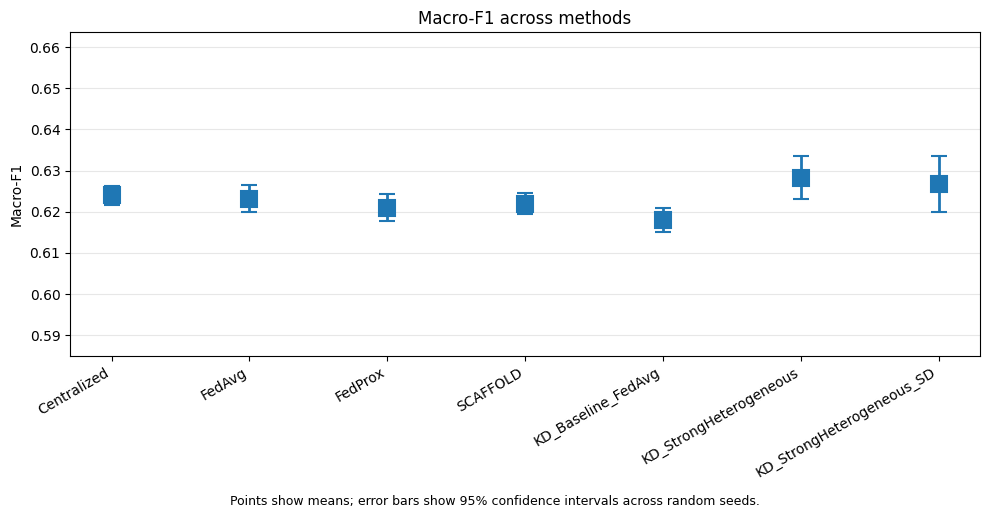

Saved figure: ../History/statistical_rigor/figures/paper_ready/fig_predictive_f1_macro_ci.png


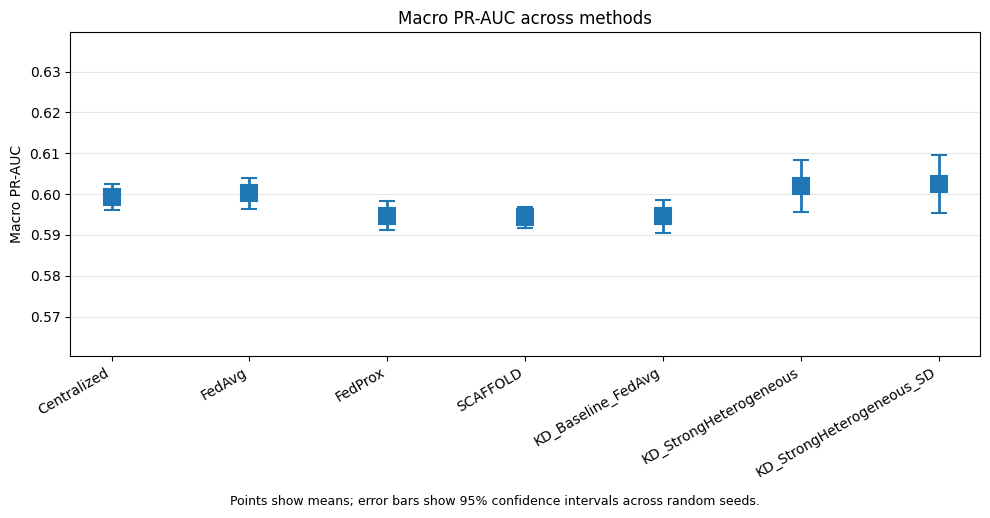

Saved figure: ../History/statistical_rigor/figures/paper_ready/fig_predictive_pr_auc_macro_ci.png


'../History/statistical_rigor/figures/paper_ready/fig_predictive_pr_auc_macro_ci.png'

In [244]:
predictive_summary_for_figures_df = _load_df_from_var_or_csv(
    "predictive_summary_long_df",
    globals().get("PREDICTIVE_SUMMARY_LONG_CSV", None),
)

paper_method_order = [
    "Centralized",
    "FedAvg",
    "FedProx",
    "SCAFFOLD",
    "KD_Baseline_FedAvg",
    "KD_StrongHeterogeneous",
    "KD_StrongHeterogeneous_SD",
]

# Main Macro-F1 figure.
f1_macro_fig_df = _extract_metric_summary_for_plot(
    summary_long_df=predictive_summary_for_figures_df,
    metric="f1_macro",
    group_cols=["experiment_group", "method"],
)

if not f1_macro_fig_df.empty:
    f1_macro_fig_df = f1_macro_fig_df[
        f1_macro_fig_df["experiment_group"].isin(["main_table", "kd_main"])
    ].copy()

plot_metric_ci_bar(
    df=f1_macro_fig_df,
    label_col="method",
    metric_name="f1_macro",
    title="Macro-F1 across methods",
    ylabel="Macro-F1",
    output_path=PAPER_FIGURE_PATHS["predictive_f1_macro"],
    order=paper_method_order,
)

# PR-AUC Macro figure.
pr_auc_macro_fig_df = _extract_metric_summary_for_plot(
    summary_long_df=predictive_summary_for_figures_df,
    metric="pr_auc_macro",
    group_cols=["experiment_group", "method"],
)

if not pr_auc_macro_fig_df.empty:
    pr_auc_macro_fig_df = pr_auc_macro_fig_df[
        pr_auc_macro_fig_df["experiment_group"].isin(["main_table", "kd_main"])
    ].copy()

plot_metric_ci_bar(
    df=pr_auc_macro_fig_df,
    label_col="method",
    metric_name="pr_auc_macro",
    title="Macro PR-AUC across methods",
    ylabel="Macro PR-AUC",
    output_path=PAPER_FIGURE_PATHS["predictive_pr_auc_macro"],
    order=paper_method_order,
)

### 18.3 KD-focused figure

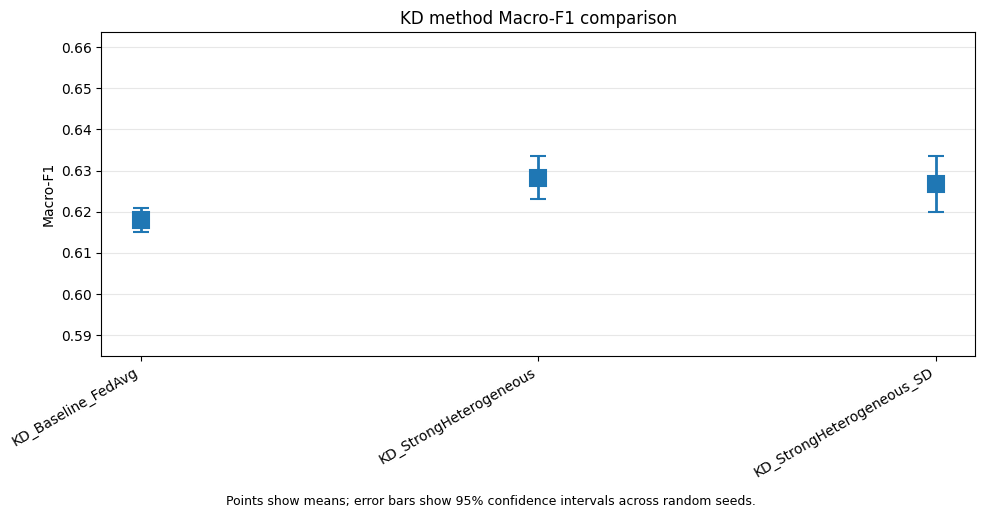

Saved figure: ../History/statistical_rigor/figures/paper_ready/fig_kd_f1_macro_ci.png


'../History/statistical_rigor/figures/paper_ready/fig_kd_f1_macro_ci.png'

In [245]:
kd_f1_fig_df = _extract_metric_summary_for_plot(
    summary_long_df=predictive_summary_for_figures_df,
    metric="f1_macro",
    group_cols=["experiment_group", "method"],
)

if not kd_f1_fig_df.empty:
    kd_f1_fig_df = kd_f1_fig_df[
        kd_f1_fig_df["method"].isin([
            "KD_Baseline_FedAvg",
            "KD_StrongHeterogeneous",
            "KD_StrongHeterogeneous_SD",
        ])
    ].copy()

plot_metric_ci_bar(
    df=kd_f1_fig_df,
    label_col="method",
    metric_name="f1_macro",
    title="KD method Macro-F1 comparison",
    ylabel="Macro-F1",
    output_path=PAPER_FIGURE_PATHS["kd_f1_macro"],
    order=[
        "KD_Baseline_FedAvg",
        "KD_StrongHeterogeneous",
        "KD_StrongHeterogeneous_SD",
    ],
)

### 18.4 Attention/rationale agreement figure

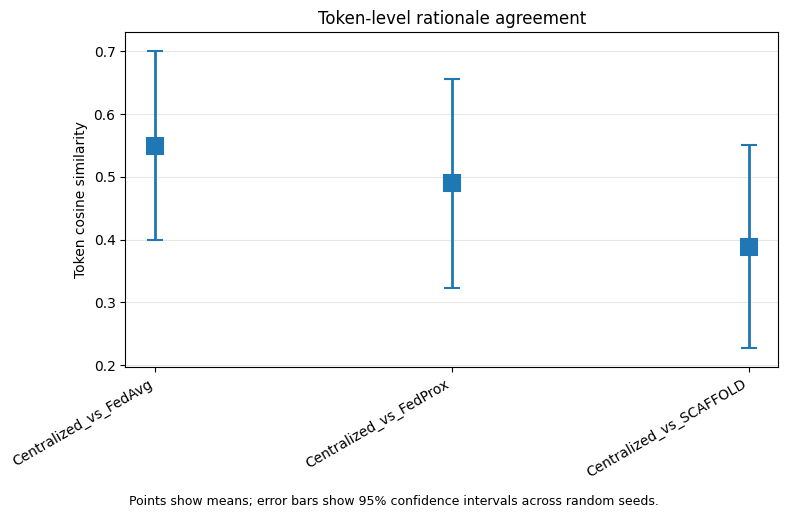

Saved figure: ../History/statistical_rigor/figures/paper_ready/fig_attention_similarity_ci.png


'../History/statistical_rigor/figures/paper_ready/fig_attention_similarity_ci.png'

In [246]:
attention_summary_for_figures_df = _load_df_from_var_or_csv(
    "attention_summary_long_df",
    globals().get("ATTENTION_SUMMARY_LONG_CSV", None),
)

attention_fig_df = _extract_metric_summary_for_plot(
    summary_long_df=attention_summary_for_figures_df,
    metric="token_cosine",
    group_cols=["pair", "mode"],
)

# Keep ONLY the main FL methods
main_attention_pairs = [
    "Centralized_vs_FedAvg",
    "Centralized_vs_FedProx",
    "Centralized_vs_SCAFFOLD",
]

attention_fig_df = attention_fig_df[
    attention_fig_df["pair"].isin(main_attention_pairs)
].copy()

plot_metric_ci_bar(
    df=attention_fig_df,
    label_col="pair",
    metric_name="token_cosine",
    title="Token-level rationale agreement",
    ylabel="Token cosine similarity",
    output_path=PAPER_FIGURE_PATHS["attention_similarity"],
    order=main_attention_pairs,
    figsize=(8, 5),
)

### 18.5 Reliability figure: false-positive rate by agreement bin

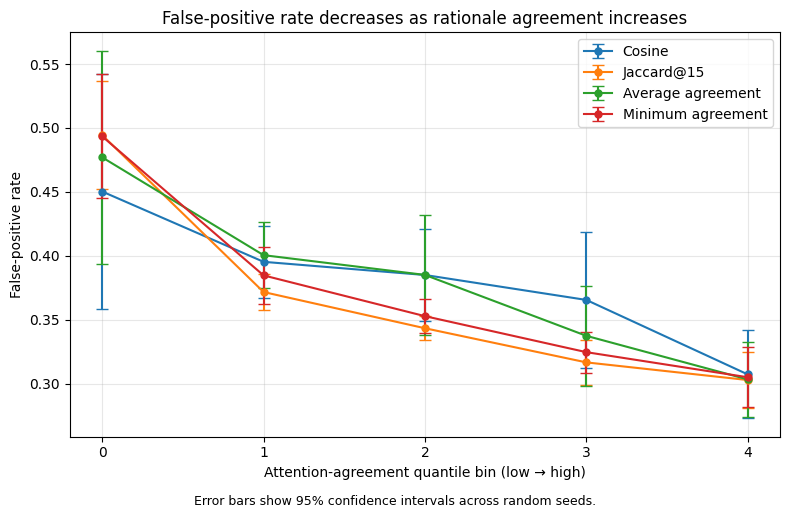

Saved figure: ../History/statistical_rigor/figures/paper_ready/fig_reliability_fp_by_agreement_bin.png


'../History/statistical_rigor/figures/paper_ready/fig_reliability_fp_by_agreement_bin.png'

In [247]:
reliability_bins_for_figures_df = _load_df_from_var_or_csv(
    "reliability_bins_summary_df",
    globals().get("RELIABILITY_BIN_SUMMARY_CSV", None),
)

def plot_reliability_fp_bins(
    df: pd.DataFrame,
    output_path: str,
    agreement_metrics: Optional[List[str]] = None,
    pairs_to_keep: Optional[List[str]] = None,
) -> Optional[str]:
    """
    Plot false-positive rate by attention-agreement quantile bin.

    Shows one line per agreement metric, averaged across the selected model pairs.
    Error bars show 95% confidence intervals across random seeds.
    """
    if df.empty:
        print("[skip figure] No reliability bin summary available.")
        return None

    if agreement_metrics is None:
        agreement_metrics = [
            "cosine",
            "jaccard",
            "avg_agreement",
            "min_agreement",
        ]

    if pairs_to_keep is None:
        pairs_to_keep = [
            "Centralized_vs_FedAvg",
            "Centralized_vs_FedProx",
            "Centralized_vs_SCAFFOLD",
        ]

    plot_df = df.copy()

    if "pair" in plot_df.columns:
        plot_df = plot_df[plot_df["pair"].isin(pairs_to_keep)].copy()

    if "agreement_metric" in plot_df.columns:
        plot_df = plot_df[plot_df["agreement_metric"].isin(agreement_metrics)].copy()

    if "metric" in plot_df.columns:
        plot_df = plot_df[plot_df["metric"] == "fp_rate"].copy()

    plot_df = plot_df.rename(columns={
        "fp_rate_mean": "mean",
        "fp_rate_ci_low": "ci_low",
        "fp_rate_ci_high": "ci_high",
    })

    required = {"agreement_bin", "agreement_metric", "mean", "ci_low", "ci_high"}
    missing = required - set(plot_df.columns)

    if missing:
        print(f"[skip figure] Reliability bin summary missing columns: {missing}")
        return None

    for col in ["agreement_bin", "mean", "ci_low", "ci_high"]:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

    plot_df = plot_df.dropna(
        subset=["agreement_bin", "agreement_metric", "mean", "ci_low", "ci_high"]
    )

    if plot_df.empty:
        print("[skip figure] No reliability bin rows after filtering.")
        return None

    # Average across selected non-KD pairs for each agreement metric/bin.
    # This keeps the figure readable while using all three main FL methods.
    agg_rows = []

    for (agreement_metric, agreement_bin), sub in plot_df.groupby(
        ["agreement_metric", "agreement_bin"],
        dropna=False,
    ):
        means = sub["mean"].astype(float).to_numpy()

        # Use the average of already-computed CI bounds as a visual summary.
        # The statistically exact CI is already in the table; this figure is descriptive.
        ci_low = sub["ci_low"].astype(float).mean()
        ci_high = sub["ci_high"].astype(float).mean()

        agg_rows.append({
            "agreement_metric": agreement_metric,
            "agreement_bin": int(agreement_bin),
            "mean": float(np.mean(means)),
            "ci_low": float(ci_low),
            "ci_high": float(ci_high),
        })

    plot_df = pd.DataFrame(agg_rows).sort_values(["agreement_metric", "agreement_bin"])

    metric_display = {
        "cosine": "Cosine",
        "jaccard": "Jaccard@15",
        "avg_agreement": "Average agreement",
        "min_agreement": "Minimum agreement",
    }

    fig, ax = plt.subplots(figsize=(8, 5))

    for metric in agreement_metrics:
        sub = plot_df[plot_df["agreement_metric"] == metric].copy()

        if sub.empty:
            continue

        sub = sub.sort_values("agreement_bin")

        x = sub["agreement_bin"].astype(int).to_numpy()
        y = sub["mean"].astype(float).to_numpy()
        lower = y - sub["ci_low"].astype(float).to_numpy()
        upper = sub["ci_high"].astype(float).to_numpy() - y

        ax.errorbar(
            x,
            y,
            yerr=np.vstack([lower, upper]),
            marker="o",
            capsize=4,
            linewidth=1.5,
            markersize=5,
            label=metric_display.get(metric, metric),
        )

    ax.set_title("False-positive rate decreases as rationale agreement increases")
    ax.set_xlabel("Attention-agreement quantile bin (low \u2192 high)")
    ax.set_ylabel("False-positive rate")
    ax.set_xticks(sorted(plot_df["agreement_bin"].astype(int).unique()))
    ax.grid(alpha=0.3)
    ax.legend(frameon=True)

    caption = "Error bars show 95% confidence intervals across random seeds."
    fig.text(0.5, -0.02, caption, ha="center", fontsize=9)

    fig.tight_layout()
    ensure_dir(os.path.dirname(output_path))
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", output_path)
    return output_path


plot_reliability_fp_bins(
    df=reliability_bins_for_figures_df,
    output_path=PAPER_FIGURE_PATHS["reliability_fp_bins"],
    agreement_metrics=[
        "cosine",
        "jaccard",
        "avg_agreement",
        "min_agreement",
    ],
    pairs_to_keep=[
        "Centralized_vs_FedAvg",
        "Centralized_vs_FedProx",
        "Centralized_vs_SCAFFOLD",
    ],
)

## 19. Paper-Ready Tables

This section exports final tables for the paper.

Candidate tables:
- Main predictive performance with 95% CIs
- Pairwise statistical tests with p-values and effect sizes
- Attention/rationale alignment with 95% CIs
- Reliability correlation results

Tables should be saved as CSV and optionally printed in LaTeX format.

In [224]:
PAPER_TABLE_DIR = ensure_dir(os.path.join(TABLES_DIR, "paper_ready"))

PAPER_TABLE_PATHS = {
    "predictive_main": os.path.join(PAPER_TABLE_DIR, "paper_table_predictive_main.csv"),
    "predictive_pairwise": os.path.join(PAPER_TABLE_DIR, "paper_table_predictive_pairwise.csv"),
    "attention_alignment": os.path.join(PAPER_TABLE_DIR, "paper_table_attention_alignment.csv"),
    "attention_pairwise": os.path.join(PAPER_TABLE_DIR, "paper_table_attention_pairwise.csv"),
    "reliability_correlations": os.path.join(PAPER_TABLE_DIR, "paper_table_reliability_correlations.csv"),
    "reliability_fp_bins": os.path.join(PAPER_TABLE_DIR, "paper_table_reliability_fp_bins.csv"),
}

print("Paper-ready table directory:", PAPER_TABLE_DIR)
for name, path in PAPER_TABLE_PATHS.items():
    print(f"  {name}: {path}")

Paper-ready table directory: ../History/statistical_rigor/tables/paper_ready
  predictive_main: ../History/statistical_rigor/tables/paper_ready/paper_table_predictive_main.csv
  predictive_pairwise: ../History/statistical_rigor/tables/paper_ready/paper_table_predictive_pairwise.csv
  attention_alignment: ../History/statistical_rigor/tables/paper_ready/paper_table_attention_alignment.csv
  attention_pairwise: ../History/statistical_rigor/tables/paper_ready/paper_table_attention_pairwise.csv
  reliability_correlations: ../History/statistical_rigor/tables/paper_ready/paper_table_reliability_correlations.csv
  reliability_fp_bins: ../History/statistical_rigor/tables/paper_ready/paper_table_reliability_fp_bins.csv


### 19.1 Table export helpers

In [225]:
def save_paper_table(
    df: pd.DataFrame,
    path: str,
    title: str,
    latex_preview: bool = True,
    max_preview_rows: int = 80,
) -> pd.DataFrame:
    """
    Save one paper table and optionally print a LaTeX preview.
    """
    if df is None or df.empty:
        print(f"[skip table] {title}: no rows available.")
        return pd.DataFrame()

    ensure_dir(os.path.dirname(path))
    df.to_csv(path, index=False)

    print(f"Saved {title}:")
    print("  ", path)

    display(df.head(max_preview_rows))

    if latex_preview:
        print("\nLaTeX preview:")
        print(df_to_latex_string(df, index=False, escape=False))

    return df


def rename_metric_columns_for_display(
    df: pd.DataFrame,
    metric_display_map: Dict[str, str],
) -> pd.DataFrame:
    """
    Rename raw metric columns to paper-display names when present.
    """
    if df.empty:
        return df

    rename_map = {
        raw: display
        for raw, display in metric_display_map.items()
        if raw in df.columns
    }

    return df.rename(columns=rename_map)

### 19.2 Main predictive performance table

In [226]:
predictive_main_table_for_paper_df = _load_df_from_var_or_csv(
    "predictive_main_table_df",
    globals().get("PREDICTIVE_MAIN_TABLE_CSV", None),
)

if not predictive_main_table_for_paper_df.empty:
    predictive_main_table_for_paper_df = rename_metric_columns_for_display(
        predictive_main_table_for_paper_df,
        PREDICTIVE_METRIC_DISPLAY_NAMES,
    )

save_paper_table(
    df=predictive_main_table_for_paper_df,
    path=PAPER_TABLE_PATHS["predictive_main"],
    title="paper-ready predictive main table",
    latex_preview=True,
)

Saved paper-ready predictive main table:
   ../History/statistical_rigor/tables/paper_ready/paper_table_predictive_main.csv


,experiment_group,method,AUC Macro,AUC Micro,F1 Macro,F1 Micro,PR-AUC Macro,PR-AUC Micro
0,kd_main,KD_Baseline_FedAvg,0.901 (95% CI: 0.900-0.903),0.918 (95% CI: 0.917-0.920),0.618 (95% CI: 0.615-0.621),0.627 (95% CI: 0.623-0.631),0.595 (95% CI: 0.590-0.599),0.645 (95% CI: 0.639-0.651)
1,kd_main,KD_StrongHeterogeneous,0.905 (95% CI: 0.903-0.907),0.922 (95% CI: 0.919-0.924),0.628 (95% CI: 0.623-0.634),0.636 (95% CI: 0.629-0.643),0.602 (95% CI: 0.596-0.608),0.657 (95% CI: 0.650-0.665)
2,kd_main,KD_StrongHeterogeneous_SD,0.904 (95% CI: 0.901-0.907),0.925 (95% CI: 0.923-0.927),0.627 (95% CI: 0.620-0.634),0.632 (95% CI: 0.625-0.639),0.602 (95% CI: 0.595-0.610),0.671 (95% CI: 0.665-0.677)
3,main_table,Centralized,0.903 (95% CI: 0.902-0.904),0.921 (95% CI: 0.920-0.921),0.624 (95% CI: 0.622-0.626),0.634 (95% CI: 0.630-0.638),0.599 (95% CI: 0.596-0.602),0.654 (95% CI: 0.651-0.657)
4,main_table,FedAvg,0.903 (95% CI: 0.902-0.905),0.921 (95% CI: 0.920-0.922),0.623 (95% CI: 0.620-0.627),0.633 (95% CI: 0.628-0.639),0.600 (95% CI: 0.596-0.604),0.655 (95% CI: 0.651-0.660)
5,main_table,FedProx,0.902 (95% CI: 0.901-0.904),0.920 (95% CI: 0.919-0.921),0.621 (95% CI: 0.618-0.624),0.630 (95% CI: 0.623-0.636),0.595 (95% CI: 0.591-0.598),0.649 (95% CI: 0.645-0.653)
6,main_table,SCAFFOLD,0.902 (95% CI: 0.901-0.902),0.919 (95% CI: 0.918-0.920),0.622 (95% CI: 0.620-0.624),0.627 (95% CI: 0.624-0.631),0.594 (95% CI: 0.592-0.597),0.650 (95% CI: 0.646-0.653)



LaTeX preview:
\begin{tabular}{llllllll}
\toprule
experiment_group & method & AUC Macro & AUC Micro & F1 Macro & F1 Micro & PR-AUC Macro & PR-AUC Micro \\
\midrule
kd_main & KD_Baseline_FedAvg & 0.901 (95% CI: 0.900-0.903) & 0.918 (95% CI: 0.917-0.920) & 0.618 (95% CI: 0.615-0.621) & 0.627 (95% CI: 0.623-0.631) & 0.595 (95% CI: 0.590-0.599) & 0.645 (95% CI: 0.639-0.651) \\
kd_main & KD_StrongHeterogeneous & 0.905 (95% CI: 0.903-0.907) & 0.922 (95% CI: 0.919-0.924) & 0.628 (95% CI: 0.623-0.634) & 0.636 (95% CI: 0.629-0.643) & 0.602 (95% CI: 0.596-0.608) & 0.657 (95% CI: 0.650-0.665) \\
kd_main & KD_StrongHeterogeneous_SD & 0.904 (95% CI: 0.901-0.907) & 0.925 (95% CI: 0.923-0.927) & 0.627 (95% CI: 0.620-0.634) & 0.632 (95% CI: 0.625-0.639) & 0.602 (95% CI: 0.595-0.610) & 0.671 (95% CI: 0.665-0.677) \\
main_table & Centralized & 0.903 (95% CI: 0.902-0.904) & 0.921 (95% CI: 0.920-0.921) & 0.624 (95% CI: 0.622-0.626) & 0.634 (95% CI: 0.630-0.638) & 0.599 (95% CI: 0.596-0.602) & 0.654 (95% 

,experiment_group,method,AUC Macro,AUC Micro,F1 Macro,F1 Micro,PR-AUC Macro,PR-AUC Micro
0,kd_main,KD_Baseline_FedAvg,0.901 (95% CI: 0.900-0.903),0.918 (95% CI: 0.917-0.920),0.618 (95% CI: 0.615-0.621),0.627 (95% CI: 0.623-0.631),0.595 (95% CI: 0.590-0.599),0.645 (95% CI: 0.639-0.651)
1,kd_main,KD_StrongHeterogeneous,0.905 (95% CI: 0.903-0.907),0.922 (95% CI: 0.919-0.924),0.628 (95% CI: 0.623-0.634),0.636 (95% CI: 0.629-0.643),0.602 (95% CI: 0.596-0.608),0.657 (95% CI: 0.650-0.665)
2,kd_main,KD_StrongHeterogeneous_SD,0.904 (95% CI: 0.901-0.907),0.925 (95% CI: 0.923-0.927),0.627 (95% CI: 0.620-0.634),0.632 (95% CI: 0.625-0.639),0.602 (95% CI: 0.595-0.610),0.671 (95% CI: 0.665-0.677)
3,main_table,Centralized,0.903 (95% CI: 0.902-0.904),0.921 (95% CI: 0.920-0.921),0.624 (95% CI: 0.622-0.626),0.634 (95% CI: 0.630-0.638),0.599 (95% CI: 0.596-0.602),0.654 (95% CI: 0.651-0.657)
4,main_table,FedAvg,0.903 (95% CI: 0.902-0.905),0.921 (95% CI: 0.920-0.922),0.623 (95% CI: 0.620-0.627),0.633 (95% CI: 0.628-0.639),0.600 (95% CI: 0.596-0.604),0.655 (95% CI: 0.651-0.660)
5,main_table,FedProx,0.902 (95% CI: 0.901-0.904),0.920 (95% CI: 0.919-0.921),0.621 (95% CI: 0.618-0.624),0.630 (95% CI: 0.623-0.636),0.595 (95% CI: 0.591-0.598),0.649 (95% CI: 0.645-0.653)
6,main_table,SCAFFOLD,0.902 (95% CI: 0.901-0.902),0.919 (95% CI: 0.918-0.920),0.622 (95% CI: 0.620-0.624),0.627 (95% CI: 0.624-0.631),0.594 (95% CI: 0.592-0.597),0.650 (95% CI: 0.646-0.653)


### 19.3 Predictive pairwise statistical-test table


In [227]:
predictive_pairwise_for_paper_df = _load_df_from_var_or_csv(
    "predictive_pairwise_formatted_df",
    globals().get("PREDICTIVE_PAIRWISE_TESTS_FORMATTED_CSV", None),
)

save_paper_table(
    df=predictive_pairwise_for_paper_df,
    path=PAPER_TABLE_PATHS["predictive_pairwise"],
    title="paper-ready predictive pairwise table",
    latex_preview=True,
)

Saved paper-ready predictive pairwise table:
   ../History/statistical_rigor/tables/paper_ready/paper_table_predictive_pairwise.csv


,Comparison,Metric,n,Mean left,Mean right,Mean diff,t-test,p,p Holm,Cohen dz,Effect,Sig.
0,FedProx vs FedAvg,AUC Macro,10,0.903,0.902,-0.001,t(9) = -1.095,0.302,1.000,-0.346,small,
1,FedProx vs FedAvg,AUC Micro,10,0.921,0.920,-0.001,t(9) = -1.275,0.234,1.000,-0.403,small,
2,FedProx vs FedAvg,F1 Macro,10,0.623,0.621,-0.002,t(9) = -0.970,0.357,1.000,-0.307,small,
3,FedProx vs FedAvg,F1 Micro,10,0.633,0.630,-0.004,t(9) = -0.976,0.355,1.000,-0.309,small,
4,FedProx vs FedAvg,PR-AUC Macro,10,0.600,0.595,-0.005,t(9) = -2.343,0.044,1.000,-0.741,medium,
5,FedProx vs FedAvg,PR-AUC Micro,10,0.655,0.649,-0.006,t(9) = -2.479,0.035,0.876,-0.784,medium,
6,SCAFFOLD vs FedAvg,AUC Macro,10,0.903,0.902,-0.002,t(9) = -2.920,0.017,0.511,-0.923,large,
7,SCAFFOLD vs FedAvg,AUC Micro,10,0.921,0.919,-0.002,t(9) = -3.818,0.004,0.148,-1.207,large,
8,SCAFFOLD vs FedAvg,F1 Macro,10,0.623,0.622,-0.001,t(9) = -0.676,0.516,1.000,-0.214,small,
9,SCAFFOLD vs FedAvg,F1 Micro,10,0.633,0.627,-0.006,t(9) = -2.063,0.069,1.000,-0.652,medium,



LaTeX preview:
\begin{tabular}{llrlllllllll}
\toprule
Comparison & Metric & n & Mean left & Mean right & Mean diff & t-test & p & p Holm & Cohen dz & Effect & Sig. \\
\midrule
FedProx vs FedAvg & AUC Macro & 10 & 0.903 & 0.902 & -0.001 & t(9) = -1.095 & 0.302 & 1.000 & -0.346 & small &  \\
FedProx vs FedAvg & AUC Micro & 10 & 0.921 & 0.920 & -0.001 & t(9) = -1.275 & 0.234 & 1.000 & -0.403 & small &  \\
FedProx vs FedAvg & F1 Macro & 10 & 0.623 & 0.621 & -0.002 & t(9) = -0.970 & 0.357 & 1.000 & -0.307 & small &  \\
FedProx vs FedAvg & F1 Micro & 10 & 0.633 & 0.630 & -0.004 & t(9) = -0.976 & 0.355 & 1.000 & -0.309 & small &  \\
FedProx vs FedAvg & PR-AUC Macro & 10 & 0.600 & 0.595 & -0.005 & t(9) = -2.343 & 0.044 & 1.000 & -0.741 & medium &  \\
FedProx vs FedAvg & PR-AUC Micro & 10 & 0.655 & 0.649 & -0.006 & t(9) = -2.479 & 0.035 & 0.876 & -0.784 & medium &  \\
SCAFFOLD vs FedAvg & AUC Macro & 10 & 0.903 & 0.902 & -0.002 & t(9) = -2.920 & 0.017 & 0.511 & -0.923 & large &  \\
SCAFFOLD vs

,Comparison,Metric,n,Mean left,Mean right,Mean diff,t-test,p,p Holm,Cohen dz,Effect,Sig.
0,FedProx vs FedAvg,AUC Macro,10,0.903,0.902,-0.001,t(9) = -1.095,0.302,1.000,-0.346,small,
1,FedProx vs FedAvg,AUC Micro,10,0.921,0.920,-0.001,t(9) = -1.275,0.234,1.000,-0.403,small,
2,FedProx vs FedAvg,F1 Macro,10,0.623,0.621,-0.002,t(9) = -0.970,0.357,1.000,-0.307,small,
3,FedProx vs FedAvg,F1 Micro,10,0.633,0.630,-0.004,t(9) = -0.976,0.355,1.000,-0.309,small,
4,FedProx vs FedAvg,PR-AUC Macro,10,0.600,0.595,-0.005,t(9) = -2.343,0.044,1.000,-0.741,medium,
5,FedProx vs FedAvg,PR-AUC Micro,10,0.655,0.649,-0.006,t(9) = -2.479,0.035,0.876,-0.784,medium,
6,SCAFFOLD vs FedAvg,AUC Macro,10,0.903,0.902,-0.002,t(9) = -2.920,0.017,0.511,-0.923,large,
7,SCAFFOLD vs FedAvg,AUC Micro,10,0.921,0.919,-0.002,t(9) = -3.818,0.004,0.148,-1.207,large,
8,SCAFFOLD vs FedAvg,F1 Macro,10,0.623,0.622,-0.001,t(9) = -0.676,0.516,1.000,-0.214,small,
9,SCAFFOLD vs FedAvg,F1 Micro,10,0.633,0.627,-0.006,t(9) = -2.063,0.069,1.000,-0.652,medium,


### 19.4 Attention/rationale alignment table

In [228]:
attention_alignment_for_paper_df = _load_df_from_var_or_csv(
    "attention_summary_wide_df",
    globals().get("ATTENTION_SUMMARY_WIDE_CSV", None),
)

if not attention_alignment_for_paper_df.empty:
    attention_alignment_for_paper_df = rename_metric_columns_for_display(
        attention_alignment_for_paper_df,
        ATTENTION_METRIC_DISPLAY_NAMES,
    )

save_paper_table(
    df=attention_alignment_for_paper_df,
    path=PAPER_TABLE_PATHS["attention_alignment"],
    title="paper-ready attention/rationale alignment table",
    latex_preview=True,
)

Saved paper-ready attention/rationale alignment table:
   ../History/statistical_rigor/tables/paper_ready/paper_table_attention_alignment.csv


,pair,model_a,model_b,mode,Token Cosine,Jaccard@15,Phrase Top-1 IoU,Phrase Top-5 Max IoU,Phrase Weighted IoU,Phrase Unweighted IoU,Phrase Rank-Aware IoU,False-Positive Rate
0,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,0.550 (95% CI: 0.399-0.701),0.222 (95% CI: 0.169-0.274),0.424 (95% CI: 0.417-0.431),0.878 (95% CI: 0.864-0.891),0.606 (95% CI: 0.598-0.614),0.482 (95% CI: 0.476-0.487),0.313 (95% CI: 0.310-0.317),0.376 (95% CI: 0.367-0.386)
1,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,0.490 (95% CI: 0.323-0.657),0.194 (95% CI: 0.135-0.253),0.415 (95% CI: 0.392-0.438),0.868 (95% CI: 0.829-0.907),0.596 (95% CI: 0.565-0.627),0.472 (95% CI: 0.448-0.496),0.306 (95% CI: 0.289-0.322),0.382 (95% CI: 0.371-0.392)
2,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,0.480 (95% CI: 0.324-0.636),0.191 (95% CI: 0.134-0.247),0.410 (95% CI: 0.396-0.423),0.866 (95% CI: 0.843-0.889),0.591 (95% CI: 0.572-0.610),0.469 (95% CI: 0.455-0.483),0.303 (95% CI: 0.293-0.313),0.382 (95% CI: 0.373-0.390)
3,Centralized_vs_KD_StrongHeterogeneous,Centralized,KD_StrongHeterogeneous,agree_positive,0.459 (95% CI: 0.289-0.629),0.188 (95% CI: 0.127-0.249),0.423 (95% CI: 0.413-0.432),0.869 (95% CI: 0.848-0.890),0.601 (95% CI: 0.586-0.616),0.482 (95% CI: 0.470-0.494),0.315 (95% CI: 0.307-0.322),0.381 (95% CI: 0.369-0.393)
4,Centralized_vs_KD_StrongHeterogeneous_SD,Centralized,KD_StrongHeterogeneous_SD,agree_positive,0.519 (95% CI: 0.358-0.680),0.211 (95% CI: 0.152-0.269),0.424 (95% CI: 0.413-0.436),0.872 (95% CI: 0.850-0.894),0.602 (95% CI: 0.586-0.618),0.483 (95% CI: 0.471-0.496),0.316 (95% CI: 0.307-0.324),0.383 (95% CI: 0.374-0.392)
5,Centralized_vs_SCAFFOLD,Centralized,SCAFFOLD,agree_positive,0.389 (95% CI: 0.227-0.551),0.166 (95% CI: 0.108-0.223),0.411 (95% CI: 0.398-0.424),0.859 (95% CI: 0.832-0.886),0.596 (95% CI: 0.578-0.615),0.470 (95% CI: 0.455-0.485),0.304 (95% CI: 0.295-0.314),0.384 (95% CI: 0.374-0.395)



LaTeX preview:
\begin{tabular}{llllllllllll}
\toprule
pair & model_a & model_b & mode & Token Cosine & Jaccard@15 & Phrase Top-1 IoU & Phrase Top-5 Max IoU & Phrase Weighted IoU & Phrase Unweighted IoU & Phrase Rank-Aware IoU & False-Positive Rate \\
\midrule
Centralized_vs_FedAvg & Centralized & FedAvg & agree_positive & 0.550 (95% CI: 0.399-0.701) & 0.222 (95% CI: 0.169-0.274) & 0.424 (95% CI: 0.417-0.431) & 0.878 (95% CI: 0.864-0.891) & 0.606 (95% CI: 0.598-0.614) & 0.482 (95% CI: 0.476-0.487) & 0.313 (95% CI: 0.310-0.317) & 0.376 (95% CI: 0.367-0.386) \\
Centralized_vs_FedProx & Centralized & FedProx & agree_positive & 0.490 (95% CI: 0.323-0.657) & 0.194 (95% CI: 0.135-0.253) & 0.415 (95% CI: 0.392-0.438) & 0.868 (95% CI: 0.829-0.907) & 0.596 (95% CI: 0.565-0.627) & 0.472 (95% CI: 0.448-0.496) & 0.306 (95% CI: 0.289-0.322) & 0.382 (95% CI: 0.371-0.392) \\
Centralized_vs_KD_Baseline_FedAvg & Centralized & KD_Baseline_FedAvg & agree_positive & 0.480 (95% CI: 0.324-0.636) & 0.191 (95

,pair,model_a,model_b,mode,Token Cosine,Jaccard@15,Phrase Top-1 IoU,Phrase Top-5 Max IoU,Phrase Weighted IoU,Phrase Unweighted IoU,Phrase Rank-Aware IoU,False-Positive Rate
0,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,0.550 (95% CI: 0.399-0.701),0.222 (95% CI: 0.169-0.274),0.424 (95% CI: 0.417-0.431),0.878 (95% CI: 0.864-0.891),0.606 (95% CI: 0.598-0.614),0.482 (95% CI: 0.476-0.487),0.313 (95% CI: 0.310-0.317),0.376 (95% CI: 0.367-0.386)
1,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,0.490 (95% CI: 0.323-0.657),0.194 (95% CI: 0.135-0.253),0.415 (95% CI: 0.392-0.438),0.868 (95% CI: 0.829-0.907),0.596 (95% CI: 0.565-0.627),0.472 (95% CI: 0.448-0.496),0.306 (95% CI: 0.289-0.322),0.382 (95% CI: 0.371-0.392)
2,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,0.480 (95% CI: 0.324-0.636),0.191 (95% CI: 0.134-0.247),0.410 (95% CI: 0.396-0.423),0.866 (95% CI: 0.843-0.889),0.591 (95% CI: 0.572-0.610),0.469 (95% CI: 0.455-0.483),0.303 (95% CI: 0.293-0.313),0.382 (95% CI: 0.373-0.390)
3,Centralized_vs_KD_StrongHeterogeneous,Centralized,KD_StrongHeterogeneous,agree_positive,0.459 (95% CI: 0.289-0.629),0.188 (95% CI: 0.127-0.249),0.423 (95% CI: 0.413-0.432),0.869 (95% CI: 0.848-0.890),0.601 (95% CI: 0.586-0.616),0.482 (95% CI: 0.470-0.494),0.315 (95% CI: 0.307-0.322),0.381 (95% CI: 0.369-0.393)
4,Centralized_vs_KD_StrongHeterogeneous_SD,Centralized,KD_StrongHeterogeneous_SD,agree_positive,0.519 (95% CI: 0.358-0.680),0.211 (95% CI: 0.152-0.269),0.424 (95% CI: 0.413-0.436),0.872 (95% CI: 0.850-0.894),0.602 (95% CI: 0.586-0.618),0.483 (95% CI: 0.471-0.496),0.316 (95% CI: 0.307-0.324),0.383 (95% CI: 0.374-0.392)
5,Centralized_vs_SCAFFOLD,Centralized,SCAFFOLD,agree_positive,0.389 (95% CI: 0.227-0.551),0.166 (95% CI: 0.108-0.223),0.411 (95% CI: 0.398-0.424),0.859 (95% CI: 0.832-0.886),0.596 (95% CI: 0.578-0.615),0.470 (95% CI: 0.455-0.485),0.304 (95% CI: 0.295-0.314),0.384 (95% CI: 0.374-0.395)


### 19.5 Attention pairwise statistical-test table

In [229]:
attention_pairwise_for_paper_df = _load_df_from_var_or_csv(
    "attention_pairwise_formatted_df",
    globals().get("ATTENTION_PAIRWISE_TESTS_FORMATTED_CSV", None),
)

save_paper_table(
    df=attention_pairwise_for_paper_df,
    path=PAPER_TABLE_PATHS["attention_pairwise"],
    title="paper-ready attention pairwise table",
    latex_preview=True,
)

Saved paper-ready attention pairwise table:
   ../History/statistical_rigor/tables/paper_ready/paper_table_attention_pairwise.csv


,Comparison,Metric,n,Mean left,Mean right,Mean diff,t-test,p,p Holm,Cohen dz,Effect,Sig.
0,Centralized-vs-FedProx alignment vs Centralize...,Token Cosine,10,0.550,0.490,-0.060,t(9) = -0.731,0.483,1.000,-0.231,small,
1,Centralized-vs-FedProx alignment vs Centralize...,Jaccard@15,10,0.222,0.194,-0.028,t(9) = -0.976,0.355,1.000,-0.309,small,
2,Centralized-vs-FedProx alignment vs Centralize...,Phrase Top-1 IoU,10,0.424,0.415,-0.009,t(9) = -0.940,0.372,1.000,-0.297,small,
3,Centralized-vs-FedProx alignment vs Centralize...,Phrase Top-5 Max IoU,10,0.878,0.868,-0.010,t(9) = -0.653,0.530,1.000,-0.207,small,
4,Centralized-vs-FedProx alignment vs Centralize...,Phrase Weighted IoU,10,0.606,0.596,-0.010,t(9) = -0.760,0.467,1.000,-0.240,small,
5,Centralized-vs-FedProx alignment vs Centralize...,Phrase Unweighted IoU,10,0.482,0.472,-0.010,t(9) = -0.998,0.344,1.000,-0.316,small,
6,Centralized-vs-FedProx alignment vs Centralize...,Phrase Rank-Aware IoU,10,0.313,0.306,-0.008,t(9) = -1.096,0.301,1.000,-0.347,small,
7,Centralized-vs-FedProx alignment vs Centralize...,False-Positive Rate,10,0.376,0.382,0.005,t(9) = 1.287,0.230,1.000,0.407,small,
8,Centralized-vs-SCAFFOLD alignment vs Centraliz...,Token Cosine,10,0.550,0.389,-0.161,t(9) = -1.339,0.213,1.000,-0.424,small,
9,Centralized-vs-SCAFFOLD alignment vs Centraliz...,Jaccard@15,10,0.222,0.166,-0.056,t(9) = -1.333,0.215,1.000,-0.421,small,



LaTeX preview:
\begin{tabular}{llrlllllllll}
\toprule
Comparison & Metric & n & Mean left & Mean right & Mean diff & t-test & p & p Holm & Cohen dz & Effect & Sig. \\
\midrule
Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg & Token Cosine & 10 & 0.550 & 0.490 & -0.060 & t(9) = -0.731 & 0.483 & 1.000 & -0.231 & small &  \\
Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg & Jaccard@15 & 10 & 0.222 & 0.194 & -0.028 & t(9) = -0.976 & 0.355 & 1.000 & -0.309 & small &  \\
Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg & Phrase Top-1 IoU & 10 & 0.424 & 0.415 & -0.009 & t(9) = -0.940 & 0.372 & 1.000 & -0.297 & small &  \\
Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg & Phrase Top-5 Max IoU & 10 & 0.878 & 0.868 & -0.010 & t(9) = -0.653 & 0.530 & 1.000 & -0.207 & small &  \\
Centralized-vs-FedProx alignment vs Centralized-vs-FedAvg & Phrase Weighted IoU & 10 & 0.606 & 0.596 & -0.010 & t(9) = -0.760 & 0.467 & 1.000 & -0.240 & small &  \\
Centralized-vs-F

,Comparison,Metric,n,Mean left,Mean right,Mean diff,t-test,p,p Holm,Cohen dz,Effect,Sig.
0,Centralized-vs-FedProx alignment vs Centralize...,Token Cosine,10,0.550,0.490,-0.060,t(9) = -0.731,0.483,1.000,-0.231,small,
1,Centralized-vs-FedProx alignment vs Centralize...,Jaccard@15,10,0.222,0.194,-0.028,t(9) = -0.976,0.355,1.000,-0.309,small,
2,Centralized-vs-FedProx alignment vs Centralize...,Phrase Top-1 IoU,10,0.424,0.415,-0.009,t(9) = -0.940,0.372,1.000,-0.297,small,
3,Centralized-vs-FedProx alignment vs Centralize...,Phrase Top-5 Max IoU,10,0.878,0.868,-0.010,t(9) = -0.653,0.530,1.000,-0.207,small,
4,Centralized-vs-FedProx alignment vs Centralize...,Phrase Weighted IoU,10,0.606,0.596,-0.010,t(9) = -0.760,0.467,1.000,-0.240,small,
5,Centralized-vs-FedProx alignment vs Centralize...,Phrase Unweighted IoU,10,0.482,0.472,-0.010,t(9) = -0.998,0.344,1.000,-0.316,small,
6,Centralized-vs-FedProx alignment vs Centralize...,Phrase Rank-Aware IoU,10,0.313,0.306,-0.008,t(9) = -1.096,0.301,1.000,-0.347,small,
7,Centralized-vs-FedProx alignment vs Centralize...,False-Positive Rate,10,0.376,0.382,0.005,t(9) = 1.287,0.230,1.000,0.407,small,
8,Centralized-vs-SCAFFOLD alignment vs Centraliz...,Token Cosine,10,0.550,0.389,-0.161,t(9) = -1.339,0.213,1.000,-0.424,small,
9,Centralized-vs-SCAFFOLD alignment vs Centraliz...,Jaccard@15,10,0.222,0.166,-0.056,t(9) = -1.333,0.215,1.000,-0.421,small,


### 19.6 Reliability tables

In [230]:
reliability_corr_for_paper_df = _load_df_from_var_or_csv(
    "reliability_corr_summary_df",
    globals().get("RELIABILITY_CORR_SUMMARY_CSV", None),
)

save_paper_table(
    df=reliability_corr_for_paper_df,
    path=PAPER_TABLE_PATHS["reliability_correlations"],
    title="paper-ready reliability correlation table",
    latex_preview=True,
)

reliability_bins_for_paper_df = _load_df_from_var_or_csv(
    "reliability_bins_summary_df",
    globals().get("RELIABILITY_BIN_SUMMARY_CSV", None),
)

save_paper_table(
    df=reliability_bins_for_paper_df,
    path=PAPER_TABLE_PATHS["reliability_fp_bins"],
    title="paper-ready reliability bin table",
    latex_preview=False,
)

Saved paper-ready reliability correlation table:
   ../History/statistical_rigor/tables/paper_ready/paper_table_reliability_correlations.csv


,pair,model_a,model_b,mode,agreement_metric,agreement_metric_display,pearson_n_seeds,pearson_mean_r,pearson_ci_low,pearson_ci_high,...,spearman_mean_rho,spearman_ci_low,spearman_ci_high,spearman_t_value,spearman_df,spearman_p_value,pearson_p_value_adjusted,pearson_reject_null_adjusted,spearman_p_value_adjusted,spearman_reject_null_adjusted
0,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,Average Agreement,10,-0.196519,-0.274676,-0.115782,...,-0.170795,-0.242485,-0.097250,-5.207556,9,5.583925e-04,0.004935,True,0.006701,True
1,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,cosine,Token Cosine,10,-0.174271,-0.256533,-0.089503,...,-0.150259,-0.230598,-0.067886,-4.106005,9,2.652793e-03,0.013918,True,0.029181,True
2,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,jaccard,Jaccard@15,10,-0.161346,-0.205706,-0.116324,...,-0.167519,-0.212186,-0.122153,-8.254311,9,1.722351e-05,0.000369,True,0.000293,True
3,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,min_agreement,Minimum Agreement,10,-0.153891,-0.203915,-0.103065,...,-0.158492,-0.208603,-0.107550,-6.970734,9,6.532725e-05,0.001041,True,0.000849,True
4,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,avg_agreement,Average Agreement,10,-0.129189,-0.202718,-0.054211,...,-0.112019,-0.192251,-0.030299,-3.096411,9,1.279637e-02,0.029634,True,0.086516,False
5,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,cosine,Token Cosine,10,-0.097572,-0.182158,-0.011552,...,-0.084135,-0.178001,0.011247,-1.995960,9,7.705298e-02,0.091328,False,0.231159,False
6,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,jaccard,Jaccard@15,10,-0.135064,-0.167502,-0.102335,...,-0.145356,-0.179665,-0.110694,-9.396532,9,5.992304e-06,0.000135,True,0.000108,True
7,Centralized_vs_FedProx,Centralized,FedProx,agree_positive,min_agreement,Minimum Agreement,10,-0.122348,-0.159451,-0.084901,...,-0.130917,-0.169627,-0.091803,-7.519824,9,3.616803e-05,0.000607,True,0.000506,True
8,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,avg_agreement,Average Agreement,10,-0.149828,-0.239418,-0.057707,...,-0.128789,-0.219823,-0.035532,-3.117952,9,1.235936e-02,0.032898,True,0.086516,False
9,Centralized_vs_KD_Baseline_FedAvg,Centralized,KD_Baseline_FedAvg,agree_positive,cosine,Token Cosine,10,-0.111043,-0.213984,-0.005663,...,-0.092462,-0.200257,0.017544,-1.902218,9,8.956985e-02,0.091328,False,0.231159,False



LaTeX preview:
\begin{tabular}{llllllrrrrrrrrrrrrrrrrrr}
\toprule
pair & model_a & model_b & mode & agreement_metric & agreement_metric_display & pearson_n_seeds & pearson_mean_r & pearson_ci_low & pearson_ci_high & pearson_t_value & pearson_df & pearson_p_value & spearman_n_seeds & spearman_mean_rho & spearman_ci_low & spearman_ci_high & spearman_t_value & spearman_df & spearman_p_value & pearson_p_value_adjusted & pearson_reject_null_adjusted & spearman_p_value_adjusted & spearman_reject_null_adjusted \\
\midrule
Centralized_vs_FedAvg & Centralized & FedAvg & agree_positive & avg_agreement & Average Agreement & 10 & -0.196519 & -0.274676 & -0.115782 & -5.439458 & 9 & 0.000411 & 10 & -0.170795 & -0.242485 & -0.097250 & -5.207556 & 9 & 0.000558 & 0.004935 & True & 0.006701 & True \\
Centralized_vs_FedAvg & Centralized & FedAvg & agree_positive & cosine & Token Cosine & 10 & -0.174271 & -0.256533 & -0.089503 & -4.613877 & 9 & 0.001265 & 10 & -0.150259 & -0.230598 & -0.067886 & -4.10600

,pair,model_a,model_b,mode,agreement_metric,agreement_bin,agreement_metric_display,n_seeds,fp_rate_mean,fp_rate_ci_low,fp_rate_ci_high,fp_rate_formatted,tp_rate_mean,tp_rate_ci_low,tp_rate_ci_high,agreement_mean,agreement_ci_low,agreement_ci_high,total_cases
0,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,0,Average Agreement,10,0.535379,0.447844,0.622913,0.535 (95% CI: 0.448-0.623),0.464621,0.377087,0.552156,0.146660,0.083252,0.210068,22557
1,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,1,Average Agreement,10,0.385106,0.369509,0.400702,0.385 (95% CI: 0.370-0.401),0.614894,0.599298,0.630491,0.316376,0.197723,0.435029,22551
2,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,2,Average Agreement,10,0.355834,0.315009,0.396659,0.356 (95% CI: 0.315-0.397),0.644166,0.603341,0.684991,0.403094,0.277461,0.528727,22550
3,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,3,Average Agreement,10,0.317008,0.290415,0.343602,0.317 (95% CI: 0.290-0.344),0.682992,0.656398,0.709585,0.474085,0.360418,0.587752,22551
4,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,4,Average Agreement,10,0.288364,0.256930,0.319798,0.288 (95% CI: 0.257-0.320),0.711636,0.680202,0.743070,0.588575,0.498382,0.678769,22556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,Centralized_vs_KD_StrongHeterogeneous,Centralized,KD_StrongHeterogeneous,agree_positive,min_agreement,0,Minimum Agreement,10,0.508532,0.449084,0.567981,0.509 (95% CI: 0.449-0.568),0.491468,0.432019,0.550916,0.034999,0.008564,0.061434,24422
76,Centralized_vs_KD_StrongHeterogeneous,Centralized,KD_StrongHeterogeneous,agree_positive,min_agreement,1,Minimum Agreement,10,0.386783,0.365196,0.408370,0.387 (95% CI: 0.365-0.408),0.613217,0.591630,0.634804,0.109395,0.049301,0.169490,25224
77,Centralized_vs_KD_StrongHeterogeneous,Centralized,KD_StrongHeterogeneous,agree_positive,min_agreement,2,Minimum Agreement,10,0.361403,0.342650,0.380155,0.361 (95% CI: 0.343-0.380),0.638597,0.619845,0.657350,0.176471,0.100287,0.252655,23999
78,Centralized_vs_KD_StrongHeterogeneous,Centralized,KD_StrongHeterogeneous,agree_positive,min_agreement,3,Minimum Agreement,10,0.326350,0.312675,0.340025,0.326 (95% CI: 0.313-0.340),0.673650,0.659975,0.687325,0.254582,0.167241,0.341923,21512


,pair,model_a,model_b,mode,agreement_metric,agreement_bin,agreement_metric_display,n_seeds,fp_rate_mean,fp_rate_ci_low,fp_rate_ci_high,fp_rate_formatted,tp_rate_mean,tp_rate_ci_low,tp_rate_ci_high,agreement_mean,agreement_ci_low,agreement_ci_high,total_cases
0,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,0,Average Agreement,10,0.535379,0.447844,0.622913,0.535 (95% CI: 0.448-0.623),0.464621,0.377087,0.552156,0.146660,0.083252,0.210068,22557
1,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,1,Average Agreement,10,0.385106,0.369509,0.400702,0.385 (95% CI: 0.370-0.401),0.614894,0.599298,0.630491,0.316376,0.197723,0.435029,22551
2,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,2,Average Agreement,10,0.355834,0.315009,0.396659,0.356 (95% CI: 0.315-0.397),0.644166,0.603341,0.684991,0.403094,0.277461,0.528727,22550
3,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,3,Average Agreement,10,0.317008,0.290415,0.343602,0.317 (95% CI: 0.290-0.344),0.682992,0.656398,0.709585,0.474085,0.360418,0.587752,22551
4,Centralized_vs_FedAvg,Centralized,FedAvg,agree_positive,avg_agreement,4,Average Agreement,10,0.288364,0.256930,0.319798,0.288 (95% CI: 0.257-0.320),0.711636,0.680202,0.743070,0.588575,0.498382,0.678769,22556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Centralized_vs_SCAFFOLD,Centralized,SCAFFOLD,agree_positive,min_agreement,0,Minimum Agreement,10,0.492091,0.445436,0.538746,0.492 (95% CI: 0.445-0.539),0.507909,0.461254,0.554564,0.026999,-0.004054,0.058052,24371
116,Centralized_vs_SCAFFOLD,Centralized,SCAFFOLD,agree_positive,min_agreement,1,Minimum Agreement,10,0.389010,0.365797,0.412224,0.389 (95% CI: 0.366-0.412),0.610990,0.587776,0.634203,0.084060,0.024955,0.143165,25610
117,Centralized_vs_SCAFFOLD,Centralized,SCAFFOLD,agree_positive,min_agreement,2,Minimum Agreement,10,0.367778,0.354474,0.381082,0.368 (95% CI: 0.354-0.381),0.632222,0.618918,0.645526,0.146205,0.075739,0.216671,23820
118,Centralized_vs_SCAFFOLD,Centralized,SCAFFOLD,agree_positive,min_agreement,3,Minimum Agreement,10,0.333571,0.318988,0.348153,0.334 (95% CI: 0.319-0.348),0.666429,0.651847,0.681012,0.226517,0.143019,0.310016,23376


### 19.7 Paper artifact index


In [231]:
paper_artifact_rows = []

for artifact_type, paths in [
    ("figure", PAPER_FIGURE_PATHS),
    ("table", PAPER_TABLE_PATHS),
]:
    for name, path in paths.items():
        paper_artifact_rows.append({
            "artifact_type": artifact_type,
            "name": name,
            "path": path,
            "exists": os.path.exists(path),
        })

paper_artifact_index_df = pd.DataFrame(paper_artifact_rows)

PAPER_ARTIFACT_INDEX_CSV = os.path.join(PAPER_TABLE_DIR, "paper_artifact_index.csv")
paper_artifact_index_df.to_csv(PAPER_ARTIFACT_INDEX_CSV, index=False)

print("Saved paper artifact index:")
print("  ", PAPER_ARTIFACT_INDEX_CSV)

display(paper_artifact_index_df)

Saved paper artifact index:
   ../History/statistical_rigor/tables/paper_ready/paper_artifact_index.csv


,artifact_type,name,path,exists
0,figure,predictive_f1_macro,../History/statistical_rigor/figures/paper_rea...,True
1,figure,predictive_pr_auc_macro,../History/statistical_rigor/figures/paper_rea...,True
2,figure,kd_f1_macro,../History/statistical_rigor/figures/paper_rea...,True
3,figure,attention_similarity,../History/statistical_rigor/figures/paper_rea...,True
4,figure,reliability_fp_bins,../History/statistical_rigor/figures/paper_rea...,True
5,table,predictive_main,../History/statistical_rigor/tables/paper_read...,True
6,table,predictive_pairwise,../History/statistical_rigor/tables/paper_read...,True
7,table,attention_alignment,../History/statistical_rigor/tables/paper_read...,True
8,table,attention_pairwise,../History/statistical_rigor/tables/paper_read...,True
9,table,reliability_correlations,../History/statistical_rigor/tables/paper_read...,True


## 20. Final Sanity Checks

This section checks that the statistical results are complete.

It will verify:
- Expected number of seeds per method
- No missing main metrics
- No failed runs included in final tables
- Checkpoints exist for attention analysis
- Confidence intervals were computed for all main metrics
- Pairwise comparisons use matched seeds

This section should be run before copying results into the paper.

In [232]:
FINAL_SANITY_REPORT_CSV = os.path.join(PAPER_TABLE_DIR, "final_sanity_report.csv")
FINAL_SANITY_ISSUES_CSV = os.path.join(PAPER_TABLE_DIR, "final_sanity_issues.csv")

print("Final sanity-check outputs:")
print("  Report:", FINAL_SANITY_REPORT_CSV)
print("  Issues:", FINAL_SANITY_ISSUES_CSV)

Final sanity-check outputs:
  Report: ../History/statistical_rigor/tables/paper_ready/final_sanity_report.csv
  Issues: ../History/statistical_rigor/tables/paper_ready/final_sanity_issues.csv


### 20.1 Sanity-check helpers

In [233]:
def add_sanity_check(
    rows: List[dict],
    check_name: str,
    passed: bool,
    severity: str,
    message: str,
    details: Optional[dict] = None,
) -> None:
    """
    Append one sanity-check result row.
    """
    row = {
        "check_name": check_name,
        "passed": bool(passed),
        "severity": severity,
        "message": message,
    }

    if details is not None:
        row.update(details)

    rows.append(to_serializable_row(row))


def _df_has_no_missing_metrics(
    df: pd.DataFrame,
    metrics: List[str],
) -> Tuple[bool, List[str]]:
    """
    Check whether all requested metric columns exist and contain no NaNs.
    """
    if df.empty:
        return False, metrics

    missing_or_bad = []

    for metric in metrics:
        if metric not in df.columns:
            missing_or_bad.append(metric)
            continue

        values = pd.to_numeric(df[metric], errors="coerce")

        if values.isna().any():
            missing_or_bad.append(metric)

    return len(missing_or_bad) == 0, missing_or_bad


def _paths_exist_from_column(df: pd.DataFrame, col: str) -> Tuple[bool, int, int]:
    """
    Check how many paths in a DataFrame column exist.
    """
    if df.empty or col not in df.columns:
        return False, 0, 0

    paths = [
        p for p in df[col].dropna().astype(str).tolist()
        if p and p.lower() != "nan"
    ]

    exists_count = sum(os.path.exists(p) for p in paths)

    return exists_count == len(paths) and len(paths) > 0, exists_count, len(paths)

### 20.2 Predictive-result completeness checks

In [234]:
sanity_rows = []

predictive_raw_for_sanity_df = load_predictive_raw_results(PREDICTIVE_RAW_CSV)
predictive_ok_for_sanity_df = (
    predictive_raw_for_sanity_df[predictive_raw_for_sanity_df["status"] == "ok"].copy()
    if not predictive_raw_for_sanity_df.empty and "status" in predictive_raw_for_sanity_df.columns
    else pd.DataFrame()
)

expected_n_seeds = len(PREDICTIVE_SWEEP_SEEDS) if "PREDICTIVE_SWEEP_SEEDS" in globals() else N_SEEDS

if predictive_ok_for_sanity_df.empty:
    add_sanity_check(
        sanity_rows,
        "predictive_successful_rows_exist",
        False,
        "error",
        "No successful predictive rows found.",
    )
else:
    seed_counts = (
        predictive_ok_for_sanity_df
        .groupby(["experiment_group", "method"])["seed"]
        .nunique()
        .reset_index(name="n_seeds")
    )

    incomplete = seed_counts[seed_counts["n_seeds"] < expected_n_seeds]

    add_sanity_check(
        sanity_rows,
        "predictive_expected_seed_count",
        len(incomplete) == 0,
        "error" if len(incomplete) > 0 else "info",
        "Each predictive method has the expected number of successful seeds.",
        {
            "expected_n_seeds": expected_n_seeds,
            "n_incomplete_methods": int(len(incomplete)),
        },
    )

    if len(incomplete) > 0:
        display(incomplete)

    metrics_ok, bad_metrics = _df_has_no_missing_metrics(
        predictive_ok_for_sanity_df,
        PREDICTIVE_STATS_METRICS,
    )

    add_sanity_check(
        sanity_rows,
        "predictive_main_metrics_complete",
        metrics_ok,
        "error" if not metrics_ok else "info",
        "Predictive successful rows contain all main metric columns without missing values.",
        {"bad_metrics": bad_metrics},
    )

    ckpt_ok, ckpt_exists, ckpt_total = _paths_exist_from_column(
        predictive_ok_for_sanity_df,
        "checkpoint_path",
    )

    add_sanity_check(
        sanity_rows,
        "predictive_checkpoint_paths_exist",
        ckpt_ok,
        "error" if not ckpt_ok else "info",
        "Checkpoint paths exist for successful predictive rows.",
        {
            "existing_paths": ckpt_exists,
            "total_paths": ckpt_total,
        },
    )

    thr_ok, thr_exists, thr_total = _paths_exist_from_column(
        predictive_ok_for_sanity_df,
        "threshold_path",
    )

    add_sanity_check(
        sanity_rows,
        "predictive_threshold_paths_exist",
        thr_ok,
        "error" if not thr_ok else "info",
        "Threshold paths exist for successful predictive rows.",
        {
            "existing_paths": thr_exists,
            "total_paths": thr_total,
        },
    )

### 20.3 Statistical-table completeness checks


In [235]:
predictive_summary_check_df = _load_df_from_var_or_csv(
    "predictive_summary_long_df",
    globals().get("PREDICTIVE_SUMMARY_LONG_CSV", None),
)

if predictive_summary_check_df.empty:
    add_sanity_check(
        sanity_rows,
        "predictive_summary_exists",
        False,
        "error",
        "Predictive mean/CI summary is missing.",
    )
else:
    needed_cols = {"metric", "mean", "ci_low", "ci_high", "formatted"}
    missing_cols = needed_cols - set(predictive_summary_check_df.columns)

    add_sanity_check(
        sanity_rows,
        "predictive_summary_ci_columns",
        len(missing_cols) == 0,
        "error" if missing_cols else "info",
        "Predictive summary contains mean, CI, and formatted columns.",
        {"missing_columns": sorted(missing_cols)},
    )

    expected_metrics_present = set(PREDICTIVE_STATS_METRICS).issubset(
        set(predictive_summary_check_df["metric"].dropna().astype(str))
    )

    add_sanity_check(
        sanity_rows,
        "predictive_summary_all_metrics_present",
        expected_metrics_present,
        "error" if not expected_metrics_present else "info",
        "Predictive summary contains every main predictive metric.",
    )

predictive_pairwise_check_df = _load_df_from_var_or_csv(
    "predictive_pairwise_tests_df",
    globals().get("PREDICTIVE_PAIRWISE_TESTS_CSV", None),
)

if predictive_pairwise_check_df.empty:
    add_sanity_check(
        sanity_rows,
        "predictive_pairwise_tests_exist",
        False,
        "warning",
        "Predictive pairwise tests are missing or empty.",
    )
else:
    n_bad_pairs = int(
        predictive_pairwise_check_df["n_pairs"].fillna(0).astype(float).lt(2).sum()
        if "n_pairs" in predictive_pairwise_check_df.columns
        else len(predictive_pairwise_check_df)
    )

    add_sanity_check(
        sanity_rows,
        "predictive_pairwise_matched_seeds",
        n_bad_pairs == 0,
        "warning" if n_bad_pairs > 0 else "info",
        "Predictive pairwise tests have at least two matched seed pairs.",
        {"n_bad_pairwise_rows": n_bad_pairs},
    )

### 20.4 Attention and reliability completeness checks


In [236]:
attention_summary_check_df = _load_df_from_var_or_csv(
    "attention_summary_long_df",
    globals().get("ATTENTION_SUMMARY_LONG_CSV", None),
)

if attention_summary_check_df.empty:
    add_sanity_check(
        sanity_rows,
        "attention_summary_exists",
        False,
        "warning",
        "Attention mean/CI summary is missing. This is expected only if Section 13/16 was not run.",
    )
else:
    attention_ci_cols = {"metric", "mean", "ci_low", "ci_high", "formatted"}
    missing_attention_cols = attention_ci_cols - set(attention_summary_check_df.columns)

    add_sanity_check(
        sanity_rows,
        "attention_summary_ci_columns",
        len(missing_attention_cols) == 0,
        "warning" if missing_attention_cols else "info",
        "Attention summary contains mean, CI, and formatted columns.",
        {"missing_columns": sorted(missing_attention_cols)},
    )

attention_pairwise_check_df = _load_df_from_var_or_csv(
    "attention_pairwise_tests_df",
    globals().get("ATTENTION_PAIRWISE_TESTS_CSV", None),
)

if attention_pairwise_check_df.empty:
    add_sanity_check(
        sanity_rows,
        "attention_pairwise_tests_exist",
        False,
        "warning",
        "Attention pairwise tests are missing or empty.",
    )
else:
    n_bad_attention_pairs = int(
        attention_pairwise_check_df["n_pairs"].fillna(0).astype(float).lt(2).sum()
        if "n_pairs" in attention_pairwise_check_df.columns
        else len(attention_pairwise_check_df)
    )

    add_sanity_check(
        sanity_rows,
        "attention_pairwise_matched_seeds",
        n_bad_attention_pairs == 0,
        "warning" if n_bad_attention_pairs > 0 else "info",
        "Attention pairwise tests have at least two matched seed pairs.",
        {"n_bad_pairwise_rows": n_bad_attention_pairs},
    )

reliability_corr_check_df = _load_df_from_var_or_csv(
    "reliability_corr_summary_df",
    globals().get("RELIABILITY_CORR_SUMMARY_CSV", None),
)

add_sanity_check(
    sanity_rows,
    "reliability_correlation_summary_exists",
    not reliability_corr_check_df.empty,
    "warning" if reliability_corr_check_df.empty else "info",
    "Reliability correlation summary exists.",
    {"n_rows": int(len(reliability_corr_check_df))},
)

### 20.5 Paper artifact checks


In [237]:
paper_artifact_check_df = paper_artifact_index_df.copy() if "paper_artifact_index_df" in globals() else pd.DataFrame()

if paper_artifact_check_df.empty:
    add_sanity_check(
        sanity_rows,
        "paper_artifact_index_exists",
        False,
        "warning",
        "Paper artifact index was not created.",
    )
else:
    missing_artifacts = paper_artifact_check_df[~paper_artifact_check_df["exists"].astype(bool)]

    add_sanity_check(
        sanity_rows,
        "paper_artifacts_exist",
        len(missing_artifacts) == 0,
        "warning" if len(missing_artifacts) > 0 else "info",
        "All expected paper figures/tables exist.",
        {
            "n_missing_artifacts": int(len(missing_artifacts)),
            "n_total_artifacts": int(len(paper_artifact_check_df)),
        },
    )

    if len(missing_artifacts) > 0:
        display(missing_artifacts)

### 20.6 Final sanity report

In [238]:
final_sanity_report_df = pd.DataFrame(sanity_rows)

if final_sanity_report_df.empty:
    print("No sanity checks were run.")
else:
    final_sanity_report_df.to_csv(FINAL_SANITY_REPORT_CSV, index=False)

    final_sanity_issues_df = final_sanity_report_df[
        ~final_sanity_report_df["passed"].astype(bool)
    ].copy()

    final_sanity_issues_df.to_csv(FINAL_SANITY_ISSUES_CSV, index=False)

    print("Saved final sanity report:")
    print("  Report:", FINAL_SANITY_REPORT_CSV)
    print("  Issues:", FINAL_SANITY_ISSUES_CSV)

    print("\nSanity-check summary:")
    display(
        final_sanity_report_df
        .groupby(["severity", "passed"])
        .size()
        .reset_index(name="n_checks")
        .sort_values(["severity", "passed"])
    )

    print("\nFull sanity report:")
    display(final_sanity_report_df)

    if final_sanity_issues_df.empty:
        print("\nAll sanity checks passed.")
    else:
        print("\nSanity-check issues to review:")
        display(final_sanity_issues_df)

Saved final sanity report:
  Report: ../History/statistical_rigor/tables/paper_ready/final_sanity_report.csv
  Issues: ../History/statistical_rigor/tables/paper_ready/final_sanity_issues.csv

Sanity-check summary:


,severity,passed,n_checks
0,info,True,11



Full sanity report:


,check_name,passed,severity,message,expected_n_seeds,n_incomplete_methods,bad_metrics,existing_paths,total_paths,missing_columns,n_bad_pairwise_rows,n_rows,n_missing_artifacts,n_total_artifacts
0,predictive_expected_seed_count,True,info,Each predictive method has the expected number...,10.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,predictive_main_metrics_complete,True,info,Predictive successful rows contain all main me...,NaN,NaN,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,predictive_checkpoint_paths_exist,True,info,Checkpoint paths exist for successful predicti...,NaN,NaN,NaN,70.0,70.0,NaN,NaN,NaN,NaN,NaN
3,predictive_threshold_paths_exist,True,info,Threshold paths exist for successful predictiv...,NaN,NaN,NaN,70.0,70.0,NaN,NaN,NaN,NaN,NaN
4,predictive_summary_ci_columns,True,info,"Predictive summary contains mean, CI, and form...",NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
5,predictive_summary_all_metrics_present,True,info,Predictive summary contains every main predict...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,predictive_pairwise_matched_seeds,True,info,Predictive pairwise tests have at least two ma...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
7,attention_summary_ci_columns,True,info,"Attention summary contains mean, CI, and forma...",NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
8,attention_pairwise_matched_seeds,True,info,Attention pairwise tests have at least two mat...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
9,reliability_correlation_summary_exists,True,info,Reliability correlation summary exists.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN



All sanity checks passed.
